# **온라인 교육 콘텐츠 구독서비스의 전환/이탈 구조 및 Aha Moment 분석**
#### **중급1 프로젝트 9팀**
김규호 김진우 박희주 이현재 정유빈 정윤식

### **분석흐름** : 시계열/Cohort → Funnel → Aha Moment

## 공통 경로 설정

In [ ]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')

# colab으로 실행하는 게 아닌 경우
# 함께 업로드한 raw_data 폴더를 다운받고 해당 경로를 아래 "RAW_ROOT"로 설정해주시면 됩니다.

BASE_DIR = "/content/drive/Shareddrives/13기/프로젝트/제출/02. 중급1/9팀"
RAW_ROOT = os.path.join(BASE_DIR, "raw_data")

PATH_TIME_COHORT = os.path.join(RAW_ROOT, "data_time_cohort")
PATH_FUNNEL1 = os.path.join(RAW_ROOT, "data_funnel_part1")
PATH_FUNNEL2 = os.path.join(RAW_ROOT, "data_funnel_part2")
PATH_AHA = os.path.join(RAW_ROOT, "data_aha_moment")

print("RAW_ROOT:", RAW_ROOT)
print("PATH_TIME_COHORT:", PATH_TIME_COHORT)
print("PATH_FUNNEL1:", PATH_FUNNEL1)
print("PATH_FUNNEL2:", PATH_FUNNEL2)
print("PATH_AHA:", PATH_AHA)

RAW_ROOT: /Users/apple/Desktop/중급1/raw_data
PATH_TIME_COHORT: /Users/apple/Desktop/중급1/raw_data/data_time_cohort
PATH_FUNNEL1: /Users/apple/Desktop/중급1/raw_data/data_funnel_part1
PATH_FUNNEL2: /Users/apple/Desktop/중급1/raw_data/data_funnel_part2
PATH_AHA: /Users/apple/Desktop/중급1/raw_data/data_aha_moment


In [ ]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import logging

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 환경에 따라 사용가능한 폰트가 다를 수 있어 이후 한글 폰트 깨짐 방지를 위해 font candidate로 후보군을 설정해두었습니다.

def setup_korean_font():
    candidates = [
        'AppleGothic',
        'Malgun Gothic',
        'NanumGothic',
        'Noto Sans CJK KR',
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    selected = next((name for name in candidates if name in available), 'DejaVu Sans')
    mpl.rcParams['font.family'] = selected
    mpl.rcParams['axes.unicode_minus'] = False
    plt.rcParams['font.family'] = selected
    plt.rcParams['axes.unicode_minus'] = False
    return selected

KOREAN_FONT = setup_korean_font()
print(f"Using Korean font: {KOREAN_FONT}")


Using Korean font: AppleGothic


In [ ]:
import pandas as pd

def normalize_loaded_dataframe(df):
    df = df.copy()
    df.columns = [str(c).replace('\ufeff', '').strip() for c in df.columns]

    rename_map = {}

    if 'user.id' in df.columns and 'user_id' not in df.columns:
        rename_map['user.id'] = 'user_id'
    if 'user id' in df.columns and 'user_id' not in df.columns:
        rename_map['user id'] = 'user_id'

    if 'client_event_time_kst' in df.columns and 'client_event_time' not in df.columns:
        rename_map['client_event_time_kst'] = 'client_event_time'
    if 'event_time_kst' in df.columns and 'client_event_time' not in df.columns:
        rename_map['event_time_kst'] = 'client_event_time'
    if 'lesson event time' in df.columns and 'lesson_event_time' not in df.columns:
        rename_map['lesson event time'] = 'lesson_event_time'

    if 'content_id' in df.columns and 'content.id' not in df.columns:
        rename_map['content_id'] = 'content.id'
    if 'lesson_id' in df.columns and 'lesson.id' not in df.columns:
        rename_map['lesson_id'] = 'lesson.id'
    if 'content_difficulty' in df.columns and 'content.difficulty' not in df.columns:
        rename_map['content_difficulty'] = 'content.difficulty'
    if 'plan_price' in df.columns and 'plan.price' not in df.columns:
        rename_map['plan_price'] = 'plan.price'
    if 'coupon_discount_amount' in df.columns and 'coupon.discount_amount' not in df.columns:
        rename_map['coupon_discount_amount'] = 'coupon.discount_amount'

    if rename_map:
        df = df.rename(columns=rename_map)

    return df

def select_columns(df, required, df_name='df'):
    df = normalize_loaded_dataframe(df)
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(f"{df_name} missing columns: {missing}. available columns = {list(df.columns)}")
    return df[required].copy()


# 1. 시계열/코호트 분석

In [ ]:
import pandas as pd
import os

start_date = '2023-05-01'
end_date = '2023-12-31'

def load_and_preprocess(file_path):
    df = normalize_loaded_dataframe(pd.read_csv(file_path))
    date_col = 'client_event_time' if 'client_event_time' in df.columns else 'lesson_event_time'
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df_filtered = df[(df[date_col] >= start_date) & (df[date_col] <= end_date)].copy()
    df_filtered['month'] = df_filtered[date_col].dt.to_period('M')
    return df_filtered

signup = load_and_preprocess(os.path.join(PATH_TIME_COHORT, 'raw_complete_signup_cohort.csv'))
resubscribe = load_and_preprocess(os.path.join(PATH_TIME_COHORT, 'raw_resubscribe_subscription_cohort.csv'))
renew = load_and_preprocess(os.path.join(PATH_TIME_COHORT, 'raw_renew_subscription_cohort.csv'))
lesson = load_and_preprocess(os.path.join(PATH_TIME_COHORT, 'raw_complete_lesson_cohort.csv'))
end = load_and_preprocess(os.path.join(PATH_TIME_COHORT, 'raw_end_content_cohort.csv'))
subscription = load_and_preprocess(os.path.join(PATH_TIME_COHORT, 'raw_complete_subscription_cohort.csv'))
start = load_and_preprocess(os.path.join(PATH_TIME_COHORT, 'raw_start_content_cohort.csv'))

print(sorted(signup['month'].unique()))
print(sorted(end['month'].unique()))

[Period('2023-05', 'M'), Period('2023-06', 'M'), Period('2023-07', 'M'), Period('2023-08', 'M'), Period('2023-09', 'M'), Period('2023-10', 'M'), Period('2023-11', 'M'), Period('2023-12', 'M')]
[Period('2023-05', 'M'), Period('2023-06', 'M'), Period('2023-07', 'M'), Period('2023-08', 'M'), Period('2023-09', 'M'), Period('2023-10', 'M'), Period('2023-11', 'M'), Period('2023-12', 'M')]


In [ ]:
# Time/Cohort 섹션 원본 입력 백업
signup_base = signup.copy()
subscription_base = subscription.copy()
renew_base = renew.copy()
resubscribe_base = resubscribe.copy()
lesson_base = lesson.copy()
end_base = end.copy()
start_base = start.copy()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib.ticker as ticker

e= end['user_id'].count()
s= start['user_id'].count()
print(e/s*100)

61.834347341418535


resubscribe_month
2023-05    59
2023-06    78
2023-07    79
2023-08    76
2023-09    67
2023-10    50
2023-11    63
2023-12    79
Freq: M, Name: user_id, dtype: int64


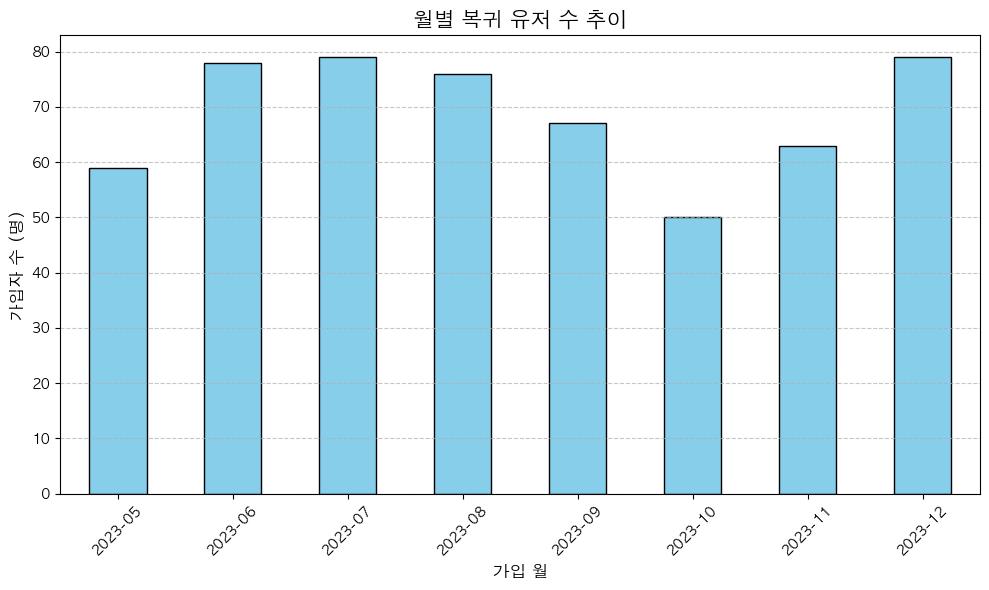

In [ ]:
resubscribe['client_event_time'] = pd.to_datetime(resubscribe['client_event_time'])
resubscribe['resubscribe_month'] = resubscribe['client_event_time'].dt.to_period('M')
monthly_resubscribe = resubscribe.groupby('resubscribe_month')['user_id'].nunique()
print(monthly_resubscribe)

plt.rc('font', family=KOREAN_FONT)

plt.figure(figsize=(10, 6))

monthly_resubscribe.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('월별 복귀 유저 수 추이', fontsize=15)
plt.xlabel('가입 월', fontsize=12)
plt.ylabel('가입자 수 (명)', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

signup_month
2023-05    4739
2023-06    6706
2023-07    7812
2023-08    6834
2023-09    6539
2023-10    5630
2023-11    7754
2023-12    9474
Freq: M, Name: user_id, dtype: int64


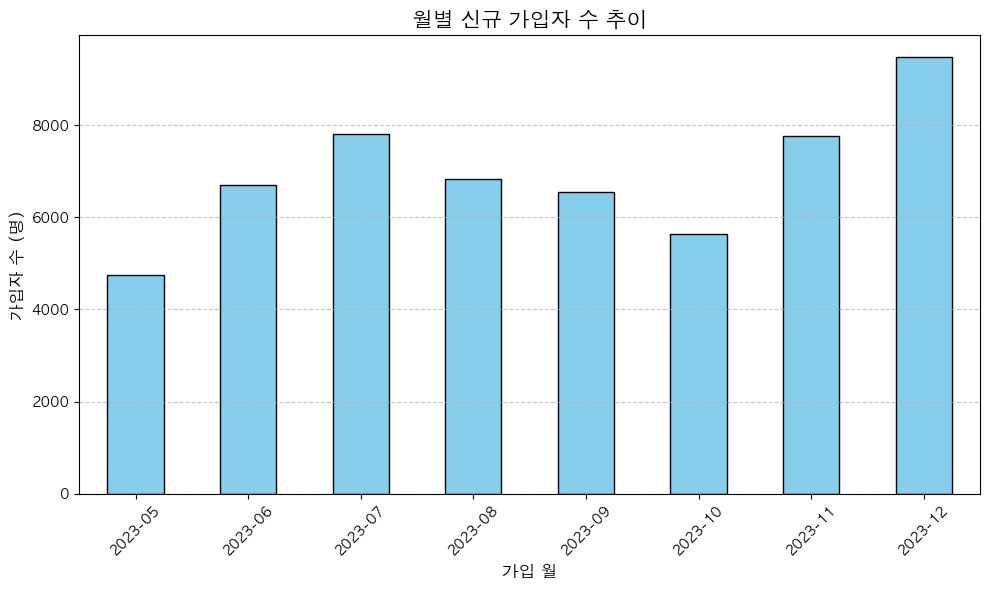

In [ ]:
signup['client_event_time'] = pd.to_datetime(signup['client_event_time'])
signup['signup_month'] = signup['client_event_time'].dt.to_period('M')
monthly_signup = signup.groupby('signup_month')['user_id'].nunique()
print(monthly_signup)

plt.rc('font', family=KOREAN_FONT)

plt.figure(figsize=(10, 6))

monthly_signup.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('월별 신규 가입자 수 추이', fontsize=15)
plt.xlabel('가입 월', fontsize=12)
plt.ylabel('가입자 수 (명)', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

renew_month
2023-05     662
2023-06     738
2023-07     902
2023-08    1096
2023-09    1199
2023-10    1180
2023-11     993
2023-12    1455
Freq: M, Name: user_id, dtype: int64


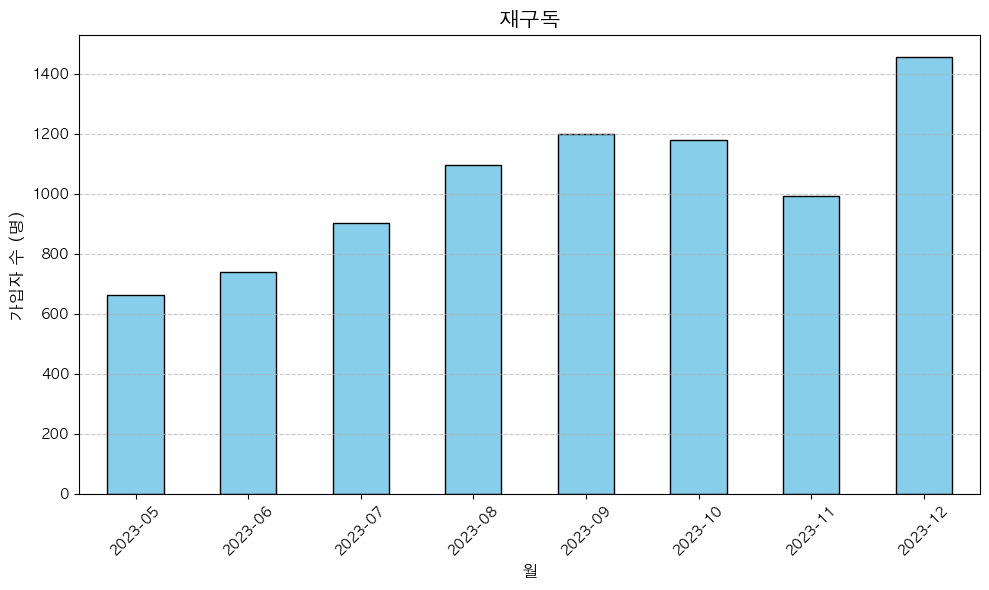

In [ ]:
renew = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_renew_subscription_cohort.csv'))
renew['client_event_time'] = pd.to_datetime(renew['client_event_time'])
renew['renew_month'] = renew['client_event_time'].dt.to_period('M')
monthly_renew = renew.groupby('renew_month')['user_id'].nunique()
print(monthly_renew)

plt.rc('font', family=KOREAN_FONT)

plt.figure(figsize=(10, 6))

monthly_renew.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('재구독', fontsize=15)
plt.xlabel('월', fontsize=12)
plt.ylabel('가입자 수 (명)', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

renew_month
2023-05     576
2023-06     654
2023-07     797
2023-08     993
2023-09    1074
2023-10    1065
2023-11     916
2023-12    1371
Freq: M, Name: user_id, dtype: int64


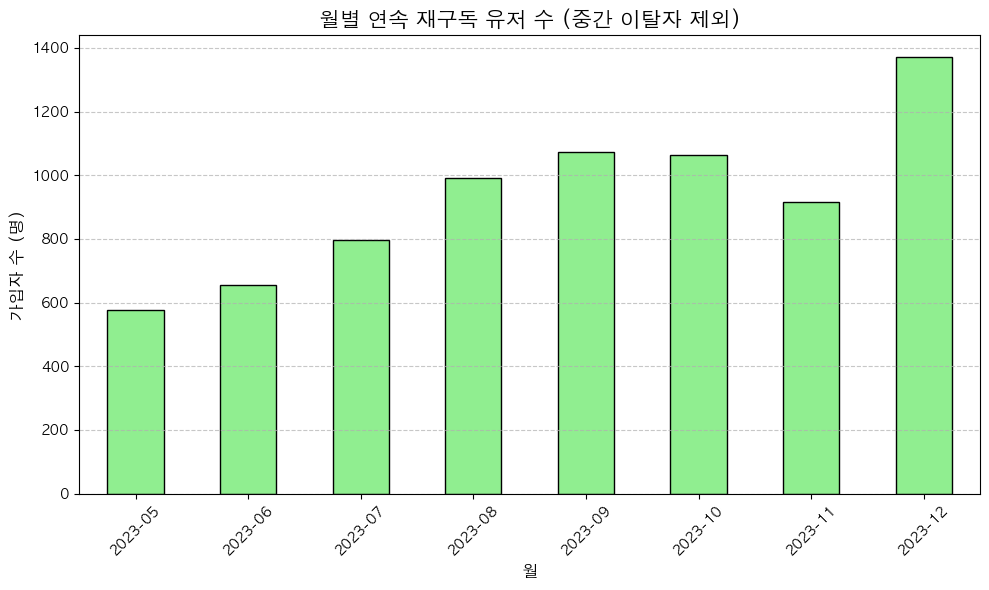

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

renew = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_renew_subscription_cohort.csv'))
renew['client_event_time'] = pd.to_datetime(renew['client_event_time'])
renew['renew_month'] = renew['client_event_time'].dt.to_period('M')
renew['month_index'] = renew['client_event_time'].dt.year * 12 + renew['client_event_time'].dt.month
renew_unique_months = renew.drop_duplicates(subset=['user_id', 'renew_month'])

user_stats = renew_unique_months.groupby('user_id')['month_index'].agg(['min', 'max', 'count'])

user_stats['expected_count'] = user_stats['max'] - user_stats['min'] + 1

continuous_users = user_stats[user_stats['count'] == user_stats['expected_count']].index

renew_continuous = renew[renew['user_id'].isin(continuous_users)]

monthly_renew_continuous = renew_continuous.groupby('renew_month')['user_id'].nunique()
print(monthly_renew_continuous)

plt.rc('font', family=KOREAN_FONT)

plt.figure(figsize=(10, 6))

monthly_renew_continuous.plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title('월별 연속 재구독 유저 수 (중간 이탈자 제외)', fontsize=15)
plt.xlabel('월', fontsize=12)
plt.ylabel('가입자 수 (명)', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

renew_month
2023-05     86
2023-06     84
2023-07    105
2023-08    103
2023-09    125
2023-10    115
2023-11     77
2023-12     84
Freq: M, Name: user_id, dtype: int64


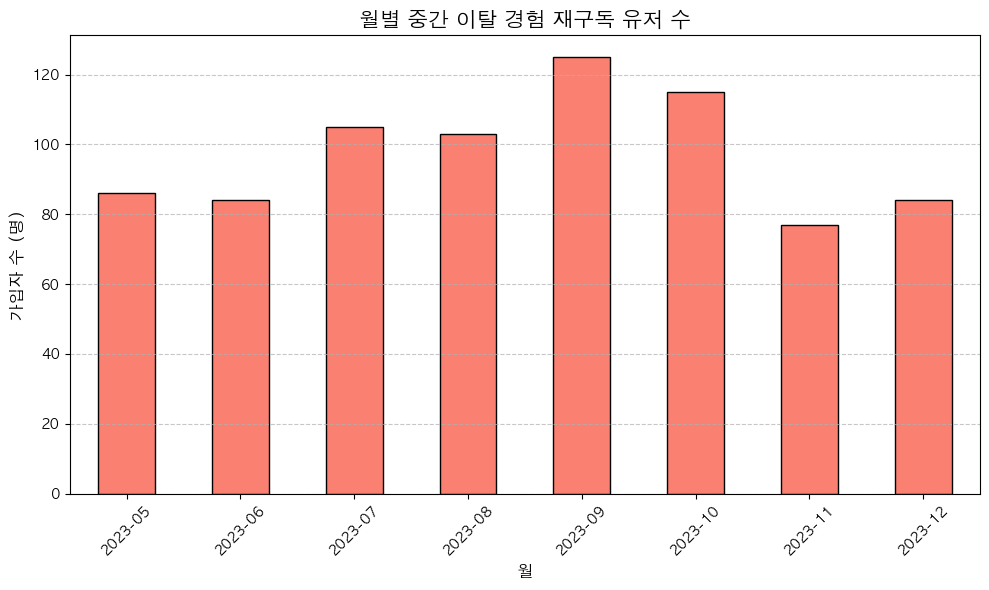

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

renew = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_renew_subscription_cohort.csv'))
renew['client_event_time'] = pd.to_datetime(renew['client_event_time'])
renew['renew_month'] = renew['client_event_time'].dt.to_period('M')

renew['month_index'] = renew['client_event_time'].dt.year * 12 + renew['client_event_time'].dt.month

renew_unique_months = renew.drop_duplicates(subset=['user_id', 'renew_month'])

user_stats = renew_unique_months.groupby('user_id')['month_index'].agg(['min', 'max', 'count'])
user_stats['expected_count'] = user_stats['max'] - user_stats['min'] + 1

churned_users = user_stats[user_stats['count'] < user_stats['expected_count']].index
renew_churned = renew[renew['user_id'].isin(churned_users)]

monthly_renew_churned = renew_churned.groupby('renew_month')['user_id'].nunique()
print(monthly_renew_churned)

plt.rc('font', family=KOREAN_FONT)

plt.figure(figsize=(10, 6))

monthly_renew_churned.plot(kind='bar', color='salmon', edgecolor='black')

plt.title('월별 중간 이탈 경험 재구독 유저 수', fontsize=15)
plt.xlabel('월', fontsize=12)
plt.ylabel('가입자 수 (명)', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

--- 월별 재구독자 중 이탈 경험자 비중 (%) ---
renew_month
2023-05    12.990937
2023-06    11.382114
2023-07    11.640798
2023-08     9.397810
2023-09    10.425354
2023-10     9.745763
2023-11     7.754280
2023-12     5.773196
Freq: M, Name: user_id, dtype: float64


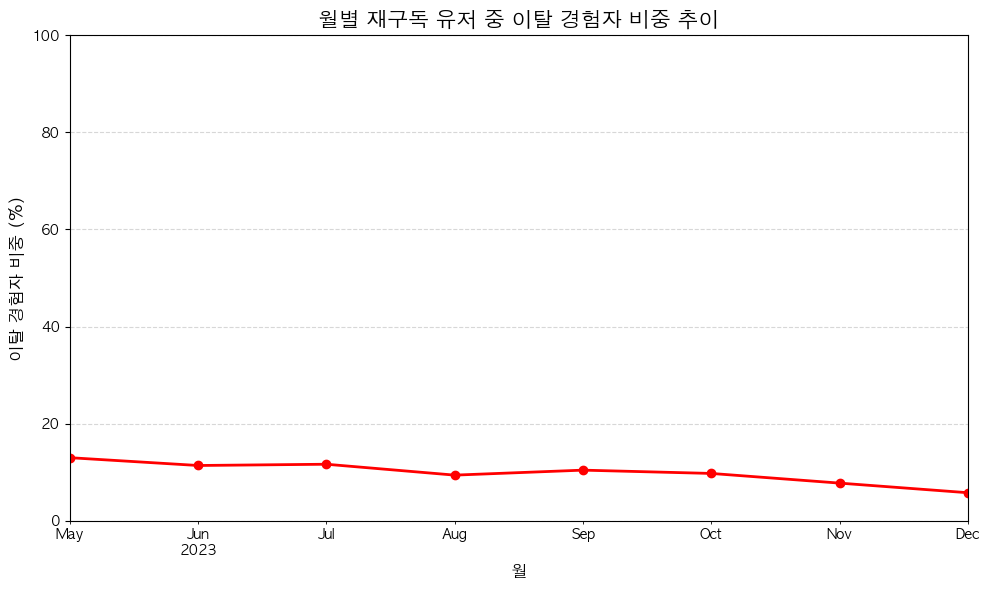

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

renew = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_renew_subscription_cohort.csv'))
renew['client_event_time'] = pd.to_datetime(renew['client_event_time'])
renew['renew_month'] = renew['client_event_time'].dt.to_period('M')
renew['month_index'] = renew['client_event_time'].dt.year * 12 + renew['client_event_time'].dt.month

renew_unique_months = renew.drop_duplicates(subset=['user_id', 'renew_month'])

user_stats = renew_unique_months.groupby('user_id')['month_index'].agg(['min', 'max', 'count'])
user_stats['expected_count'] = user_stats['max'] - user_stats['min'] + 1
churn_user_ids = user_stats[user_stats['count'] < user_stats['expected_count']].index

monthly_total = renew_unique_months.groupby('renew_month')['user_id'].nunique()
monthly_churn_users = renew_unique_months[renew_unique_months['user_id'].isin(churn_user_ids)].groupby('renew_month')['user_id'].nunique()

monthly_churn_rate = (monthly_churn_users / monthly_total * 100).fillna(0)

print("--- 월별 재구독자 중 이탈 경험자 비중 (%) ---")
print(monthly_churn_rate)

plt.rc('font', family=KOREAN_FONT)
plt.figure(figsize=(10, 6))

monthly_churn_rate.plot(kind='line', marker='o', color='red', linewidth=2)

plt.title('월별 재구독 유저 중 이탈 경험자 비중 추이', fontsize=15)
plt.xlabel('월', fontsize=12)
plt.ylabel('이탈 경험자 비중 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, 100)
plt.tight_layout()

plt.show()

start_month
2023-05    4640
2023-06    4958
2023-07    5993
2023-08    5478
2023-09    4625
2023-10    4268
2023-11    5639
2023-12    5825
Freq: M, Name: user_id, dtype: int64


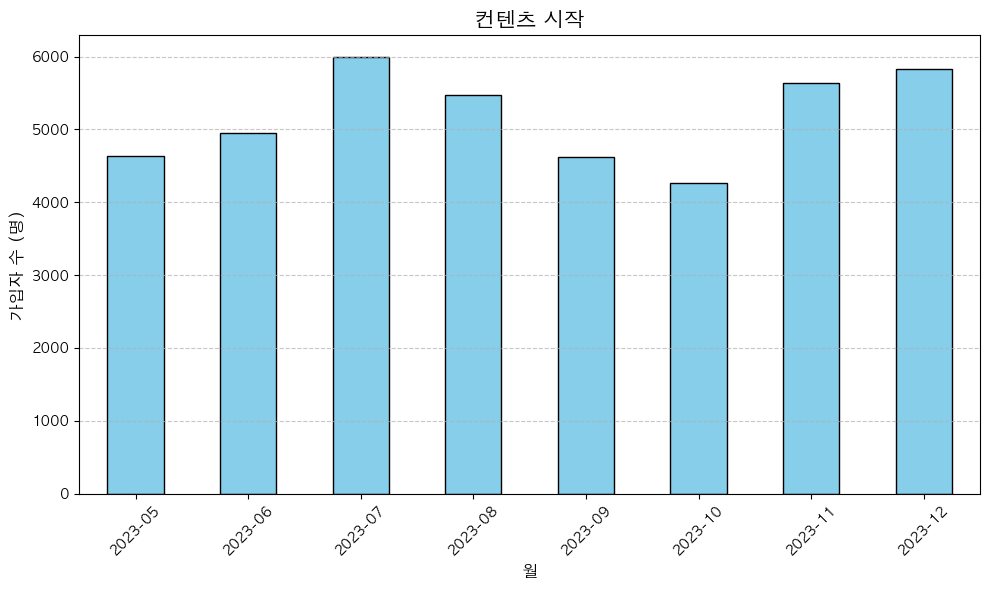

In [ ]:
start['client_event_time'] = pd.to_datetime(start['client_event_time'])
start['start_month'] = start['client_event_time'].dt.to_period('M')
monthly_start = start.groupby('start_month')['user_id'].nunique()
print(monthly_start)

plt.rc('font', family=KOREAN_FONT)

plt.figure(figsize=(10, 6))

monthly_start.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('컨텐츠 시작', fontsize=15)
plt.xlabel('월', fontsize=12)
plt.ylabel('가입자 수 (명)', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

end_month
2023-05    1934
2023-06    2044
2023-07    2688
2023-08    2735
2023-09    2310
2023-10    2211
2023-11    2603
2023-12    2793
Freq: M, Name: user_id, dtype: int64


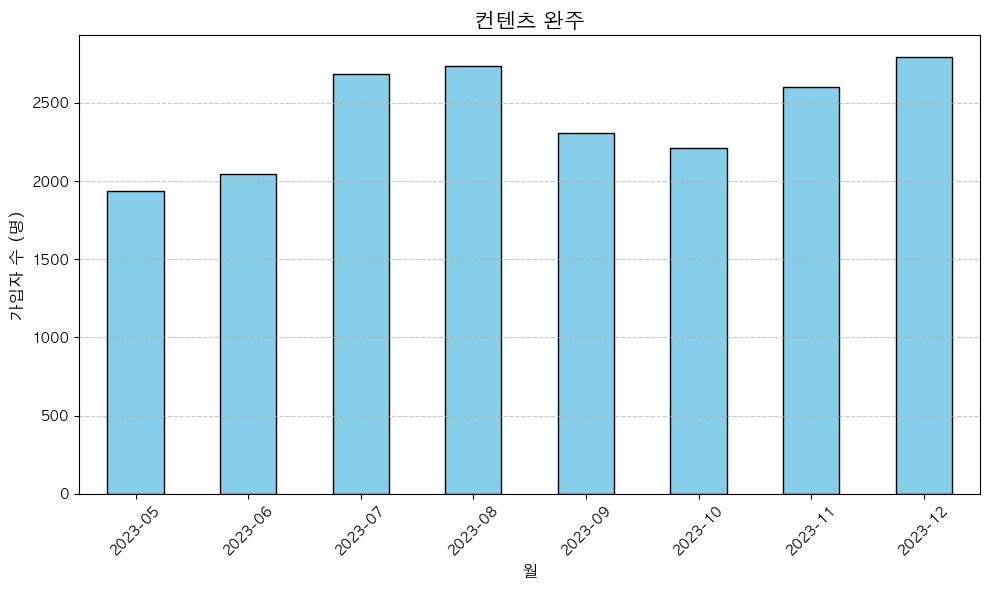

In [ ]:
end['client_event_time'] = pd.to_datetime(end['client_event_time'])
end['end_month'] = end['client_event_time'].dt.to_period('M')
monthly_end = end.groupby('end_month')['user_id'].nunique()
print(monthly_end)

plt.rc('font', family=KOREAN_FONT)

plt.figure(figsize=(10, 6))

monthly_end.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('컨텐츠 완주', fontsize=15)
plt.xlabel('월', fontsize=12)
plt.ylabel('가입자 수 (명)', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

lesson_month
2023-05    4467
2023-06    5211
2023-07    4678
2023-08    4590
2023-09    3872
2023-10    3882
2023-11    4493
2023-12    4730
Freq: M, Name: user_id, dtype: int64


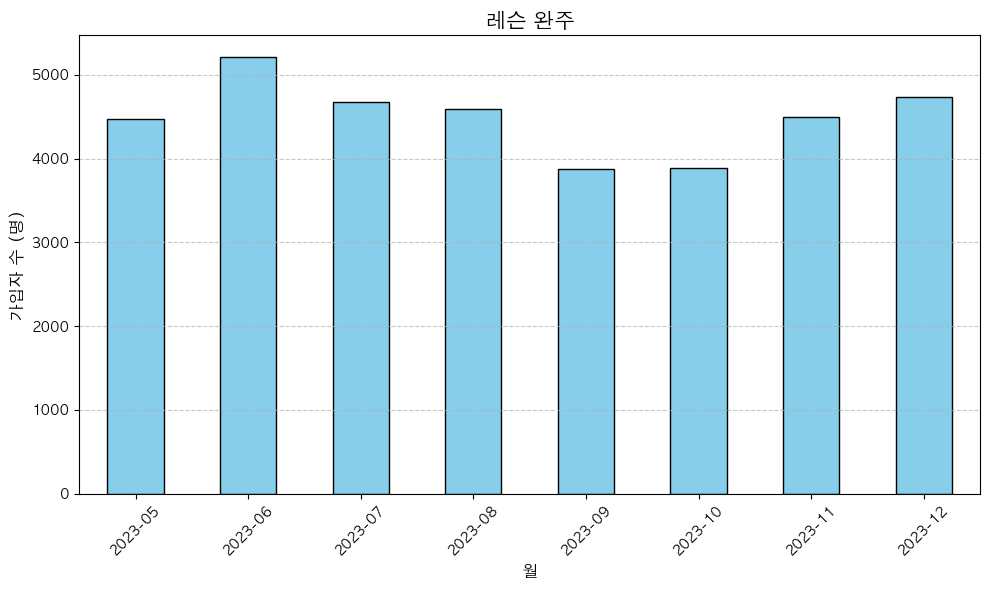

In [ ]:
lesson = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_complete_lesson_cohort.csv'))
lesson['client_event_time'] = pd.to_datetime(lesson['client_event_time'])
lesson['lesson_month'] = lesson['client_event_time'].dt.to_period('M')
monthly_lesson = lesson.groupby('lesson_month')['user_id'].nunique()
print(monthly_lesson)

plt.rc('font', family=KOREAN_FONT)

plt.figure(figsize=(10, 6))

monthly_lesson.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('레슨 완주', fontsize=15)
plt.xlabel('월', fontsize=12)
plt.ylabel('가입자 수 (명)', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

subscription_month
2023-05    386
2023-06    659
2023-07    803
2023-08    522
2023-09    584
2023-10    366
2023-11    569
2023-12    783
Freq: M, Name: user_id, dtype: int64


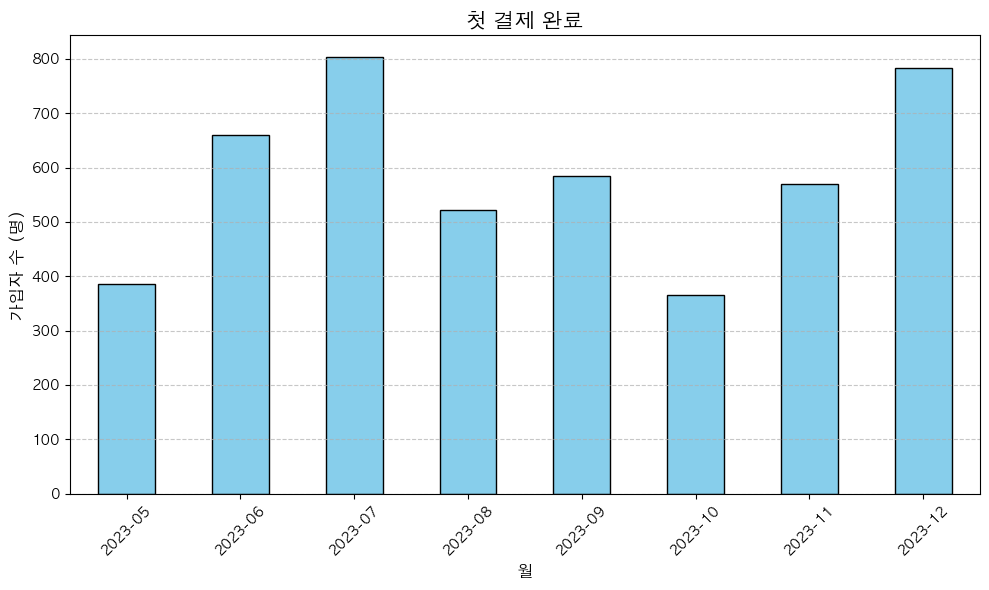

In [ ]:
subscription = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_complete_subscription_cohort.csv'))
subscription['client_event_time'] = pd.to_datetime(subscription['client_event_time'])
subscription['subscription_month'] = subscription['client_event_time'].dt.to_period('M')
monthly_subscription = subscription.groupby('subscription_month')['user_id'].nunique()
print(monthly_subscription)

plt.rc('font', family=KOREAN_FONT)

plt.figure(figsize=(10, 6))

monthly_subscription.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('첫 결제 완료', fontsize=15)
plt.xlabel('월', fontsize=12)
plt.ylabel('가입자 수 (명)', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

subscription_month
2023-05    386
2023-06    657
2023-07    801
2023-08    520
2023-09    584
2023-10    366
2023-11    567
2023-12    780
Freq: M, Name: user_id, dtype: int64


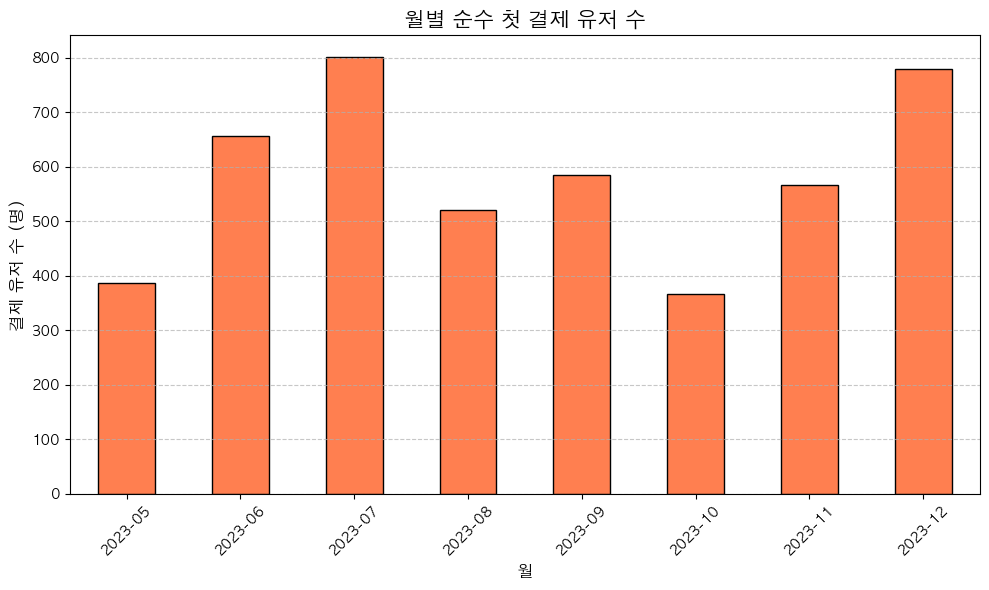

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

subscription = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_complete_subscription_cohort.csv'))
subscription['client_event_time'] = pd.to_datetime(subscription['client_event_time'])
subscription['subscription_month'] = subscription['client_event_time'].dt.to_period('M')

subscription = subscription.sort_values(by='client_event_time')
subscription_unique = subscription.drop_duplicates(subset=['user_id'], keep='first')

monthly_subscription = subscription_unique.groupby('subscription_month')['user_id'].nunique()
print(monthly_subscription)

plt.rc('font', family=KOREAN_FONT)
plt.figure(figsize=(10, 6))

monthly_subscription.plot(kind='bar', color='coral', edgecolor='black')

plt.title('월별 순수 첫 결제 유저 수', fontsize=15)
plt.xlabel('월', fontsize=12)
plt.ylabel('결제 유저 수 (명)', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [ ]:
resubscribe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551 entries, 0 to 550
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    538 non-null    object        
 1   client_event_time       551 non-null    datetime64[ns]
 2   country                 546 non-null    object        
 3   device_carrier          0 non-null      float64       
 4   device_family           546 non-null    object        
 5   device_type             536 non-null    object        
 6   event_type              551 non-null    object        
 7   language                546 non-null    object        
 8   os_name                 546 non-null    object        
 9   os_version              546 non-null    object        
 10  platform                546 non-null    object        
 11  user_id                 551 non-null    object        
 12  plan.price              551 non-null    int64     

In [ ]:
start.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74457 entries, 0 to 74456
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   city                72044 non-null  object        
 1   client_event_time   74457 non-null  datetime64[ns]
 2   country             72722 non-null  object        
 3   device_carrier      0 non-null      float64       
 4   device_family       72949 non-null  object        
 5   device_type         70554 non-null  object        
 6   event_type          74457 non-null  object        
 7   language            72950 non-null  object        
 8   os_name             72949 non-null  object        
 9   os_version          72890 non-null  object        
 10  platform            72950 non-null  object        
 11  user_id             74457 non-null  object        
 12  content.id          74457 non-null  object        
 13  content.difficulty  74457 non-null  object    

In [ ]:
end.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46040 entries, 0 to 46039
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   city               44354 non-null  object        
 1   client_event_time  46040 non-null  datetime64[ns]
 2   country            44629 non-null  object        
 3   device_carrier     0 non-null      float64       
 4   device_family      45484 non-null  object        
 5   device_type        45027 non-null  object        
 6   event_type         46040 non-null  object        
 7   language           45485 non-null  object        
 8   os_name            45484 non-null  object        
 9   os_version         45481 non-null  object        
 10  platform           45485 non-null  object        
 11  user_id            46040 non-null  object        
 12  content.id         46040 non-null  object        
 13  month              46040 non-null  period[M]     
 14  end_mo

In [ ]:
renew.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    8160 non-null   object        
 1   client_event_time       8273 non-null   datetime64[ns]
 2   country                 8198 non-null   object        
 3   device_carrier          0 non-null      float64       
 4   device_family           8198 non-null   object        
 5   device_type             8035 non-null   object        
 6   event_type              8273 non-null   object        
 7   language                8198 non-null   object        
 8   os_name                 8198 non-null   object        
 9   os_version              8190 non-null   object        
 10  platform                8198 non-null   object        
 11  user_id                 8273 non-null   object        
 12  plan.price              8273 non-null   int64   

In [ ]:
lesson.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044854 entries, 0 to 1044853
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   city               1006670 non-null  object        
 1   client_event_time  1044854 non-null  datetime64[ns]
 2   country            1013012 non-null  object        
 3   device_carrier     0 non-null        float64       
 4   device_family      1033172 non-null  object        
 5   device_type        1021305 non-null  object        
 6   event_type         1044854 non-null  object        
 7   language           1033187 non-null  object        
 8   os_name            1033172 non-null  object        
 9   os_version         1033073 non-null  object        
 10  platform           1033187 non-null  object        
 11  user_id            1044854 non-null  object        
 12  content.id         1044854 non-null  object        
 13  lesson.id          1044854 

In [ ]:
signup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55488 entries, 0 to 55487
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   city               10994 non-null  object        
 1   client_event_time  55488 non-null  datetime64[ns]
 2   country            11223 non-null  object        
 3   device_carrier     0 non-null      float64       
 4   device_family      11227 non-null  object        
 5   device_type        10308 non-null  object        
 6   event_type         55488 non-null  object        
 7   language           11227 non-null  object        
 8   os_name            11227 non-null  object        
 9   os_version         11190 non-null  object        
 10  platform           11227 non-null  object        
 11  user_id            55488 non-null  object        
 12  type               55488 non-null  object        
 13  month              55488 non-null  period[M]     
 14  signup

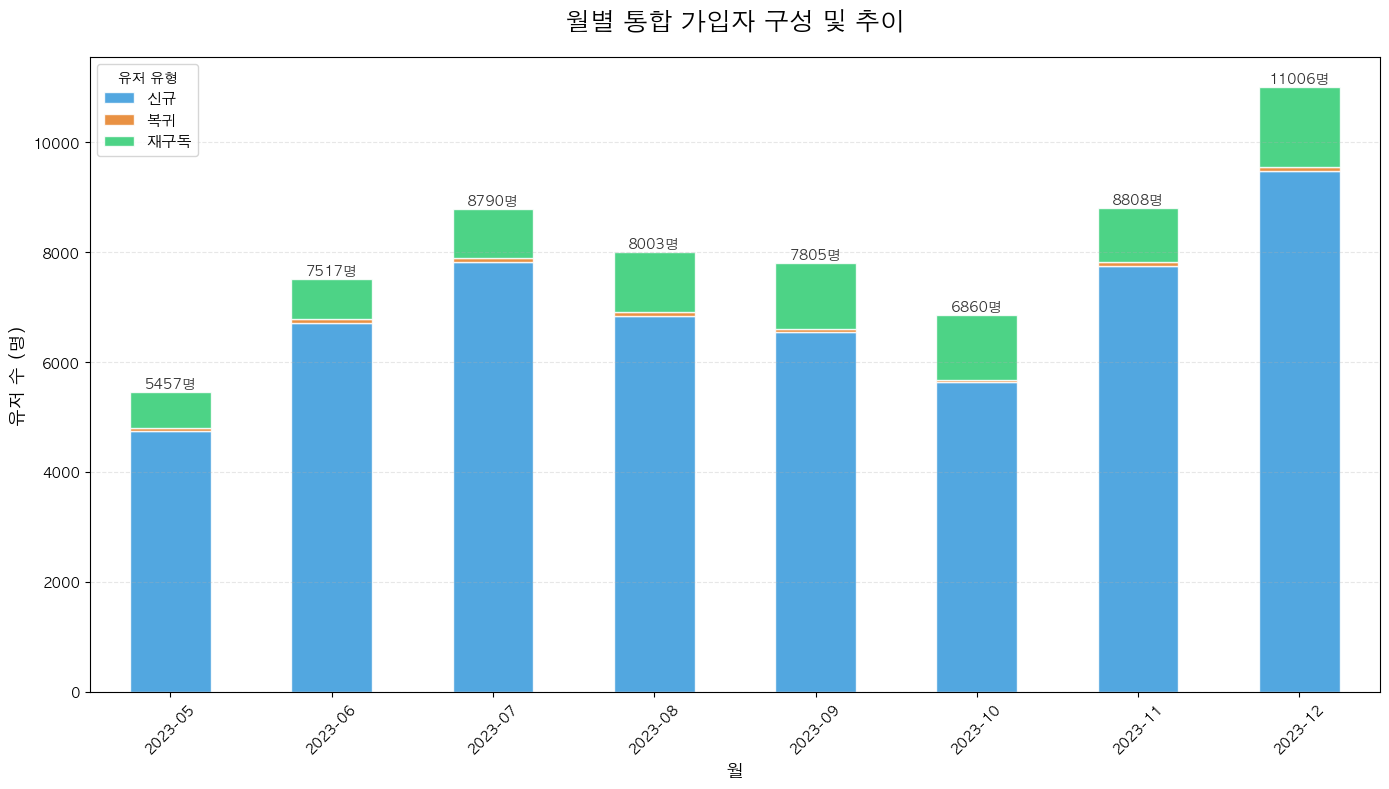

type       신규  복귀   재구독
month                  
2023-05  4739  59   659
2023-06  6706  78   733
2023-07  7812  79   899
2023-08  6834  76  1093
2023-09  6539  67  1199
2023-10  5630  50  1180
2023-11  7754  63   991
2023-12  9474  79  1453


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

signup = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_complete_signup_cohort.csv'))
resubscribe = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_resubscribe_subscription_cohort.csv'))
renew = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_renew_subscription_cohort.csv'))

def preprocess(df, label):
    df['client_event_time'] = pd.to_datetime(df['client_event_time'])
    df['month'] = df['client_event_time'].dt.to_period('M')
    return df[['user_id', 'month']].assign(type=label)

s_df = preprocess(signup, '신규')
r_df = preprocess(resubscribe, '복귀')
w_df = preprocess(renew, '재구독')

combined = pd.concat([s_df, r_df, w_df])

priority_map = {'신규': 1, '복귀': 2, '재구독': 3}
combined['priority'] = combined['type'].map(priority_map)

final_users = combined.sort_values(['month', 'user_id', 'priority']).drop_duplicates(subset=['month', 'user_id'], keep='first')

summary_df = final_users.groupby(['month', 'type']).size().unstack(fill_value=0)
summary_df.index = summary_df.index.astype(str)

plt.rc('font', family=KOREAN_FONT)
plt.figure(figsize=(14, 8))

plot_order = ['신규', '복귀', '재구독']
colors = ['#3498db', '#e67e22', '#2ecc71']

summary_df[plot_order].plot(kind='bar', stacked=True, ax=plt.gca(), color=colors, alpha=0.85, edgecolor='white')

plt.title('월별 통합 가입자 구성 및 추이', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('월', fontsize=13)
plt.ylabel('유저 수 (명)', fontsize=13)
plt.xticks(rotation=45)
plt.legend(title='유저 유형', fontsize=11, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

for i, (idx, row) in enumerate(summary_df.iterrows()):
    total = row.sum()
    plt.text(i, total + 10, f'{int(total)}명', ha='center', va='bottom', fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

print(summary_df[plot_order])

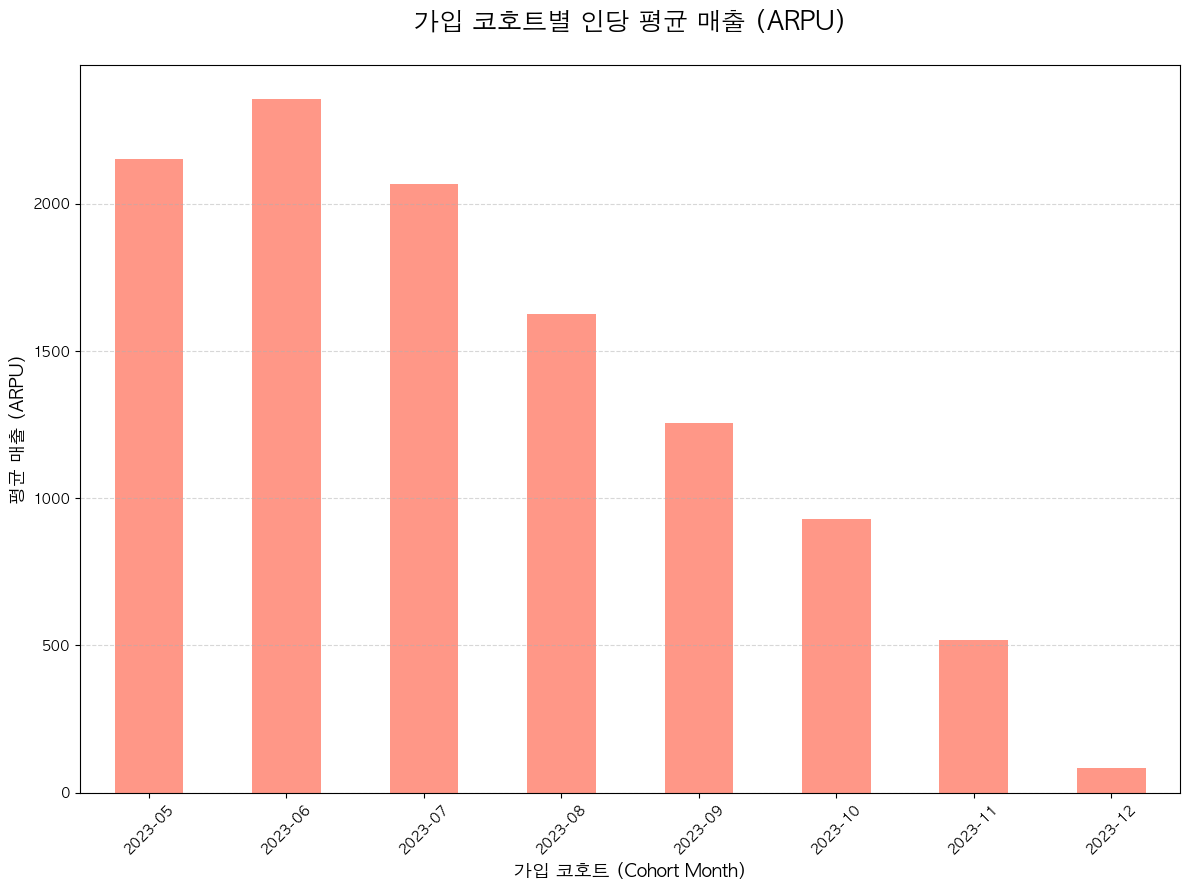

cohort_month
2023-05    2151.944143
2023-06    2354.659346
2023-07    2066.065534
2023-08    1625.177749
2023-09    1254.891634
2023-10     930.998589
2023-11     517.897245
2023-12      83.231463
Freq: M, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

signup = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_complete_signup_cohort.csv'))
resub = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_resubscribe_subscription_cohort.csv'))
renew = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_renew_subscription_cohort.csv'))

signup['month'] = pd.to_datetime(signup['client_event_time']).dt.to_period('M')
resub['month'] = pd.to_datetime(resub['client_event_time']).dt.to_period('M')
renew['month'] = pd.to_datetime(renew['client_event_time']).dt.to_period('M')

inflow = pd.concat([
    signup[['user_id', 'month']],
    resub[['user_id', 'month']]
]).drop_duplicates(subset=['user_id'], keep='first').copy()
inflow.columns = ['user_id', 'cohort_month']

cohort_sizes = inflow.groupby('cohort_month')['user_id'].nunique()
revenue_with_cohort = pd.merge(renew, inflow, on='user_id', how='inner')
total_revenue_per_cohort = revenue_with_cohort.groupby('cohort_month')['paid_amount'].sum()

arpu = total_revenue_per_cohort / cohort_sizes

plt.rc('font', family=KOREAN_FONT)
plt.figure(figsize=(12, 9))

arpu.plot(kind='bar', color='#ff8c7a', alpha=0.9)

plt.title('가입 코호트별 인당 평균 매출 (ARPU)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('가입 코호트 (Cohort Month)', fontsize=13)
plt.ylabel('평균 매출 (ARPU)', fontsize=13)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(arpu)

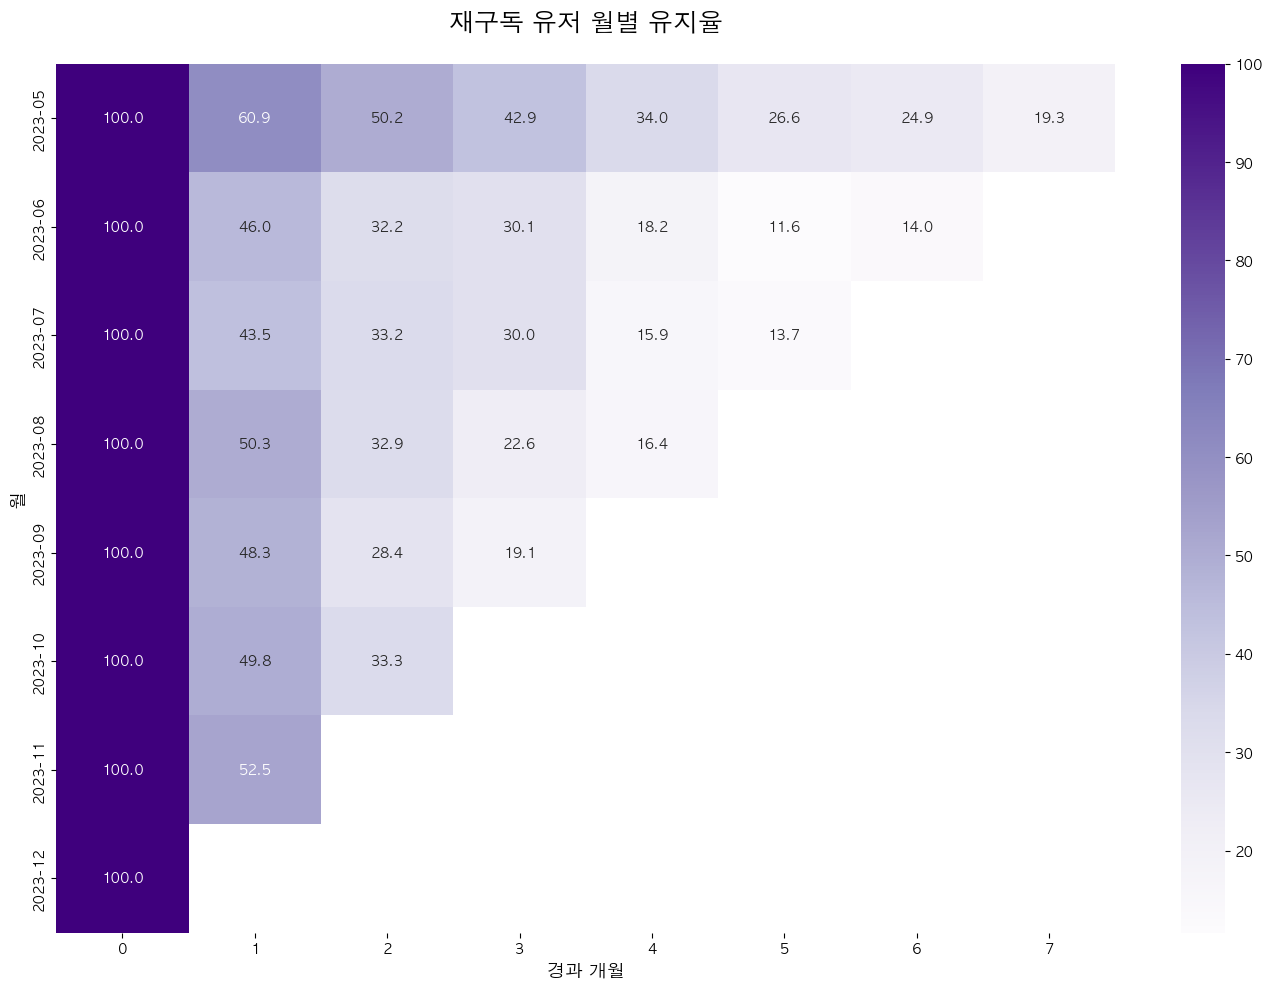

month_idx      0          1          2          3          4          5  \
cohort                                                                    
2023-05    100.0  60.876133  50.151057  42.900302  33.987915  26.586103   
2023-06    100.0  45.970149  32.238806  30.149254  18.208955  11.641791   
2023-07    100.0  43.509615  33.173077  30.048077  15.865385  13.701923   
2023-08    100.0  50.286807  32.887189  22.562141  16.443595        NaN   
2023-09    100.0  48.305085  28.389831  19.067797        NaN        NaN   
2023-10    100.0  49.760766  33.253589        NaN        NaN        NaN   
2023-11    100.0  52.471483        NaN        NaN        NaN        NaN   
2023-12    100.0        NaN        NaN        NaN        NaN        NaN   

month_idx          6          7  
cohort                           
2023-05    24.924471  19.335347  
2023-06    14.029851        NaN  
2023-07          NaN        NaN  
2023-08          NaN        NaN  
2023-09          NaN        NaN  
2023-10    

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

renew = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_renew_subscription_cohort.csv'))
renew['client_event_time'] = pd.to_datetime(renew['client_event_time'])
renew['month'] = renew['client_event_time'].dt.to_period('M')

user_first_renew = renew.groupby('user_id')['month'].min().reset_index()
user_first_renew.columns = ['user_id', 'cohort']
active_renew = renew[['user_id', 'month']].drop_duplicates()
cohort_merge = pd.merge(active_renew, user_first_renew, on='user_id')

def diff_month(d1, d2):
    return (d1.year - d2.year) * 12 + (d1.month - d2.month)

cohort_merge['month_idx'] = cohort_merge.apply(lambda x: diff_month(x['month'], x['cohort']), axis=1)
cohort_pivot = cohort_merge.groupby(['cohort', 'month_idx'])['user_id'].nunique().unstack(fill_value=0)

cumulative_pivot = cohort_pivot.copy()
for i in range(1, len(cumulative_pivot.columns)):
    cumulative_pivot.iloc[:, i] = np.where((cumulative_pivot.iloc[:, i-1] > 0) & (cumulative_pivot.iloc[:, i] > 0),
                                           cumulative_pivot.iloc[:, i], 0)

retention = cumulative_pivot.divide(cumulative_pivot.iloc[:, 0], axis=0) * 100

max_month = renew['month'].max()
for r_idx, month in enumerate(retention.index):
    for c_idx in range(len(retention.columns)):
        if (month + c_idx > max_month) or (retention.iloc[r_idx, c_idx] == 0):
            retention.iloc[r_idx, c_idx] = np.nan

plt.rc('font', family=KOREAN_FONT)
plt.figure(figsize=(14, 10))

sns.heatmap(retention, annot=True, fmt='.1f', cmap='Purples',
            yticklabels=retention.index.astype(str),
            mask=retention.isnull())

plt.title('재구독 유저 월별 유지율', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('경과 개월', fontsize=13)
plt.ylabel('월', fontsize=13)

plt.tight_layout()
plt.show()

print(retention)

/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/500150565.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_re_cont = df_re_end.groupby('user_id', group_keys=False).apply(filter_continuous, include_groups=True)


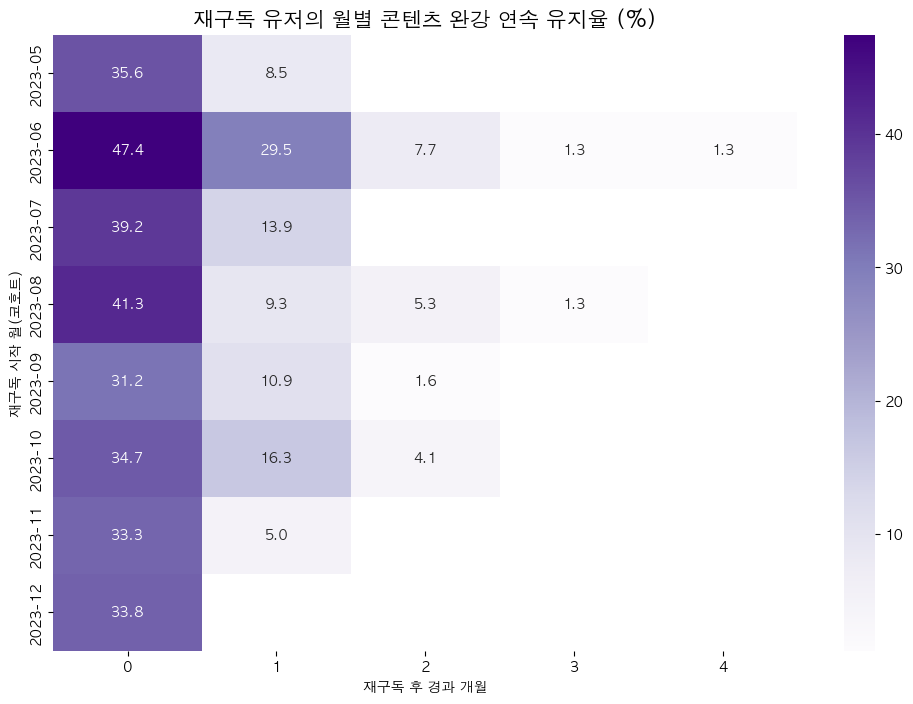

In [ ]:
subscription['client_event_time'] = pd.to_datetime(subscription['client_event_time'])
resubscribe['client_event_time'] = pd.to_datetime(resubscribe['client_event_time'])
end['client_event_time'] = pd.to_datetime(end['client_event_time'])

re_cohort = resubscribe.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
re_cohort['re_cohort_month'] = re_cohort['client_event_time'].dt.to_period('M')

end['activity_month'] = end['client_event_time'].dt.to_period('M')
df_re_end = pd.merge(end[['user_id', 'activity_month']],
                     re_cohort[['user_id', 're_cohort_month']],
                     on='user_id', how='inner')

df_re_end['index'] = (df_re_end['activity_month'].dt.year - df_re_end['re_cohort_month'].dt.year) * 12 + \
                     (df_re_end['activity_month'].dt.month - df_re_end['re_cohort_month'].dt.month)

df_re_end = df_re_end[df_re_end['index'] >= 0].drop_duplicates(['user_id', 'index'])

def filter_continuous(group):
    group = group.sort_values('index')
    idx_list = group['index'].tolist()
    continuous_idx = []
    for i, val in enumerate(idx_list):
        if val == i:
            continuous_idx.append(val)
        else:
            break
    return group[group['index'].isin(continuous_idx)]

df_re_cont = df_re_end.groupby('user_id', group_keys=False).apply(filter_continuous, include_groups=True)

if 'user_id' not in df_re_cont.columns:
    df_re_cont = df_re_cont.reset_index()

cohort_re_matrix = df_re_cont.groupby(['re_cohort_month', 'index'])['user_id'].nunique().unstack()
re_cohort_size = re_cohort.groupby('re_cohort_month')['user_id'].nunique()
retention_re_end = cohort_re_matrix.divide(re_cohort_size, axis=0) * 100

plt.rc('font', family=KOREAN_FONT)
plt.figure(figsize=(12, 8))
sns.heatmap(retention_re_end, annot=True, fmt='.1f', cmap='Purples')
plt.title('재구독 유저의 월별 콘텐츠 완강 연속 유지율 (%)', fontsize=15)
plt.xlabel('재구독 후 경과 개월')
plt.ylabel('재구독 시작 월(코호트)')
plt.show()

/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/3629636365.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_re_alive = df_re_churn.groupby('user_id', group_keys=False).apply(filter_continuous, include_groups=True)


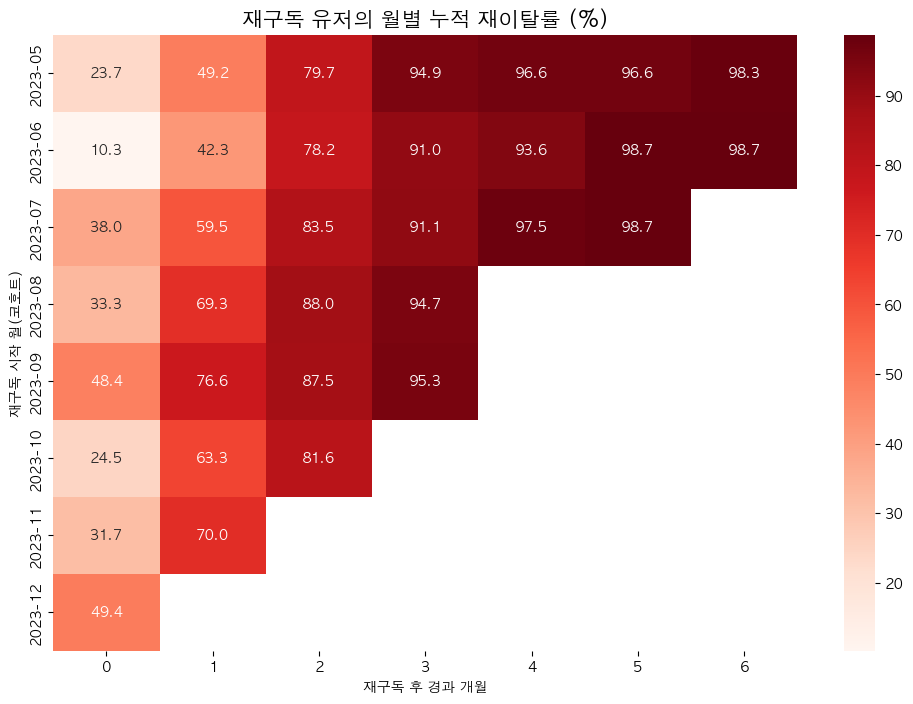

In [ ]:
resubscribe['client_event_time'] = pd.to_datetime(resubscribe['client_event_time'])
lesson['client_event_time'] = pd.to_datetime(lesson['client_event_time'])

re_cohort = resubscribe.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
re_cohort['re_cohort_month'] = re_cohort['client_event_time'].dt.to_period('M')

lesson['activity_month'] = lesson['client_event_time'].dt.to_period('M')
df_re_churn = pd.merge(lesson[['user_id', 'activity_month']],
                       re_cohort[['user_id', 're_cohort_month']],
                       on='user_id', how='inner')

df_re_churn['index'] = (df_re_churn['activity_month'].dt.year - df_re_churn['re_cohort_month'].dt.year) * 12 + \
                       (df_re_churn['activity_month'].dt.month - df_re_churn['re_cohort_month'].dt.month)

df_re_churn = df_re_churn[df_re_churn['index'] >= 0].drop_duplicates(['user_id', 'index'])

def filter_continuous(group):
    group = group.sort_values('index')
    idx_list = group['index'].tolist()
    continuous_idx = []
    for i, val in enumerate(idx_list):
        if val == i:
            continuous_idx.append(val)
        else:
            break
    return group[group['index'].isin(continuous_idx)]

df_re_alive = df_re_churn.groupby('user_id', group_keys=False).apply(filter_continuous, include_groups=True)

cohort_pivot = df_re_alive.groupby(['re_cohort_month', 'index'])['user_id'].nunique().unstack()
re_cohort_size = re_cohort.groupby('re_cohort_month')['user_id'].nunique()

retention = cohort_pivot.divide(re_cohort_size, axis=0) * 100
churn_rate = 100 - retention

plt.rc('font', family=KOREAN_FONT)
plt.figure(figsize=(12, 8))
sns.heatmap(churn_rate, annot=True, fmt='.1f', cmap='Reds')
plt.title('재구독 유저의 월별 누적 재이탈률 (%)', fontsize=15)
plt.xlabel('재구독 후 경과 개월')
plt.ylabel('재구독 시작 월(코호트)')
plt.show()

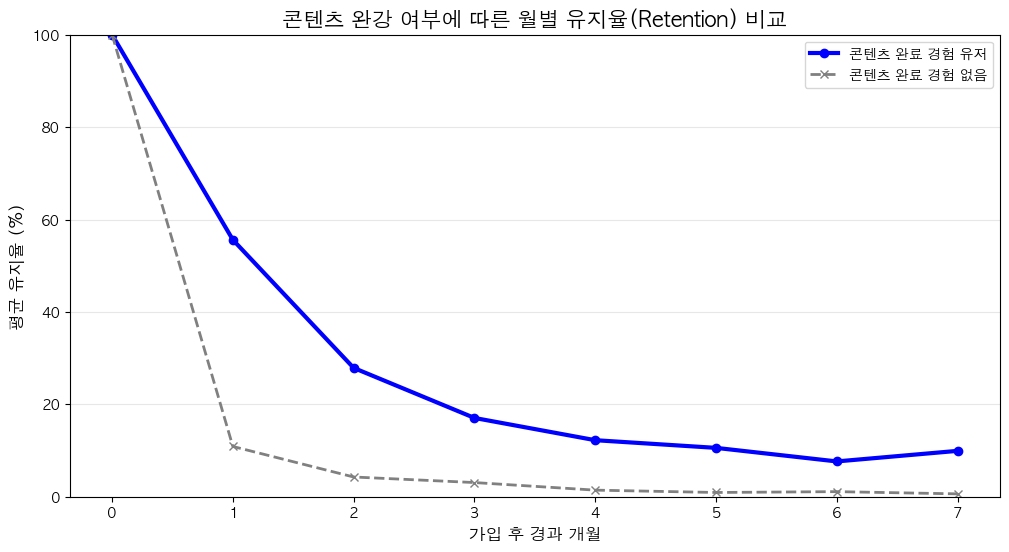

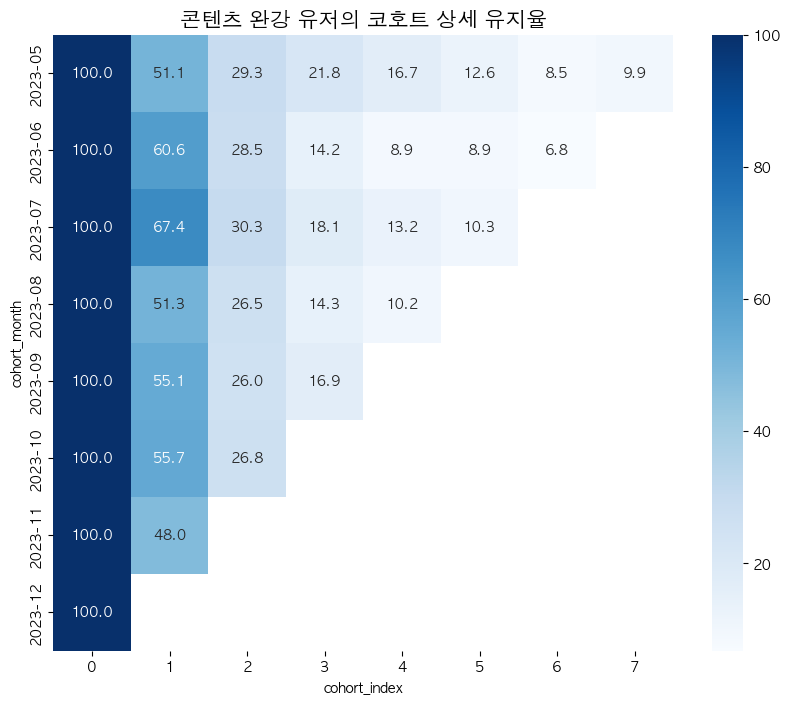

In [ ]:
signup['client_event_time'] = pd.to_datetime(signup['client_event_time'])
lesson['client_event_time'] = pd.to_datetime(lesson['client_event_time'])

completed_user_ids = end['user_id'].unique()

signup['cohort_month'] = signup['client_event_time'].dt.to_period('M')
lesson['activity_month'] = lesson['client_event_time'].dt.to_period('M')

df = pd.merge(lesson[['user_id', 'activity_month']],
              signup[['user_id', 'cohort_month']],
              on='user_id', how='inner')

df['cohort_index'] = (df['activity_month'].dt.year - df['cohort_month'].dt.year) * 12 + \
                     (df['activity_month'].dt.month - df['cohort_month'].dt.month)

df['is_completed'] = df['user_id'].isin(completed_user_ids)

def get_retention(data):
    cohort_counts = data.groupby(['cohort_month', 'cohort_index'])['user_id'].nunique().reset_index()
    pivot = cohort_counts.pivot(index='cohort_month', columns='cohort_index', values='user_id')
    return pivot.divide(pivot.iloc[:, 0], axis=0) * 100

retention_completed = get_retention(df[df['is_completed'] == True])
retention_non_completed = get_retention(df[df['is_completed'] == False])

plt.figure(figsize=(12, 6))

plt.plot(retention_completed.mean().index, retention_completed.mean().values,
         marker='o', label='콘텐츠 완료 경험 유저', linewidth=3, color='blue')
plt.plot(retention_non_completed.mean().index, retention_non_completed.mean().values,
         marker='x', label='콘텐츠 완료 경험 없음', linewidth=2, color='gray', linestyle='--')

plt.title('콘텐츠 완강 여부에 따른 월별 유지율(Retention) 비교', fontsize=15)
plt.xlabel('가입 후 경과 개월', fontsize=12)
plt.ylabel('평균 유지율 (%)', fontsize=12)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.ylim(0, 100)
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(retention_completed, annot=True, fmt='.1f', cmap='Blues')
plt.title('콘텐츠 완강 유저의 코호트 상세 유지율', fontsize=15)
plt.show()

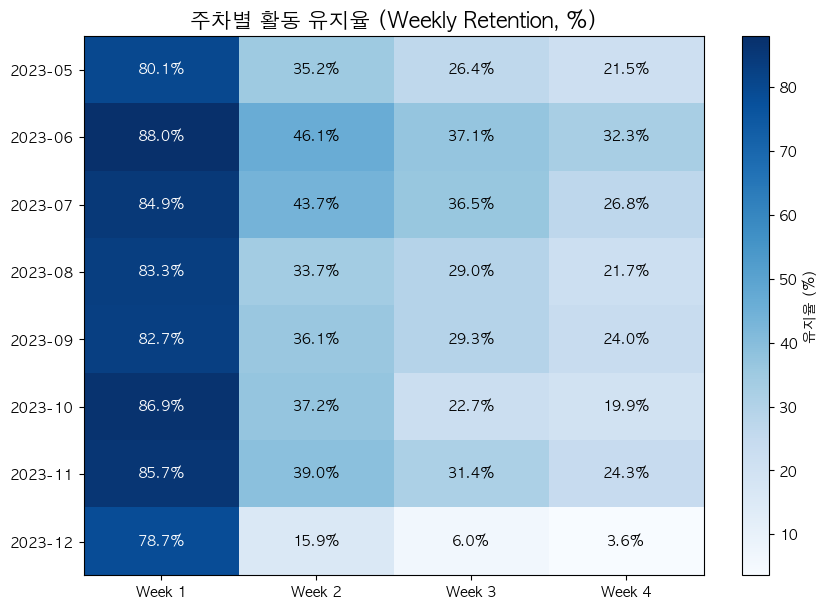

In [ ]:
df_sub = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_complete_subscription_cohort.csv'), parse_dates=['client_event_time'])
df_start = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_start_content_cohort.csv'), parse_dates=['client_event_time'])

base = df_sub[df_sub['client_event_time'] >= '2023-05-01'].sort_values('client_event_time').groupby('user_id').head(1).copy()
base = base.rename(columns={'client_event_time': 'sub_date'})
base['cohort_month'] = base['sub_date'].dt.to_period('M')

merged = pd.merge(df_start, base[['user_id', 'sub_date', 'cohort_month']], on='user_id')
merged['diff_days'] = (merged['client_event_time'] - merged['sub_date']).dt.days
merged['week_idx'] = (merged['diff_days'] // 7) + 1

weekly_df = merged[(merged['week_idx'] >= 1) & (merged['week_idx'] <= 4)]

weekly_active = weekly_df.groupby(['cohort_month', 'week_idx'])['user_id'].nunique().unstack(fill_value=0)
cohort_size = base.groupby('cohort_month').size()
weekly_retention = weekly_active.div(cohort_size, axis=0) * 100

plt.figure(figsize=(10, 7))
data = weekly_retention.values
rows = weekly_retention.index.astype(str)
cols = weekly_retention.columns

plt.imshow(data, cmap='Blues', aspect='auto')

for i in range(len(rows)):
    for j in range(len(cols)):
        plt.text(j, i, f'{data[i, j]:.1f}%', ha='center', va='center',
                 color='white' if data[i, j] > 50 else 'black')

plt.title('주차별 활동 유지율 (Weekly Retention, %)', fontsize=15)
plt.xticks(range(len(cols)), [f'Week {c}' for c in cols])
plt.yticks(range(len(rows)), rows)
plt.colorbar(label='유지율 (%)')
plt.show()

/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/294559862.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_start_cont = df_start.groupby('user_id', group_keys=False).apply(filter_continuous)


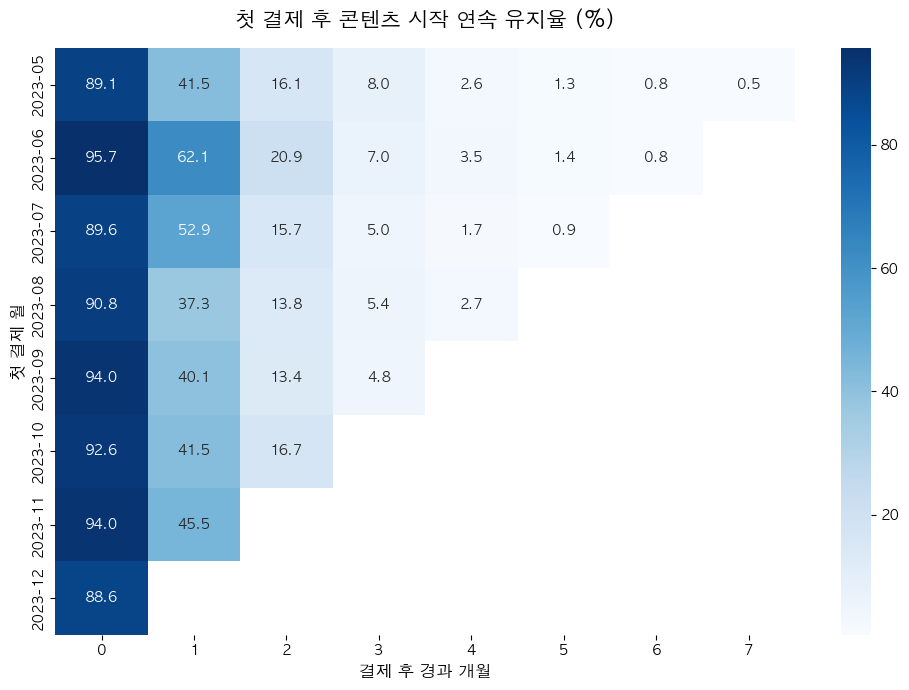

In [ ]:
subscription['client_event_time'] = pd.to_datetime(subscription['client_event_time'])
start['client_event_time'] = pd.to_datetime(start['client_event_time'])

first_sub = subscription.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_sub['sub_cohort'] = first_sub['client_event_time'].dt.to_period('M')

start['activity_month'] = start['client_event_time'].dt.to_period('M')
df_start = pd.merge(start[['user_id', 'activity_month']], first_sub[['user_id', 'sub_cohort']], on='user_id')

df_start['index'] = (df_start['activity_month'].dt.year - df_start['sub_cohort'].dt.year) * 12 + (df_start['activity_month'].dt.month - df_start['sub_cohort'].dt.month)
df_start = df_start[df_start['index'] >= 0].drop_duplicates(['user_id', 'index'])

def filter_continuous(group):
    group = group.sort_values('index')
    idx_list = group['index'].tolist()
    continuous_idx = []
    for i, val in enumerate(idx_list):
        if val == i:
            continuous_idx.append(val)
        else:
            break
    return group[group['index'].isin(continuous_idx)]

df_start_cont = df_start.groupby('user_id', group_keys=False).apply(filter_continuous)

cohort_start = df_start_cont.groupby(['sub_cohort', 'index'])['user_id'].nunique().unstack()
cohort_size = first_sub.groupby('sub_cohort')['user_id'].nunique()
retention_start = cohort_start.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(10, 7))
sns.heatmap(retention_start, annot=True, fmt='.1f', cmap='Blues')
plt.title('첫 결제 후 콘텐츠 시작 연속 유지율 (%)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('결제 후 경과 개월', fontsize=12)
plt.ylabel('첫 결제 월', fontsize=12)
plt.tight_layout()
plt.show()

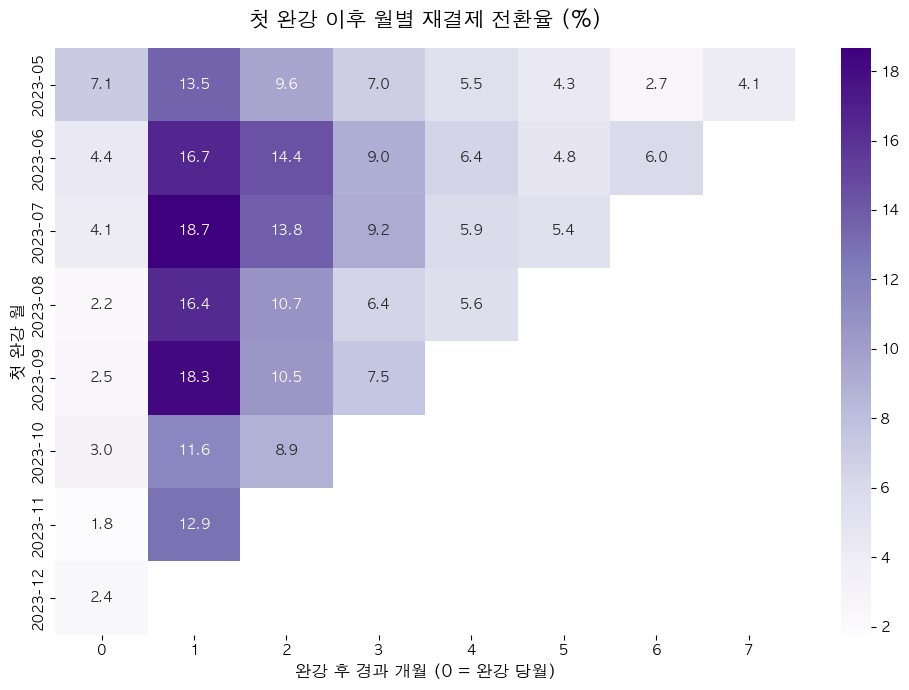

In [ ]:
end['client_event_time'] = pd.to_datetime(end['client_event_time'])
renew['client_event_time'] = pd.to_datetime(renew['client_event_time'])

first_end = end.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_end['end_cohort'] = first_end['client_event_time'].dt.to_period('M')

renew['renew_month'] = renew['client_event_time'].dt.to_period('M')
df = pd.merge(renew[['user_id', 'renew_month']],
              first_end[['user_id', 'end_cohort']],
              on='user_id', how='inner')

df['index'] = (df['renew_month'].dt.year - df['end_cohort'].dt.year) * 12 + \
              (df['renew_month'].dt.month - df['end_cohort'].dt.month)

df = df[df['index'] >= 0]

cohort_counts = df.groupby(['end_cohort', 'index'])['user_id'].nunique().unstack()

cohort_size = first_end.groupby('end_cohort')['user_id'].nunique()
retention = cohort_counts.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(10, 7))

sns.heatmap(retention,
            annot=True,
            fmt='.1f',
            cmap='Purples')

plt.title('첫 완강 이후 월별 재결제 전환율 (%)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('완강 후 경과 개월 (0 = 완강 당월)', fontsize=12)
plt.ylabel('첫 완강 월', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/1706234781.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_end_cont = df_end.groupby('user_id', group_keys=False).apply(filter_continuous)


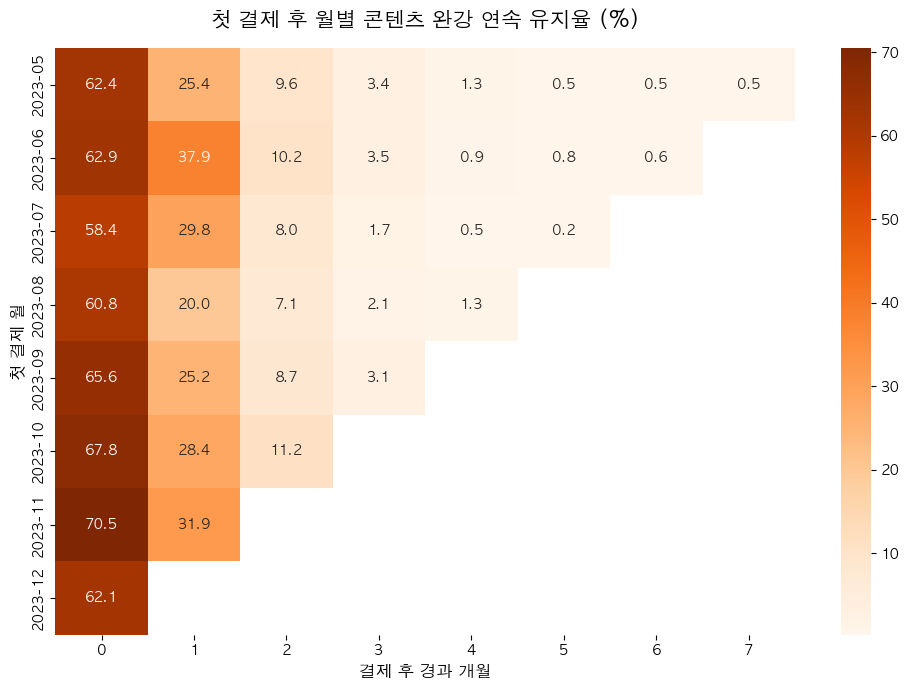

In [ ]:
subscription['client_event_time'] = pd.to_datetime(subscription['client_event_time'], errors='coerce')
end['client_event_time'] = pd.to_datetime(end['client_event_time'], errors='coerce')

subscription = subscription.dropna(subset=['client_event_time'])
end = end.dropna(subset=['client_event_time'])

first_sub = subscription.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_sub['sub_cohort'] = first_sub['client_event_time'].dt.to_period('M')

end['activity_month'] = end['client_event_time'].dt.to_period('M')
df_end = pd.merge(end[['user_id', 'activity_month']], first_sub[['user_id', 'sub_cohort']], on='user_id')

df_end['index'] = (df_end['activity_month'].dt.year - df_end['sub_cohort'].dt.year) * 12 + \
                  (df_end['activity_month'].dt.month - df_end['sub_cohort'].dt.month)
df_end = df_end[df_end['index'] >= 0].drop_duplicates(['user_id', 'index'])

def filter_continuous(group):
    group = group.sort_values('index')
    idx_list = group['index'].tolist()
    continuous_idx = []
    for i, val in enumerate(idx_list):
        if val == i:
            continuous_idx.append(val)
        else:
            break
    return group[group['index'].isin(continuous_idx)]

df_end_cont = df_end.groupby('user_id', group_keys=False).apply(filter_continuous)

cohort_end = df_end_cont.groupby(['sub_cohort', 'index'])['user_id'].nunique().unstack()
cohort_size = first_sub.groupby('sub_cohort')['user_id'].nunique()
retention_end = cohort_end.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(10, 7))
sns.heatmap(retention_end, annot=True, fmt='.1f', cmap='Oranges')
plt.title('첫 결제 후 월별 콘텐츠 완강 연속 유지율 (%)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('결제 후 경과 개월', fontsize=12)
plt.ylabel('첫 결제 월', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/603376085.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cont = df.groupby('user_id', group_keys=False).apply(filter_continuous)


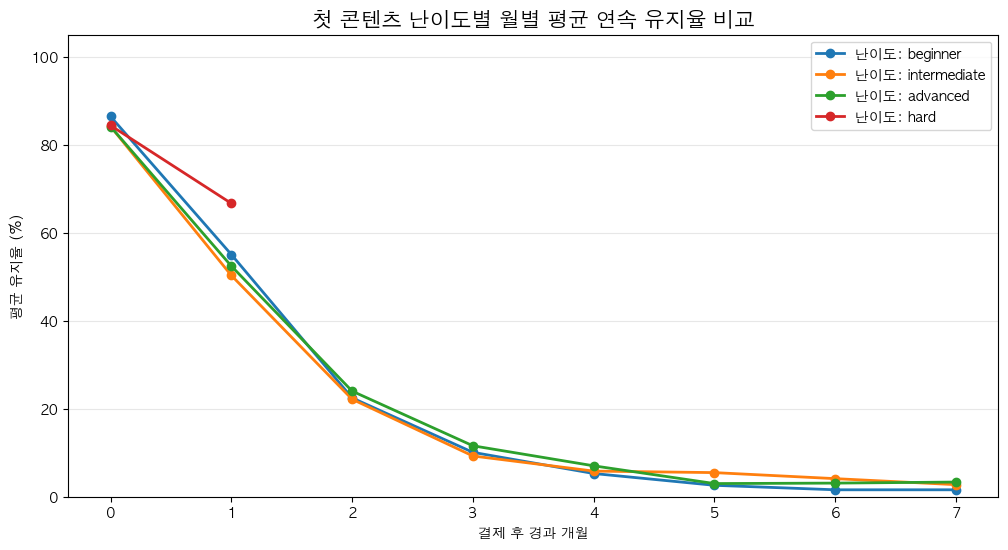

In [ ]:
subscription['client_event_time'] = pd.to_datetime(subscription['client_event_time'])
start['client_event_time'] = pd.to_datetime(start['client_event_time'])
lesson['client_event_time'] = pd.to_datetime(lesson['client_event_time'])

first_start = start.sort_values('client_event_time').drop_duplicates('user_id', keep='first')
user_diff = first_start[['user_id', 'content.difficulty']]

first_subscription = subscription.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_subscription['sub_month'] = first_subscription['client_event_time'].dt.to_period('M')

df_user_info = pd.merge(first_subscription[['user_id', 'sub_month']], user_diff, on='user_id', how='inner')

lesson['activity_month'] = lesson['client_event_time'].dt.to_period('M')
df = pd.merge(lesson[['user_id', 'activity_month']], df_user_info, on='user_id')
df['index'] = (df['activity_month'].dt.year - df['sub_month'].dt.year) * 12 + (df['activity_month'].dt.month - df['sub_month'].dt.month)
df = df[df['index'] >= 0].drop_duplicates(['user_id', 'index'])

def filter_continuous(group):
    group = group.sort_values('index')
    idx_list = group['index'].tolist()
    continuous_idx = []
    for i, val in enumerate(idx_list):
        if val == i:
            continuous_idx.append(val)
        else:
            break
    return group[group['index'].isin(continuous_idx)]

df_cont = df.groupby('user_id', group_keys=False).apply(filter_continuous)

levels = df_user_info['content.difficulty'].unique()

plt.rc('font', family=KOREAN_FONT)
plt.figure(figsize=(12, 6))

for lvl in levels:
    temp = df_cont[df_cont['content.difficulty'] == lvl]
    cohort = temp.groupby(['sub_month', 'index'])['user_id'].nunique().unstack()
    denom = df_user_info[df_user_info['content.difficulty'] == lvl].groupby('sub_month')['user_id'].nunique()
    retention_avg = (cohort.divide(denom, axis=0) * 100).mean()

    plt.plot(retention_avg.index, retention_avg.values, marker='o', label=f'난이도: {lvl}', linewidth=2)

plt.title('첫 콘텐츠 난이도별 월별 평균 연속 유지율 비교', fontsize=15)
plt.xlabel('결제 후 경과 개월')
plt.ylabel('평균 유지율 (%)')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.ylim(0, 105)
plt.show()

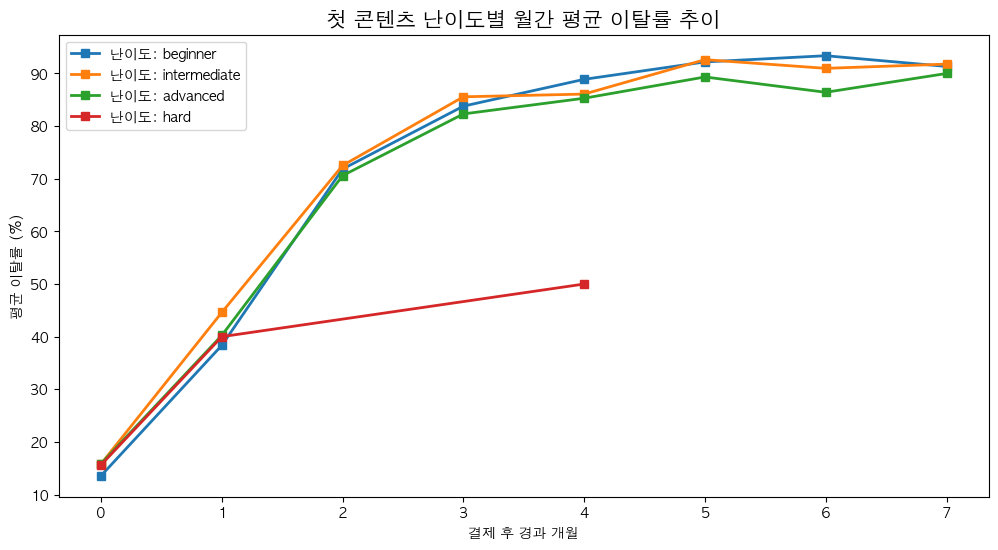

In [ ]:
subscription['client_event_time'] = pd.to_datetime(subscription['client_event_time'])
start['client_event_time'] = pd.to_datetime(start['client_event_time'])
lesson['client_event_time'] = pd.to_datetime(lesson['client_event_time'])

first_sub = subscription.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_sub['sub_month'] = first_sub['client_event_time'].dt.to_period('M')

first_start = start.sort_values('client_event_time').drop_duplicates('user_id', keep='first')
user_diff = first_start[['user_id', 'content.difficulty']]

user_base = pd.merge(first_sub[['user_id', 'sub_month']], user_diff, on='user_id', how='inner')

lesson['activity_month'] = lesson['client_event_time'].dt.to_period('M')
df = pd.merge(lesson[['user_id', 'activity_month']], user_base, on='user_id')
df['index'] = (df['activity_month'].dt.year - df['sub_month'].dt.year) * 12 + (df['activity_month'].dt.month - df['sub_month'].dt.month)
df = df[df['index'] >= 0]

levels = user_base['content.difficulty'].unique()

plt.rc('font', family=KOREAN_FONT)
plt.figure(figsize=(12, 6))

for lvl in levels:
    temp_df = df[df['content.difficulty'] == lvl]
    cohort_pivot = temp_df.groupby(['sub_month', 'index'])['user_id'].nunique().unstack()
    denom = user_base[user_base['content.difficulty'] == lvl].groupby('sub_month')['user_id'].nunique()

    retention_avg = (cohort_pivot.divide(denom, axis=0) * 100).mean()
    churn_rate_avg = 100 - retention_avg

    plt.plot(churn_rate_avg.index, churn_rate_avg.values, marker='s', label=f'난이도: {lvl}', linewidth=2)

plt.title('첫 콘텐츠 난이도별 월간 평균 이탈률 추이', fontsize=15)
plt.xlabel('결제 후 경과 개월')
plt.ylabel('평균 이탈률 (%)')
plt.legend()
plt.show()

/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/1541707295.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=values, palette='viridis')


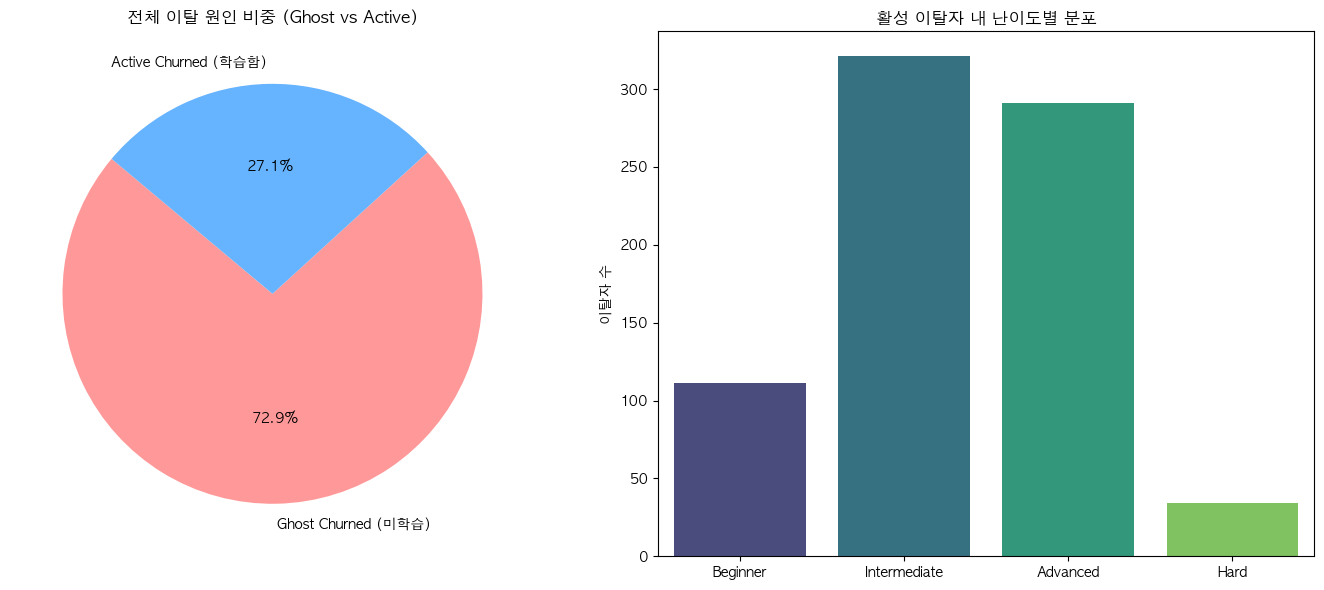

In [ ]:
churn_categories = ['Ghost Churned (미학습)', 'Active Churned (학습함)']
churn_counts = [1752, 652]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.pie(churn_counts, labels=churn_categories, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('전체 이탈 원인 비중 (Ghost vs Active)')

difficulty_data = {'Beginner': 111, 'Intermediate': 321, 'Advanced': 291, 'Hard': 34}
names = list(difficulty_data.keys())
values = list(difficulty_data.values())

plt.subplot(1, 2, 2)
sns.barplot(x=names, y=values, palette='viridis')
plt.title('활성 이탈자 내 난이도별 분포')
plt.ylabel('이탈자 수')

plt.tight_layout()
plt.show()

/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/2994342336.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cont = df.groupby('user_id', group_keys=False).apply(filter_continuous)


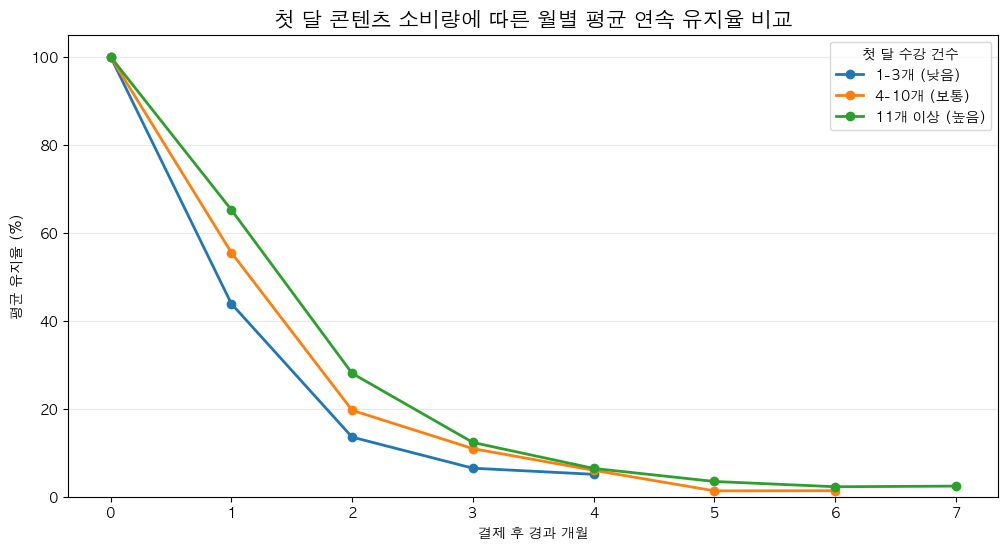

In [ ]:
subscription['client_event_time'] = pd.to_datetime(subscription['client_event_time'])
lesson['client_event_time'] = pd.to_datetime(lesson['lesson_event_time']) if 'lesson_event_time' in lesson.columns else pd.to_datetime(lesson['client_event_time'])

first_sub = subscription.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_sub['sub_month'] = first_sub['client_event_time'].dt.to_period('M')

lesson['activity_month'] = lesson['client_event_time'].dt.to_period('M')
df = pd.merge(lesson, first_sub[['user_id', 'sub_month']], on='user_id')
df['index'] = (df['activity_month'].dt.year - df['sub_month'].dt.year) * 12 + (df['activity_month'].dt.month - df['sub_month'].dt.month)

month0_activity = df[df['index'] == 0].groupby('user_id').size().reset_index(name='cnt')

def categorize(cnt):
    if cnt <= 3: return '1-3개 (낮음)'
    elif cnt <= 10: return '4-10개 (보통)'
    else: return '11개 이상 (높음)'

month0_activity['intensity'] = month0_activity['cnt'].apply(categorize)
user_intensity = month0_activity[['user_id', 'intensity']]

df = pd.merge(df, user_intensity, on='user_id')
df = df[df['index'] >= 0].drop_duplicates(['user_id', 'index'])

def filter_continuous(group):
    group = group.sort_values('index')
    idx_list = group['index'].tolist()
    continuous_idx = []
    for i, val in enumerate(idx_list):
        if val == i:
            continuous_idx.append(val)
        else:
            break
    return group[group['index'].isin(continuous_idx)]

df_cont = df.groupby('user_id', group_keys=False).apply(filter_continuous)

plt.rc('font', family=KOREAN_FONT)
plt.figure(figsize=(12, 6))

intensities = ['1-3개 (낮음)', '4-10개 (보통)', '11개 이상 (높음)']
for level in intensities:
    temp_df = df_cont[df_cont['intensity'] == level]
    cohort_pivot = temp_df.groupby(['sub_month', 'index'])['user_id'].nunique().unstack()
    denom = user_intensity[user_intensity['intensity'] == level].merge(first_sub, on='user_id').groupby('sub_month')['user_id'].nunique()
    retention_avg = (cohort_pivot.divide(denom, axis=0) * 100).mean()
    plt.plot(retention_avg.index, retention_avg.values, marker='o', label=level, linewidth=2)

plt.title('첫 달 콘텐츠 소비량에 따른 월별 평균 연속 유지율 비교', fontsize=15)
plt.xlabel('결제 후 경과 개월')
plt.ylabel('평균 유지율 (%)')
plt.legend(title='첫 달 수강 건수')
plt.grid(True, axis='y', alpha=0.3)
plt.ylim(0, 105)
plt.show()

/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/4169554384.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_revenue, x='sales_month_str', y='paid_amount', palette='viridis')


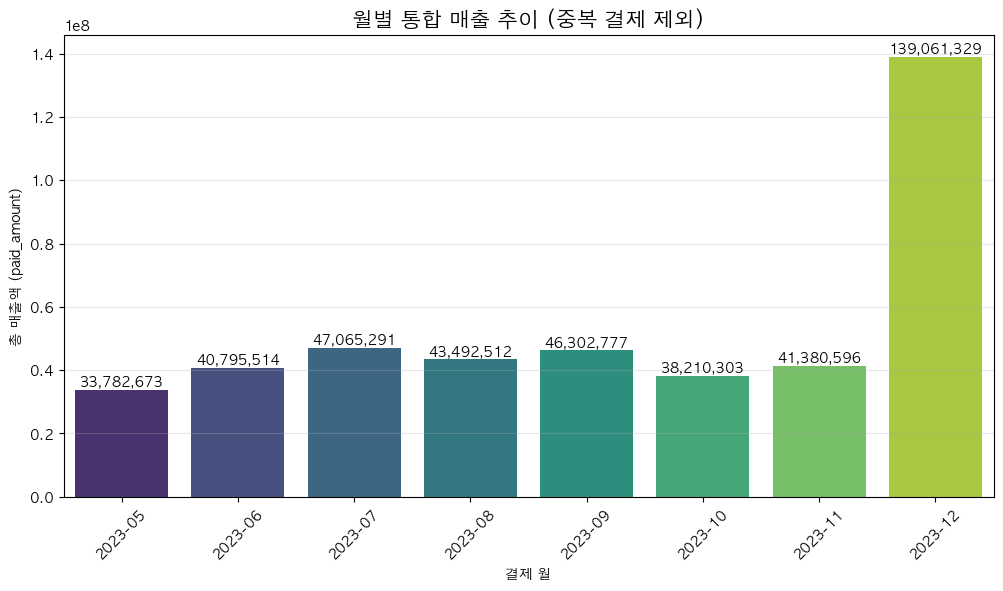

  sales_month_str  paid_amount
0         2023-05     33782673
1         2023-06     40795514
2         2023-07     47065291
3         2023-08     43492512
4         2023-09     46302777
5         2023-10     38210303
6         2023-11     41380596
7         2023-12    139061329


In [ ]:
def clean_df(df):
    df = df.copy()
    df.columns = [c.replace('plan.price', 'plan_price').lower() for c in df.columns]
    df['client_event_time'] = pd.to_datetime(df['client_event_time'])
    df['sales_month'] = df['client_event_time'].dt.to_period('M')
    return df

subscription_sales = clean_df(subscription_base)
renew_sales = clean_df(renew_base)
resubscribe_sales = clean_df(resubscribe_base)

sales_columns = ['user_id', 'sales_month', 'paid_amount']
total_sales = pd.concat([
    subscription_sales[sales_columns],
    renew_sales[sales_columns],
    resubscribe_sales[sales_columns]
], axis=0)

total_sales = total_sales.drop_duplicates(subset=['user_id', 'sales_month'], keep='last')

monthly_revenue = total_sales.groupby('sales_month')['paid_amount'].sum().reset_index()
monthly_revenue['sales_month_str'] = monthly_revenue['sales_month'].astype(str)

plt.rc('font', family=KOREAN_FONT)
plt.figure(figsize=(12, 6))

sns.barplot(data=monthly_revenue, x='sales_month_str', y='paid_amount', palette='viridis')

plt.title('월별 통합 매출 추이 (중복 결제 제외)', fontsize=15)
plt.xlabel('결제 월')
plt.ylabel('총 매출액 (paid_amount)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(monthly_revenue['paid_amount']):
    plt.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontsize=10)

plt.show()

print(monthly_revenue[['sales_month_str', 'paid_amount']])

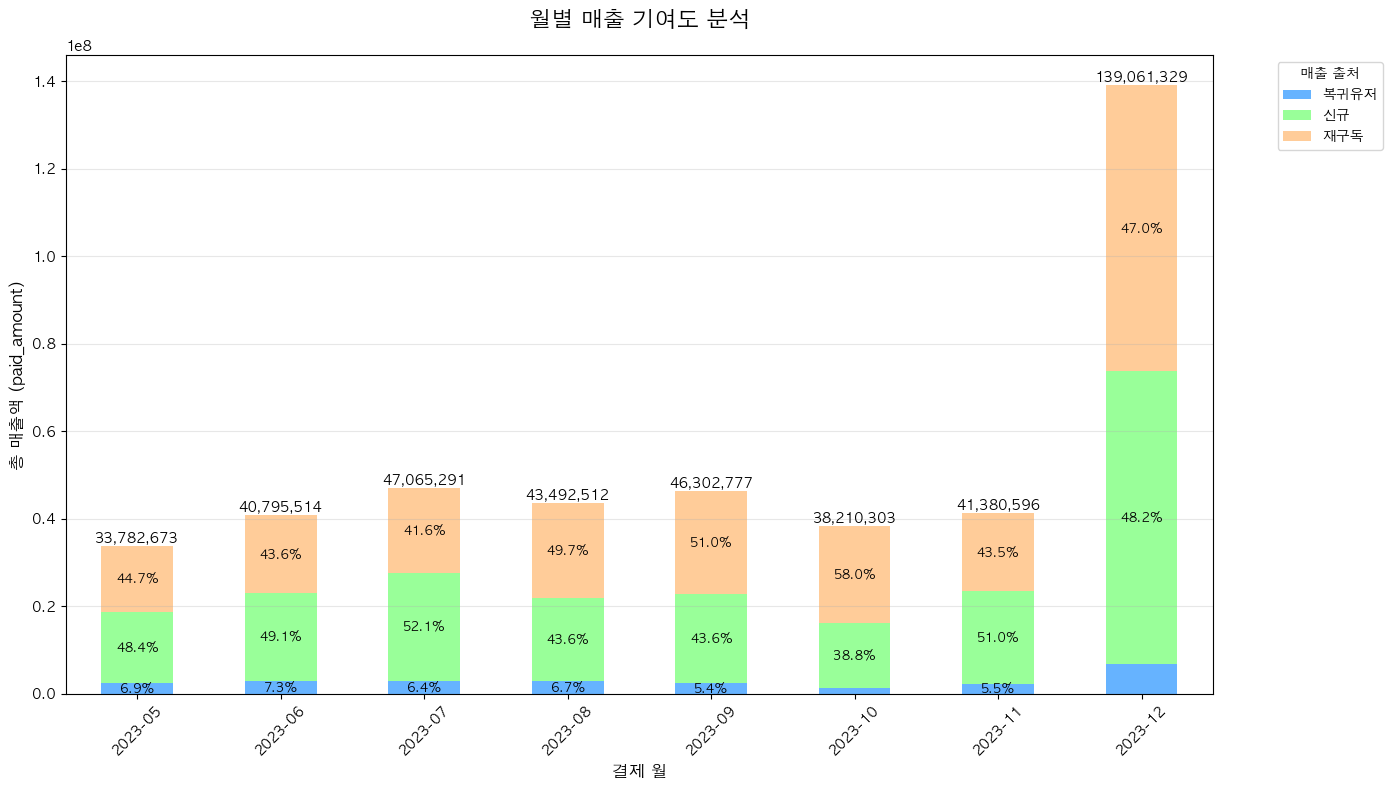

월별 매출 기여도 요약 (단위: paid_amount 합계)
source          복귀유저        신규       재구독
sales_month                             
2023-05      2327440  16365496  15089737
2023-06      2976960  20020760  17797794
2023-07      2992880  24502032  19570379
2023-08      2906520  18960849  21625143
2023-09      2499828  20181000  23621949
2023-10      1205962  14840140  22164201
2023-11      2279980  21086156  18014460
2023-12      6670480  67009176  65381673


In [ ]:
def preprocess(df, label):
    df = df.copy()
    df.columns = [c.replace('plan.price', 'plan_price').lower() for c in df.columns]
    df['client_event_time'] = pd.to_datetime(df['client_event_time'])
    df['sales_month'] = df['client_event_time'].dt.to_period('M')
    df['source'] = label
    return df[['user_id', 'sales_month', 'paid_amount', 'source']]

sub_sales = preprocess(subscription_base, '신규')
renew_sales = preprocess(renew_base, '재구독')
resub_sales = preprocess(resubscribe_base, '복귀유저')

total_sales = pd.concat([sub_sales, renew_sales, resub_sales], axis=0)
total_sales = total_sales.drop_duplicates(subset=['user_id', 'sales_month'], keep='last')

revenue_contribution = total_sales.groupby(['sales_month', 'source'])['paid_amount'].sum().unstack().fillna(0)
revenue_contribution.index = revenue_contribution.index.astype(str)

plt.rc('font', family=KOREAN_FONT)
plt.rcParams['axes.unicode_minus'] = False

colors = ['#66b3ff', '#99ff99', '#ffcc99']
ax = revenue_contribution.plot(kind='bar', stacked=True, figsize=(14, 8), color=colors)

plt.title('월별 매출 기여도 분석', fontsize=16, pad=20)
plt.xlabel('결제 월', fontsize=12)
plt.ylabel('총 매출액 (paid_amount)', fontsize=12)
plt.legend(title='매출 출처', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for i, (idx, row) in enumerate(revenue_contribution.iterrows()):
    total = row.sum()
    if total > 0:
        plt.text(i, total, f'{int(total):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        current_y = 0
        for val in row:
            if val > total * 0.05:
                plt.text(i, current_y + val/2, f'{(val/total)*100:.1f}%', ha='center', va='center', fontsize=9)
            current_y += val

plt.tight_layout()
plt.show()

print("월별 매출 기여도 요약 (단위: paid_amount 합계)")
print(revenue_contribution)

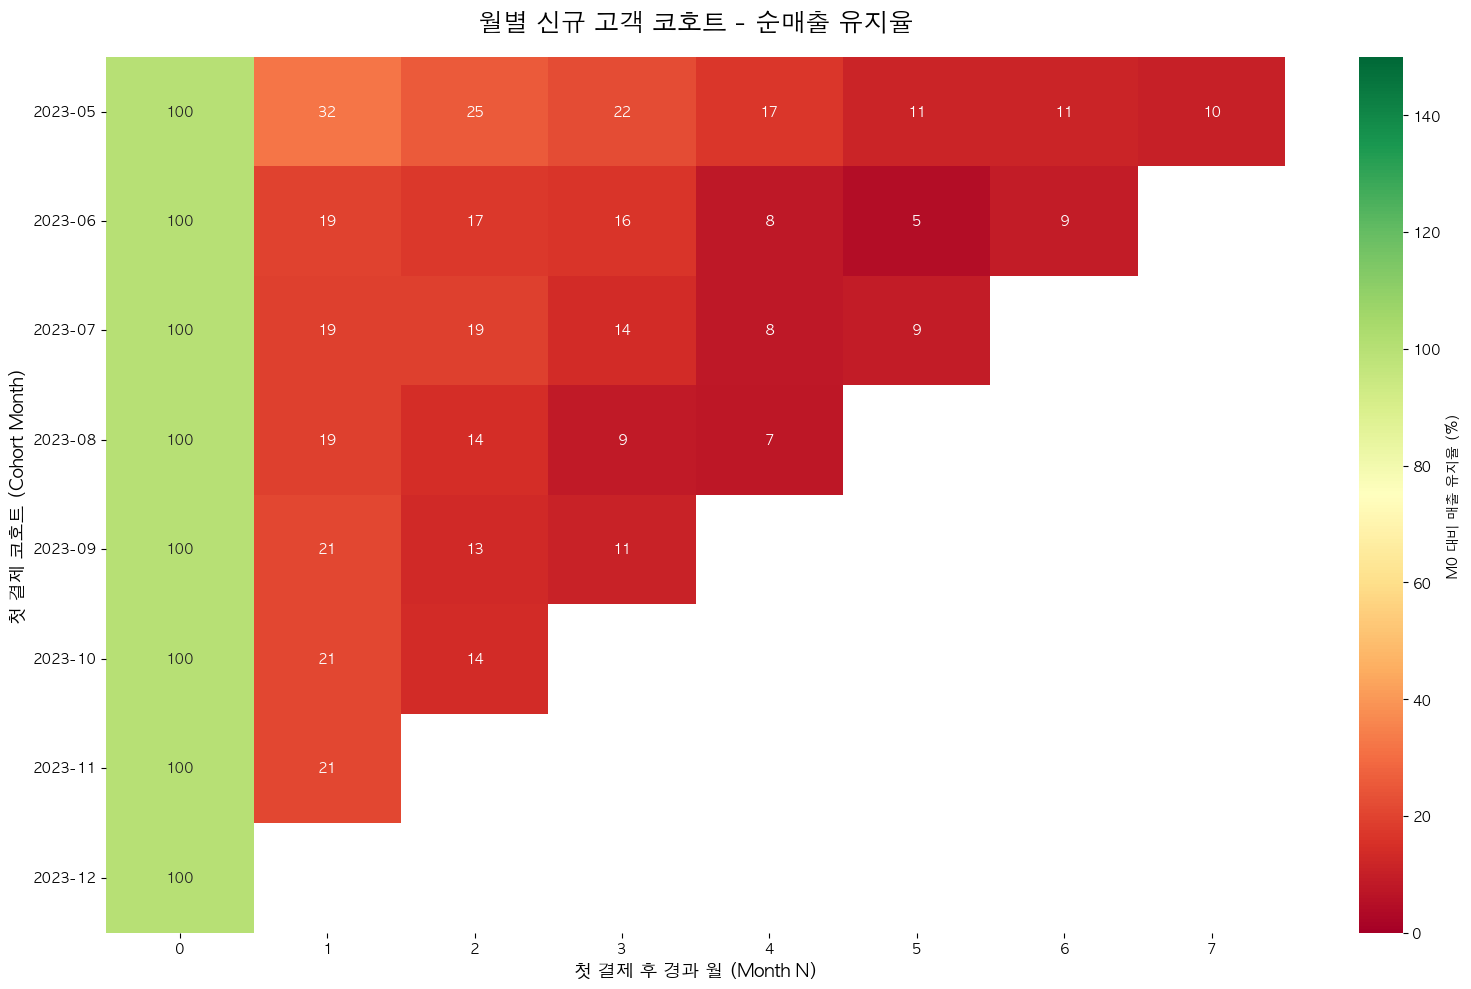

코호트(첫 결제월) 첫 달 총 결제액(원)
   2023-05   34,157,313
   2023-06   30,371,294
   2023-07   33,822,803
   2023-08   25,389,038
   2023-09   25,202,763
   2023-10   18,993,221
   2023-11   25,460,884
   2023-12  119,162,742


In [ ]:
AMOUNT_COL = 'paid_amount'

subscription_sales = subscription_base.copy()
renew_sales = renew_base.copy()
resubscribe_sales = resubscribe_base.copy()

pay_df = pd.concat([subscription_sales, renew_sales, resubscribe_sales], ignore_index=True)

pay_df['client_event_time'] = pd.to_datetime(pay_df['client_event_time'])
pay_df['order_month'] = pay_df['client_event_time'].dt.to_period('M')

pay_df['cohort_month'] = pay_df.groupby('user_id')['order_month'].transform('min')

pay_df['cohort_index'] = (pay_df['order_month'].dt.year - pay_df['cohort_month'].dt.year) * 12 +                          (pay_df['order_month'].dt.month - pay_df['cohort_month'].dt.month)

cohort_data = pay_df.groupby(['cohort_month', 'cohort_index'])[AMOUNT_COL].sum().reset_index()

cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values=AMOUNT_COL)

cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

retention_matrix.index = retention_matrix.index.astype(str)

plt.figure(figsize=(16, 10))

sns.heatmap(data=retention_matrix,
            annot=True,
            fmt='.0f',
            cmap='RdYlGn',
            vmin=0, vmax=150,
            cbar_kws={'label': 'M0 대비 매출 유지율 (%)'})

plt.title('월별 신규 고객 코호트 - 순매출 유지율', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('첫 결제 후 경과 월 (Month N)', fontsize=13)
plt.ylabel('첫 결제 코호트 (Cohort Month)', fontsize=13)

plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

raw_sales = cohort_pivot.iloc[:, 0].reset_index()
raw_sales.columns = ['코호트(첫 결제월)', '첫 달 총 결제액(원)']
raw_sales['첫 달 총 결제액(원)'] = raw_sales['첫 달 총 결제액(원)'].apply(lambda x: f"{x:,.0f}")
print(raw_sales.to_string(index=False))

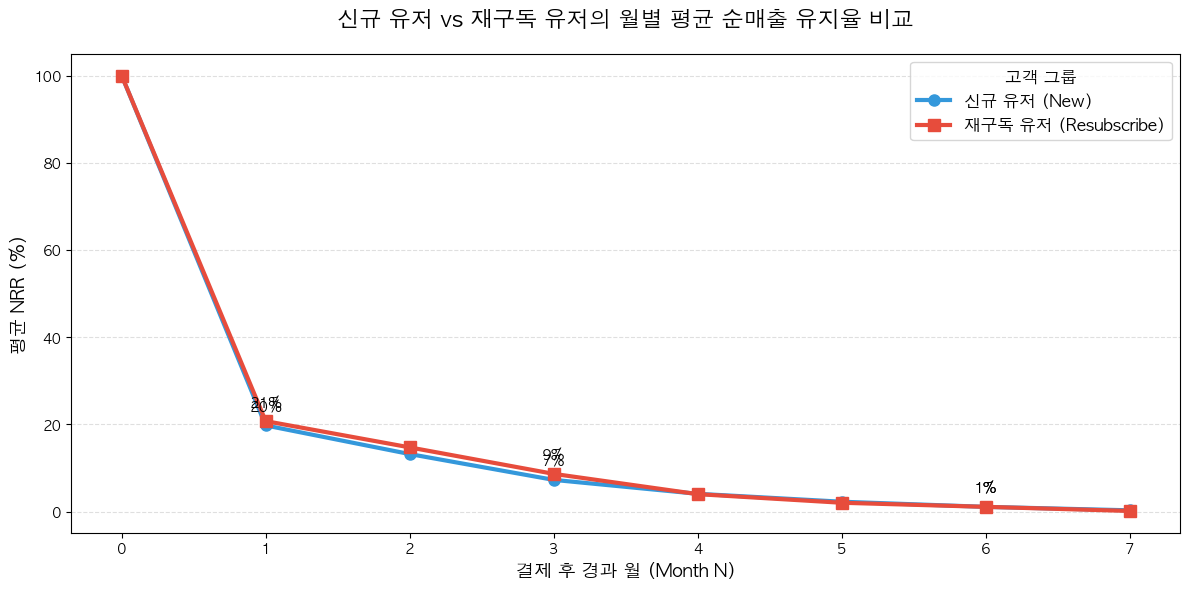

In [ ]:
AMOUNT_COL = 'paid_amount'

subscription_nrr = subscription_base.copy()
renew_nrr = renew_base.copy()
resubscribe_nrr = resubscribe_base.copy()

sub_m0 = subscription_nrr[['user_id', 'client_event_time', AMOUNT_COL]].copy()
sub_m0['user_type'] = '신규 유저 (New)'

resub_m0 = resubscribe_nrr[['user_id', 'client_event_time', AMOUNT_COL]].copy()
resub_m0['user_type'] = '재구독 유저 (Resubscribe)'

cohort_base = pd.concat([sub_m0, resub_m0], ignore_index=True)
cohort_base['cohort_month'] = pd.to_datetime(cohort_base['client_event_time']).dt.to_period('M')
cohort_base = cohort_base.sort_values('client_event_time').drop_duplicates(['user_id', 'user_type'], keep='first')

renew_df = renew_nrr[['user_id', 'client_event_time', AMOUNT_COL]].copy()
renew_df.rename(columns={'client_event_time': 'renew_time', AMOUNT_COL: 'renew_amount'}, inplace=True)
renew_df['renew_time'] = pd.to_datetime(renew_df['renew_time'])

m0_sales = cohort_base.groupby(['user_type', 'cohort_month'])[AMOUNT_COL].sum().reset_index()
m0_sales['index'] = 0

merged = pd.merge(
    cohort_base[['user_id', 'user_type', 'cohort_month', 'client_event_time']],
    renew_df,
    on='user_id',
    how='inner'
)
merged = merged[merged['renew_time'] > merged['client_event_time']]
merged['renew_month'] = merged['renew_time'].dt.to_period('M')
merged['index'] = (merged['renew_month'].dt.year - merged['cohort_month'].dt.year) * 12 +                   (merged['renew_month'].dt.month - merged['cohort_month'].dt.month)

merged = merged[(merged['index'] > 0) & (merged['index'] <= 12)]
m_plus_sales = merged.groupby(['user_type', 'cohort_month', 'index'])['renew_amount'].sum().reset_index()
m_plus_sales.rename(columns={'renew_amount': AMOUNT_COL}, inplace=True)

final_sales = pd.concat([m0_sales, m_plus_sales], ignore_index=True)

cohort_pivot = final_sales.pivot_table(index=['user_type', 'cohort_month'], columns='index', values=AMOUNT_COL, fill_value=0)
nrr_matrix = cohort_pivot.divide(cohort_pivot[0], axis=0) * 100

avg_nrr = nrr_matrix.groupby('user_type').mean().T

plt.figure(figsize=(12, 6))
colors = {'신규 유저 (New)': '#3498db', '재구독 유저 (Resubscribe)': '#e74c3c'}
markers = {'신규 유저 (New)': 'o', '재구독 유저 (Resubscribe)': 's'}

for u_type in avg_nrr.columns:
    plt.plot(avg_nrr.index, avg_nrr[u_type], marker=markers[u_type], color=colors[u_type], linewidth=3, markersize=8, label=u_type)

plt.title('신규 유저 vs 재구독 유저의 월별 평균 순매출 유지율 비교', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('결제 후 경과 월 (Month N)', fontsize=13)
plt.ylabel('평균 NRR (%)', fontsize=13)
plt.xticks(avg_nrr.index)
plt.grid(True, axis='y', alpha=0.4, linestyle='--')
plt.legend(fontsize=12, title='고객 그룹', title_fontsize=12)

for u_type in avg_nrr.columns:
    for x, y in zip(avg_nrr.index, avg_nrr[u_type]):
        if pd.notna(y) and x in [1, 3, 6, 12]:
            plt.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

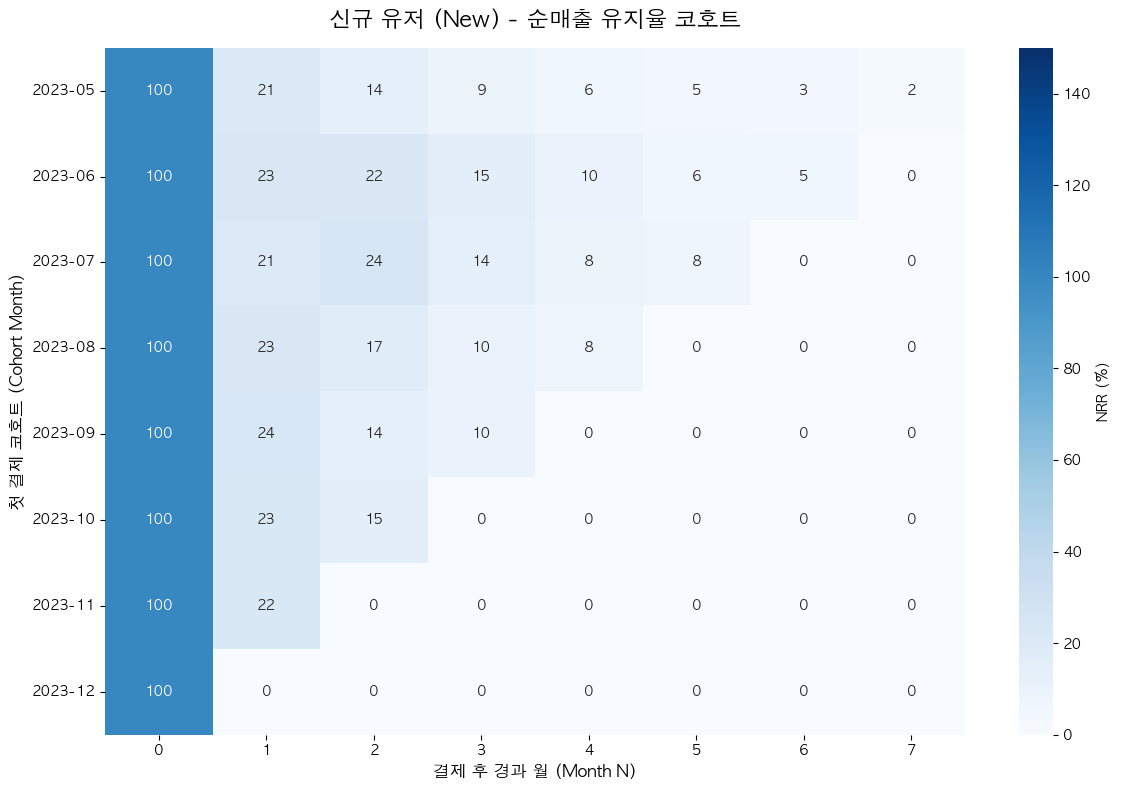

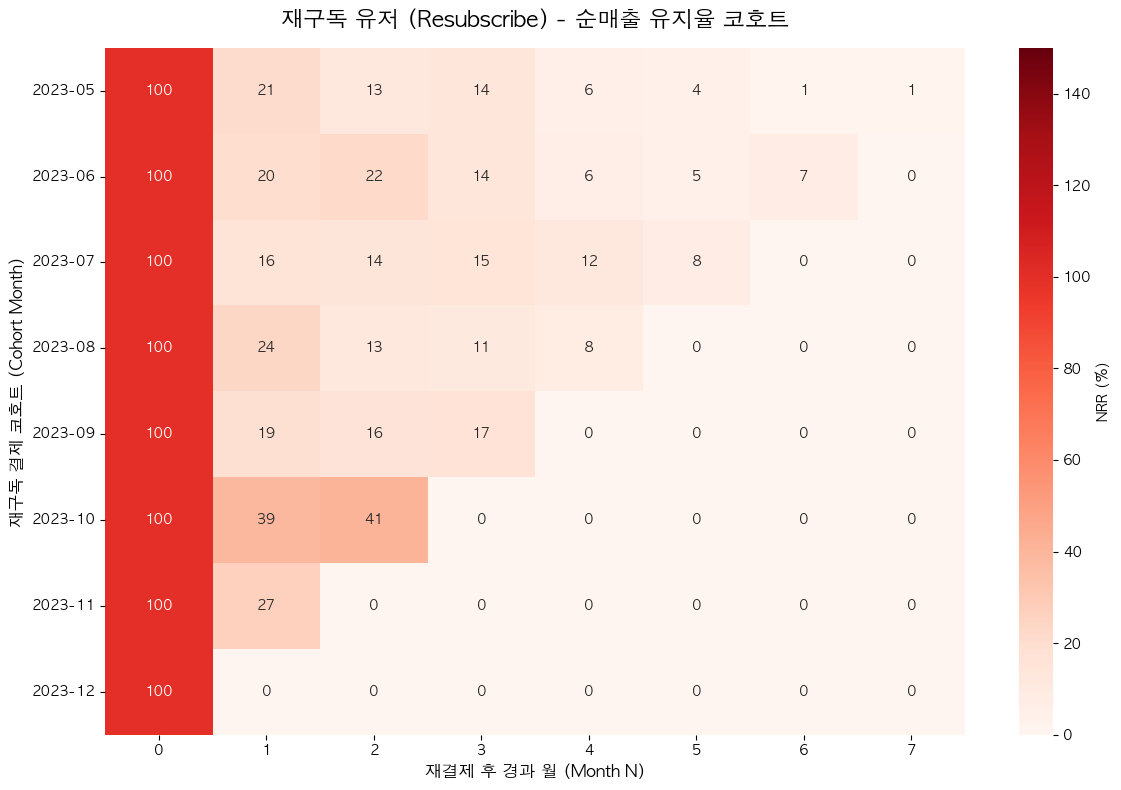

In [ ]:
AMOUNT_COL = 'paid_amount'

subscription_nrr = subscription_base.copy()
renew_nrr = renew_base.copy()
resubscribe_nrr = resubscribe_base.copy()

sub_m0 = subscription_nrr[['user_id', 'client_event_time', AMOUNT_COL]].copy()
sub_m0['user_type'] = '신규 유저 (New)'

resub_m0 = resubscribe_nrr[['user_id', 'client_event_time', AMOUNT_COL]].copy()
resub_m0['user_type'] = '재구독 유저 (Resubscribe)'

cohort_base = pd.concat([sub_m0, resub_m0], ignore_index=True)
cohort_base['cohort_month'] = pd.to_datetime(cohort_base['client_event_time']).dt.to_period('M')
cohort_base = cohort_base.sort_values('client_event_time').drop_duplicates(['user_id', 'user_type'], keep='first')

renew_df = renew_nrr[['user_id', 'client_event_time', AMOUNT_COL]].copy()
renew_df.rename(columns={'client_event_time': 'renew_time', AMOUNT_COL: 'renew_amount'}, inplace=True)
renew_df['renew_time'] = pd.to_datetime(renew_df['renew_time'])

m0_sales = cohort_base.groupby(['user_type', 'cohort_month'])[AMOUNT_COL].sum().reset_index()
m0_sales['index'] = 0

merged = pd.merge(
    cohort_base[['user_id', 'user_type', 'cohort_month', 'client_event_time']],
    renew_df,
    on='user_id',
    how='inner'
)
merged = merged[merged['renew_time'] > merged['client_event_time']]
merged['renew_month'] = merged['renew_time'].dt.to_period('M')
merged['index'] = (merged['renew_month'].dt.year - merged['cohort_month'].dt.year) * 12 +                   (merged['renew_month'].dt.month - merged['cohort_month'].dt.month)

merged = merged[(merged['index'] > 0) & (merged['index'] <= 12)]
m_plus_sales = merged.groupby(['user_type', 'cohort_month', 'index'])['renew_amount'].sum().reset_index()
m_plus_sales.rename(columns={'renew_amount': AMOUNT_COL}, inplace=True)

final_sales = pd.concat([m0_sales, m_plus_sales], ignore_index=True)

cohort_pivot = final_sales.pivot_table(index=['user_type', 'cohort_month'], columns='index', values=AMOUNT_COL, fill_value=0)
nrr_matrix = cohort_pivot.divide(cohort_pivot[0], axis=0) * 100

new_nrr = nrr_matrix.loc['신규 유저 (New)'].copy()
resub_nrr = nrr_matrix.loc['재구독 유저 (Resubscribe)'].copy()

new_nrr.index = new_nrr.index.astype(str)
resub_nrr.index = resub_nrr.index.astype(str)

plt.figure(figsize=(12, 8))
sns.heatmap(new_nrr, annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=150,
            cbar_kws={'label': 'NRR (%)'})
plt.title('신규 유저 (New) - 순매출 유지율 코호트', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('결제 후 경과 월 (Month N)', fontsize=12)
plt.ylabel('첫 결제 코호트 (Cohort Month)', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(resub_nrr, annot=True, fmt='.0f', cmap='Reds', vmin=0, vmax=150,
            cbar_kws={'label': 'NRR (%)'})
plt.title('재구독 유저 (Resubscribe) - 순매출 유지율 코호트', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('재결제 후 경과 월 (Month N)', fontsize=12)
plt.ylabel('재구독 결제 코호트 (Cohort Month)', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

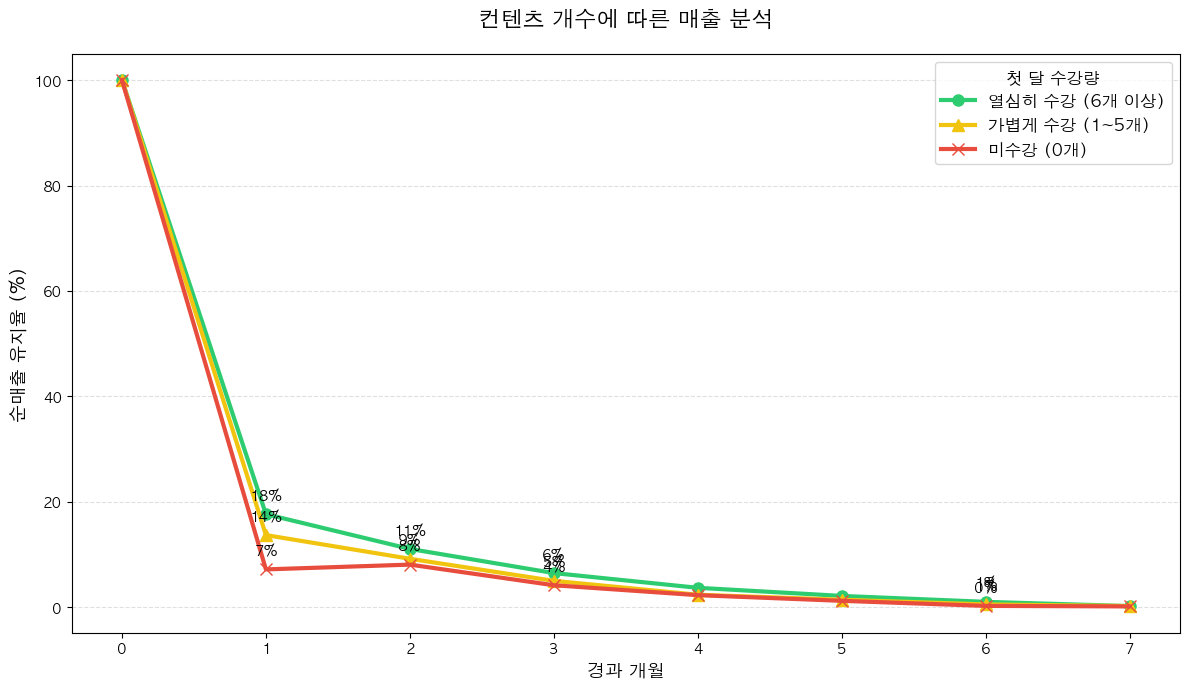

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rc('font', family=KOREAN_FONT)

AMOUNT_COL = 'paid_amount'

subscription['client_event_time'] = pd.to_datetime(subscription['client_event_time'], errors='coerce')
renew['client_event_time'] = pd.to_datetime(renew['client_event_time'], errors='coerce')

first_sub = subscription.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_sub['sub_month'] = first_sub['client_event_time'].dt.to_period('M')

lesson_time_col = 'lesson_event_time' if 'lesson_event_time' in lesson.columns else 'client_event_time'
lesson[lesson_time_col] = pd.to_datetime(lesson[lesson_time_col], errors='coerce')
lesson['activity_month'] = lesson[lesson_time_col].dt.to_period('M')

merged_lesson = pd.merge(first_sub[['user_id', 'sub_month']],
                         lesson[['user_id', 'activity_month']],
                         on='user_id', how='left')

m0_activity = merged_lesson[merged_lesson['sub_month'] == merged_lesson['activity_month']]
user_lesson_cnt = m0_activity.groupby('user_id').size().reset_index(name='lesson_cnt')

base_users = pd.merge(first_sub, user_lesson_cnt, on='user_id', how='left').fillna({'lesson_cnt': 0})

def assign_lesson_group(cnt):
    if cnt == 0: return '미수강 (0개)'
    elif cnt <= 5: return '가볍게 수강 (1~5개)'
    else: return '열심히 수강 (6개 이상)'

base_users['user_group'] = base_users['lesson_cnt'].apply(assign_lesson_group)

m0_sales = base_users.groupby('user_group')[AMOUNT_COL].sum().reset_index()
m0_sales['index'] = 0

renew_df = renew[['user_id', 'client_event_time', AMOUNT_COL]].copy()
renew_df.rename(columns={'client_event_time': 'renew_time', AMOUNT_COL: 'renew_amount'}, inplace=True)

merged_renew = pd.merge(base_users[['user_id', 'user_group', 'sub_month', 'client_event_time']], renew_df, on='user_id', how='inner')
merged_renew = merged_renew[merged_renew['renew_time'] > merged_renew['client_event_time']]
merged_renew['renew_month'] = merged_renew['renew_time'].dt.to_period('M')

merged_renew['index'] = (merged_renew['renew_month'].dt.year - merged_renew['sub_month'].dt.year) * 12 + \
                        (merged_renew['renew_month'].dt.month - merged_renew['sub_month'].dt.month)

merged_renew = merged_renew[(merged_renew['index'] > 0) & (merged_renew['index'] <= 12)]
m_plus_sales = merged_renew.groupby(['user_group', 'index'])['renew_amount'].sum().reset_index()
m_plus_sales.rename(columns={'renew_amount': AMOUNT_COL}, inplace=True)

final_sales = pd.concat([m0_sales, m_plus_sales], ignore_index=True)

cohort_pivot = final_sales.pivot_table(index='user_group', columns='index', values=AMOUNT_COL, fill_value=0)
nrr_matrix = cohort_pivot.divide(cohort_pivot[0], axis=0) * 100
nrr_matrix.replace(0, np.nan, inplace=True)

plt.figure(figsize=(12, 7))
colors = {'미수강 (0개)': '#e74c3c', '가볍게 수강 (1~5개)': '#f1c40f', '열심히 수강 (6개 이상)': '#2ecc71'}
markers = {'미수강 (0개)': 'x', '가볍게 수강 (1~5개)': '^', '열심히 수강 (6개 이상)': 'o'}

group_order = ['열심히 수강 (6개 이상)', '가볍게 수강 (1~5개)', '미수강 (0개)']

for u_type in group_order:
    if u_type in nrr_matrix.index:
        plt.plot(nrr_matrix.columns, nrr_matrix.loc[u_type], marker=markers[u_type], color=colors[u_type], linewidth=3, markersize=8, label=u_type)

plt.title('컨텐츠 개수에 따른 매출 분석', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('경과 개월', fontsize=13)
plt.ylabel('순매출 유지율 (%)', fontsize=13)
plt.xticks(nrr_matrix.columns)
plt.grid(True, axis='y', alpha=0.4, linestyle='--')
plt.legend(fontsize=12, title='첫 달 수강량', title_fontsize=12)

for u_type in group_order:
    if u_type in nrr_matrix.index:
        for x, y in zip(nrr_matrix.columns, nrr_matrix.loc[u_type]):
            if pd.notna(y) and x in [1, 2, 3, 6, 12]:
                plt.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

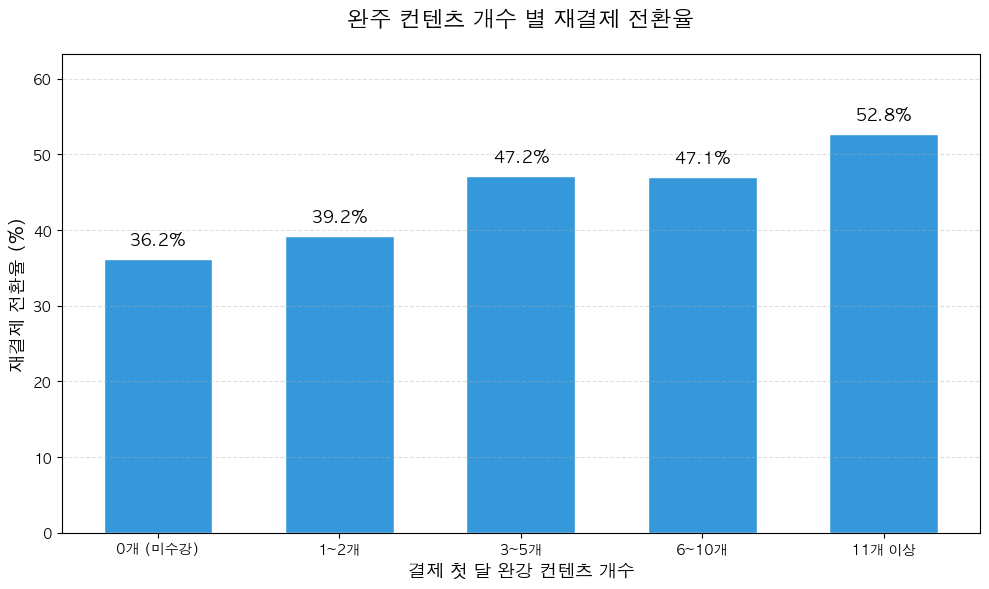

In [ ]:
first_sub = subscription.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_sub['sub_month'] = first_sub['client_event_time'].dt.to_period('M')

lesson_time_col = 'lesson_event_time' if 'lesson_event_time' in lesson.columns else 'client_event_time'
lesson[lesson_time_col] = pd.to_datetime(lesson[lesson_time_col], errors='coerce')
lesson['activity_month'] = lesson[lesson_time_col].dt.to_period('M')

merged_lesson = pd.merge(first_sub[['user_id', 'sub_month']],
                         lesson[['user_id', 'activity_month']],
                         on='user_id', how='left')

m0_activity = merged_lesson[merged_lesson['sub_month'] == merged_lesson['activity_month']]
user_lesson_cnt = m0_activity.groupby('user_id').size().reset_index(name='lesson_cnt')

base_users = pd.merge(first_sub[['user_id']], user_lesson_cnt, on='user_id', how='left').fillna({'lesson_cnt': 0})

def assign_lesson_group(cnt):
    if cnt == 0: return '0개 (미수강)'
    elif cnt <= 2: return '1~2개'
    elif cnt <= 5: return '3~5개'
    elif cnt <= 10: return '6~10개'
    else: return '11개 이상'

base_users['lesson_group'] = base_users['lesson_cnt'].apply(assign_lesson_group)

renew_users = set(renew['user_id'].unique())
base_users['is_renewed'] = base_users['user_id'].isin(renew_users).astype(int)

conv_rate = base_users.groupby('lesson_group')['is_renewed'].agg(['count', 'mean']).reset_index()
conv_rate['conversion_rate'] = conv_rate['mean'] * 100

group_order = ['0개 (미수강)', '1~2개', '3~5개', '6~10개', '11개 이상']
conv_rate['lesson_group'] = pd.Categorical(conv_rate['lesson_group'], categories=group_order, ordered=True)
conv_rate = conv_rate.sort_values('lesson_group')

plt.figure(figsize=(10, 6))
bars = plt.bar(conv_rate['lesson_group'], conv_rate['conversion_rate'], color='#3498db', edgecolor='white', width=0.6)

plt.title('완주 컨텐츠 개수 별 재결제 전환율', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('결제 첫 달 완강 컨텐츠 개수', fontsize=13)
plt.ylabel('재결제 전환율 (%)', fontsize=13)
plt.ylim(0, max(conv_rate['conversion_rate']) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

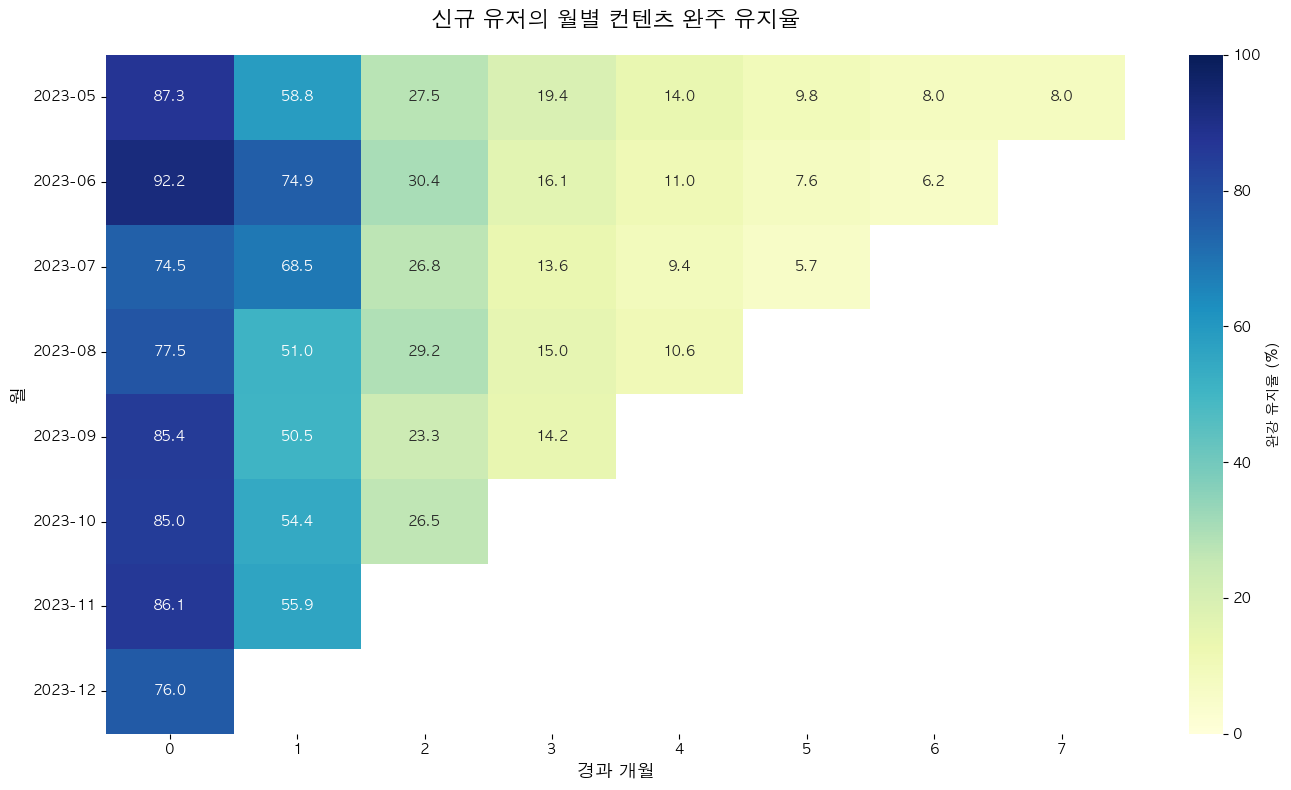

In [ ]:
first_sub = subscription.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_sub['cohort_month'] = first_sub['client_event_time'].dt.to_period('M')
cohort_sizes = first_sub.groupby('cohort_month')['user_id'].nunique().reset_index(name='cohort_size')

lesson_time_col = 'lesson_event_time' if 'lesson_event_time' in lesson.columns else 'client_event_time'
lesson_df = lesson.copy()
lesson_df[lesson_time_col] = pd.to_datetime(lesson_df[lesson_time_col], errors='coerce')
lesson_df['activity_month'] = lesson_df[lesson_time_col].dt.to_period('M')

merged = pd.merge(lesson_df[['user_id', 'activity_month']], first_sub[['user_id', 'cohort_month']], on='user_id', how='inner')

merged['month_index'] = (merged['activity_month'].dt.year - merged['cohort_month'].dt.year) * 12 + \
                        (merged['activity_month'].dt.month - merged['cohort_month'].dt.month)

merged = merged[merged['month_index'] >= 0]

active_users = merged.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index(name='active_users')

retention_df = pd.merge(active_users, cohort_sizes, on='cohort_month')
retention_df['retention_rate'] = (retention_df['active_users'] / retention_df['cohort_size']) * 100

cohort_pivot = retention_df.pivot_table(index='cohort_month', columns='month_index', values='retention_rate')
cohort_pivot.index = cohort_pivot.index.astype(str)

plt.figure(figsize=(14, 8))
sns.heatmap(cohort_pivot, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100,
            cbar_kws={'label': '완강 유지율 (%)'})

plt.title('신규 유저의 월별 컨텐츠 완주 유지율', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('경과 개월', fontsize=13)
plt.ylabel('월', fontsize=13)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

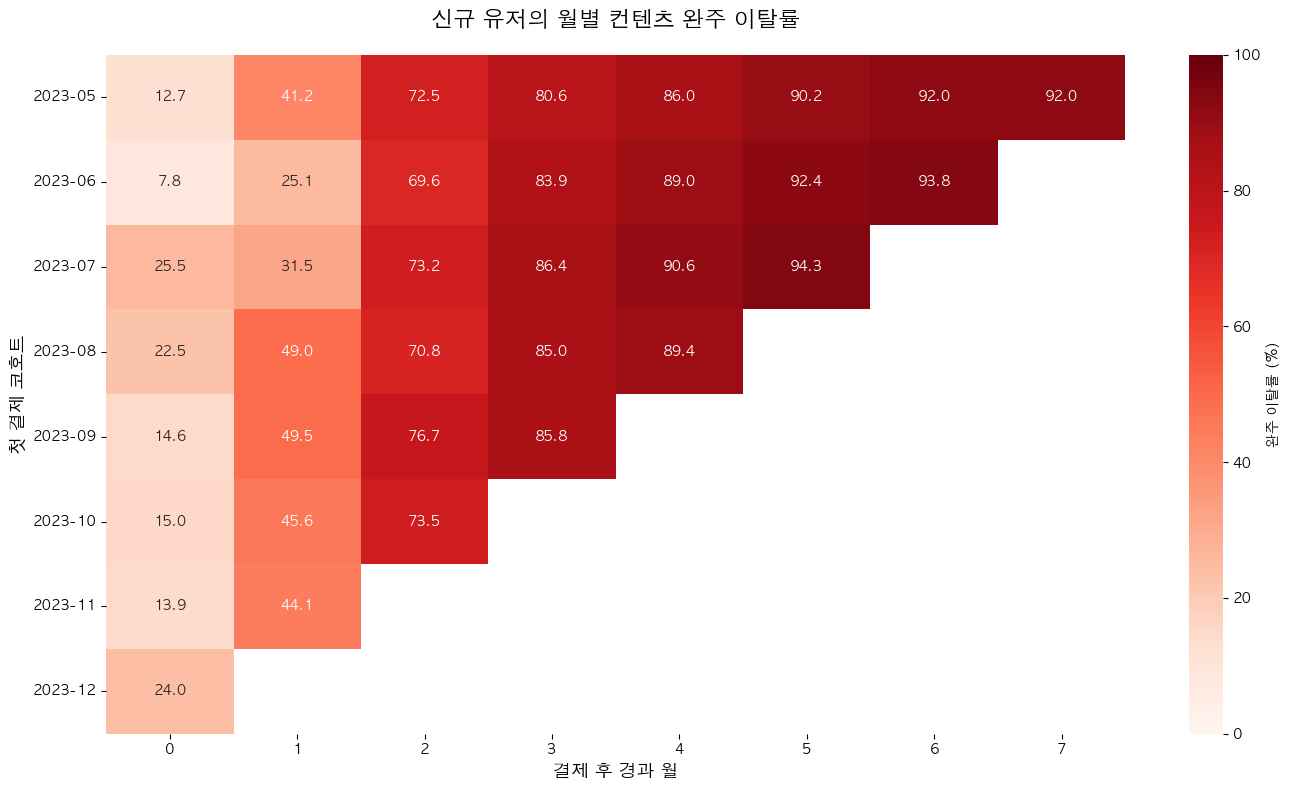

In [ ]:
first_sub = subscription.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_sub['cohort_month'] = first_sub['client_event_time'].dt.to_period('M')
cohort_sizes = first_sub.groupby('cohort_month')['user_id'].nunique().reset_index(name='cohort_size')

lesson_time_col = 'lesson_event_time' if 'lesson_event_time' in lesson.columns else 'client_event_time'
lesson_df = lesson.copy()
lesson_df[lesson_time_col] = pd.to_datetime(lesson_df[lesson_time_col], errors='coerce')
lesson_df['activity_month'] = lesson_df[lesson_time_col].dt.to_period('M')

merged = pd.merge(lesson_df[['user_id', 'activity_month']], first_sub[['user_id', 'cohort_month']], on='user_id', how='inner')

merged['month_index'] = (merged['activity_month'].dt.year - merged['cohort_month'].dt.year) * 12 + \
                        (merged['activity_month'].dt.month - merged['cohort_month'].dt.month)

merged = merged[merged['month_index'] >= 0]

active_users = merged.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index(name='active_users')

retention_df = pd.merge(active_users, cohort_sizes, on='cohort_month')
retention_df['retention_rate'] = (retention_df['active_users'] / retention_df['cohort_size']) * 100

cohort_pivot_ret = retention_df.pivot_table(index='cohort_month', columns='month_index', values='retention_rate')
cohort_pivot_churn = 100 - cohort_pivot_ret
cohort_pivot_churn.index = cohort_pivot_churn.index.astype(str)

plt.figure(figsize=(14, 8))
sns.heatmap(cohort_pivot_churn, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=100,
            cbar_kws={'label': '완주 이탈률 (%)'})

plt.title('신규 유저의 월별 컨텐츠 완주 이탈률', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('결제 후 경과 월', fontsize=13)
plt.ylabel('첫 결제 코호트', fontsize=13)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

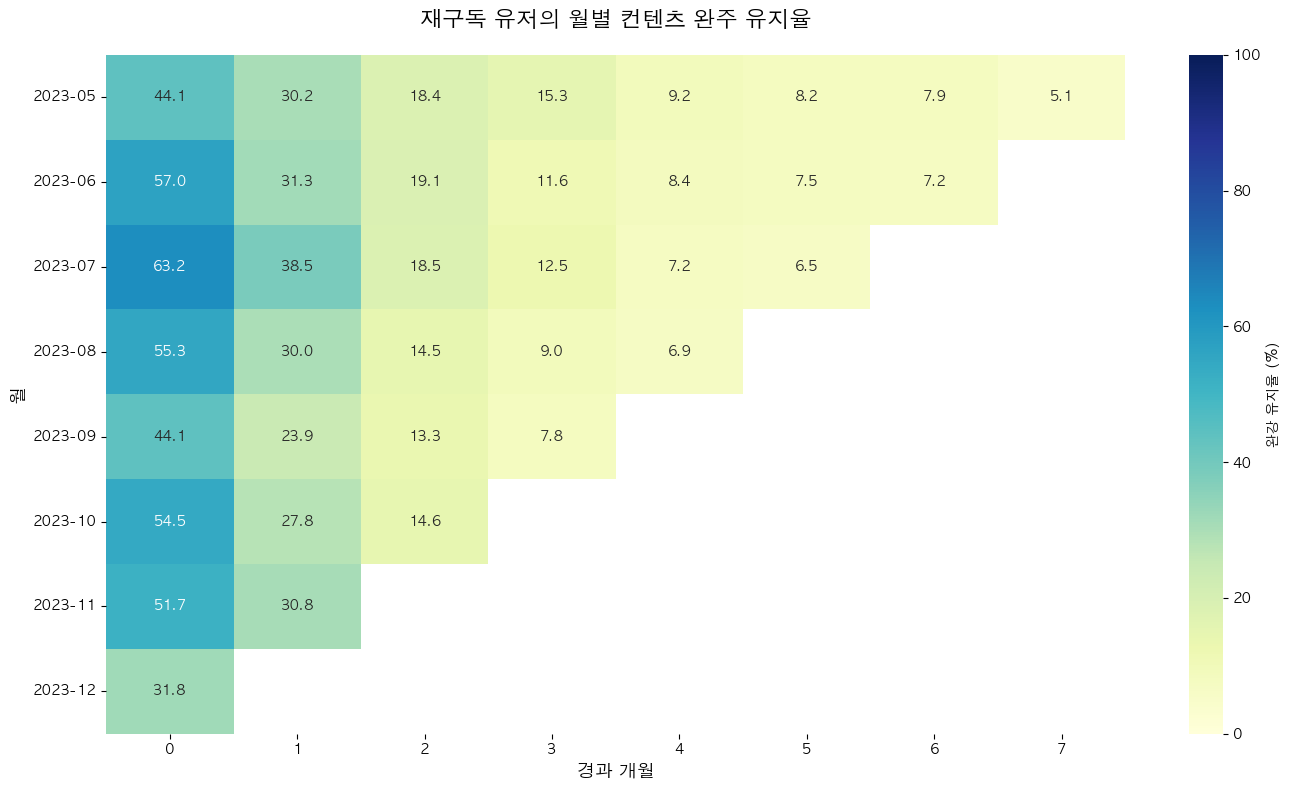

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

renew_df = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_renew_subscription_cohort.csv'))
renew_df['client_event_time'] = pd.to_datetime(renew_df['client_event_time'])
renew_df['month'] = renew_df['client_event_time'].dt.to_period('M')

first_renew = renew_df.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_renew['cohort_month'] = first_renew['month']

cohort_sizes = first_renew.groupby('cohort_month')['user_id'].nunique().reset_index(name='cohort_size')

lesson_df = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_complete_lesson_cohort.csv'))
lesson_time_col = 'lesson_event_time' if 'lesson_event_time' in lesson_df.columns else 'client_event_time'
lesson_df[lesson_time_col] = pd.to_datetime(lesson_df[lesson_time_col], errors='coerce')
lesson_df['activity_month'] = lesson_df[lesson_time_col].dt.to_period('M')

merged = pd.merge(lesson_df[['user_id', 'activity_month']], first_renew[['user_id', 'cohort_month']], on='user_id', how='inner')

merged['month_index'] = (merged['activity_month'].dt.year - merged['cohort_month'].dt.year) * 12 + \
                        (merged['activity_month'].dt.month - merged['cohort_month'].dt.month)

merged = merged[merged['month_index'] >= 0]

active_users = merged.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index(name='active_users')

retention_df = pd.merge(active_users, cohort_sizes, on='cohort_month')
retention_df['retention_rate'] = (retention_df['active_users'] / retention_df['cohort_size']) * 100

cohort_pivot = retention_df.pivot_table(index='cohort_month', columns='month_index', values='retention_rate')
cohort_pivot.index = cohort_pivot.index.astype(str)

plt.rc('font', family=KOREAN_FONT)
plt.figure(figsize=(14, 8))
sns.heatmap(cohort_pivot, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100,
            cbar_kws={'label': '완강 유지율 (%)'})

plt.title('재구독 유저의 월별 컨텐츠 완주 유지율', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('경과 개월', fontsize=13)
plt.ylabel('월', fontsize=13)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

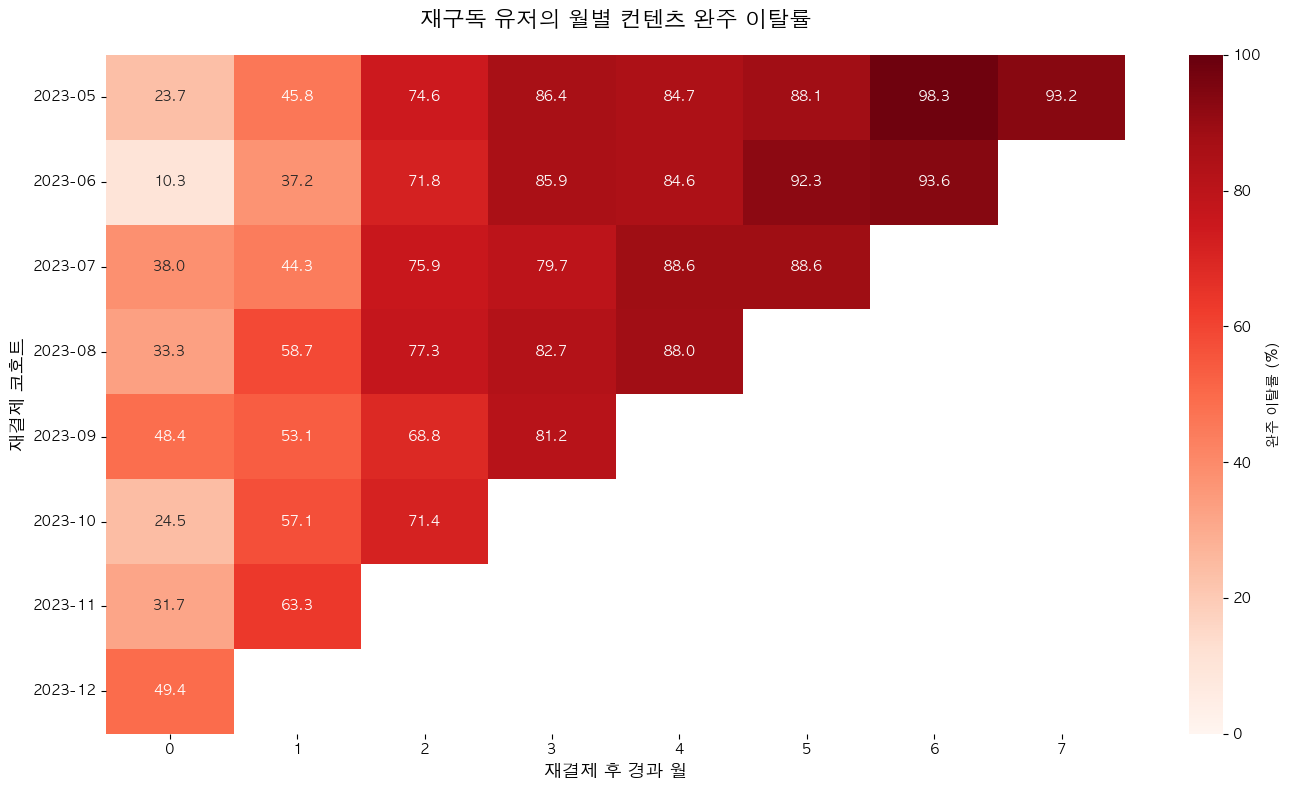

In [ ]:
first_resub = resubscribe.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_resub['cohort_month'] = first_resub['client_event_time'].dt.to_period('M')
cohort_sizes = first_resub.groupby('cohort_month')['user_id'].nunique().reset_index(name='cohort_size')

lesson_time_col = 'lesson_event_time' if 'lesson_event_time' in lesson.columns else 'client_event_time'
lesson_df = lesson.copy()
lesson_df[lesson_time_col] = pd.to_datetime(lesson_df[lesson_time_col], errors='coerce')
lesson_df['activity_month'] = lesson_df[lesson_time_col].dt.to_period('M')

merged = pd.merge(lesson_df[['user_id', 'activity_month']], first_resub[['user_id', 'cohort_month']], on='user_id', how='inner')

merged['month_index'] = (merged['activity_month'].dt.year - merged['cohort_month'].dt.year) * 12 + \
                        (merged['activity_month'].dt.month - merged['cohort_month'].dt.month)

merged = merged[merged['month_index'] >= 0]

active_users = merged.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index(name='active_users')

retention_df = pd.merge(active_users, cohort_sizes, on='cohort_month')
retention_df['retention_rate'] = (retention_df['active_users'] / retention_df['cohort_size']) * 100

cohort_pivot_ret = retention_df.pivot_table(index='cohort_month', columns='month_index', values='retention_rate')
cohort_pivot_churn = 100 - cohort_pivot_ret
cohort_pivot_churn.index = cohort_pivot_churn.index.astype(str)

plt.figure(figsize=(14, 8))
sns.heatmap(cohort_pivot_churn, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=100,
            cbar_kws={'label': '완주 이탈률 (%)'})

plt.title('재구독 유저의 월별 컨텐츠 완주 이탈률', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('재결제 후 경과 월', fontsize=13)
plt.ylabel('재결제 코호트', fontsize=13)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

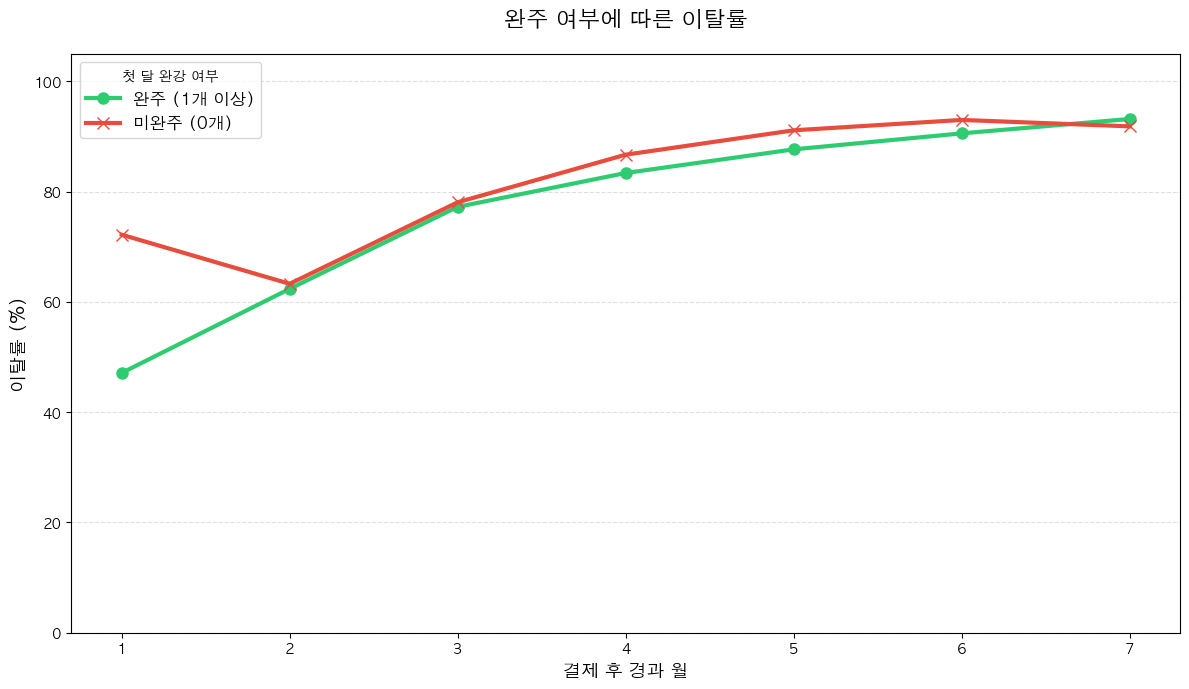

In [ ]:
first_sub = subscription.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_sub['sub_month'] = first_sub['client_event_time'].dt.to_period('M')

lesson_time_col = 'lesson_event_time' if 'lesson_event_time' in lesson.columns else 'client_event_time'
lesson_df = lesson.copy()
lesson_df[lesson_time_col] = pd.to_datetime(lesson_df[lesson_time_col], errors='coerce')
lesson_df['activity_month'] = lesson_df[lesson_time_col].dt.to_period('M')

merged_lesson = pd.merge(first_sub[['user_id', 'sub_month']],
                         lesson_df[['user_id', 'activity_month']],
                         on='user_id', how='left')

m0_activity = merged_lesson[merged_lesson['sub_month'] == merged_lesson['activity_month']]
m0_cnt = m0_activity.groupby('user_id').size().reset_index(name='lesson_cnt')

base_users = pd.merge(first_sub[['user_id', 'sub_month']], m0_cnt, on='user_id', how='left').fillna({'lesson_cnt': 0})
base_users['status'] = np.where(base_users['lesson_cnt'] > 0, '완주 (1개 이상)', '미완주 (0개)')

max_date = pd.to_datetime(renew['client_event_time']).max().to_period('M')
base_users['max_indices'] = (max_date.year - base_users['sub_month'].dt.year) * 12 + \
                            (max_date.month - base_users['sub_month'].dt.month)

renew_df = renew.copy()
renew_df['renew_month'] = pd.to_datetime(renew_df['client_event_time']).dt.to_period('M')

merged_renew = pd.merge(base_users[['user_id', 'status', 'sub_month']],
                        renew_df[['user_id', 'renew_month']],
                        on='user_id', how='inner')

merged_renew['month_index'] = (merged_renew['renew_month'].dt.year - merged_renew['sub_month'].dt.year) * 12 + \
                              (merged_renew['renew_month'].dt.month - merged_renew['sub_month'].dt.month)

merged_renew = merged_renew[(merged_renew['month_index'] > 0) & (merged_renew['month_index'] <= 12)]

active_users = merged_renew.groupby(['status', 'month_index'])['user_id'].nunique().reset_index()

def get_retention(row):
    denom = base_users[(base_users['status'] == row['status']) & (base_users['max_indices'] >= row['month_index'])]['user_id'].nunique()
    return (row['user_id'] / denom) * 100 if denom > 0 else np.nan

active_users['retention_rate'] = active_users.apply(get_retention, axis=1)
active_users['churn_rate'] = 100 - active_users['retention_rate']

pivot_churn = active_users.pivot(index='status', columns='month_index', values='churn_rate')
pivot_churn = pivot_churn.reindex(sorted(pivot_churn.columns), axis=1)

plt.figure(figsize=(12, 7))
colors = {'미완주 (0개)': '#e74c3c', '완주 (1개 이상)': '#2ecc71'}
markers = {'미완주 (0개)': 'x', '완주 (1개 이상)': 'o'}

for status in ['완주 (1개 이상)', '미완주 (0개)']:
    if status in pivot_churn.index:
        data = pivot_churn.loc[status].dropna()
        plt.plot(data.index, data.values, marker=markers[status],
                 color=colors[status], linewidth=3, markersize=8, label=status)

plt.title('완주 여부에 따른 이탈률', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('결제 후 경과 월', fontsize=13)
plt.ylabel('이탈률 (%)', fontsize=13)
plt.xticks(range(1, int(pivot_churn.columns.max()) + 1))
plt.ylim(0, 105)
plt.grid(True, axis='y', alpha=0.4, linestyle='--')
plt.legend(fontsize=12, title='첫 달 완강 여부')

for status in ['완강 (1개 이상)', '미완강 (0개)']:
    if status in pivot_churn.index:
        data = pivot_churn.loc[status].dropna()
        for x, y in data.items():
            if x in [1, 2, 3, 6, 12]:
                offset = 10 if status == '미완강 (0개)' else -20
                plt.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, offset),
                             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

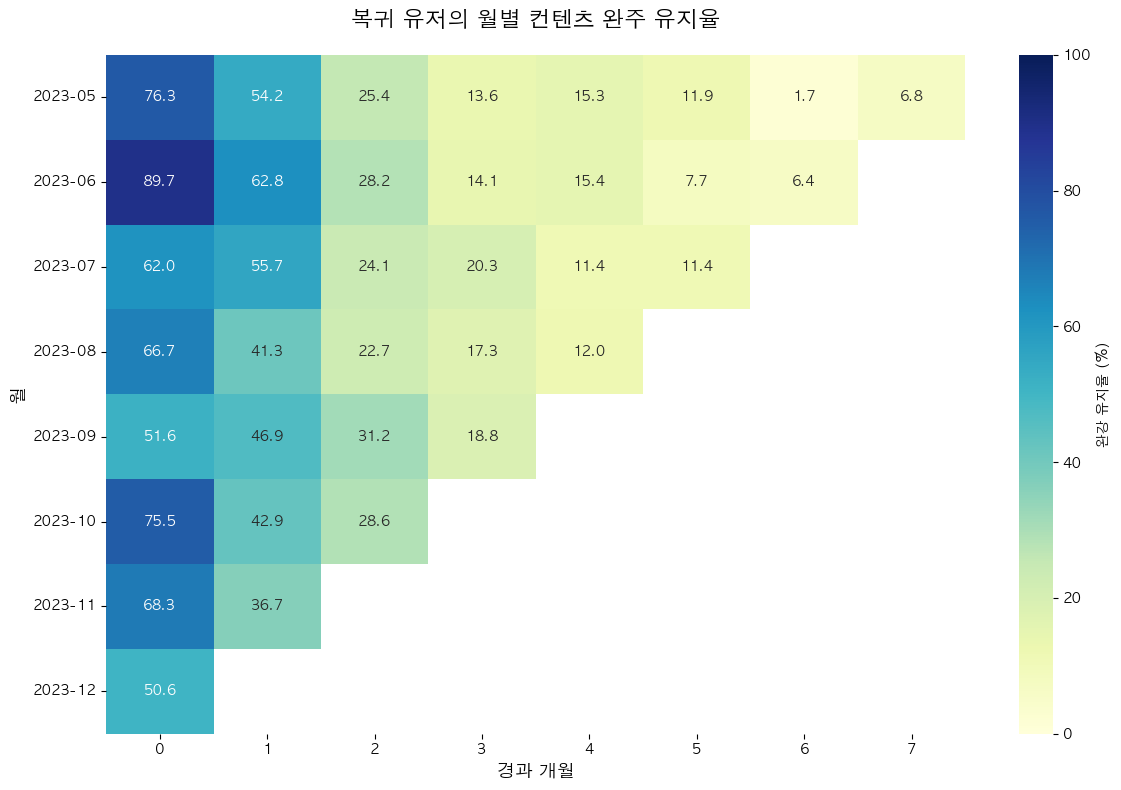

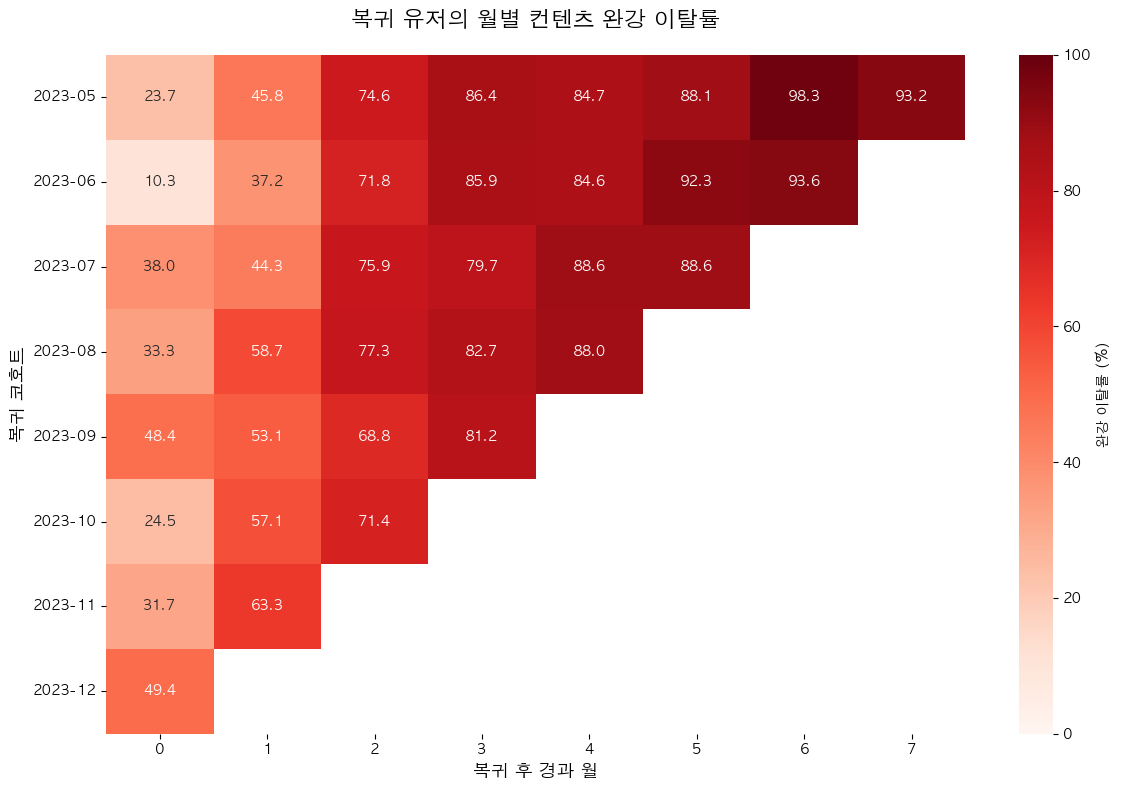

In [ ]:
first_resub = resubscribe.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_resub['cohort_month'] = first_resub['client_event_time'].dt.to_period('M')
cohort_sizes = first_resub.groupby('cohort_month')['user_id'].nunique().reset_index(name='cohort_size')

lesson_time_col = 'lesson_event_time' if 'lesson_event_time' in lesson.columns else 'client_event_time'
lesson_df = lesson.copy()
lesson_df[lesson_time_col] = pd.to_datetime(lesson_df[lesson_time_col], errors='coerce')
lesson_df['activity_month'] = lesson_df[lesson_time_col].dt.to_period('M')

merged = pd.merge(lesson_df[['user_id', 'activity_month']], first_resub[['user_id', 'cohort_month']], on='user_id', how='inner')

merged['month_index'] = (merged['activity_month'].dt.year - merged['cohort_month'].dt.year) * 12 + \
                        (merged['activity_month'].dt.month - merged['cohort_month'].dt.month)

merged = merged[merged['month_index'] >= 0]

active_users = merged.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index(name='active_users')

retention_df = pd.merge(active_users, cohort_sizes, on='cohort_month')
retention_df['retention_rate'] = (retention_df['active_users'] / retention_df['cohort_size']) * 100

cohort_pivot_ret = retention_df.pivot_table(index='cohort_month', columns='month_index', values='retention_rate')
cohort_pivot_churn = 100 - cohort_pivot_ret

cohort_pivot_ret.index = cohort_pivot_ret.index.astype(str)
cohort_pivot_churn.index = cohort_pivot_churn.index.astype(str)


plt.figure(figsize=(12, 8))
sns.heatmap(cohort_pivot_ret, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100,
            cbar_kws={'label': '완강 유지율 (%)'})
plt.title('복귀 유저의 월별 컨텐츠 완주 유지율', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('경과 개월', fontsize=13)
plt.ylabel('월', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 8))
sns.heatmap(cohort_pivot_churn, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=100,
            cbar_kws={'label': '완강 이탈률 (%)'})
plt.title('복귀 유저의 월별 컨텐츠 완강 이탈률', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('복귀 후 경과 월', fontsize=13)
plt.ylabel('복귀 코호트', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

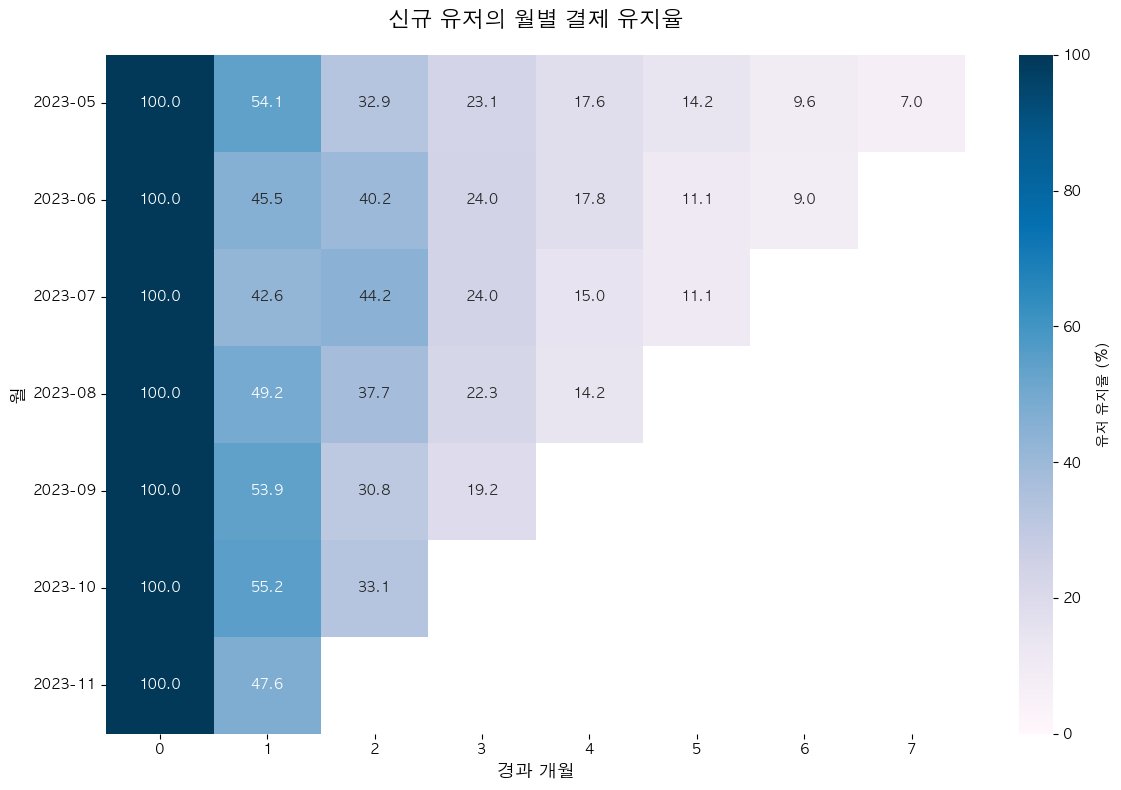

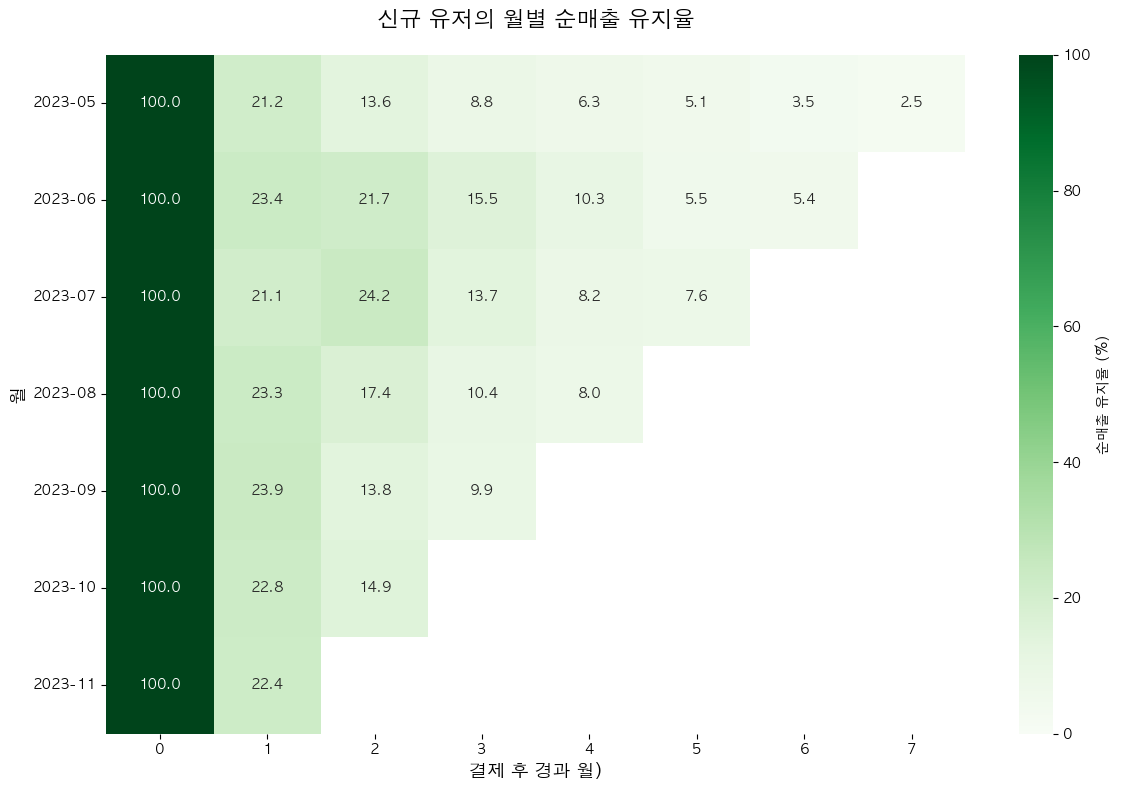

In [ ]:
first_sub = subscription.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_sub['cohort_month'] = first_sub['client_event_time'].dt.to_period('M')

cohort_users = first_sub.groupby('cohort_month')['user_id'].nunique().reset_index(name='m0_users')

renew_df = renew.copy()
renew_df['renew_month'] = pd.to_datetime(renew_df['client_event_time']).dt.to_period('M')

merged_users = pd.merge(first_sub[['user_id', 'cohort_month']], renew_df[['user_id', 'renew_month']], on='user_id', how='inner')
merged_users['month_index'] = (merged_users['renew_month'].dt.year - merged_users['cohort_month'].dt.year) * 12 + \
                              (merged_users['renew_month'].dt.month - merged_users['cohort_month'].dt.month)
merged_users = merged_users[merged_users['month_index'] > 0]

retained_users = merged_users.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index(name='retained_users')
user_retention = pd.merge(retained_users, cohort_users, on='cohort_month')
user_retention['retention_rate'] = (user_retention['retained_users'] / user_retention['m0_users']) * 100

user_pivot = user_retention.pivot_table(index='cohort_month', columns='month_index', values='retention_rate')
user_pivot.insert(0, 0, 100.0)
user_pivot.index = user_pivot.index.astype(str)

plt.figure(figsize=(12, 8))
sns.heatmap(user_pivot, annot=True, fmt='.1f', cmap='PuBu', vmin=0, vmax=100,
            cbar_kws={'label': '유저 유지율 (%)'})
plt.title('신규 유저의 월별 결제 유지율', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('경과 개월', fontsize=13)
plt.ylabel('월', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

m0_sales = first_sub.groupby('cohort_month')['paid_amount'].sum().reset_index(name='m0_sales')

merged_sales = pd.merge(first_sub[['user_id', 'cohort_month']], renew_df[['user_id', 'renew_month', 'paid_amount']], on='user_id', how='inner')
merged_sales['month_index'] = (merged_sales['renew_month'].dt.year - merged_sales['cohort_month'].dt.year) * 12 + \
                              (merged_sales['renew_month'].dt.month - merged_sales['cohort_month'].dt.month)
merged_sales = merged_sales[merged_sales['month_index'] > 0]

retained_sales = merged_sales.groupby(['cohort_month', 'month_index'])['paid_amount'].sum().reset_index(name='retained_sales')
sales_retention = pd.merge(retained_sales, m0_sales, on='cohort_month')
sales_retention['nrr'] = (sales_retention['retained_sales'] / sales_retention['m0_sales']) * 100

sales_pivot = sales_retention.pivot_table(index='cohort_month', columns='month_index', values='nrr')
sales_pivot.insert(0, 0, 100.0)
sales_pivot.index = sales_pivot.index.astype(str)

plt.figure(figsize=(12, 8))
sns.heatmap(sales_pivot, annot=True, fmt='.1f', cmap='Greens', vmin=0, vmax=100,
            cbar_kws={'label': '순매출 유지율 (%)'})
plt.title('신규 유저의 월별 순매출 유지율', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('결제 후 경과 월)', fontsize=13)
plt.ylabel('월', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

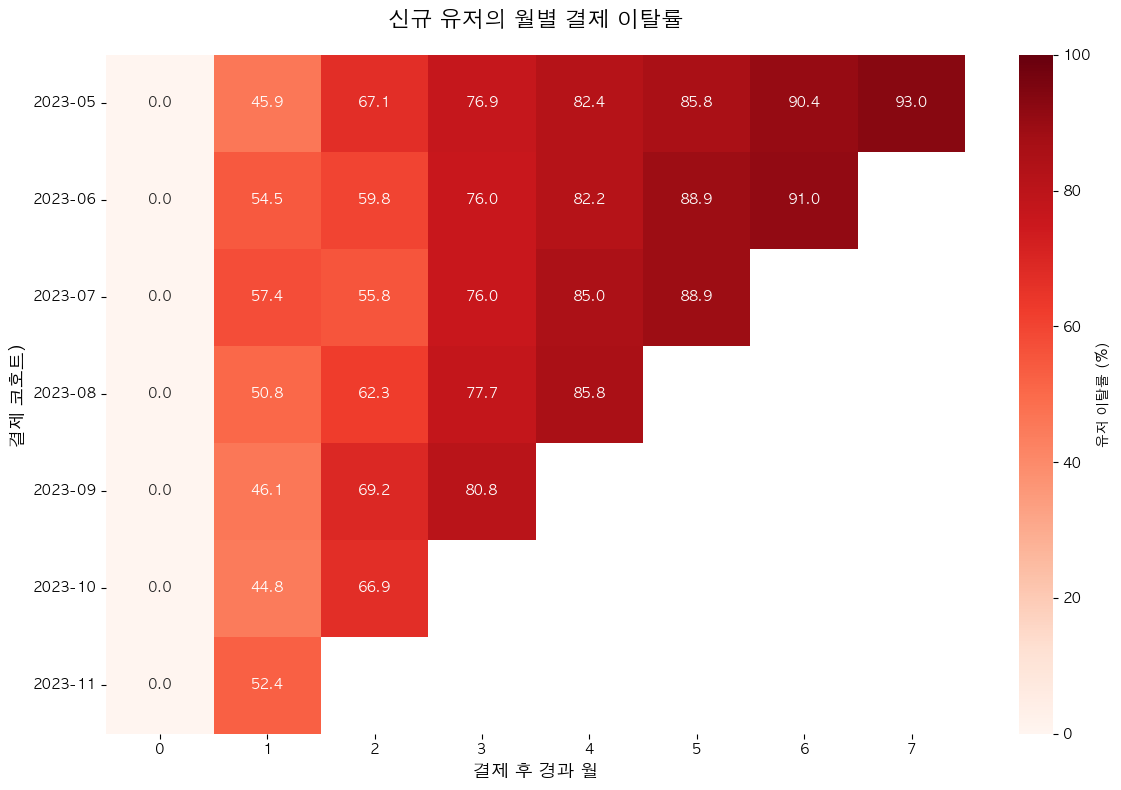

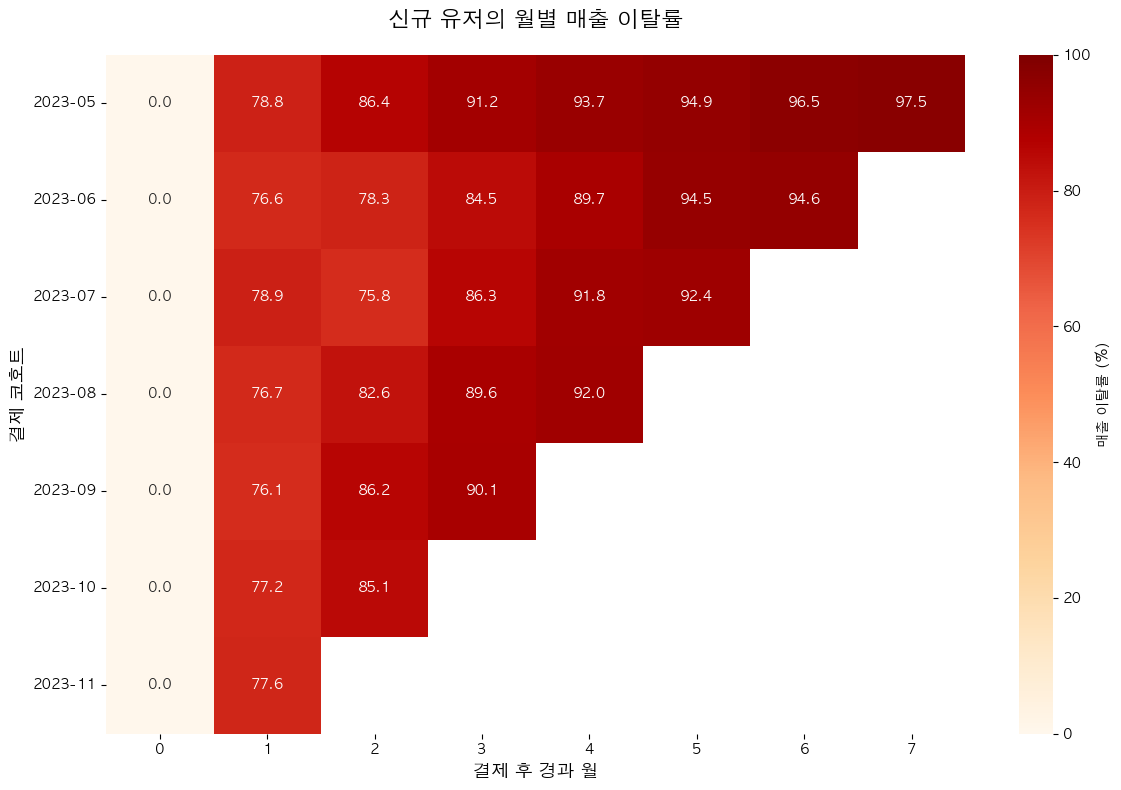

In [ ]:
first_sub = subscription.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_sub['cohort_month'] = first_sub['client_event_time'].dt.to_period('M')

cohort_users = first_sub.groupby('cohort_month')['user_id'].nunique().reset_index(name='m0_users')

renew_df = renew.copy()
renew_df['renew_month'] = pd.to_datetime(renew_df['client_event_time']).dt.to_period('M')

merged_users = pd.merge(first_sub[['user_id', 'cohort_month']], renew_df[['user_id', 'renew_month']], on='user_id', how='inner')
merged_users['month_index'] = (merged_users['renew_month'].dt.year - merged_users['cohort_month'].dt.year) * 12 + \
                              (merged_users['renew_month'].dt.month - merged_users['cohort_month'].dt.month)
merged_users = merged_users[merged_users['month_index'] > 0]

retained_users = merged_users.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index(name='retained_users')
user_retention = pd.merge(retained_users, cohort_users, on='cohort_month')
user_retention['retention_rate'] = (user_retention['retained_users'] / user_retention['m0_users']) * 100

user_pivot = user_retention.pivot_table(index='cohort_month', columns='month_index', values='retention_rate')
user_churn_pivot = 100 - user_pivot
user_churn_pivot.insert(0, 0, 0.0)
user_churn_pivot.index = user_churn_pivot.index.astype(str)

plt.figure(figsize=(12, 8))
sns.heatmap(user_churn_pivot, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=100,
            cbar_kws={'label': '유저 이탈률 (%)'})
plt.title('신규 유저의 월별 결제 이탈률', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('결제 후 경과 월', fontsize=13)
plt.ylabel('결제 코호트)', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


m0_sales = first_sub.groupby('cohort_month')['paid_amount'].sum().reset_index(name='m0_sales')

merged_sales = pd.merge(first_sub[['user_id', 'cohort_month']], renew_df[['user_id', 'renew_month', 'paid_amount']], on='user_id', how='inner')
merged_sales['month_index'] = (merged_sales['renew_month'].dt.year - merged_sales['cohort_month'].dt.year) * 12 + \
                              (merged_sales['renew_month'].dt.month - merged_sales['cohort_month'].dt.month)
merged_sales = merged_sales[merged_sales['month_index'] > 0]

retained_sales = merged_sales.groupby(['cohort_month', 'month_index'])['paid_amount'].sum().reset_index(name='retained_sales')
sales_retention = pd.merge(retained_sales, m0_sales, on='cohort_month')
sales_retention['nrr'] = (sales_retention['retained_sales'] / sales_retention['m0_sales']) * 100

sales_churn_pivot = 100 - sales_retention.pivot_table(index='cohort_month', columns='month_index', values='nrr')
sales_churn_pivot.insert(0, 0, 0.0)
sales_churn_pivot.index = sales_churn_pivot.index.astype(str)

plt.figure(figsize=(12, 8))
sns.heatmap(sales_churn_pivot, annot=True, fmt='.1f', cmap='OrRd', vmin=0, vmax=100,
            cbar_kws={'label': '매출 이탈률 (%)'})
plt.title('신규 유저의 월별 매출 이탈률', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('결제 후 경과 월', fontsize=13)
plt.ylabel('결제 코호트', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

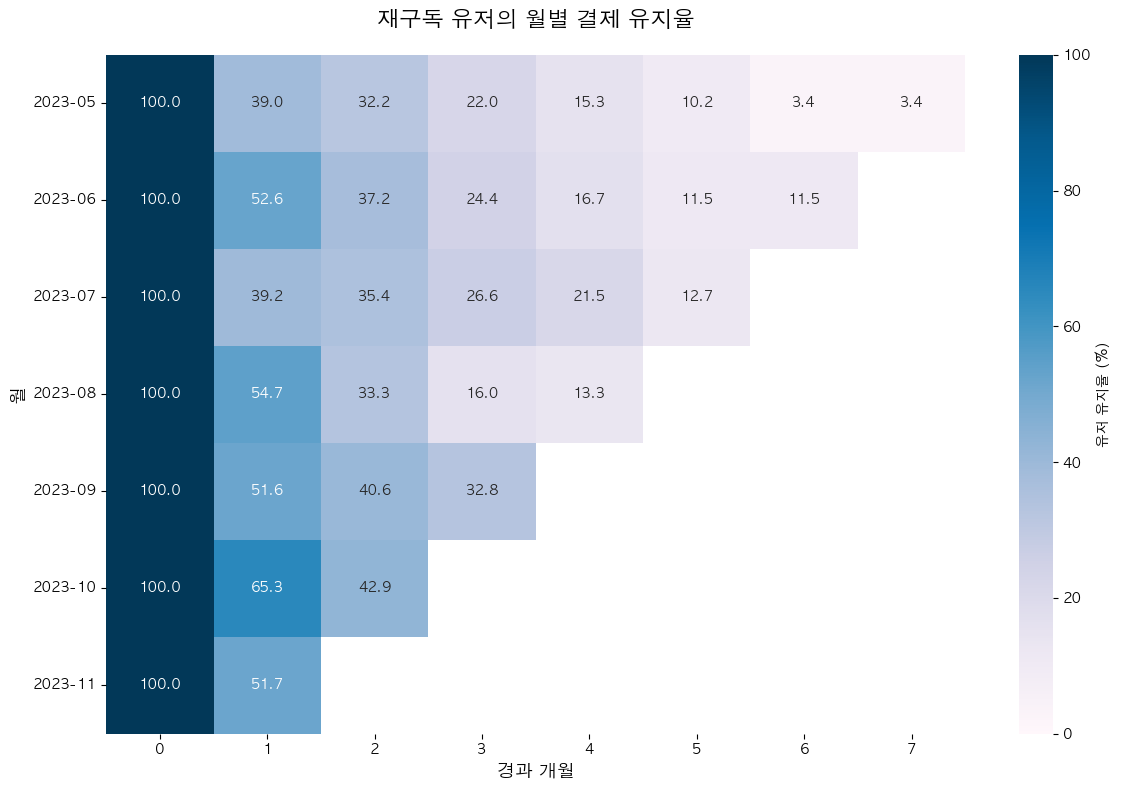

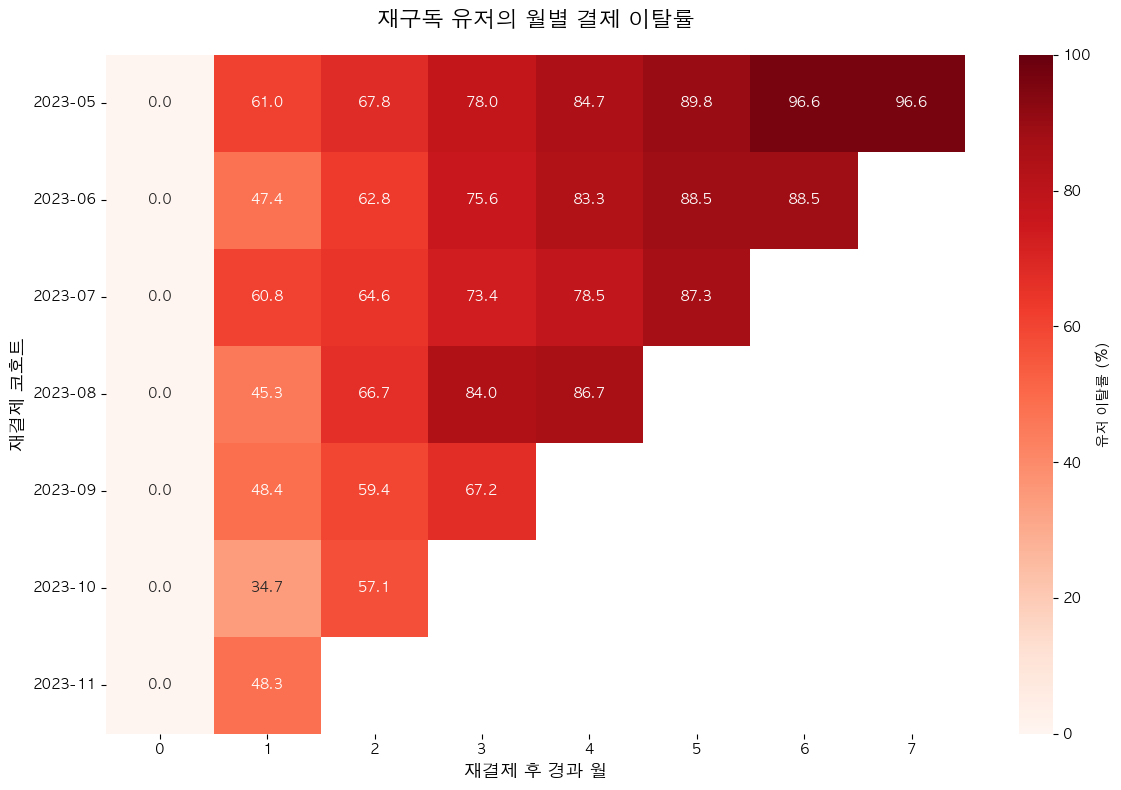

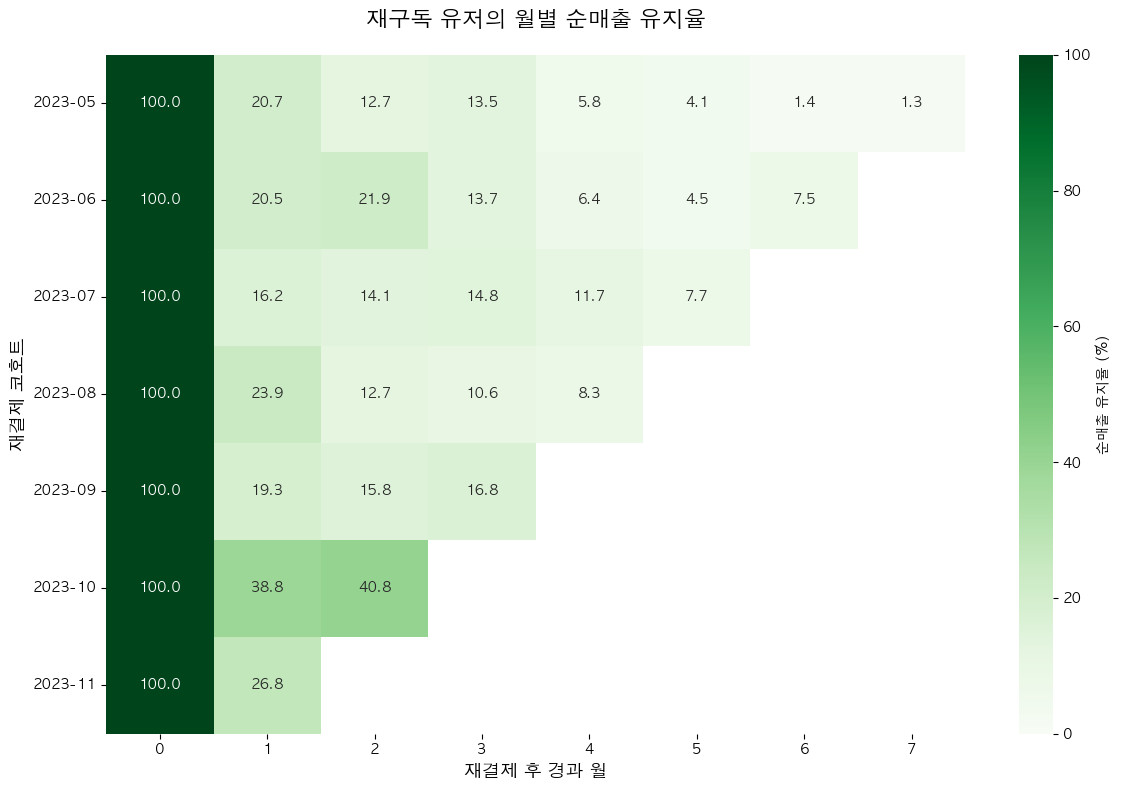

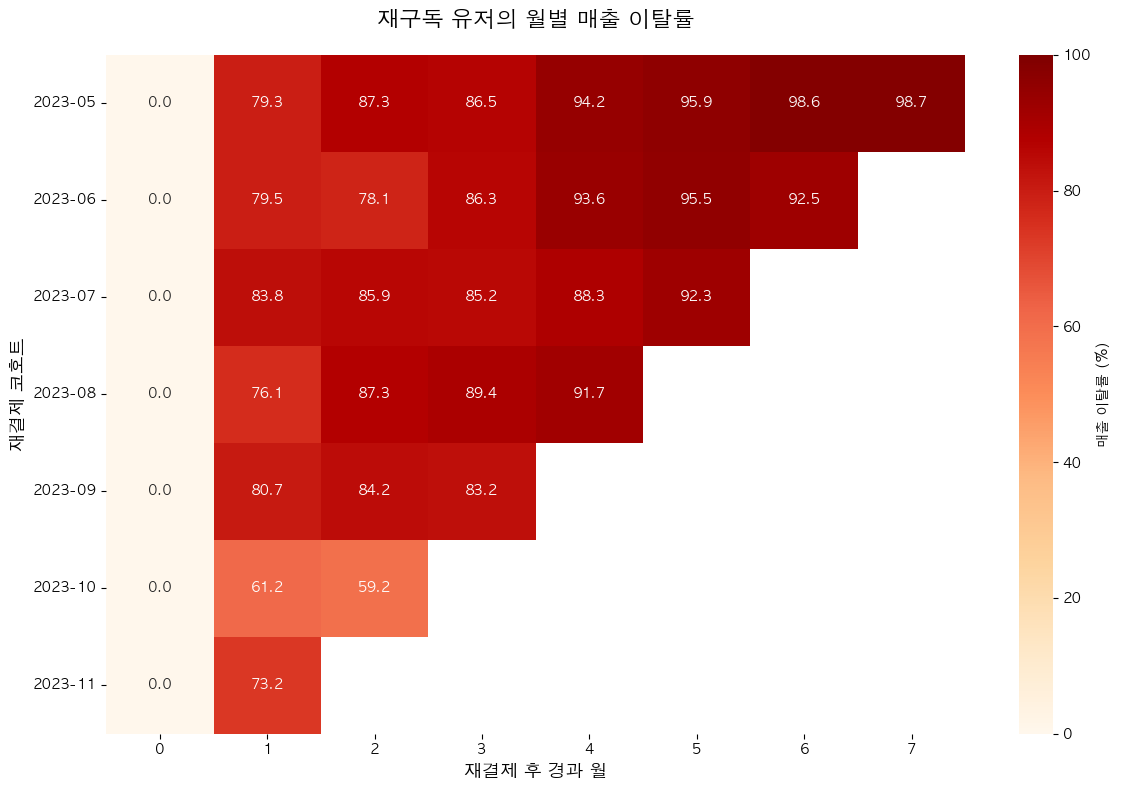

In [ ]:
first_resub = resubscribe.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_resub['cohort_month'] = first_resub['client_event_time'].dt.to_period('M')

cohort_users = first_resub.groupby('cohort_month')['user_id'].nunique().reset_index(name='m0_users')
m0_sales = first_resub.groupby('cohort_month')['paid_amount'].sum().reset_index(name='m0_sales')

renew_df = renew.copy()
renew_df['renew_month'] = pd.to_datetime(renew_df['client_event_time']).dt.to_period('M')

merged_users = pd.merge(first_resub[['user_id', 'cohort_month']], renew_df[['user_id', 'renew_month']], on='user_id', how='inner')
merged_users['month_index'] = (merged_users['renew_month'].dt.year - merged_users['cohort_month'].dt.year) * 12 + \
                              (merged_users['renew_month'].dt.month - merged_users['cohort_month'].dt.month)
merged_users = merged_users[merged_users['month_index'] > 0]

retained_users = merged_users.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index(name='retained_users')
user_retention = pd.merge(retained_users, cohort_users, on='cohort_month')
user_retention['retention_rate'] = (user_retention['retained_users'] / user_retention['m0_users']) * 100

user_pivot = user_retention.pivot_table(index='cohort_month', columns='month_index', values='retention_rate')
user_pivot.insert(0, 0, 100.0)
user_pivot.index = user_pivot.index.astype(str)

user_churn_pivot = 100 - user_pivot
user_churn_pivot[0] = 0.0

merged_sales = pd.merge(first_resub[['user_id', 'cohort_month']], renew_df[['user_id', 'renew_month', 'paid_amount']], on='user_id', how='inner')
merged_sales['month_index'] = (merged_sales['renew_month'].dt.year - merged_sales['cohort_month'].dt.year) * 12 + \
                              (merged_sales['renew_month'].dt.month - merged_sales['cohort_month'].dt.month)
merged_sales = merged_sales[merged_sales['month_index'] > 0]

retained_sales = merged_sales.groupby(['cohort_month', 'month_index'])['paid_amount'].sum().reset_index(name='retained_sales')
sales_retention = pd.merge(retained_sales, m0_sales, on='cohort_month')
sales_retention['nrr'] = (sales_retention['retained_sales'] / sales_retention['m0_sales']) * 100

sales_pivot = sales_retention.pivot_table(index='cohort_month', columns='month_index', values='nrr')
sales_pivot.insert(0, 0, 100.0)
sales_pivot.index = sales_pivot.index.astype(str)

sales_churn_pivot = 100 - sales_pivot
sales_churn_pivot[0] = 0.0


plt.figure(figsize=(12, 8))
sns.heatmap(user_pivot, annot=True, fmt='.1f', cmap='PuBu', vmin=0, vmax=100, cbar_kws={'label': '유저 유지율 (%)'})
plt.title('재구독 유저의 월별 결제 유지율', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('경과 개월', fontsize=13)
plt.ylabel('월', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(user_churn_pivot, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=100, cbar_kws={'label': '유저 이탈률 (%)'})
plt.title('재구독 유저의 월별 결제 이탈률', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('재결제 후 경과 월', fontsize=13)
plt.ylabel('재결제 코호트', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(sales_pivot, annot=True, fmt='.1f', cmap='Greens', vmin=0, vmax=100, cbar_kws={'label': '순매출 유지율 (%)'})
plt.title('재구독 유저의 월별 순매출 유지율', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('재결제 후 경과 월', fontsize=13)
plt.ylabel('재결제 코호트', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(sales_churn_pivot, annot=True, fmt='.1f', cmap='OrRd', vmin=0, vmax=100, cbar_kws={'label': '매출 이탈률 (%)'})
plt.title('재구독 유저의 월별 매출 이탈률', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('재결제 후 경과 월', fontsize=13)
plt.ylabel('재결제 코호트', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

month_index      1     2     3     4     5    6    7
cohort_month                                        
2023-05       23.0  19.0  13.0   9.0   6.0  2.0  2.0
2023-06       41.0  29.0  19.0  13.0   9.0  9.0  NaN
2023-07       31.0  28.0  21.0  17.0  10.0  NaN  NaN
2023-08       41.0  25.0  12.0  10.0   NaN  NaN  NaN
2023-09       33.0  26.0  21.0   NaN   NaN  NaN  NaN
2023-10       32.0  21.0   NaN   NaN   NaN  NaN  NaN
2023-11       31.0   NaN   NaN   NaN   NaN  NaN  NaN


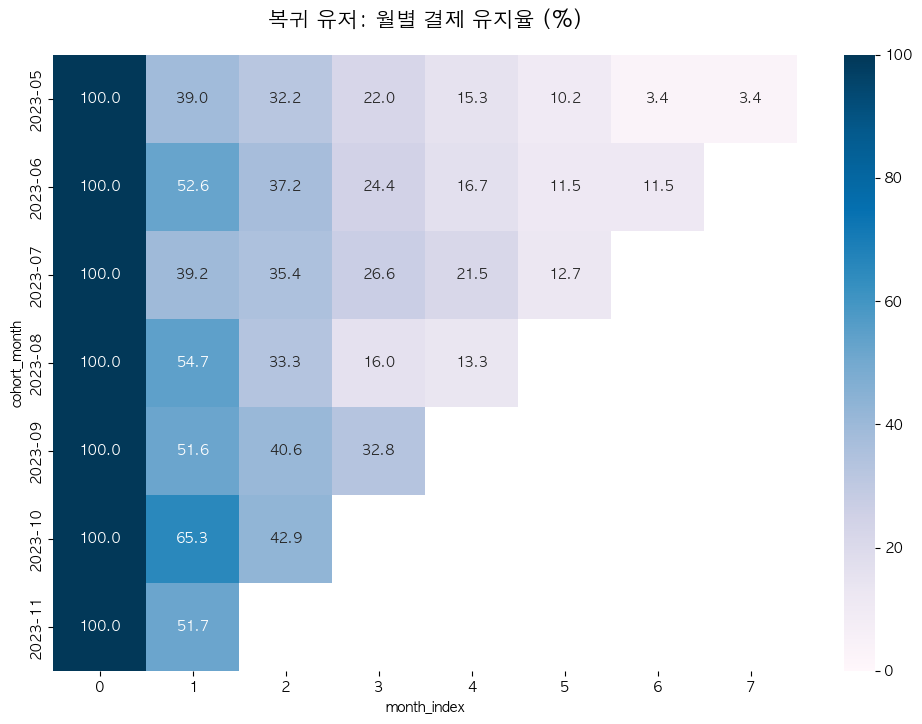

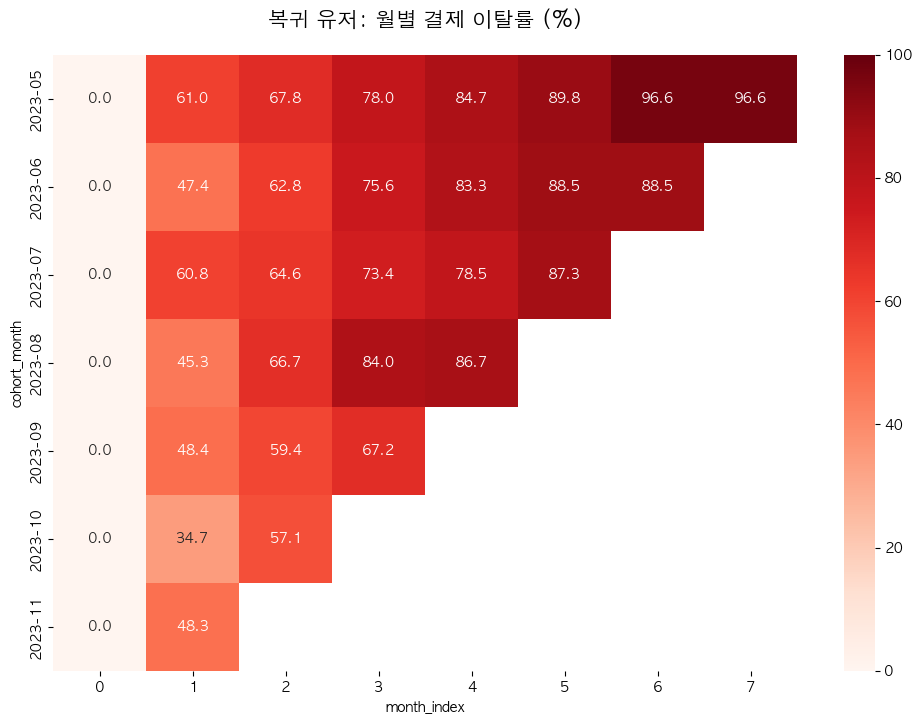

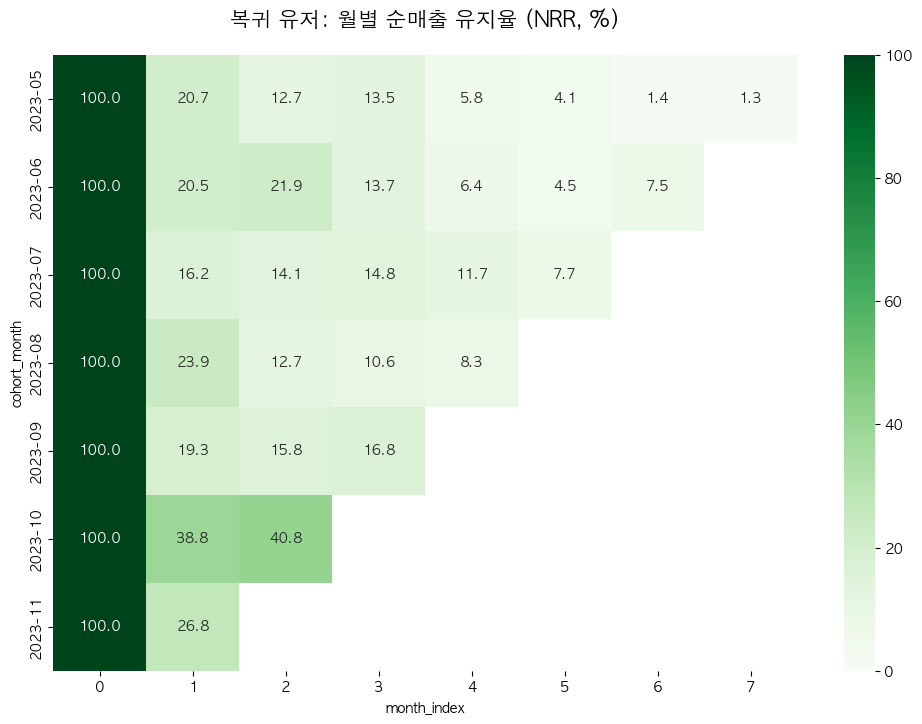

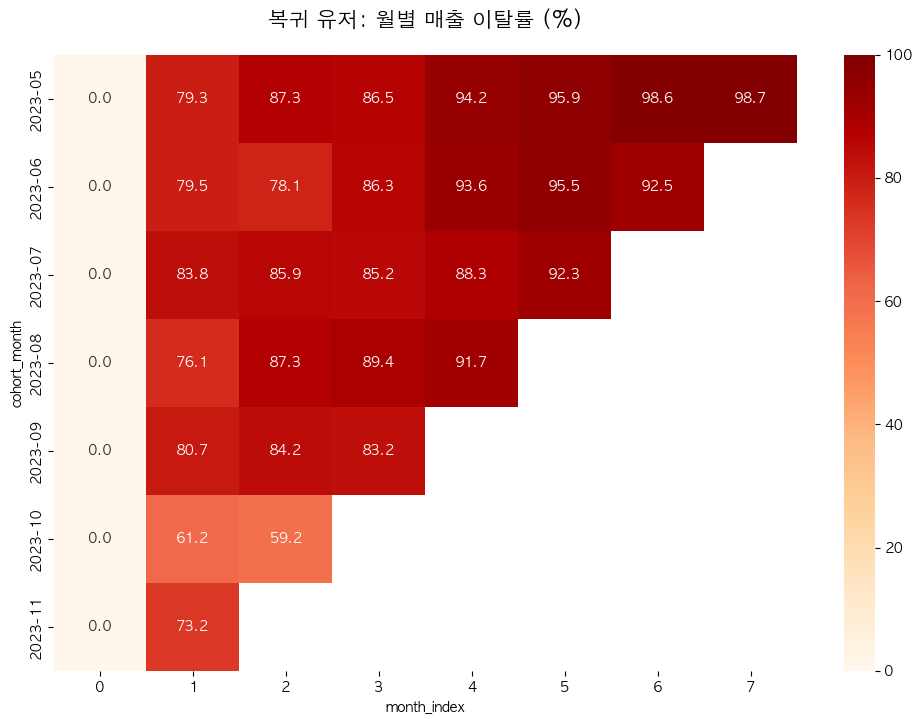

In [ ]:
first_resub = resubscribe.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_resub['cohort_month'] = first_resub['client_event_time'].dt.to_period('M')
first_resub.rename(columns={'client_event_time': 'resub_time_m0', 'paid_amount': 'm0_sales'}, inplace=True)

cohort_users = first_resub.groupby('cohort_month')['user_id'].nunique().reset_index(name='m0_users')
m0_sales_total = first_resub.groupby('cohort_month')['m0_sales'].sum().reset_index(name='m0_sales_total')

activity = renew.copy()
activity['event_time'] = pd.to_datetime(activity['client_event_time'])
activity['event_month'] = activity['event_time'].dt.to_period('M')

merged = pd.merge(first_resub[['user_id', 'cohort_month', 'resub_time_m0']],
                  activity[['user_id', 'event_time', 'event_month', 'paid_amount']], on='user_id', how='inner')

merged = merged[merged['event_time'] > merged['resub_time_m0']]
merged['month_index'] = (merged['event_month'].dt.year - merged['cohort_month'].dt.year) * 12 + \
                        (merged['event_month'].dt.month - merged['cohort_month'].dt.month)
merged = merged[merged['month_index'] > 0]

retained_users = merged.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index(name='retained_users')
user_retention = pd.merge(retained_users, cohort_users, on='cohort_month')
user_retention['retention_rate'] = (user_retention['retained_users'] / user_retention['m0_users']) * 100
user_pivot = user_retention.pivot_table(index='cohort_month', columns='month_index', values='retention_rate')
user_pivot.insert(0, 0, 100.0)
user_pivot.index = user_pivot.index.astype(str)
user_churn_pivot = 100 - user_pivot
user_churn_pivot[0] = 0.0

retained_sales = merged.groupby(['cohort_month', 'month_index'])['paid_amount'].sum().reset_index(name='retained_sales')
sales_retention = pd.merge(retained_sales, m0_sales_total, on='cohort_month')
sales_retention['nrr'] = (sales_retention['retained_sales'] / sales_retention['m0_sales_total']) * 100
sales_pivot = sales_retention.pivot_table(index='cohort_month', columns='month_index', values='nrr')
sales_pivot.insert(0, 0, 100.0)
sales_pivot.index = sales_pivot.index.astype(str)
sales_churn_pivot = 100 - sales_pivot
sales_churn_pivot[0] = 0.0

first_resub = resubscribe.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_resub['cohort_month'] = first_resub['client_event_time'].dt.to_period('M')
first_resub.rename(columns={'client_event_time': 'resub_time_m0', 'paid_amount': 'm0_sales'}, inplace=True)

activity = renew.copy()
activity['event_time'] = pd.to_datetime(activity['client_event_time'])
activity['event_month'] = activity['event_time'].dt.to_period('M')

merged = pd.merge(first_resub[['user_id', 'cohort_month', 'resub_time_m0']],
                  activity[['user_id', 'event_time', 'event_month', 'paid_amount']], on='user_id')

merged = merged[merged['event_time'] > merged['resub_time_m0']]

merged['month_index'] = (merged['event_month'].dt.year - merged['cohort_month'].dt.year) * 12 + \
                        (merged['event_month'].dt.month - merged['cohort_month'].dt.month)

merged = merged[merged['month_index'] > 0]

user_count_pivot = user_retention.pivot_table(index='cohort_month', columns='month_index', values='retained_users')
print(user_count_pivot)

plt.figure(figsize=(12, 8))
sns.heatmap(user_pivot, annot=True, fmt='.1f', cmap='PuBu', vmin=0, vmax=100)
plt.title('복귀 유저: 월별 결제 유지율 (%)', fontsize=15, fontweight='bold', pad=20)
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(user_churn_pivot, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=100)
plt.title('복귀 유저: 월별 결제 이탈률 (%)', fontsize=15, fontweight='bold', pad=20)
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(sales_pivot, annot=True, fmt='.1f', cmap='Greens', vmin=0, vmax=100)
plt.title('복귀 유저: 월별 순매출 유지율 (NRR, %)', fontsize=15, fontweight='bold', pad=20)
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(sales_churn_pivot, annot=True, fmt='.1f', cmap='OrRd', vmin=0, vmax=100)
plt.title('복귀 유저: 월별 매출 이탈률 (%)', fontsize=15, fontweight='bold', pad=20)
plt.show()

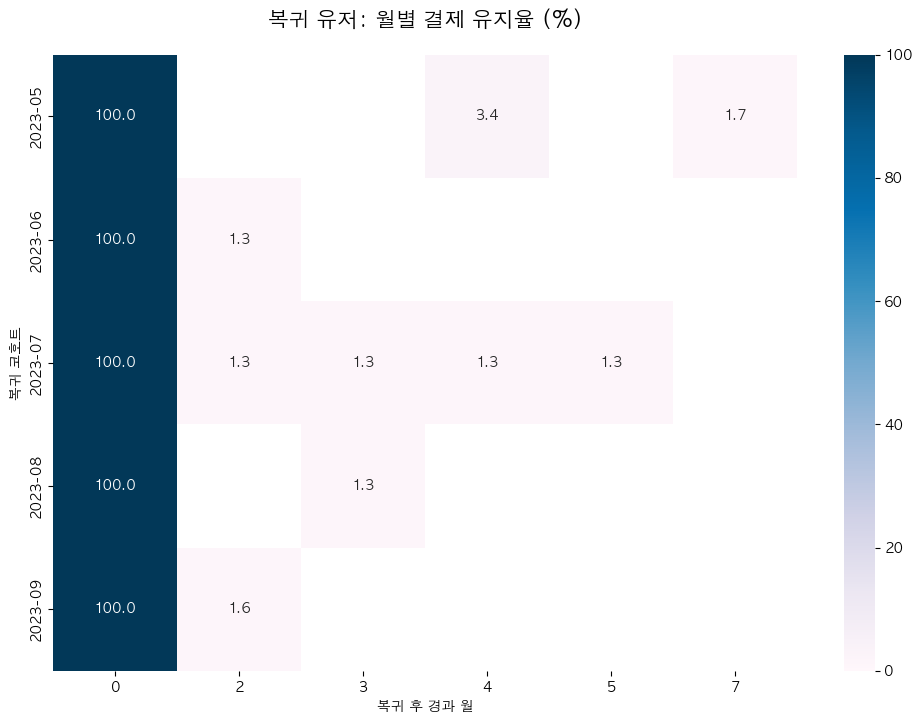

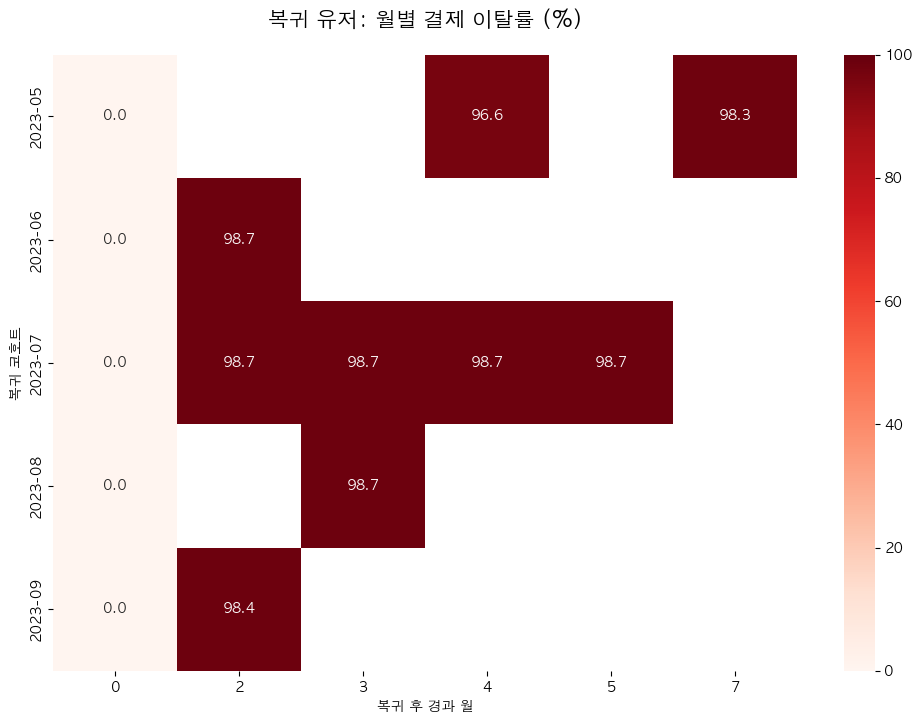

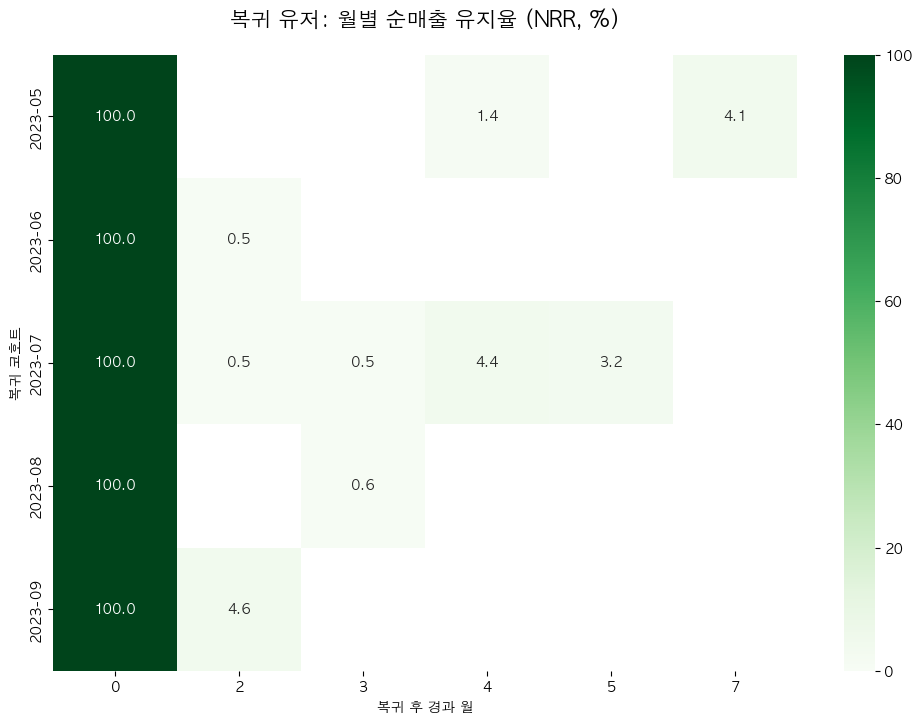

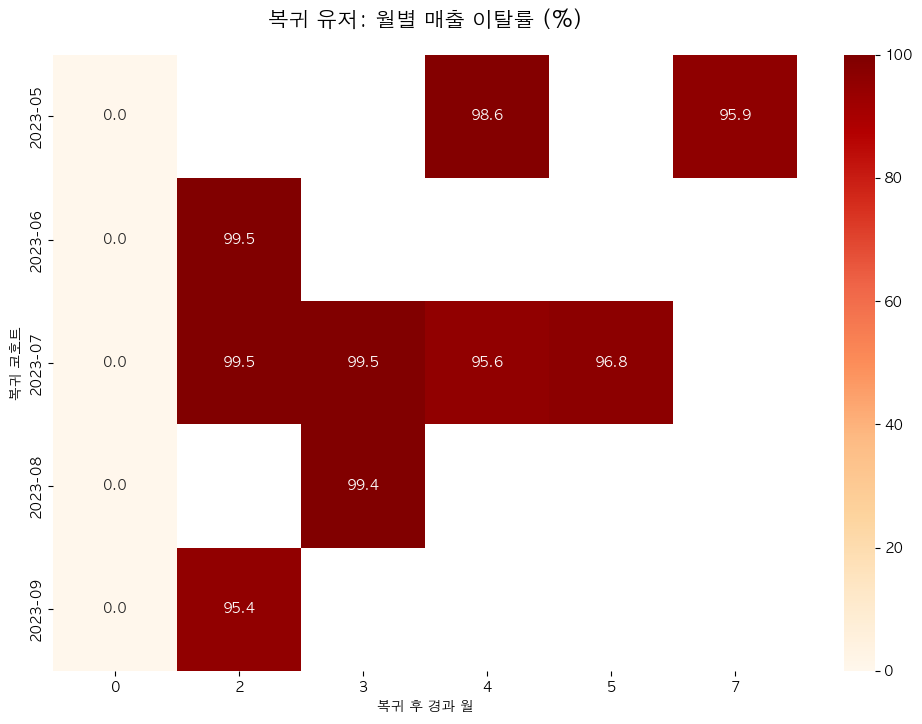

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

setup_korean_font()

first_resub = resubscribe.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_resub['cohort_month'] = first_resub['client_event_time'].dt.to_period('M')
first_resub.rename(columns={'client_event_time': 'resub_time_m0', 'paid_amount': 'm0_sales'}, inplace=True)

cohort_users = first_resub.groupby('cohort_month')['user_id'].nunique().reset_index(name='m0_users')
m0_sales_total = first_resub.groupby('cohort_month')['m0_sales'].sum().reset_index(name='m0_sales_total')

resub_followup = resubscribe.copy()
resub_followup['resub_time'] = pd.to_datetime(resub_followup['client_event_time'])
resub_followup['resub_month'] = resub_followup['resub_time'].dt.to_period('M')

merged = pd.merge(first_resub[['user_id', 'cohort_month', 'resub_time_m0']],
                  resub_followup[['user_id', 'resub_time', 'resub_month', 'paid_amount']], on='user_id', how='inner')
merged = merged[merged['resub_time'] > merged['resub_time_m0']]

merged['month_index'] = (merged['resub_month'].dt.year - merged['cohort_month'].dt.year) * 12 + \
                        (merged['resub_month'].dt.month - merged['cohort_month'].dt.month)
merged = merged[merged['month_index'] > 0]

retained_users = merged.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index(name='retained_users')
user_retention = pd.merge(retained_users, cohort_users, on='cohort_month')
user_retention['retention_rate'] = (user_retention['retained_users'] / user_retention['m0_users']) * 100
user_pivot = user_retention.pivot_table(index='cohort_month', columns='month_index', values='retention_rate')
user_pivot.insert(0, 0, 100.0)
user_pivot.index = user_pivot.index.astype(str)
user_churn_pivot = 100 - user_pivot
user_churn_pivot[0] = 0.0

retained_sales = merged.groupby(['cohort_month', 'month_index'])['paid_amount'].sum().reset_index(name='retained_sales')
sales_retention = pd.merge(retained_sales, m0_sales_total, on='cohort_month')
sales_retention['nrr'] = (sales_retention['retained_sales'] / sales_retention['m0_sales_total']) * 100
sales_pivot = sales_retention.pivot_table(index='cohort_month', columns='month_index', values='nrr')
sales_pivot.insert(0, 0, 100.0)
sales_pivot.index = sales_pivot.index.astype(str)
sales_churn_pivot = 100 - sales_pivot
sales_churn_pivot[0] = 0.0

plt.figure(figsize=(12, 8))
sns.heatmap(user_pivot, annot=True, fmt='.1f', cmap='PuBu', vmin=0, vmax=100)
plt.title('복귀 유저: 월별 결제 유지율 (%)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('복귀 후 경과 월')
plt.ylabel('복귀 코호트')
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(user_churn_pivot, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=100)
plt.title('복귀 유저: 월별 결제 이탈률 (%)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('복귀 후 경과 월')
plt.ylabel('복귀 코호트')
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(sales_pivot, annot=True, fmt='.1f', cmap='Greens', vmin=0, vmax=100)
plt.title('복귀 유저: 월별 순매출 유지율 (NRR, %)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('복귀 후 경과 월')
plt.ylabel('복귀 코호트')
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(sales_churn_pivot, annot=True, fmt='.1f', cmap='OrRd', vmin=0, vmax=100)
plt.title('복귀 유저: 월별 매출 이탈률 (%)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('복귀 후 경과 월')
plt.ylabel('복귀 코호트')
plt.show()

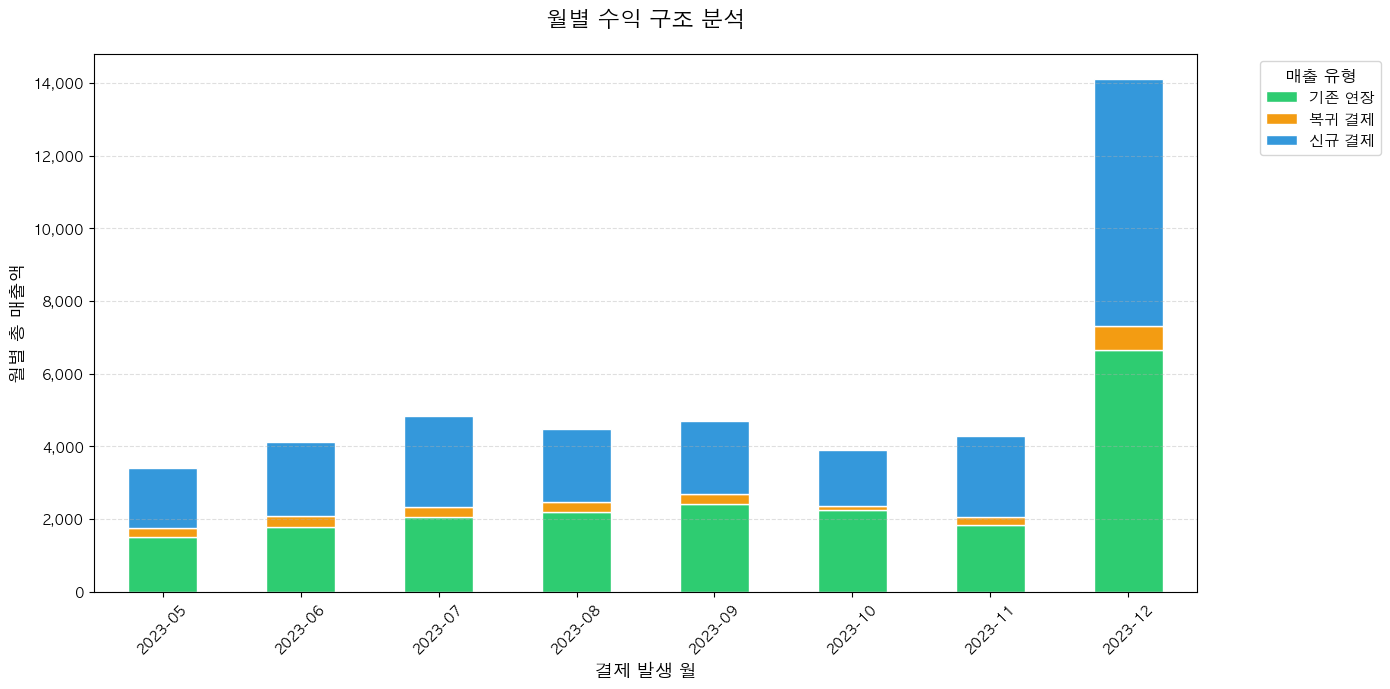

In [ ]:
sub_df = subscription[['client_event_time', 'paid_amount']].copy()
sub_df['revenue_month'] = pd.to_datetime(sub_df['client_event_time']).dt.to_period('M')
sub_df['revenue_type'] = '신규 결제'

renew_df = renew[['client_event_time', 'paid_amount']].copy()
renew_df['revenue_month'] = pd.to_datetime(renew_df['client_event_time']).dt.to_period('M')
renew_df['revenue_type'] = '기존 연장'

resub_df = resubscribe[['client_event_time', 'paid_amount']].copy()
resub_df['revenue_month'] = pd.to_datetime(resub_df['client_event_time']).dt.to_period('M')
resub_df['revenue_type'] = '복귀 결제'

all_revenue = pd.concat([sub_df, renew_df, resub_df], ignore_index=True)

monthly_revenue = all_revenue.groupby(['revenue_month', 'revenue_type'])['paid_amount'].sum().reset_index()

pivot_rev = monthly_revenue.pivot(index='revenue_month', columns='revenue_type', values='paid_amount').fillna(0)

pivot_rev = pivot_rev / 10000

pivot_rev.index = pivot_rev.index.astype(str)

cols_order = ['기존 연장', '복귀 결제', '신규 결제']
pivot_rev = pivot_rev[[col for col in cols_order if col in pivot_rev.columns]]

plt.figure(figsize=(14, 7))
ax = pivot_rev.plot(kind='bar', stacked=True, color=['#2ecc71', '#f39c12', '#3498db'], ax=plt.gca(), edgecolor='white')

plt.title('월별 수익 구조 분석', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('결제 발생 월', fontsize=13)
plt.ylabel('월별 총 매출액', fontsize=13)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

plt.legend(title='매출 유형', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

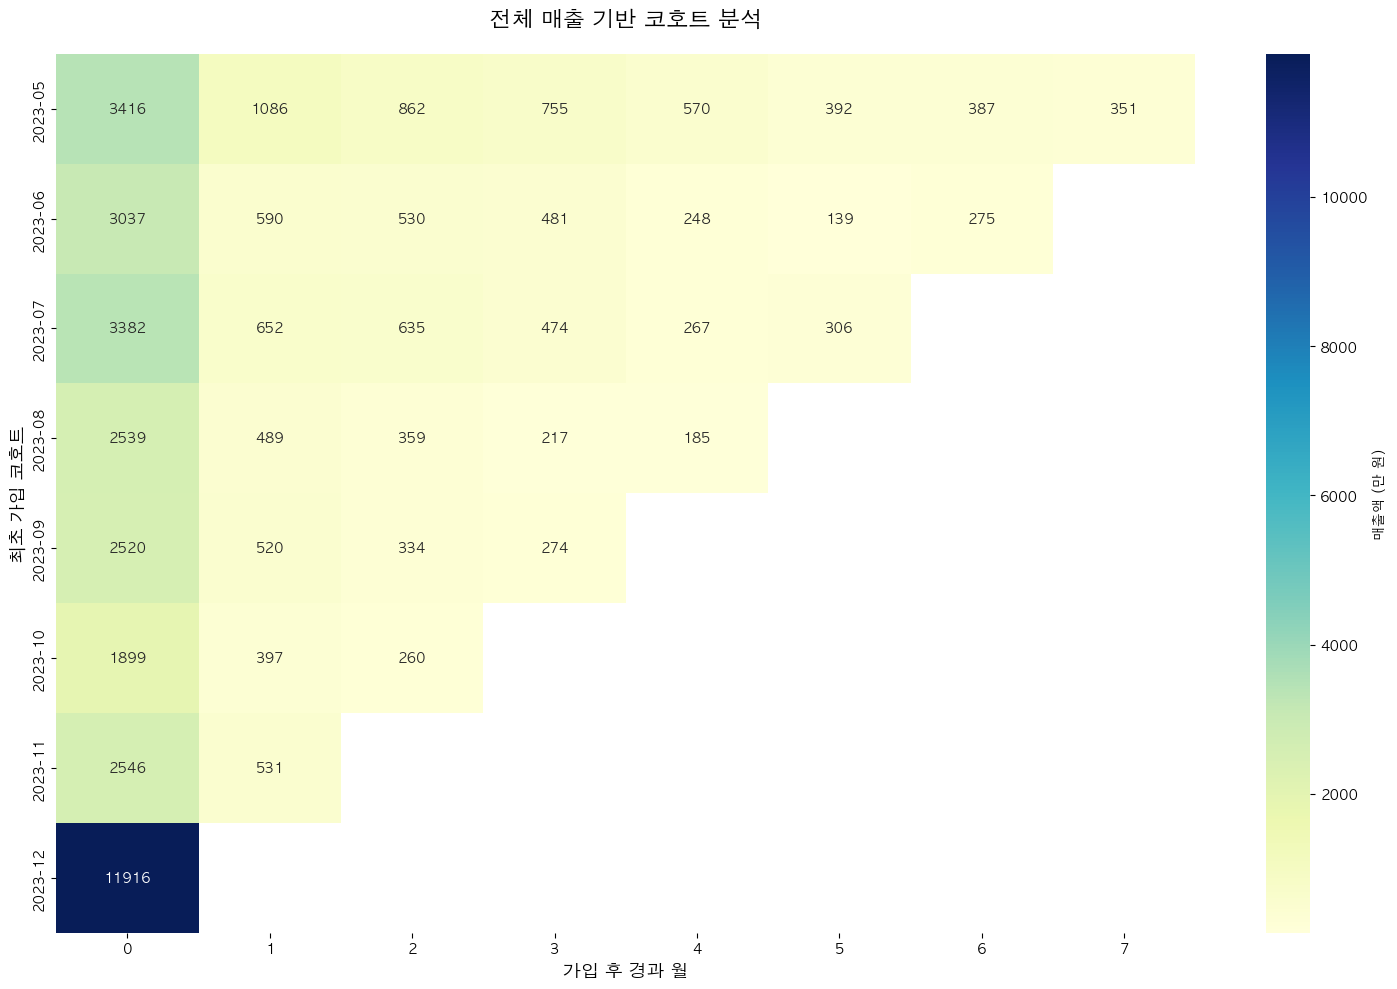

In [ ]:
all_rev = pd.concat([
    subscription[['user_id', 'client_event_time', 'paid_amount']],
    renew[['user_id', 'client_event_time', 'paid_amount']],
    resubscribe[['user_id', 'client_event_time', 'paid_amount']]
], ignore_index=True)
all_rev['revenue_month'] = all_rev['client_event_time'].dt.to_period('M')

user_first_touch = all_rev.groupby('user_id')['client_event_time'].min().dt.to_period('M').reset_index()
user_first_touch.columns = ['user_id', 'cohort_month']

merged = pd.merge(all_rev, user_first_touch, on='user_id')
merged['month_index'] = (merged['revenue_month'].dt.year - merged['cohort_month'].dt.year) * 12 + \
                        (merged['revenue_month'].dt.month - merged['cohort_month'].dt.month)

merged.loc[merged['cohort_month'] < '2023-05', 'cohort_month_str'] = 'Pre-2023-05'
merged.loc[merged['cohort_month'] >= '2023-05', 'cohort_month_str'] = merged['cohort_month'].astype(str)

cohort_revenue = merged.groupby(['cohort_month_str', 'month_index'])['paid_amount'].sum().reset_index()
cohort_revenue['paid_amount_10k'] = cohort_revenue['paid_amount'] / 10000

pivot_table = cohort_revenue.pivot_table(index='cohort_month_str', columns='month_index', values='paid_amount_10k')

pivot_table = pivot_table.iloc[:, :12]

plt.figure(figsize=(15, 10))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': '매출액 (만 원)'})
plt.title('전체 매출 기반 코호트 분석', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('가입 후 경과 월', fontsize=13)
plt.ylabel('최초 가입 코호트', fontsize=13)
plt.tight_layout()
plt.show()

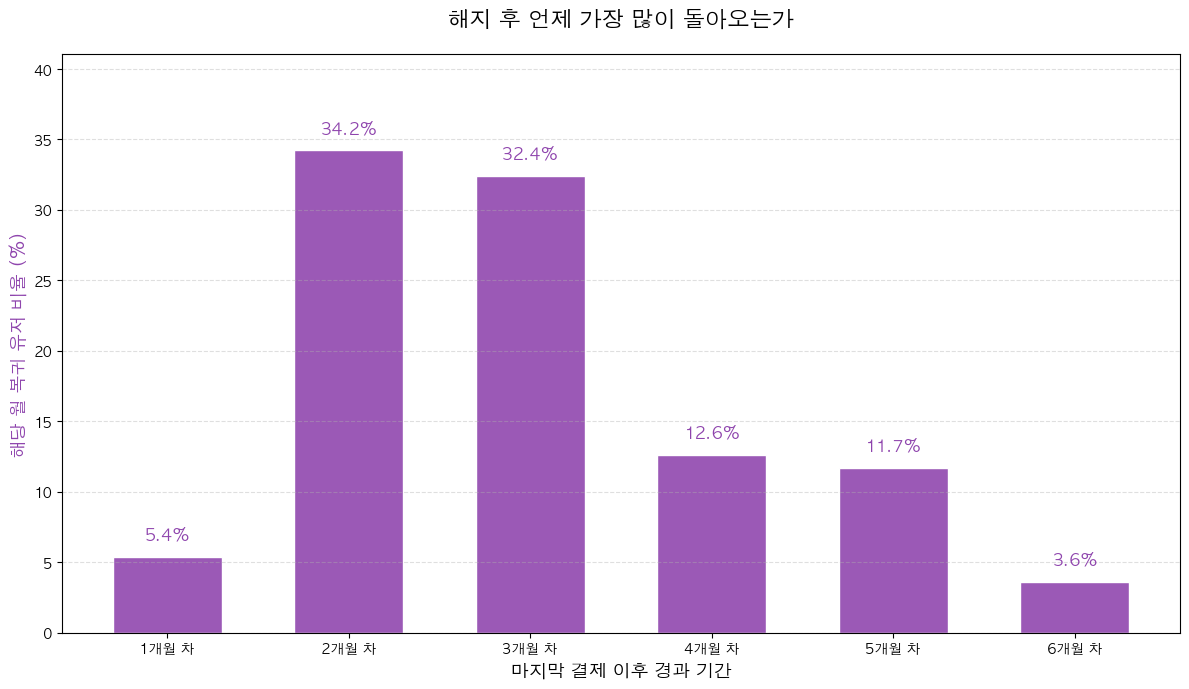

In [ ]:
first_resub = resubscribe.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_resub = first_resub[['user_id', 'client_event_time']]
first_resub.rename(columns={'client_event_time': 'resub_time'}, inplace=True)

sub_renew = pd.concat([subscription[['user_id', 'client_event_time']], renew[['user_id', 'client_event_time']]])

merged = pd.merge(first_resub, sub_renew, on='user_id', how='inner')
merged = merged[merged['client_event_time'] < merged['resub_time']]

last_active = merged.groupby('user_id')['client_event_time'].max().reset_index()
last_active.rename(columns={'client_event_time': 'last_active_time'}, inplace=True)

return_df = pd.merge(first_resub, last_active, on='user_id', how='inner')

return_df['resub_month'] = return_df['resub_time'].dt.to_period('M')
return_df['last_active_month'] = return_df['last_active_time'].dt.to_period('M')

return_df['month_gap'] = (return_df['resub_month'].dt.year - return_df['last_active_month'].dt.year) * 12 + \
                         (return_df['resub_month'].dt.month - return_df['last_active_month'].dt.month)

return_df = return_df[(return_df['month_gap'] > 0) & (return_df['month_gap'] <= 12)]

gap_dist = return_df['month_gap'].value_counts().sort_index().reset_index()
gap_dist.columns = ['month_gap', 'user_count']
gap_dist['percent'] = gap_dist['user_count'] / gap_dist['user_count'].sum() * 100

plt.figure(figsize=(12, 7))

bars = plt.bar(gap_dist['month_gap'].astype(str) + '개월 차', gap_dist['percent'], color='#9b59b6', edgecolor='white', width=0.6)

plt.xlabel('마지막 결제 이후 경과 기간', fontsize=13)
plt.ylabel('해당 월 복귀 유저 비율 (%)', fontsize=13, color='#8e44ad', fontweight='bold')
plt.ylim(0, max(gap_dist['percent']) * 1.2)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12, color='#8e44ad')

plt.title('해지 후 언제 가장 많이 돌아오는가', fontsize=16, fontweight='bold', pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

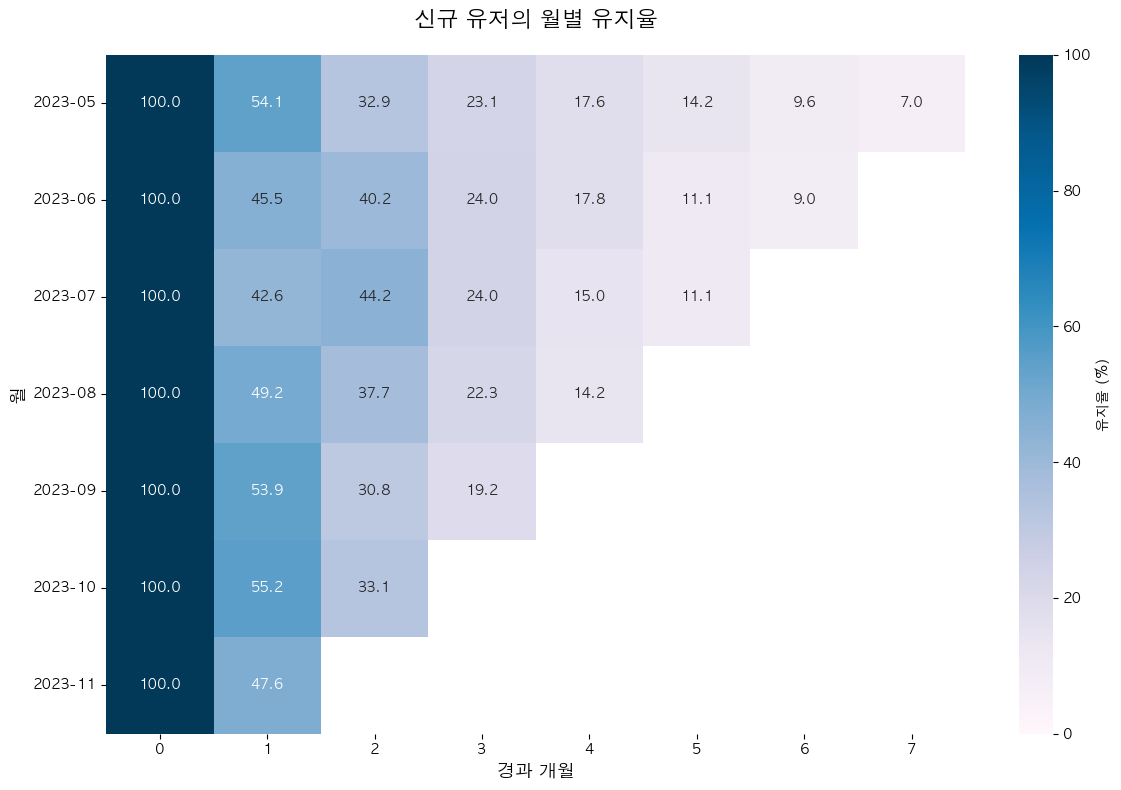

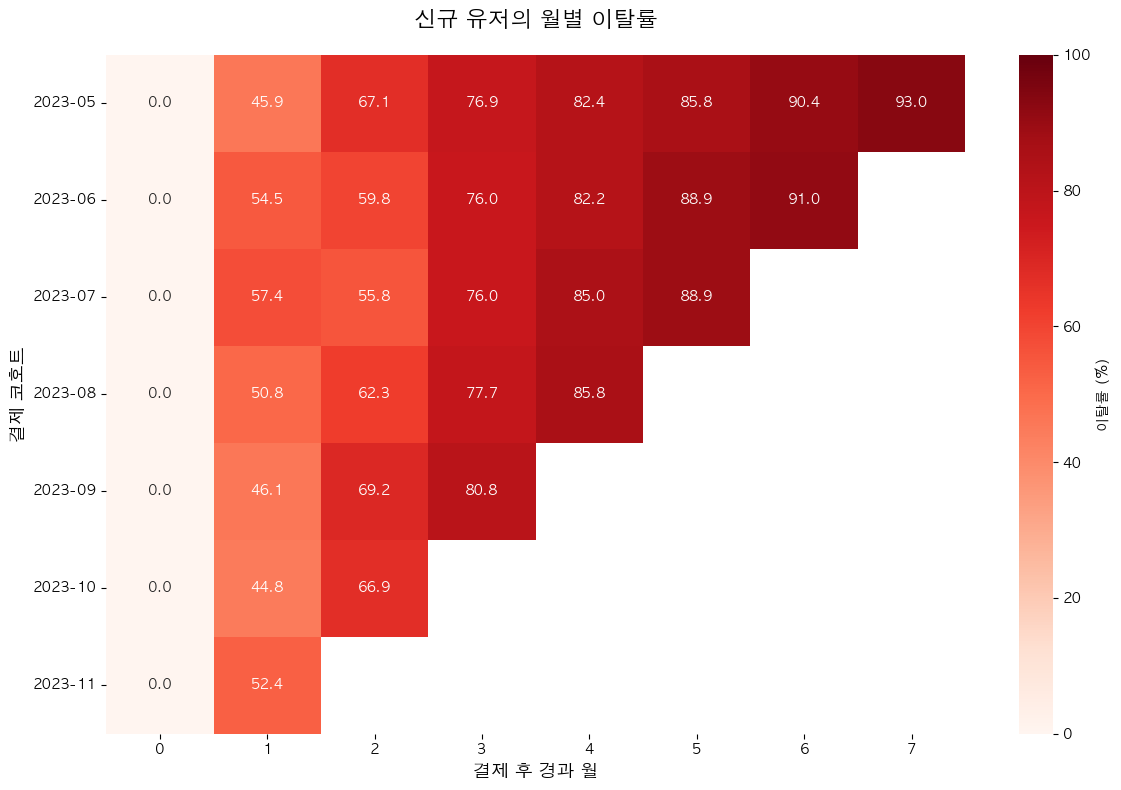

In [ ]:
first_sub = subscription.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_sub['cohort_month'] = first_sub['client_event_time'].dt.to_period('M')

cohort_sizes = first_sub.groupby('cohort_month')['user_id'].nunique().reset_index(name='cohort_size')

renew_df = renew.copy()
renew_df['renew_month'] = pd.to_datetime(renew_df['client_event_time']).dt.to_period('M')

merged = pd.merge(first_sub[['user_id', 'cohort_month']], renew_df[['user_id', 'renew_month']], on='user_id', how='inner')
merged['month_index'] = (merged['renew_month'].dt.year - merged['cohort_month'].dt.year) * 12 + \
                        (merged['renew_month'].dt.month - merged['cohort_month'].dt.month)

merged = merged[merged['month_index'] > 0]

active_users = merged.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index(name='active_users')

retention_df = pd.merge(active_users, cohort_sizes, on='cohort_month')
retention_df['retention_rate'] = (retention_df['active_users'] / retention_df['cohort_size']) * 100

retention_pivot = retention_df.pivot_table(index='cohort_month', columns='month_index', values='retention_rate')
churn_pivot = 100 - retention_pivot

retention_pivot.insert(0, 0, 100.0)
churn_pivot.insert(0, 0, 0.0)

retention_pivot.index = retention_pivot.index.astype(str)
churn_pivot.index = churn_pivot.index.astype(str)


plt.figure(figsize=(12, 8))
sns.heatmap(retention_pivot, annot=True, fmt='.1f', cmap='PuBu', vmin=0, vmax=100,
            cbar_kws={'label': '유지율 (%)'})
plt.title('신규 유저의 월별 유지율', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('경과 개월', fontsize=13)
plt.ylabel('월', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 8))
sns.heatmap(churn_pivot, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=100,
            cbar_kws={'label': '이탈률 (%)'})
plt.title('신규 유저의 월별 이탈률', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('결제 후 경과 월', fontsize=13)
plt.ylabel('결제 코호트', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

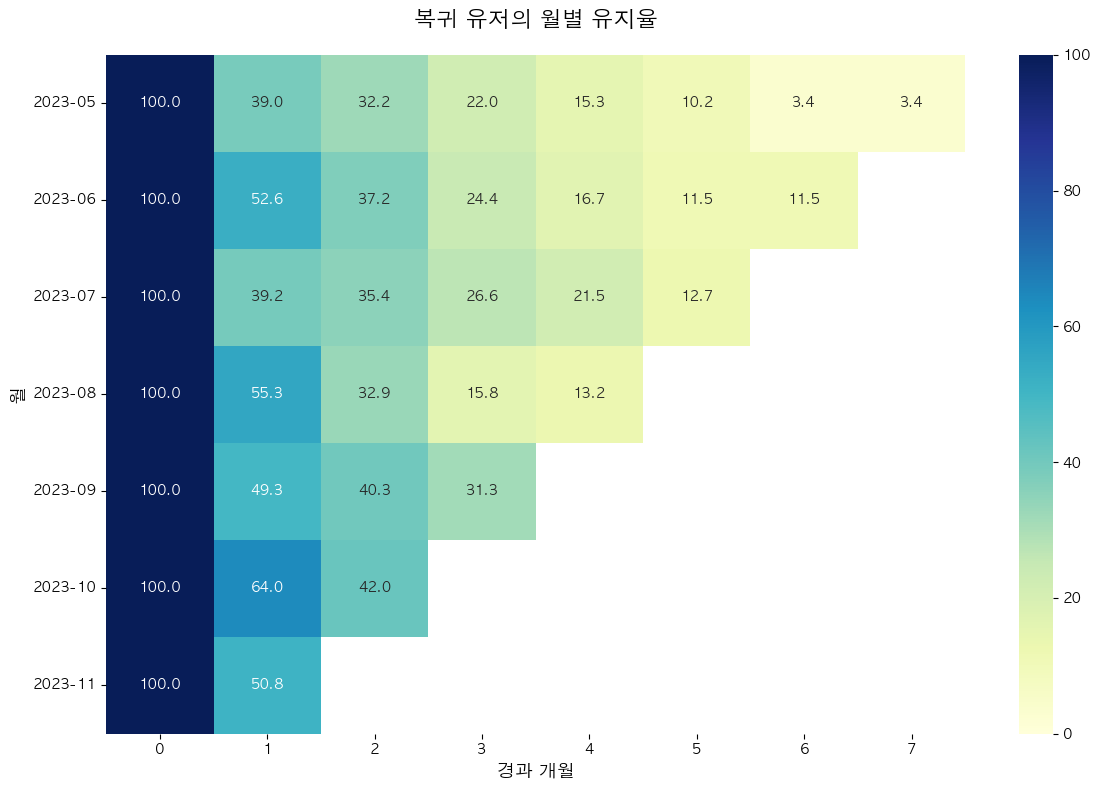

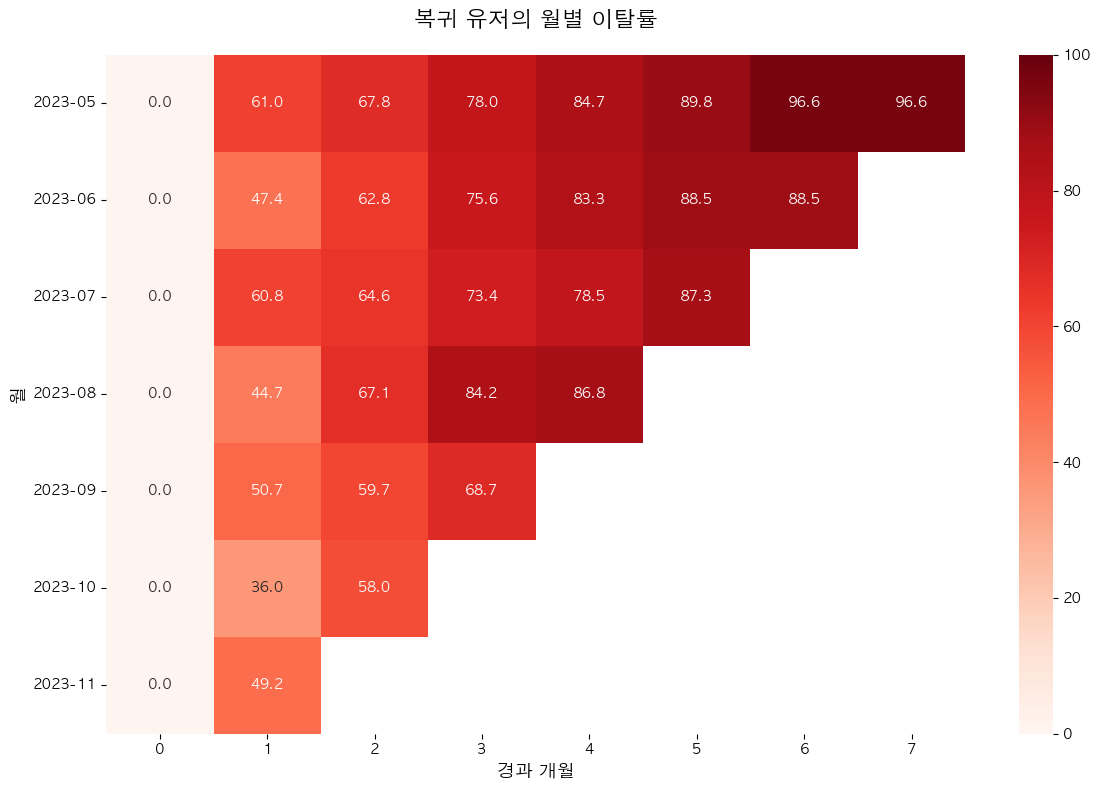

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

resubscribe_df = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_resubscribe_subscription_cohort.csv'))
resubscribe_df['client_event_time'] = pd.to_datetime(resubscribe_df['client_event_time'])
resubscribe_df['cohort_month'] = resubscribe_df['client_event_time'].dt.to_period('M')

cohort_sizes = resubscribe_df.groupby('cohort_month')['user_id'].nunique().reset_index(name='cohort_size')

renew_df = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_renew_subscription_cohort.csv'))
renew_df['renew_month'] = pd.to_datetime(renew_df['client_event_time']).dt.to_period('M')

merged = pd.merge(resubscribe_df[['user_id', 'cohort_month']], renew_df[['user_id', 'renew_month']], on='user_id', how='inner')
merged['month_index'] = (merged['renew_month'].dt.year - merged['cohort_month'].dt.year) * 12 + \
                        (merged['renew_month'].dt.month - merged['cohort_month'].dt.month)

merged = merged[merged['month_index'] > 0]
active_users = merged.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index(name='active_users')

retention_df = pd.merge(active_users, cohort_sizes, on='cohort_month')
retention_df['retention_rate'] = (retention_df['active_users'] / retention_df['cohort_size']) * 100

retention_pivot = retention_df.pivot_table(index='cohort_month', columns='month_index', values='retention_rate')
churn_pivot = 100 - retention_pivot

retention_pivot.insert(0, 0, 100.0)
churn_pivot.insert(0, 0, 0.0)

retention_pivot.index = retention_pivot.index.astype(str)
churn_pivot.index = churn_pivot.index.astype(str)

plt.rc('font', family=KOREAN_FONT)

plt.figure(figsize=(12, 8))
sns.heatmap(retention_pivot, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100)
plt.title('복귀 유저의 월별 유지율', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('경과 개월', fontsize=13)
plt.ylabel('월', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(churn_pivot, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=100)
plt.title('복귀 유저의 월별 이탈률', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('경과 개월', fontsize=13)
plt.ylabel('월', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

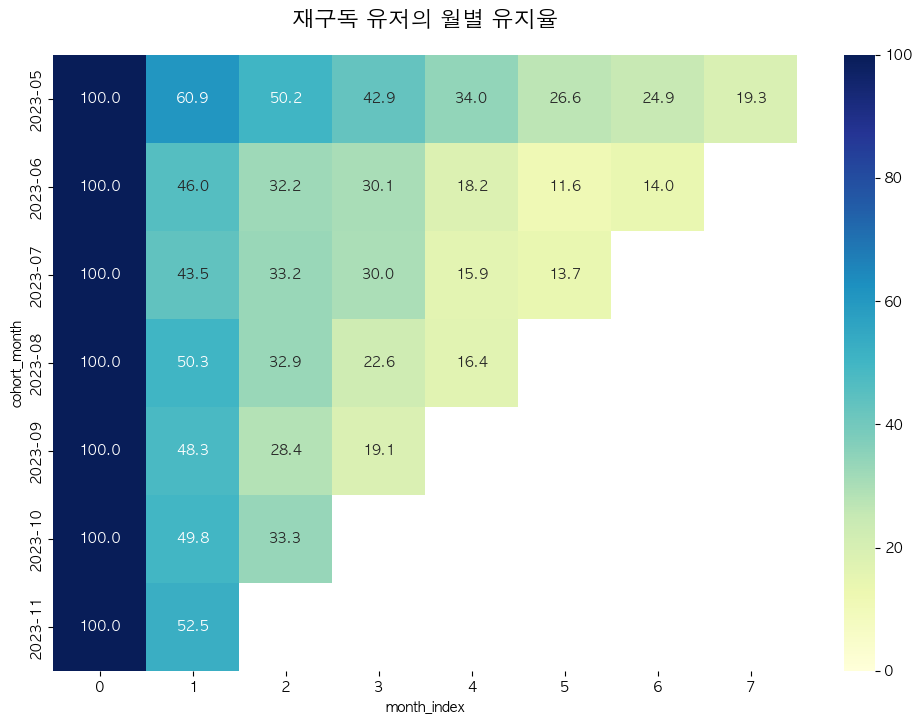

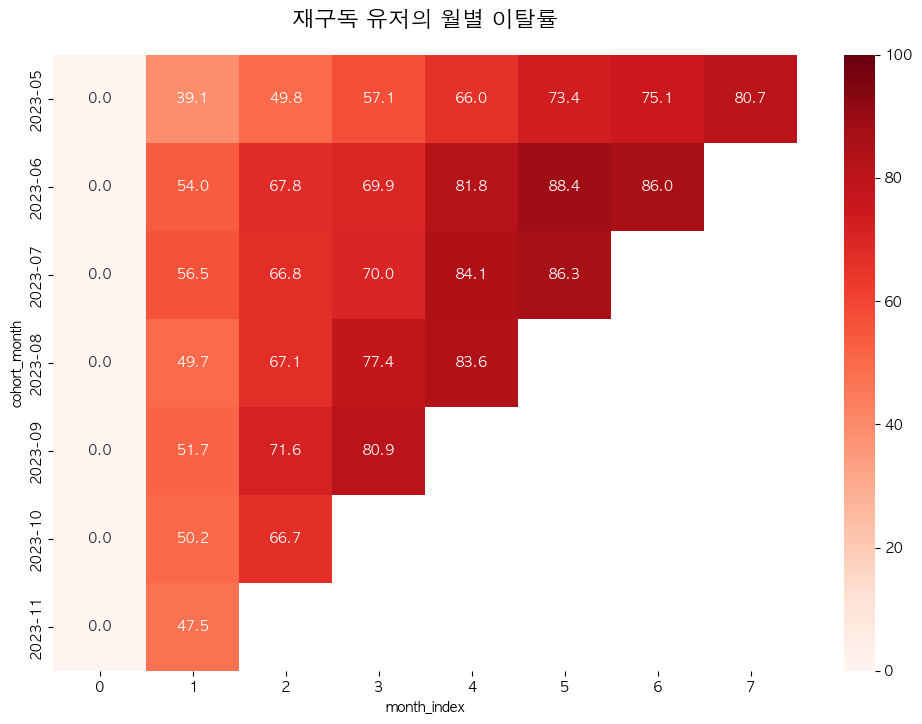

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

renew_df = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_renew_subscription_cohort.csv'))
renew_df['client_event_time'] = pd.to_datetime(renew_df['client_event_time'])
renew_df['month'] = renew_df['client_event_time'].dt.to_period('M')

first_renew = renew_df.sort_values('client_event_time').drop_duplicates('user_id', keep='first').copy()
first_renew['cohort_month'] = first_renew['month']

cohort_sizes = first_renew.groupby('cohort_month')['user_id'].nunique().reset_index(name='cohort_size')

merged = pd.merge(first_renew[['user_id', 'cohort_month']], renew_df[['user_id', 'month']], on='user_id', how='inner')
merged['month_index'] = (merged['month'].dt.year - merged['cohort_month'].dt.year) * 12 + \
                        (merged['month'].dt.month - merged['cohort_month'].dt.month)

merged = merged[merged['month_index'] > 0]
active_users = merged.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index(name='active_users')

retention_df = pd.merge(active_users, cohort_sizes, on='cohort_month')
retention_df['retention_rate'] = (retention_df['active_users'] / retention_df['cohort_size']) * 100

retention_pivot = retention_df.pivot_table(index='cohort_month', columns='month_index', values='retention_rate')
churn_pivot = 100 - retention_pivot

retention_pivot.insert(0, 0, 100.0)
churn_pivot.insert(0, 0, 0.0)

retention_pivot.index = retention_pivot.index.astype(str)
churn_pivot.index = churn_pivot.index.astype(str)

plt.figure(figsize=(12, 8))
sns.heatmap(retention_pivot, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100)
plt.title('재구독 유저의 월별 유지율', fontsize=16, fontweight='bold', pad=20)
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(churn_pivot, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=100)
plt.title('재구독 유저의 월별 이탈률', fontsize=16, fontweight='bold', pad=20)
plt.show()

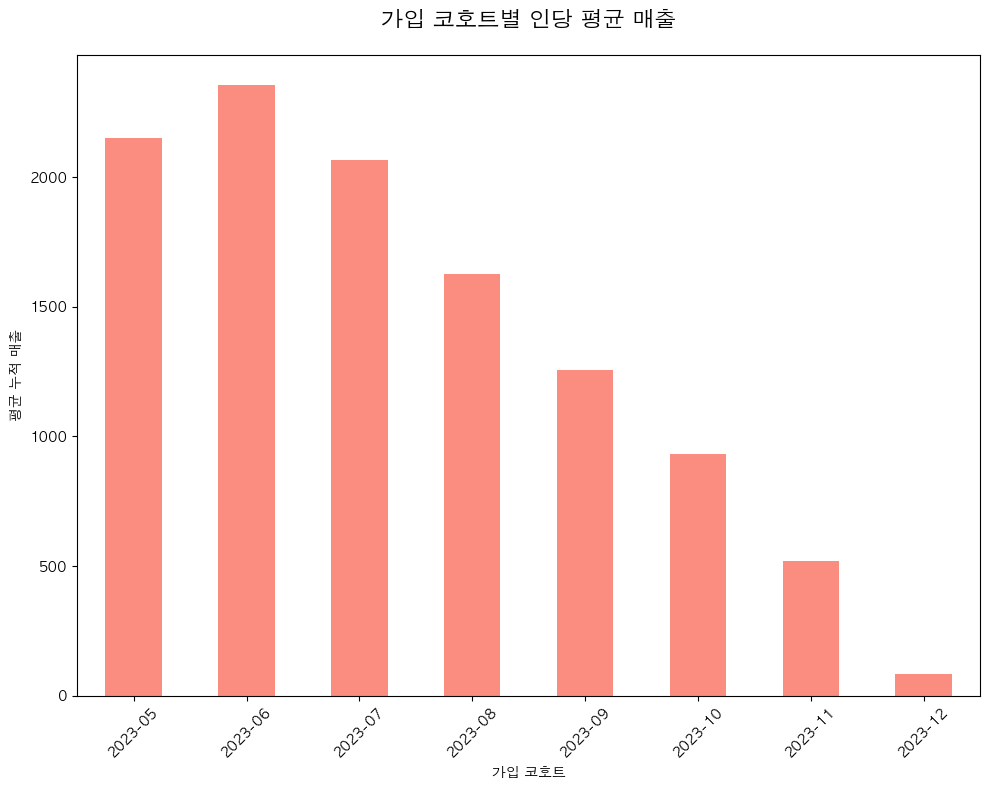

cohort_month
2023-05    2151.944143
2023-06    2354.659346
2023-07    2066.065534
2023-08    1625.177749
2023-09    1254.891634
2023-10     930.998589
2023-11     517.897245
2023-12      83.231463
Freq: M, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

signup = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_complete_signup_cohort.csv'))
resub = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_resubscribe_subscription_cohort.csv'))
renew = pd.read_csv(os.path.join(PATH_TIME_COHORT, 'raw_renew_subscription_cohort.csv'))

signup['month'] = pd.to_datetime(signup['client_event_time']).dt.to_period('M')
resub['month'] = pd.to_datetime(resub['client_event_time']).dt.to_period('M')
renew['month'] = pd.to_datetime(renew['client_event_time']).dt.to_period('M')

inflow = pd.concat([
    signup[['user_id', 'month']],
    resub[['user_id', 'month']]
]).drop_duplicates(subset=['user_id'], keep='first').copy()
inflow.columns = ['user_id', 'cohort_month']

cohort_sizes = inflow.groupby('cohort_month')['user_id'].nunique()

revenue_with_cohort = pd.merge(renew, inflow, on='user_id', how='inner')
total_revenue_per_cohort = revenue_with_cohort.groupby('cohort_month')['paid_amount'].sum()

arpu = total_revenue_per_cohort / cohort_sizes

plt.rc('font', family=KOREAN_FONT)
plt.figure(figsize=(10, 8))
arpu.plot(kind='bar', color='salmon', alpha=0.9)

plt.title('가입 코호트별 인당 평균 매출', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('가입 코호트')
plt.ylabel('평균 누적 매출')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(arpu)

# 2. Funnel

## 2-1. Funnel Part 1

# 사전 준비

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
# data_funnel_part1 경로는 상단 공통 설정 셀의 PATH_FUNNEL1 사용

In [ ]:
# 공통 데이터 기간
start_date = '2023-05-01'
end_date = '2024-01-01'

# 2년 데이터 필터링

## 메인 접속 및 회원가입
- enter.main_page (서비스 메인페이지 진입)
- enter.signup_page (회원가입 페이지 진입)
- complete.signup (회원가입 완료)

In [ ]:
enter_main = pd.read_csv(os.path.join(PATH_FUNNEL1, 'raw_enter_main_page_funnel1.csv'))
enter_signup = pd.read_csv(os.path.join(PATH_FUNNEL1, 'raw_enter_signup_page_funnel1.csv'))
complete_signup = pd.read_csv(os.path.join(PATH_FUNNEL1, 'raw_complete_signup_funnel1.csv'))

In [ ]:
print(enter_main.shape[0], enter_signup.shape[0], complete_signup.shape[0])

2133548 596829 145133


In [ ]:
display(enter_main.head(1))
display(enter_signup.head(1))
display(complete_signup.head(1))

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
0,Seongnam-si,2023-04-05 21:55:06,South Korea,NaN,Samsung Phone,Samsung Galaxy S21 5G,enter.main_page,Korean,Whale,1.0.0.0,Web,NaN


,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
0,Seoul,2023-04-05 21:30:43,South Korea,NaN,Samsung Phone,Samsung Galaxy A51 5G,enter.signup_page,Korean,Chrome,112.0.0.0,Web,NaN


,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,type
0,NaN,2023-04-05 21:33:26,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,74d17c27a41656e7788b0c81d9f76cda,kakao


In [ ]:
enter_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2133548 entries, 0 to 2133547
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   city               object 
 1   client_event_time  object 
 2   country            object 
 3   device_carrier     float64
 4   device_family      object 
 5   device_type        object 
 6   event_type         object 
 7   language           object 
 8   os_name            object 
 9   os_version         object 
 10  platform           object 
 11  user_id            object 
dtypes: float64(1), object(11)
memory usage: 195.3+ MB


In [ ]:
enter_signup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596829 entries, 0 to 596828
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   city               581024 non-null  object 
 1   client_event_time  596829 non-null  object 
 2   country            596315 non-null  object 
 3   device_carrier     0 non-null       float64
 4   device_family      596747 non-null  object 
 5   device_type        567387 non-null  object 
 6   event_type         596829 non-null  object 
 7   language           596829 non-null  object 
 8   os_name            596754 non-null  object 
 9   os_version         594650 non-null  object 
 10  platform           596829 non-null  object 
 11  user_id            0 non-null       float64
dtypes: float64(2), object(10)
memory usage: 54.6+ MB


In [ ]:
complete_signup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145133 entries, 0 to 145132
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   city               44774 non-null   object 
 1   client_event_time  145133 non-null  object 
 2   country            45756 non-null   object 
 3   device_carrier     0 non-null       float64
 4   device_family      45767 non-null   object 
 5   device_type        44659 non-null   object 
 6   event_type         145133 non-null  object 
 7   language           45767 non-null   object 
 8   os_name            45745 non-null   object 
 9   os_version         45651 non-null   object 
 10  platform           45767 non-null   object 
 11  user_id            145133 non-null  object 
 12  type               144958 non-null  object 
dtypes: float64(1), object(12)
memory usage: 14.4+ MB


In [ ]:
# datetime 타입 변경
enter_main['client_event_time'] = pd.to_datetime(enter_main['client_event_time'])
enter_signup['client_event_time'] = pd.to_datetime(enter_signup['client_event_time'])
complete_signup['client_event_time'] = pd.to_datetime(complete_signup['client_event_time'])

In [ ]:
# timestamp UTC -> KST로 변경
enter_main['client_event_time'] = enter_main['client_event_time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Seoul')
enter_signup['client_event_time'] = enter_signup['client_event_time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Seoul')
complete_signup['client_event_time'] = complete_signup['client_event_time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Seoul')

In [ ]:
# enter_main 은 2023년 12월 15일까지만 데이터 존재
display(enter_main['client_event_time'].min())
display(enter_main['client_event_time'].max())

Timestamp('1978-01-01 19:22:27+0900', tz='Asia/Seoul')

Timestamp('2023-12-15 11:46:11+0900', tz='Asia/Seoul')

In [ ]:
display(enter_signup['client_event_time'].min())
display(enter_signup['client_event_time'].max())

Timestamp('2021-11-25 09:08:18+0900', tz='Asia/Seoul')

Timestamp('2024-01-01 08:59:22+0900', tz='Asia/Seoul')

In [ ]:
display(complete_signup['client_event_time'].min())
display(complete_signup['client_event_time'].max())

Timestamp('2022-01-01 09:06:31+0900', tz='Asia/Seoul')

Timestamp('2024-01-01 08:51:54+0900', tz='Asia/Seoul')

In [ ]:
# 데이터 기간 필터링
enter_main = enter_main[(enter_main['client_event_time'] >= start_date) & (enter_main['client_event_time'] < end_date)]
enter_signup = enter_signup[(enter_signup['client_event_time'] >= start_date) & (enter_signup['client_event_time'] < end_date)]
complete_signup = complete_signup[(complete_signup['client_event_time'] >= start_date) & (complete_signup['client_event_time'] < end_date)]

In [ ]:
display(enter_main['client_event_time'].min())
display(enter_main['client_event_time'].max())

Timestamp('2023-05-01 00:00:10+0900', tz='Asia/Seoul')

Timestamp('2023-12-15 11:46:11+0900', tz='Asia/Seoul')

In [ ]:
display(enter_signup['client_event_time'].min())
display(enter_signup['client_event_time'].max())

Timestamp('2023-05-01 00:00:40+0900', tz='Asia/Seoul')

Timestamp('2023-12-31 23:59:29+0900', tz='Asia/Seoul')

In [ ]:
display(complete_signup['client_event_time'].min())
display(complete_signup['client_event_time'].max())

Timestamp('2023-05-01 00:03:00+0900', tz='Asia/Seoul')

Timestamp('2023-12-31 23:41:02+0900', tz='Asia/Seoul')

In [ ]:
enter_main.isna().sum()

city                  15486
client_event_time         0
country                 380
device_carrier       602958
device_family           827
device_type           46429
event_type                0
language                  0
os_name                 648
os_version             2803
platform                  0
user_id              573688
dtype: int64

In [ ]:
enter_signup.isna().sum()

city                   7253
client_event_time         0
country                 186
device_carrier       263638
device_family             9
device_type           25973
event_type                0
language                  0
os_name                   8
os_version              759
platform                  0
user_id              263638
dtype: int64

In [ ]:
complete_signup.isna().sum()

city                 44980
client_event_time        0
country              44751
device_carrier       55982
device_family        44747
device_type          45667
event_type               0
language             44747
os_name              44747
os_version           44784
platform             44747
user_id                  0
type                     0
dtype: int64

In [ ]:
# 퍼널별 이벤트 카운팅
print(enter_main.shape[0], enter_signup.shape[0], complete_signup.shape[0])

602958 263638 55982


In [ ]:
complete_signup.shape[0] / enter_signup.shape[0]

0.21234419924290124

In [ ]:
# 비회원 메인 페이지 접속 수
enter_main['user_id'].isna().sum()

np.int64(573688)

In [ ]:
# 비회원 메인 페이지 접속 대비 회원가입 진입율
enter_signup.shape[0] / (enter_main['user_id'].isna().sum())

np.float64(0.45954944150827626)

In [ ]:
# 비회원 메인 페이지 접속 대비 회원가입 완료율
complete_signup.shape[0] / (enter_main['user_id'].isna().sum())

np.float64(0.09758265816959741)

## 결제/구독
- enter.payment_page (결제 페이지 진입)
- complete.subscription (첫 결제 완료)
- renew.subscription (정기 결제 완료 -> 구독을 취소하지 않고 연장된)
- resubscribe.subscription (만료 후 재구독 완료 -> 구독을 취소했다가 다시 재구독)

In [ ]:
enter_payment = pd.read_csv(os.path.join(PATH_FUNNEL1, 'raw_enter_payment_page_funnel1.csv'))
complete_first_subs = pd.read_csv(os.path.join(PATH_FUNNEL1, 'raw_complete_subscription_funnel1.csv'))
renew_subs = pd.read_csv(os.path.join(PATH_FUNNEL1, 'raw_renew_subscription_funnel1.csv'))
resubscribe_subs = pd.read_csv(os.path.join(PATH_FUNNEL1, 'raw_resubscribe_subscription_funnel1.csv'))

In [ ]:
print(enter_payment.shape[0], complete_first_subs.shape[0], renew_subs.shape[0], resubscribe_subs.shape[0])

165061 14289 15945 791


In [ ]:
display(enter_payment.head(1))
display(complete_first_subs.head(1))
display(renew_subs.head(1))
display(resubscribe_subs.head(1))

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
0,Seoul,2023-04-05 21:31:28,South Korea,NaN,Samsung Phone,Samsung Galaxy A51 5G,enter.payment_page,Korean,Chrome,112.0.0.0,Web,8ee58bcaa05b234cdbf84167c0983385


,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,coupon.discount_amount,pg.type
0,Nowon-gu,2023-04-05 21:40:04,South Korea,NaN,Windows,Windows,complete.subscription,Korean,Edge,111.0.1661.62,Web,1116a2ae90ca6b06f85feba27ad51ef0,15920,15920,0,NaN


,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,coupon.discount_amount,pg.type
0,Nam-gu,2022-09-08 03:05:02,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Edge,104,Web,6ddea3af2eaae869861c1190dcc9d4a3,15920,15920,0,NaN


,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,coupon.discount_amount,pg.type
0,Daejeon,2023-04-05 21:11:46,South Korea,NaN,Windows,Windows,resubscribe.subscription,Korean,Edge,111.0.1661.62,Web,41362ad5ebcade2bb1b78344a53e7ccf,15920,15920,0,NaN


In [ ]:
enter_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165061 entries, 0 to 165060
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   city               162362 non-null  object 
 1   client_event_time  165061 non-null  object 
 2   country            164899 non-null  object 
 3   device_carrier     0 non-null       float64
 4   device_family      165060 non-null  object 
 5   device_type        159066 non-null  object 
 6   event_type         165061 non-null  object 
 7   language           165061 non-null  object 
 8   os_name            165061 non-null  object 
 9   os_version         164560 non-null  object 
 10  platform           165061 non-null  object 
 11  user_id            158834 non-null  object 
dtypes: float64(1), object(11)
memory usage: 15.1+ MB


In [ ]:
complete_first_subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14289 entries, 0 to 14288
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    13757 non-null  object 
 1   client_event_time       14289 non-null  object 
 2   country                 13906 non-null  object 
 3   device_carrier          0 non-null      float64
 4   device_family           13914 non-null  object 
 5   device_type             13764 non-null  object 
 6   event_type              14289 non-null  object 
 7   language                13914 non-null  object 
 8   os_name                 13908 non-null  object 
 9   os_version              13899 non-null  object 
 10  platform                13914 non-null  object 
 11  user_id                 14289 non-null  object 
 12  plan.price              14289 non-null  int64  
 13  paid_amount             14289 non-null  int64  
 14  coupon.discount_amount  14289 non-null

In [ ]:
renew_subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15945 entries, 0 to 15944
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    15575 non-null  object 
 1   client_event_time       15945 non-null  object 
 2   country                 15656 non-null  object 
 3   device_carrier          0 non-null      float64
 4   device_family           15657 non-null  object 
 5   device_type             15484 non-null  object 
 6   event_type              15945 non-null  object 
 7   language                15657 non-null  object 
 8   os_name                 15654 non-null  object 
 9   os_version              15644 non-null  object 
 10  platform                15657 non-null  object 
 11  user_id                 15945 non-null  object 
 12  plan.price              15945 non-null  int64  
 13  paid_amount             15945 non-null  int64  
 14  coupon.discount_amount  15945 non-null

In [ ]:
resubscribe_subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    775 non-null    object 
 1   client_event_time       791 non-null    object 
 2   country                 784 non-null    object 
 3   device_carrier          0 non-null      float64
 4   device_family           784 non-null    object 
 5   device_type             773 non-null    object 
 6   event_type              791 non-null    object 
 7   language                784 non-null    object 
 8   os_name                 784 non-null    object 
 9   os_version              784 non-null    object 
 10  platform                784 non-null    object 
 11  user_id                 791 non-null    object 
 12  plan.price              791 non-null    int64  
 13  paid_amount             791 non-null    int64  
 14  coupon.discount_amount  791 non-null    in

In [ ]:
# datetime 타입 변경
enter_payment['client_event_time'] = pd.to_datetime(enter_payment['client_event_time'])
complete_first_subs['client_event_time'] = pd.to_datetime(complete_first_subs['client_event_time'])
renew_subs['client_event_time'] = pd.to_datetime(renew_subs['client_event_time'])
resubscribe_subs['client_event_time'] = pd.to_datetime(resubscribe_subs['client_event_time'])

In [ ]:
# timestamp UTC -> KST로 변경
enter_payment['client_event_time'] = enter_payment['client_event_time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Seoul')
complete_first_subs['client_event_time'] = complete_first_subs['client_event_time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Seoul')
renew_subs['client_event_time'] = renew_subs['client_event_time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Seoul')
resubscribe_subs['client_event_time'] = resubscribe_subs['client_event_time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Seoul')

In [ ]:
# enter_payment 2023년 12월 10일까지만 데이터 존재
display(enter_payment['client_event_time'].min())
display(enter_payment['client_event_time'].max())

Timestamp('2022-11-03 11:39:46+0900', tz='Asia/Seoul')

Timestamp('2023-12-10 23:56:01+0900', tz='Asia/Seoul')

In [ ]:
display(complete_first_subs['client_event_time'].min())
display(complete_first_subs['client_event_time'].max())

Timestamp('2022-01-01 15:17:25+0900', tz='Asia/Seoul')

Timestamp('2024-01-01 01:27:37+0900', tz='Asia/Seoul')

In [ ]:
display(renew_subs['client_event_time'].min())
display(renew_subs['client_event_time'].max())

Timestamp('2022-09-08 12:05:02+0900', tz='Asia/Seoul')

Timestamp('2024-01-01 01:10:03+0900', tz='Asia/Seoul')

In [ ]:
display(resubscribe_subs['client_event_time'].min())
display(resubscribe_subs['client_event_time'].max())

Timestamp('2022-09-08 14:42:30+0900', tz='Asia/Seoul')

Timestamp('2024-01-01 02:21:27+0900', tz='Asia/Seoul')

In [ ]:
# 데이터 기간 필터링
enter_payment = enter_payment[(enter_payment['client_event_time'] >= start_date) & (enter_payment['client_event_time'] < end_date)]
complete_first_subs = complete_first_subs[(complete_first_subs['client_event_time'] >= start_date) & (complete_first_subs['client_event_time'] < end_date)]
renew_subs = renew_subs[(renew_subs['client_event_time'] >= start_date) & (renew_subs['client_event_time'] < end_date)]
resubscribe_subs = resubscribe_subs[(resubscribe_subs['client_event_time'] >= start_date) & (resubscribe_subs['client_event_time'] < end_date)]

In [ ]:
# enter_payment 2023년 12월 10일까지만 데이터 존재
display(enter_payment['client_event_time'].min())
display(enter_payment['client_event_time'].max())

Timestamp('2023-05-01 00:03:08+0900', tz='Asia/Seoul')

Timestamp('2023-12-10 23:56:01+0900', tz='Asia/Seoul')

In [ ]:
display(complete_first_subs['client_event_time'].min())
display(complete_first_subs['client_event_time'].max())

Timestamp('2023-05-01 00:03:59+0900', tz='Asia/Seoul')

Timestamp('2023-12-31 23:59:39+0900', tz='Asia/Seoul')

In [ ]:
display(renew_subs['client_event_time'].min())
display(renew_subs['client_event_time'].max())

Timestamp('2023-05-01 00:00:24+0900', tz='Asia/Seoul')

Timestamp('2023-12-31 23:50:02+0900', tz='Asia/Seoul')

In [ ]:
display(resubscribe_subs['client_event_time'].min())
display(resubscribe_subs['client_event_time'].max())

Timestamp('2023-05-01 13:57:30+0900', tz='Asia/Seoul')

Timestamp('2023-12-31 23:57:02+0900', tz='Asia/Seoul')

In [ ]:
enter_payment.isna().sum()

city                  1405
client_event_time        0
country                 69
device_carrier       93570
device_family            0
device_type           5026
event_type               0
language                 0
os_name                  0
os_version             108
platform                 0
user_id               4585
dtype: int64

In [ ]:
complete_first_subs.isna().sum()

city                       278
client_event_time            0
country                    229
device_carrier            4943
device_family              229
device_type                355
event_type                   0
language                   229
os_name                    229
os_version                 233
platform                   229
user_id                      0
plan.price                   0
paid_amount                  0
coupon.discount_amount       0
pg.type                   3307
dtype: int64

In [ ]:
renew_subs.isna().sum()

city                       114
client_event_time            0
country                     76
device_carrier            8401
device_family               76
device_type                241
event_type                   0
language                    76
os_name                     76
os_version                  84
platform                    76
user_id                      0
plan.price                   0
paid_amount                  0
coupon.discount_amount       0
pg.type                   5670
dtype: int64

In [ ]:
resubscribe_subs.isna().sum()

city                       13
client_event_time           0
country                     5
device_carrier            574
device_family               5
device_type                16
event_type                  0
language                    5
os_name                     5
os_version                  5
platform                    5
user_id                     0
plan.price                  0
paid_amount                 0
coupon.discount_amount      0
pg.type                   403
dtype: int64

In [ ]:
# 퍼널별 이벤트 카운팅
print(enter_payment.shape[0], complete_first_subs.shape[0], renew_subs.shape[0], resubscribe_subs.shape[0])

93570 4943 8401 574


In [ ]:
complete_first_subs[['plan.price','paid_amount','coupon.discount_amount']].value_counts()

plan.price  paid_amount  coupon.discount_amount
15920       15920        0                         2841
95520       95520        0                          847
131600      131600       0                          534
15920       13532        2388                       270
            14328        1592                       217
131600      111860       19740                      100
            118440       13160                       95
95520       93520        2000                        17
14328       14328        0                            7
15920       7960         7960                         4
            14805        1115                         2
118440      118440       0                            2
15920       12736        3184                         1
131600      78960        52640                        1
            98700        32900                        1
            105280       26320                        1
15920       11940        3980                         1


In [ ]:
complete_first_subs['plan.price'].unique()

array([ 15920, 131600,  14328, 118440,  95520])

In [ ]:
renew_subs[['plan.price','paid_amount','coupon.discount_amount']].value_counts()

plan.price  paid_amount  coupon.discount_amount
15920       15920        0                         6525
            7960         7960                       590
95520       95520        0                          536
131600      131600       0                          317
42960       42960        0                          188
15920       13532        2388                       127
131600      92119        39481                       27
14328       14328        0                           16
15920       12736        3184                        16
131600      111860       19740                       15
15920       15442        478                          8
131600      105280       26320                        7
15920       15124        796                          6
            11940        3980                         5
131600      127652       3948                         4
15920       14805        1115                         2
            14328        1592                         2


In [ ]:
renew_subs['plan.price'].unique()

array([ 15920,  42960, 131600,  14328, 118440,  95520])

In [ ]:
resubscribe_subs[['plan.price','paid_amount','coupon.discount_amount']].value_counts()

plan.price  paid_amount  coupon.discount_amount
15920       15920        0                         364
95520       95520        0                          91
131600      131600       0                          71
15920       13532        2388                       17
131600      111860       19740                       6
15920       15124        796                         5
            15442        478                         5
131600      98700        32900                       5
            127652       3948                        3
15920       9552         6368                        2
            11940        3980                        2
            7960         7960                        1
131600      119756       11844                       1
            125020       6580                        1
Name: count, dtype: int64

In [ ]:
resubscribe_subs['plan.price'].unique()

array([ 15920, 131600,  95520])

In [ ]:
print(enter_payment.shape[0], complete_first_subs.shape[0], renew_subs.shape[0], resubscribe_subs.shape[0])

93570 4943 8401 574


In [ ]:
(complete_first_subs.shape[0] + renew_subs.shape[0] + resubscribe_subs.shape[0]) / enter_payment.shape[0]

0.14874425563749064

## 구독 취소
- click.cancel_plan_button

In [ ]:
cancel_subs = pd.read_csv(os.path.join(PATH_FUNNEL1, 'raw_click_cancel_plan_button_funnel1.csv'))

In [ ]:
display(cancel_subs.head(1))

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
0,Daegu,2023-04-10 14:57:49,South Korea,NaN,Windows,Windows,click.cancel_plan_button,Korean,Chrome,111.0.0.0,Web,9e59ecf9a8fbe9051bd0d54f4b702f30


In [ ]:
# datetime 타입 변경
cancel_subs['client_event_time'] = pd.to_datetime(cancel_subs['client_event_time'])

In [ ]:
# timestamp UTC -> KST로 변경
cancel_subs['client_event_time'] = cancel_subs['client_event_time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Seoul')

In [ ]:
display(cancel_subs['client_event_time'].min())
display(cancel_subs['client_event_time'].max())

Timestamp('2021-12-04 21:53:22+0900', tz='Asia/Seoul')

Timestamp('2024-01-01 07:11:44+0900', tz='Asia/Seoul')

In [ ]:
# 데이터 기간 필터링
cancel_subs = cancel_subs[(cancel_subs['client_event_time'] >= start_date) & (cancel_subs['client_event_time'] < end_date)]

In [ ]:
display(cancel_subs['client_event_time'].min())
display(cancel_subs['client_event_time'].max())

Timestamp('2023-05-01 00:02:11+0900', tz='Asia/Seoul')

Timestamp('2023-12-31 23:58:19+0900', tz='Asia/Seoul')

In [ ]:
cancel_subs.isna().sum()

city                   54
client_event_time       0
country                 0
device_carrier       6058
device_family           0
device_type           283
event_type              0
language                0
os_name                 0
os_version              0
platform                0
user_id               954
dtype: int64

In [ ]:
cancel_subs.shape[0]

6058

In [ ]:
# 동일기간 전체 구독 발생 수 대비 구독 취소 비율
cancel_subs.shape[0] / (complete_first_subs.shape[0] + renew_subs.shape[0] + resubscribe_subs.shape[0])

0.4352636873113953

# 신규회원 퍼널 분석
- 교육 구독 플랫폼의 특성상 content, lesson의 반복 접속이 메인 페이지 접속 수보다 많음
- 따라서 이 숫자를 그대로 전환율로 계산할 수 없으므로 획득의 관점에서 퍼널 전환이 제대로 되는지 확인하고자 함
- 메인 페이지 접속 > 회원가입 진입 > 회원가입 완료 > 결제 페이지 진입 > 첫 구독 완료 | 구독 갱신 또는 구독취소 로그 추적

## EDA 및 퍼널 데이터 준비

### 메인 페이지 접속

In [ ]:
enter_main.shape

(602958, 12)

In [ ]:
# 중복값 체크
enter_main[enter_main.duplicated(keep=False)].sort_values('client_event_time').head(10)

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
293064,Seongnam-si,2023-05-01 17:28:38+09:00,South Korea,NaN,Windows,Windows,enter.main_page,Korean,Chrome,112.0.0.0,Web,NaN
293065,Seongnam-si,2023-05-01 17:28:38+09:00,South Korea,NaN,Windows,Windows,enter.main_page,Korean,Chrome,112.0.0.0,Web,NaN
564518,Seoul,2023-05-02 03:44:44+09:00,South Korea,NaN,Apple iPhone,Apple iPhone,enter.main_page,Korean,Mobile Safari,16.1,Web,NaN
564510,Seoul,2023-05-02 03:44:44+09:00,South Korea,NaN,Apple iPhone,Apple iPhone,enter.main_page,Korean,Mobile Safari,16.1,Web,NaN
45832,Seoul,2023-05-02 14:43:30+09:00,South Korea,NaN,Mac,Mac,enter.main_page,Korean,Chrome,112.0.0.0,Web,NaN
45833,Seoul,2023-05-02 14:43:30+09:00,South Korea,NaN,Mac,Mac,enter.main_page,Korean,Chrome,112.0.0.0,Web,NaN
362801,Seoul,2023-05-02 16:09:06+09:00,South Korea,NaN,Mac,Mac,enter.main_page,Korean,Chrome,112.0.0.0,Web,NaN
362800,Seoul,2023-05-02 16:09:06+09:00,South Korea,NaN,Mac,Mac,enter.main_page,Korean,Chrome,112.0.0.0,Web,NaN
162348,Gwangjin-gu,2023-05-03 23:11:48+09:00,South Korea,NaN,Samsung Phone,Samsung Galaxy Note20 5G,enter.main_page,Korean,Chrome WebView,111.0.5563.116,Web,NaN
162347,Gwangjin-gu,2023-05-03 23:11:48+09:00,South Korea,NaN,Samsung Phone,Samsung Galaxy Note20 5G,enter.main_page,Korean,Chrome WebView,111.0.5563.116,Web,NaN


- 로그에서 모든 열 값이 중복되는 행들은 로그가 중복으로 수집된 것으로 판단하여 중복값 제거

In [ ]:
# 중복값 제거
enter_main = enter_main.drop_duplicates()

In [ ]:
enter_main.duplicated().sum()

np.int64(0)

In [ ]:
enter_main.shape

(602174, 12)

In [ ]:
# 결측치 확인
enter_main.isna().sum()

city                  15410
client_event_time         0
country                 380
device_carrier       602174
device_family           806
device_type           46301
event_type                0
language                  0
os_name                 648
os_version             2803
platform                  0
user_id              572920
dtype: int64

In [ ]:
# enter_main['user_id'].nunique()

- user_id가 결측치인 행이 비회원 접속이므로 신규회원 목적에 맞게 user_id가 결측치인 행만 필터링

In [ ]:
# 비회원 접속만 추리기
new_member_enter_main = enter_main[enter_main['user_id'].isna()]

In [ ]:
new_member_enter_main.shape

(572920, 12)

In [ ]:
new_member_enter_main.isna().sum()

city                  15237
client_event_time         0
country                 366
device_carrier       572920
device_family           806
device_type           45881
event_type                0
language                  0
os_name                 648
os_version             2795
platform                  0
user_id              572920
dtype: int64

In [ ]:
new_member_enter_main['user_id'].nunique()

0

- 퍼널 분석에 필요한 client_event_time, event_type가 결측치가 없으므로 이대로 진행

In [ ]:
enter_main

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
574,Seocho-gu,2023-05-28 03:09:10+09:00,South Korea,NaN,Mac,Mac,enter.main_page,Korean,Chrome,113.0.0.0,Web,d3b2f51ede04364bd9861f8d261f26ec
575,Seocho-gu,2023-05-28 03:05:07+09:00,South Korea,NaN,Apple iPhone,Apple iPhone,enter.main_page,Korean,Chrome,113.0.5672.121,Web,26ad178fe8a2c8b2f4a4195eefad041f
576,Seoul,2023-05-28 03:09:00+09:00,South Korea,NaN,Mac,Mac,enter.main_page,Korean,Safari,16.4,Web,26ad178fe8a2c8b2f4a4195eefad041f
577,Ulsan,2023-05-28 03:05:03+09:00,South Korea,NaN,Windows,Windows,enter.main_page,Korean,Chrome,113.0.0.0,Web,NaN
578,Seoul,2023-05-28 03:30:35+09:00,South Korea,NaN,Samsung SM-S918N,NaN,enter.main_page,Korean,Instagram,284.0.0.22.85,Web,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2133543,Jeongeup,2023-10-10 14:53:29+09:00,South Korea,NaN,Windows,Windows,enter.main_page,Korean,Chrome,117.0.0.0,Web,NaN
2133544,Jeongeup,2023-10-10 14:54:18+09:00,South Korea,NaN,Windows,Windows,enter.main_page,Korean,Chrome,117.0.0.0,Web,NaN
2133545,Gangnam-gu,2023-10-10 14:54:33+09:00,South Korea,NaN,Windows,Windows,enter.main_page,Korean,Chrome,117.0.0.0,Web,NaN
2133546,Saha-gu,2023-10-10 14:58:15+09:00,South Korea,NaN,Samsung Phone,Samsung Galaxy S23+,enter.main_page,Korean,Instagram,303.0.0.40.109,Web,NaN


In [ ]:
temp_enter_main = enter_main[['client_event_time','event_type','user_id']].sort_values('client_event_time').reset_index(drop=True)

In [ ]:
temp_enter_main

,client_event_time,event_type,user_id
0,2023-05-01 00:00:10+09:00,enter.main_page,NaN
1,2023-05-01 00:00:42+09:00,enter.main_page,NaN
2,2023-05-01 00:00:49+09:00,enter.main_page,NaN
3,2023-05-01 00:01:01+09:00,enter.main_page,NaN
4,2023-05-01 00:01:15+09:00,enter.main_page,NaN
...,...,...,...
602169,2023-12-10 23:59:12+09:00,enter.main_page,NaN
602170,2023-12-10 23:59:31+09:00,enter.main_page,NaN
602171,2023-12-11 00:00:02+09:00,enter.main_page,ff91369a6a376f3bccce0fd77bd85787
602172,2023-12-11 00:00:11+09:00,enter.main_page,NaN


- 비회원의 메인 페이지 접속 수: 572570

### 회원가입 페이지 접속

In [ ]:
# 중복값 체크
enter_signup[enter_signup.duplicated(keep=False)].sort_values('client_event_time').head(10)

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
170007,Yeongdeungpo-gu,2023-05-12 15:38:46+09:00,South Korea,NaN,Windows,Windows,enter.signup_page,Korean,Whale,3.20.182.14,Web,NaN
36773,Yeongdeungpo-gu,2023-05-12 15:38:46+09:00,South Korea,NaN,Windows,Windows,enter.signup_page,Korean,Whale,3.20.182.14,Web,NaN
6866,Bupyeong-gu,2023-05-17 00:21:05+09:00,South Korea,NaN,Windows,Windows,enter.signup_page,Korean,Whale,3.17.145.12,Web,NaN
6873,Bupyeong-gu,2023-05-17 00:21:05+09:00,South Korea,NaN,Windows,Windows,enter.signup_page,Korean,Whale,3.17.145.12,Web,NaN
169583,Seoul,2023-05-19 06:47:54+09:00,South Korea,NaN,K,NaN,enter.signup_page,Korean,Chrome,113.0.0.0,Web,NaN
169599,Seoul,2023-05-19 06:47:54+09:00,South Korea,NaN,K,NaN,enter.signup_page,Korean,Chrome,113.0.0.0,Web,NaN
70484,Incheon,2023-05-19 16:29:05+09:00,South Korea,NaN,Mac,Mac,enter.signup_page,Korean,Whale,3.14.133.23,Web,NaN
70485,Incheon,2023-05-19 16:29:05+09:00,South Korea,NaN,Mac,Mac,enter.signup_page,Korean,Whale,3.14.133.23,Web,NaN
110944,Yuseong-gu,2023-05-29 03:38:26+09:00,South Korea,NaN,Apple iPhone,Apple iPhone,enter.signup_page,Korean,Mobile Safari,16.0,Web,NaN
110945,Yuseong-gu,2023-05-29 03:38:26+09:00,South Korea,NaN,Apple iPhone,Apple iPhone,enter.signup_page,Korean,Mobile Safari,16.0,Web,NaN


In [ ]:
# 중복값 제거
enter_signup = enter_signup.drop_duplicates(keep='first')

In [ ]:
enter_signup.duplicated().sum()

np.int64(0)

In [ ]:
enter_signup.shape

(263562, 12)

In [ ]:
enter_signup.isna().sum()

city                   7252
client_event_time         0
country                 186
device_carrier       263562
device_family             9
device_type           25965
event_type                0
language                  0
os_name                   8
os_version              759
platform                  0
user_id              263562
dtype: int64

- 비회원 접속만 골라내기
- 현재 user_id 결측치는 전체 개수와 동일하고 client_event_time, event_type은 결측치가 없으므로 추가로 작업 필요없음

In [ ]:
enter_signup['user_id'].nunique()

0

In [ ]:
new_member_enter_signup = enter_signup.copy()

In [ ]:
# 퍼널 분석에 필요한 컬럼만 추출
temp_enter_signup = new_member_enter_signup[['client_event_time','event_type','user_id']].sort_values('client_event_time').reset_index(drop=True)

In [ ]:
temp_enter_signup

,client_event_time,event_type,user_id
0,2023-05-01 00:00:40+09:00,enter.signup_page,NaN
1,2023-05-01 00:00:47+09:00,enter.signup_page,NaN
2,2023-05-01 00:00:58+09:00,enter.signup_page,NaN
3,2023-05-01 00:01:23+09:00,enter.signup_page,NaN
4,2023-05-01 00:01:25+09:00,enter.signup_page,NaN
...,...,...,...
263557,2023-12-31 23:56:06+09:00,enter.signup_page,NaN
263558,2023-12-31 23:58:17+09:00,enter.signup_page,NaN
263559,2023-12-31 23:59:14+09:00,enter.signup_page,NaN
263560,2023-12-31 23:59:21+09:00,enter.signup_page,NaN


### 회원가입 완료

In [ ]:
complete_signup.shape

(55982, 13)

In [ ]:
# 중복값 확인
complete_signup.duplicated().sum()

np.int64(0)

In [ ]:
# 결측치 확인
complete_signup.isna().sum()

city                 44980
client_event_time        0
country              44751
device_carrier       55982
device_family        44747
device_type          45667
event_type               0
language             44747
os_name              44747
os_version           44784
platform             44747
user_id                  0
type                     0
dtype: int64

- 이 테이블의 로그가 존재하는 user_id를 신규 회원으로 정의
- client_event_time, event_type, user_id 3개 모두 결측치 없음

In [ ]:
# user_id 중복값 체크
complete_signup['user_id'].duplicated().sum()

np.int64(0)

- user_id 중복값 없는 것 확인했고, 이 테이블이 신규회원 목록으로 사용해도 되는 것으로 판단

In [ ]:
temp_complete_signup = complete_signup[['client_event_time','event_type','user_id']].sort_values('client_event_time').reset_index(drop=True)

In [ ]:
temp_complete_signup

,client_event_time,event_type,user_id
0,2023-05-01 00:03:00+09:00,complete.signup,19f849d448880c154417d86a721125ca
1,2023-05-01 00:17:31+09:00,complete.signup,5ea886c1cf3f8e75850d1fdfedf4b276
2,2023-05-01 00:17:47+09:00,complete.signup,89e3b4e588beefef0a46badaf5ff7ca4
3,2023-05-01 00:24:06+09:00,complete.signup,eed97391fe08c0b0561fb9b7b9daf468
4,2023-05-01 01:02:12+09:00,complete.signup,1f412c2015fd3f0f28d8aa5996a255fd
...,...,...,...
55977,2023-12-31 23:33:39+09:00,complete.signup,b565c69037ff2bee0a06d79445b8efc5
55978,2023-12-31 23:37:02+09:00,complete.signup,9f131b3a675e4c4b8d899b70f398618f
55979,2023-12-31 23:39:09+09:00,complete.signup,6c9cd7418ea075353f27f37758059f89
55980,2023-12-31 23:40:44+09:00,complete.signup,48cec8ca84d0109211ce5e0e1817df1c


### 결제 페이지 진입

In [ ]:
# 신규 회원 여부 컬럼
enter_payment['is_new_member'] = enter_payment['user_id'].isin(temp_complete_signup['user_id'])

In [ ]:
enter_payment['is_new_member'].value_counts()

is_new_member
True     68022
False    25548
Name: count, dtype: int64

In [ ]:
# 신규회원으로서 접속한 건만 필터링
new_member_enter_payment = enter_payment[enter_payment['is_new_member'] == True]

In [ ]:
new_member_enter_payment.shape

(68022, 13)

In [ ]:
new_member_enter_payment.isna().sum()

city                  1106
client_event_time        0
country                 37
device_carrier       68022
device_family            0
device_type           3777
event_type               0
language                 0
os_name                  0
os_version              78
platform                 0
user_id                  0
is_new_member            0
dtype: int64

In [ ]:
# 중복값 확인
new_member_enter_payment.duplicated().sum()

np.int64(15732)

In [ ]:
# 로그 행의 모든 값이 동일하다는건 시스템 오류로 2번 이상 로그가 중복 쌓인 것으로 판단하여 중복값 제거
new_member_enter_payment = new_member_enter_payment.drop_duplicates()

In [ ]:
# 퍼널 분석에 필요한 컬럼만 추출
temp_enter_payment = new_member_enter_payment[['client_event_time','event_type', 'user_id']]

In [ ]:
temp_enter_payment.duplicated().sum()

np.int64(1)

In [ ]:
# 동일한 id 중 최초 접속 건만 필터링
temp_enter_payment = temp_enter_payment.groupby(['user_id']).first().reset_index(drop=False)

In [ ]:
temp_enter_payment.duplicated().sum()

np.int64(0)

In [ ]:
temp_enter_payment

,user_id,client_event_time,event_type
0,0001f15911b404f3bf5b8571afafa4e4,2023-11-29 10:05:52+09:00,enter.payment_page
1,0001f28a707789a7d78dc28fd2e84dce,2023-10-16 00:09:36+09:00,enter.payment_page
2,0003b028a745bdfda9e88539424248af,2023-07-01 22:04:23+09:00,enter.payment_page
3,0006474e7a888829001df3197bf6d644,2023-09-21 06:41:03+09:00,enter.payment_page
4,000a2230b80d8366158b71d7610836c7,2023-08-29 12:54:21+09:00,enter.payment_page
...,...,...,...
25509,fffc560c1396da734c6fa66fcd331c24,2023-09-19 21:41:33+09:00,enter.payment_page
25510,fffc955344c774617063e7dc3d5356fc,2023-09-05 13:36:18+09:00,enter.payment_page
25511,fffcca0353b1476fd6f894c214cfb639,2023-09-15 16:53:31+09:00,enter.payment_page
25512,fffef868442fc8f4f405894b8ff8959f,2023-07-03 13:52:17+09:00,enter.payment_page


### 첫 구독 완료

In [ ]:
complete_first_subs['is_new_member'] = complete_first_subs['user_id'].isin(temp_complete_signup['user_id'])

In [ ]:
complete_first_subs['is_new_member'].value_counts()

is_new_member
True     3937
False    1006
Name: count, dtype: int64

In [ ]:
# 신규 회원 필터링
new_member_complete_first_subs = complete_first_subs[complete_first_subs['is_new_member'] == True]

In [ ]:
# 중복값 체크
new_member_complete_first_subs.duplicated().sum()

np.int64(0)

In [ ]:
# user_id별 마지막 로그만 남기기
temp_complete_first_subs = new_member_complete_first_subs.groupby('user_id').last().reset_index(drop=False)

In [ ]:
temp_complete_first_subs = temp_complete_first_subs[['client_event_time','event_type', 'user_id']].sort_values('client_event_time').reset_index(drop=True)

In [ ]:
temp_complete_first_subs.shape[0]

3882

In [ ]:
temp_complete_first_subs

,client_event_time,event_type,user_id
0,2023-05-01 00:03:59+09:00,complete.subscription,19f849d448880c154417d86a721125ca
1,2023-05-01 15:57:39+09:00,complete.subscription,48bb40c810615c04e713015f4de17498
2,2023-05-01 16:58:03+09:00,complete.subscription,8712b785d061d1f05d03906b86881da3
3,2023-05-02 10:53:36+09:00,complete.subscription,6f088aebc50e2038cb61fc7e61b2c61c
4,2023-05-02 16:50:47+09:00,complete.subscription,887c0526a86c56eb31ddb663f8fa0e5b
...,...,...,...
3877,2023-12-31 23:49:48+09:00,complete.subscription,a2d9d661a796816f5ef31bafc2b6432b
3878,2023-12-31 23:53:04+09:00,complete.subscription,c4fad67faaf0602bbaedc1a7005f7d7c
3879,2023-12-31 23:55:29+09:00,complete.subscription,06ec18de3fbfe88e76183f0549762c1e
3880,2023-12-31 23:58:09+09:00,complete.subscription,cac396c58ee1f0db0f9eb1f974b0ca14


- 첫 결제가 중복인 경우 첫 결제 환불 후 다시 결제한 케이스로 간주한다고 했으므로, user_id 중복값은 마지막 건만 필터링하는 것으로 진행

### 구독 갱신

In [ ]:
renew_subs['is_new_member'] = renew_subs['user_id'].isin(temp_complete_signup['user_id'])

In [ ]:
renew_subs['is_new_member'].value_counts()

is_new_member
False    4821
True     3580
Name: count, dtype: int64

In [ ]:
# 신규회원 필터링
temp_renew_subs = renew_subs[renew_subs['is_new_member'] == True]

In [ ]:
temp_renew_subs.shape

(3580, 17)

In [ ]:
temp_renew_subs['user_id'].duplicated().sum()

np.int64(1780)

In [ ]:
# user_id별 마지막 로그만 남기기
temp_renew_subs = temp_renew_subs.groupby('user_id').last().reset_index(drop=False)

In [ ]:
temp_renew_subs.shape

(1800, 17)

In [ ]:
temp_renew_subs = temp_renew_subs[['client_event_time','event_type','user_id']].sort_values('client_event_time').reset_index(drop=True)

In [ ]:
temp_renew_subs

,client_event_time,event_type,user_id
0,2023-05-22 01:13:26+09:00,renew.subscription,4d1d22d1a6d8a9d4130ba82d5332e55e
1,2023-06-03 13:45:02+09:00,renew.subscription,b540bf34533ce0a5295f027bf60a3a42
2,2023-06-04 12:55:02+09:00,renew.subscription,721b49ebba4e53783425d140c453c217
3,2023-06-04 21:41:19+09:00,renew.subscription,d632973f9ec91aa37c8f739cd6f20188
4,2023-06-05 10:25:02+09:00,renew.subscription,6bc746ff774a3e93dfe4b22c7774d16f
...,...,...,...
1795,2023-12-31 13:47:32+09:00,renew.subscription,570b50e1b0c27f8a8941c67c84730b95
1796,2023-12-31 14:00:02+09:00,renew.subscription,a6c6d3e1faa7f3703b75c526a419fad3
1797,2023-12-31 19:44:06+09:00,renew.subscription,51e94b041449126d0b436ccee8716af6
1798,2023-12-31 20:50:58+09:00,renew.subscription,2c919c2a0881903acf3420562c62aeac


### 구독 취소

In [ ]:
cancel_subs['is_new_member'] = cancel_subs['user_id'].isin(temp_complete_signup['user_id'])

In [ ]:
cancel_subs['is_new_member'].value_counts()

is_new_member
False    3942
True     2116
Name: count, dtype: int64

In [ ]:
# 신규회원만 필터링
temp_cancel_subs = cancel_subs[cancel_subs['is_new_member']== True]

In [ ]:
temp_cancel_subs.shape

(2116, 13)

In [ ]:
# user_id 중복 확인
temp_cancel_subs['user_id'].duplicated(keep=False).sum()

np.int64(524)

In [ ]:
temp_cancel_subs = temp_cancel_subs.groupby('user_id').last().reset_index(drop=False).sort_values('client_event_time')

In [ ]:
temp_cancel_subs.shape

(1841, 13)

In [ ]:
temp_cancel_subs['user_id'].nunique()

1841

In [ ]:
temp_cancel_subs = temp_cancel_subs[['client_event_time','event_type','user_id']].sort_values('client_event_time').reset_index(drop=True)

In [ ]:
temp_cancel_subs

,client_event_time,event_type,user_id
0,2023-05-01 00:06:11+09:00,click.cancel_plan_button,19f849d448880c154417d86a721125ca
1,2023-05-04 11:38:21+09:00,click.cancel_plan_button,de2959ebc9c7552b974a5ac8772a6ca6
2,2023-05-07 01:45:20+09:00,click.cancel_plan_button,d202fed3490cec1f454048943ff1b5cf
3,2023-05-13 00:01:31+09:00,click.cancel_plan_button,c728d41321b97edf05a594d4bf20ef28
4,2023-05-14 17:15:43+09:00,click.cancel_plan_button,d1c939aebfdccd95dd150d8b51ce3560
...,...,...,...
1836,2023-12-31 22:57:57+09:00,click.cancel_plan_button,a7e65c56f33ece0dcb21283ff7ed8ccd
1837,2023-12-31 23:04:08+09:00,click.cancel_plan_button,c17d8a9ec26176310092fe664fe788ae
1838,2023-12-31 23:07:09+09:00,click.cancel_plan_button,df1a8321463bae5c810eba2d0220864c
1839,2023-12-31 23:15:35+09:00,click.cancel_plan_button,acd1e6b9cc91792713493f48b914f450


## 퍼널 시각화

In [ ]:
display(complete_signup.head(1))
display(temp_enter_payment.head(1))
display(temp_complete_first_subs.head(1))
display(temp_renew_subs.head(1))
display(temp_cancel_subs.head(1))

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,type
35,NaN,2023-05-28 03:24:50+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,27c67deb0eac36e2400a85e29ee0b396,facebook


,user_id,client_event_time,event_type
0,0001f15911b404f3bf5b8571afafa4e4,2023-11-29 10:05:52+09:00,enter.payment_page


,client_event_time,event_type,user_id
0,2023-05-01 00:03:59+09:00,complete.subscription,19f849d448880c154417d86a721125ca


,client_event_time,event_type,user_id
0,2023-05-22 01:13:26+09:00,renew.subscription,4d1d22d1a6d8a9d4130ba82d5332e55e


,client_event_time,event_type,user_id
0,2023-05-01 00:06:11+09:00,click.cancel_plan_button,19f849d448880c154417d86a721125ca


In [ ]:
temp_enter_payment = temp_enter_payment[['client_event_time','event_type','user_id']]
temp_complete_first_subs = temp_complete_first_subs[['client_event_time','event_type','user_id']]

In [ ]:
display(temp_enter_main.head(1))
display(temp_enter_signup.head(1))
display(complete_signup.head(1))

,client_event_time,event_type,user_id
0,2023-05-01 00:00:10+09:00,enter.main_page,NaN


,client_event_time,event_type,user_id
0,2023-05-01 00:00:40+09:00,enter.signup_page,NaN


,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,type
35,NaN,2023-05-28 03:24:50+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,27c67deb0eac36e2400a85e29ee0b396,facebook


In [ ]:
display(complete_signup.head(1))
display(temp_enter_payment.head(1))
display(temp_complete_first_subs.head(1))
display(temp_renew_subs.head(1))
display(temp_cancel_subs.head(1))

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,type
35,NaN,2023-05-28 03:24:50+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,27c67deb0eac36e2400a85e29ee0b396,facebook


,client_event_time,event_type,user_id
0,2023-11-29 10:05:52+09:00,enter.payment_page,0001f15911b404f3bf5b8571afafa4e4


,client_event_time,event_type,user_id
0,2023-05-01 00:03:59+09:00,complete.subscription,19f849d448880c154417d86a721125ca


,client_event_time,event_type,user_id
0,2023-05-22 01:13:26+09:00,renew.subscription,4d1d22d1a6d8a9d4130ba82d5332e55e


,client_event_time,event_type,user_id
0,2023-05-01 00:06:11+09:00,click.cancel_plan_button,19f849d448880c154417d86a721125ca


In [ ]:
display(temp_enter_main.shape)
display(temp_enter_signup.shape)
display(complete_signup.shape)

(602174, 3)

(263562, 3)

(55982, 13)

In [ ]:
display(complete_signup.shape)
display(temp_enter_payment.shape)
display(temp_complete_first_subs.shape)
display(temp_renew_subs.shape)
display(temp_cancel_subs.shape)

(55982, 13)

(25514, 3)

(3882, 3)

(1800, 3)

(1841, 3)

In [ ]:
merge_funnel = pd.concat([temp_enter_main, temp_enter_signup, complete_signup, temp_enter_payment, temp_complete_first_subs, temp_renew_subs, temp_cancel_subs])

In [ ]:
merge_funnel.shape

(954755, 13)

### 전체 구간

In [ ]:
event_counts = merge_funnel.groupby('event_type')['client_event_time'].count().to_frame().reset_index(drop=False)

In [ ]:
event_counts = event_counts.rename(columns={'client_event_time':'event_count'})
event_counts = event_counts.sort_values('event_count', ascending=False).reset_index(drop=True)
event_counts

,event_type,event_count
0,enter.main_page,602174
1,enter.signup_page,263562
2,complete.signup,55982
3,enter.payment_page,25514
4,complete.subscription,3882
5,click.cancel_plan_button,1841
6,renew.subscription,1800


In [ ]:
fig = px.funnel(event_counts, x='event_count', y='event_type')
fig.show()

- 전 과정을 그대로 넣기엔 체감이 잘 되지 않으므로 아래와 같이 목적에 따라 구분하여 퍼널 분석 시각화 진행
1. 회원 획득 퍼널
2. 회원의 구독 유도 퍼널

In [ ]:
event_counts_signup = event_counts[:3].sort_values('event_count', ascending=False).reset_index(drop=True)
event_counts_signup

,event_type,event_count
0,enter.main_page,602174
1,enter.signup_page,263562
2,complete.signup,55982


In [ ]:
event_counts_subs = pd.concat([event_counts[2:5], event_counts[6:]]).sort_values('event_count', ascending=False).reset_index(drop=True)
event_counts_subs

,event_type,event_count
0,complete.signup,55982
1,enter.payment_page,25514
2,complete.subscription,3882
3,renew.subscription,1800


In [ ]:
# 전환율 계산
event_counts['conversion_rate(%)'] = event_counts['event_count'] / event_counts['event_count'].shift(1) * 100
event_counts_signup['conversion_rate(%)'] = event_counts_signup['event_count'] / event_counts_signup['event_count'].shift(1) * 100
event_counts_subs['conversion_rate(%)'] = event_counts_subs['event_count'] / event_counts_subs['event_count'].shift(1) * 100

# 이탈율 계산
event_counts['bounce_rate(%)'] = 100 - event_counts['conversion_rate(%)']
event_counts_signup['bounce_rate(%)'] = 100 - event_counts_signup['conversion_rate(%)']
event_counts_subs['bounce_rate(%)'] = 100 - event_counts_subs['conversion_rate(%)']

In [ ]:
# 최종 전환율 구하기
event_counts['conversion_rate_total'] = event_counts['event_count'] / event_counts.iloc[0,1]
event_counts_signup['conversion_rate_total'] = event_counts_signup['event_count'] / event_counts_signup.iloc[0,1]
event_counts_subs['conversion_rate_total'] = event_counts_subs['event_count'] / event_counts_subs.iloc[0,1]

In [ ]:
event_counts

,event_type,event_count,conversion_rate(%),bounce_rate(%),conversion_rate_total
0,enter.main_page,602174,NaN,NaN,1.000000
1,enter.signup_page,263562,43.768412,56.231588,0.437684
2,complete.signup,55982,21.240543,78.759457,0.092966
3,enter.payment_page,25514,45.575364,54.424636,0.042370
4,complete.subscription,3882,15.215176,84.784824,0.006447
5,click.cancel_plan_button,1841,47.424008,52.575992,0.003057
6,renew.subscription,1800,97.772949,2.227051,0.002989


In [ ]:
event_counts_signup

,event_type,event_count,conversion_rate(%),bounce_rate(%),conversion_rate_total
0,enter.main_page,602174,NaN,NaN,1.000000
1,enter.signup_page,263562,43.768412,56.231588,0.437684
2,complete.signup,55982,21.240543,78.759457,0.092966


In [ ]:
event_counts_subs

,event_type,event_count,conversion_rate(%),bounce_rate(%),conversion_rate_total
0,complete.signup,55982,NaN,NaN,1.000000
1,enter.payment_page,25514,45.575364,54.424636,0.455754
2,complete.subscription,3882,15.215176,84.784824,0.069344
3,renew.subscription,1800,46.367852,53.632148,0.032153


### 회원 획득(메인 접속 -> 회원가입 완료)

In [ ]:
fig = px.funnel(event_counts_signup, x='event_count', y='event_type')
fig.show()

In [ ]:
fig = px.funnel(event_counts_signup, x='conversion_rate_total', y='event_type',
                hover_data={'conversion_rate_total': ':.2f'},
               )
fig.update_traces(texttemplate="%{value:.2%}")
fig.show()

### 구독 유도 (회원가입 완료 -> 첫 구독 -> 갱신)

In [ ]:
fig = px.funnel(event_counts_subs, x='event_count', y='event_type')
fig.show()

In [ ]:
fig = px.funnel(event_counts_subs, x='conversion_rate_total', y='event_type',
                hover_data={'conversion_rate_total': ':.2f'},
               )
fig.update_traces(texttemplate="%{value:.2%}")
fig.show()

### (Appendix) 생키 다이어그램

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = ["메인 접속", "회원가입 진입", "회원가입 완료", "결제 진입", "첫 구독 완료", "구독 갱신", "구독 취소", "구독 진행중"],
      color = "blue"
    ),
    link = dict(
      # source: 시작점 index, target: 도착점 index, value: 흐름의 양
      source = [0, 1, 2, 3, 4, 4, 4],
      target = [1, 2, 3, 4, 5, 6, 7],
      value  = [263714, 56005, 25501, 3884, 1800, 1840, 244]
  ))])

fig.update_layout(title_text="사용자 행동 흐름 시각화 (Sankey)", font_size=12)
fig.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = ["회원가입 완료", "결제 진입", "첫 구독 완료", "구독 갱신", "구독 취소", "구독 진행중"],
      color = "green"
    ),
    link = dict(
      # source: 시작점 index, target: 도착점 index, value: 흐름의 양
      source = [0, 1, 2, 2, 2],
      target = [1, 2, 3, 4, 5],
      value  = [25501, 3884, 1800, 1840, 244]
  ))])

fig.update_layout(title_text="사용자 행동 흐름 시각화 (Sankey)", font_size=12)
fig.show()

# 이탈 구간 세부 분석

### 회원가입 진입 -> 완료 구간 세부 분석
- 두 테이블의 공통 컬럼의 값들을 중심으로 전환율을 확인하고, 문제가 있는지 확인
- 공통 컬럼: `city`, `device_family`, `device_type`, `language`, `os_name`, `os_version`, `platform`

In [ ]:
# enter_signup, complete_signup 결측치 비교
pd.concat([round(new_member_enter_signup.isna().mean()*100,2).to_frame(),round(complete_signup.isna().mean()*100,2)], axis=1)

,0,0
city,2.75,80.35
client_event_time,0.00,0.00
country,0.07,79.94
device_carrier,100.00,100.00
device_family,0.00,79.93
device_type,9.85,81.57
event_type,0.00,0.00
language,0.00,79.93
os_name,0.00,79.93
os_version,0.29,80.00


In [ ]:
enter_signup.head(1)

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
156,Pyeongtaek-si,2023-05-28 03:03:30+09:00,South Korea,NaN,Apple iPhone,Apple iPhone,enter.signup_page,Korean,Chrome,113.0.5672.121,Web,NaN


In [ ]:
complete_signup.head(1)

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,type
35,NaN,2023-05-28 03:24:50+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,27c67deb0eac36e2400a85e29ee0b396,facebook


In [ ]:
# 각 컬럼의 유니크값 확인
display(enter_signup[['city', 'country','device_family', 'device_type', 'language', 'os_name', 'os_version','platform']].nunique(dropna=False).to_frame())
print()
display(complete_signup[['city', 'country','device_family', 'device_type', 'language', 'os_name', 'os_version','platform']].nunique(dropna=False).to_frame())

,0
city,1844
country,164
device_family,734
device_type,499
language,53
os_name,32
os_version,1347
platform,1


,0
city,318
country,38
device_family,40
device_type,133
language,15
os_name,18
os_version,429
platform,2


In [ ]:
# city 유니크값 확인
display(enter_signup['city'].value_counts(dropna=False, normalize=True))
print()
display(complete_signup['city'].value_counts(dropna=False, normalize=True))

city
Seoul          0.183646
Gangnam-gu     0.049210
NaN            0.027515
Seongnam-si    0.026832
Suwon          0.025026
                 ...   
Habiganj       0.000004
Dulles         0.000004
Gonawala       0.000004
Norcross       0.000004
Haldwani       0.000004
Name: proportion, Length: 1844, dtype: float64

city
NaN               0.803473
Seoul             0.030349
Gangnam-gu        0.009217
Seongnam-si       0.005966
Suwon             0.005341
                    ...   
Colombo           0.000018
Hoengseong-gun    0.000018
Seryui-dong       0.000018
Sunchang-gun      0.000018
Redwood City      0.000018
Name: proportion, Length: 318, dtype: float64

- `city` 결측치가 enter는 18% 수준, complete는 80.34% 수준으로 데이터 자체의 신뢰도가 너무 떨어짐.
- 또한 해당 지표는 디지털 접속 환경에 대한 인사이트는 주지 못할 것으로 보여 분석에서 제외

In [ ]:
# country 유니크값 확인
display(enter_signup['country'].value_counts(normalize=True, dropna=False).head(10))
print()
display(complete_signup['country'].value_counts(normalize=True, dropna=False).head(10))

country
South Korea      0.958530
India            0.009922
United States    0.005107
Egypt            0.002015
Bangladesh       0.001965
Japan            0.001954
Germany          0.001540
Canada           0.001438
Pakistan         0.001355
China            0.001161
Name: proportion, dtype: float64

country
NaN              0.799382
South Korea      0.198707
United States    0.000411
Japan            0.000286
Canada           0.000143
Vietnam          0.000089
Australia        0.000071
India            0.000071
Indonesia        0.000071
Pakistan         0.000054
Name: proportion, dtype: float64

- `country` 결측치가 enter는 0, complete는 79.94% 수준으로 데이터 자체의 신뢰도가 너무 떨어짐.
- 또한 해당 지표도 한국이 주력 국가이고, 나머지 국가들은 VPN을 통한 것으로 추측할 수 있어 이번 분석에서 제외

In [ ]:
# device_family 유니크값 확인
display(enter_signup['device_family'].value_counts(normalize=True, dropna=False).head(10))
print()
display(complete_signup['device_family'].value_counts(normalize=True, dropna=False).head(10))

device_family
Windows                 0.384919
Apple iPhone            0.190430
Samsung Phone           0.178413
Mac                     0.085581
K                       0.081635
Samsung Galaxy Note     0.015860
Samsung Galaxy Phone    0.014706
Apple iPad              0.013970
Linux                   0.007456
Samsung Tablet          0.004663
Name: proportion, dtype: float64

device_family
NaN                     0.799310
Windows                 0.092101
Apple iPhone            0.038477
Samsung Phone           0.029849
Mac                     0.016273
K                       0.015094
Samsung Galaxy Phone    0.002322
Samsung Galaxy Note     0.002269
Apple iPad              0.001268
Linux                   0.000857
Name: proportion, dtype: float64

- top 4를 분석 대상으로 선정: Windows, Apple iPhone, Samsung Phone, Mac
- K: 식별 불가능 값으로 판단
- 나머지 값들은 1% 대 이하이므로 분석에서 제외

In [ ]:
# device_type 유니크값 확인
display(enter_signup['device_type'].value_counts(normalize=True, dropna=False).head(10))
print()
display(complete_signup['device_type'].value_counts(normalize=True, dropna=False).head(10))

device_type
Windows                      0.384919
Apple iPhone                 0.107497
NaN                          0.098516
Mac                          0.085581
Samsung Galaxy S21 5G        0.014505
Samsung Galaxy S22 Ultra     0.013458
Apple iPad                   0.013211
Samsung Galaxy S22           0.012346
Samsung Galaxy Z Flip3 5G    0.011857
Apple iPhone 14 Pro          0.011147
Name: proportion, dtype: float64

device_type
NaN                         0.815744
Windows                     0.092101
Mac                         0.016273
Apple iPhone                0.015166
Apple iPhone 14 Pro         0.003448
Samsung Galaxy S21 5G       0.002822
Samsung Galaxy S22 Ultra    0.002429
Apple iPhone 13             0.002304
Apple iPhone 13 Pro         0.002304
Samsung Galaxy S22          0.002161
Name: proportion, dtype: float64

In [ ]:
# language 유니크값 확인
display(enter_signup['language'].value_counts(normalize=True, dropna=False).head(10))
print()
display(complete_signup['language'].value_counts(normalize=True, dropna=False).head(10))

language
Korean        0.936080
English       0.051422
Arabic        0.002686
Chinese       0.001559
French        0.001301
Spanish       0.001100
Japanese      0.000990
Russian       0.000736
Indonesian    0.000687
Persian       0.000672
Name: proportion, dtype: float64

language
NaN           0.799310
Korean        0.193491
English       0.006198
Japanese      0.000232
Chinese       0.000179
French        0.000143
Vietnamese    0.000107
Russian       0.000089
Spanish       0.000089
Indonesian    0.000054
Name: proportion, dtype: float64

- `lanuage` 결측치를 제외하면 한국어의 비중이 압도적이라 분별력을 가질 수 없는 지표로 판단

In [ ]:
# os_name 유니크값 확인
display(enter_signup['os_name'].value_counts(normalize=True, dropna=False).head(10))
print()
display(complete_signup['os_name'].value_counts(normalize=True, dropna=False).head(10))

os_name
Chrome             0.460491
Instagram          0.144740
Mobile Safari      0.080012
Samsung Browser    0.079818
Edge               0.070780
Whale              0.059561
Chrome WebView     0.036344
Safari             0.027257
WebKit             0.016065
Facebook           0.013613
Name: proportion, dtype: float64

os_name
NaN                0.799310
Chrome             0.100086
Instagram          0.038244
Edge               0.017059
Samsung Browser    0.011397
Mobile Safari      0.011361
Whale              0.010628
Safari             0.004108
Facebook           0.002358
Chrome WebView     0.002251
Name: proportion, dtype: float64

In [ ]:
# platform 유니크값 확인
complete_signup['platform'].value_counts(dropna=False)

platform
NaN    44747
Web    11235
Name: count, dtype: int64

- `platform` 결측치 제외하면 Web 1개만 존재하여 비교 컬럼에서 제외

#### def 정의

In [ ]:
def compare_by_columns(enter_complete_table, col_name, col_enter, col_complete):
    # crosstab 실행
    cross_col_name = pd.crosstab(enter_complete_table[col_name], enter_complete_table['event_type'])
    cross_col_name = cross_col_name[[col_enter, col_complete]]

    # enter 로그 top 20 선별 (기준을 평균보다 높은걸로 하면 생각보다 출력되는 컬럼이 많지 않음)
    cross_col_name = cross_col_name.sort_values(col_enter, ascending=False).head(20)

    # 전환율 계산
    cross_col_name['conversion_rate(%)'] = cross_col_name[col_complete]/ cross_col_name[col_enter] * 100
    # cross_col_name = cross_col_name.sort_values('conversion_rate(%)', ascending=False)

    return(cross_col_name)

#### def 실행을 위한 테이블 병합

In [ ]:
merge_enter_complete_signup = pd.concat([enter_signup, complete_signup], join='inner', axis=0)
merge_enter_complete_signup['event_type'].value_counts()

event_type
enter.signup_page    263562
complete.signup       55982
Name: count, dtype: int64

In [ ]:
print(enter_signup.shape[0] + complete_signup.shape[0])
print(merge_enter_complete_signup.shape[0])

319544
319544


In [ ]:
merge_enter_complete_signup.head(1)

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
156,Pyeongtaek-si,2023-05-28 03:03:30+09:00,South Korea,NaN,Apple iPhone,Apple iPhone,enter.signup_page,Korean,Chrome,113.0.5672.121,Web,NaN


In [ ]:
merge_enter_complete_signup

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
156,Pyeongtaek-si,2023-05-28 03:03:30+09:00,South Korea,NaN,Apple iPhone,Apple iPhone,enter.signup_page,Korean,Chrome,113.0.5672.121,Web,NaN
157,Seocho-gu,2023-05-28 03:03:13+09:00,South Korea,NaN,Apple iPhone,Apple iPhone,enter.signup_page,Korean,Mobile Safari,16.5,Web,NaN
158,Pohang,2023-05-28 03:06:41+09:00,South Korea,NaN,Apple iPhone,Apple iPhone 11,enter.signup_page,Korean,Instagram,283.0.0.16.103,Web,NaN
159,Istanbul,2023-05-28 03:53:30+09:00,Turkey,NaN,Mac,Mac,enter.signup_page,Korean,Chrome,111.0.0.0,Web,NaN
160,Wonju,2023-05-28 03:24:08+09:00,South Korea,NaN,Apple iPhone,Apple iPhone 13 mini,enter.signup_page,Korean,Instagram,281.0.0.16.104,Web,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
145128,NaN,2023-10-10 14:10:05+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,0117038cc69fe8a40388ec19bb0a495e
145129,NaN,2023-10-10 14:16:32+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,bc1a28ff902daba9399e7f602cc86285
145130,NaN,2023-10-10 14:27:53+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,0d507104136f139cbc9f6fa1db365162
145131,NaN,2023-10-10 14:33:30+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,298e200203472e5bc0f9a14053e1dfe1


In [ ]:
# device_family
compare_by_columns(merge_enter_complete_signup,'device_family','enter.signup_page','complete.signup')

event_type,enter.signup_page,complete.signup,conversion_rate(%)
device_family,,,
Windows,101450,5156,5.082307
Apple iPhone,50190,2154,4.291692
Samsung Phone,47023,1671,3.553580
Mac,22556,911,4.038837
K,21516,845,3.927310
Samsung Galaxy Note,4180,127,3.038278
Samsung Galaxy Phone,3876,130,3.353973
Apple iPad,3682,71,1.928300
Linux,1965,48,2.442748


In [ ]:
# device type
compare_by_columns(merge_enter_complete_signup,'device_type','enter.signup_page','complete.signup')

event_type,enter.signup_page,complete.signup,conversion_rate(%)
device_type,,,
Windows,101450,5156,5.082307
Apple iPhone,28332,849,2.996612
Mac,22556,911,4.038837
Samsung Galaxy S21 5G,3823,158,4.132880
Samsung Galaxy S22 Ultra,3547,136,3.834226
Apple iPad,3482,66,1.895462
Samsung Galaxy S22,3254,121,3.718500
Samsung Galaxy Z Flip3 5G,3125,115,3.680000
Apple iPhone 14 Pro,2938,193,6.569095


In [ ]:
# os_name
compare_by_columns(merge_enter_complete_signup,'os_name','enter.signup_page','complete.signup')

event_type,enter.signup_page,complete.signup,conversion_rate(%)
os_name,,,
Chrome,121368,5603,4.616538
Instagram,38148,2141,5.612352
Mobile Safari,21088,636,3.015933
Samsung Browser,21037,638,3.032752
Edge,18655,955,5.119271
Whale,15698,595,3.790292
Chrome WebView,9579,126,1.315377
Safari,7184,230,3.201559
WebKit,4234,66,1.558810


## 결제 진입 -> 첫 구독 완료(결제완료) 구간 세부 분석

### 결측치 비교

In [ ]:
# enter_payment, complete_first_subs 결측치 비교
pd.concat([round(new_member_enter_payment.isna().mean()*100,2).to_frame(),round(new_member_complete_first_subs.isna().mean()*100,2)], axis=1, join='inner')

,0,0
city,1.63,6.32
client_event_time,0.00,0.00
country,0.05,5.28
device_carrier,100.00,100.00
device_family,0.00,5.28
device_type,5.82,7.87
event_type,0.00,0.00
language,0.00,5.28
os_name,0.00,5.28
os_version,0.11,5.38


- 결측치 차이가 많지 않아 분석을 진행해도 무방하다고 판단됨

In [ ]:
# last 1건만 남을 수 있도록 시간순으로 정렬
new_member_enter_payment = new_member_enter_payment.sort_values('client_event_time')
new_member_complete_first_subs = new_member_complete_first_subs.sort_values('client_event_time')

In [ ]:
new_member_enter_payment = new_member_enter_payment.groupby('user_id').last()
new_member_complete_first_subs = new_member_complete_first_subs.groupby('user_id').last()

In [ ]:
new_member_enter_payment.shape

(25514, 12)

In [ ]:
new_member_complete_first_subs.shape

(3882, 16)

In [ ]:
merge_enter_complete_payment = pd.concat([new_member_enter_payment,new_member_complete_first_subs], join='inner', axis=0)

In [ ]:
new_member_enter_payment.isna().sum()

city                   398
client_event_time        0
country                 12
device_carrier       25514
device_family            0
device_type           1392
event_type               0
language                 0
os_name                  0
os_version              36
platform                 0
is_new_member            0
dtype: int64

In [ ]:
new_member_complete_first_subs.isna().sum()

city                       246
client_event_time            0
country                    206
device_carrier            3882
device_family              206
device_type                307
event_type                   0
language                   206
os_name                    206
os_version                 210
platform                   206
plan.price                   0
paid_amount                  0
coupon.discount_amount       0
pg.type                   2529
is_new_member                0
dtype: int64

In [ ]:
merge_enter_complete_payment['event_type'].value_counts()

event_type
enter.payment_page       25514
complete.subscription     3882
Name: count, dtype: int64

### 카이제곱검정

In [ ]:
# device_type 기준으로 카이제곱검정
temp_observed = compare_by_columns(merge_enter_complete_payment, 'device_type', 'enter.payment_page', 'complete.subscription')
temp_observed

event_type,enter.payment_page,complete.subscription,conversion_rate(%)
device_type,,,
Windows,14023,2103,14.996791
Mac,2748,516,18.777293
Apple iPhone,2155,481,22.320186
Samsung Galaxy S21 5G,230,26,11.304348
Apple iPad,223,27,12.107623
Apple iPhone 14 Pro,218,11,5.045872
Samsung Galaxy S22 Ultra,212,19,8.962264
Samsung Galaxy Z Flip3 5G,182,23,12.637363
Samsung Galaxy S22,178,20,11.235955


In [ ]:
temp_observed['conversion_rate(%)'].describe()

count    20.000000
mean     10.327696
std       4.707966
min       1.886792
25%       7.898247
50%       9.026587
75%      12.240058
max      22.320186
Name: conversion_rate(%), dtype: float64

In [ ]:
temp_observed['failed'] = temp_observed['enter.payment_page'] - temp_observed['complete.subscription']

In [ ]:
# device_type별 성공, 실패만 남기기
observed = temp_observed[['complete.subscription','failed']]
observed

event_type,complete.subscription,failed
device_type,,
Windows,2103,11920
Mac,516,2232
Apple iPhone,481,1674
Samsung Galaxy S21 5G,26,204
Apple iPad,27,196
Apple iPhone 14 Pro,11,207
Samsung Galaxy S22 Ultra,19,193
Samsung Galaxy Z Flip3 5G,23,159
Samsung Galaxy S22,20,158


In [ ]:
# 카이제곱 검정
chi2, p_value, dof, expected = chi2_contingency(observed)

print(chi2)
print(p_value)

204.5824471037527
4.166442355466684e-33


In [ ]:
complete_signup

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,type
35,NaN,2023-05-28 03:24:50+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,27c67deb0eac36e2400a85e29ee0b396,facebook
44,NaN,2023-05-31 10:23:39+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,5dc04f9ec7af419e6f9e3c2b3d231768,kakao
45,NaN,2023-05-31 10:38:38+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,e2b7c82851753d1581ef39ee920d52d0,kakao
46,Suwon,2023-05-31 10:51:12+09:00,South Korea,NaN,Samsung Phone,Samsung Galaxy Quantum2,complete.signup,Korean,Samsung Browser,21.0,Web,b4e2f221ff0da52a7c1db91f5712bf82,kakao
47,NaN,2023-05-31 10:53:42+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,822a7a90735ad24f151e805940cea1e2,kakao
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145128,NaN,2023-10-10 14:10:05+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,0117038cc69fe8a40388ec19bb0a495e,kakao
145129,NaN,2023-10-10 14:16:32+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,bc1a28ff902daba9399e7f602cc86285,kakao
145130,NaN,2023-10-10 14:27:53+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,0d507104136f139cbc9f6fa1db365162,google
145131,NaN,2023-10-10 14:33:30+09:00,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,298e200203472e5bc0f9a14053e1dfe1,google


In [ ]:
complete_first_subs

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,coupon.discount_amount,pg.type,is_new_member
4,Gwangmyeong,2023-05-31 10:25:56+09:00,South Korea,NaN,Mac,Mac,complete.subscription,Korean,Chrome,113.0.0.0,Web,d4f54ecf6c4d7bf8742f80505f02d6dc,15920,15920,0,NaN,False
5,Seocho-gu,2023-05-31 10:27:06+09:00,South Korea,NaN,Windows,Windows,complete.subscription,Korean,Chrome,113.0.0.0,Web,ac7c3298f6afc990333b9dbf937f2378,15920,15920,0,NaN,True
41,Seoul,2023-05-11 13:12:50+09:00,South Korea,NaN,Windows,Windows,complete.subscription,Korean,Chrome,106.0.0.0,Web,eb94155d7d652f3633bbc45980c6db20,15920,15920,0,NaN,True
48,Guro-gu,2023-05-05 00:30:02+09:00,South Korea,NaN,Windows,Windows,complete.subscription,Korean,Edge,112.0.1722.68,Web,de268c470001d1b0ff39f0c4869c60e0,15920,15920,0,NaN,False
49,Seongnam-si,2023-05-05 22:28:35+09:00,South Korea,NaN,Windows,Windows,complete.subscription,Korean,Chrome,112.0.0.0,Web,ea4ca47baa41447263b90957e0cf39c2,15920,15920,0,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14284,NaN,2023-12-29 22:28:23+09:00,NaN,NaN,NaN,NaN,complete.subscription,NaN,NaN,NaN,NaN,3280d2b1af281b9989e1708d6e3d681e,95520,95520,0,B,True
14285,NaN,2023-12-29 22:58:50+09:00,NaN,NaN,NaN,NaN,complete.subscription,NaN,NaN,NaN,NaN,abebe3234041d14b5c0c5821bf90ab26,95520,95520,0,B,True
14286,NaN,2023-12-29 22:48:14+09:00,NaN,NaN,NaN,NaN,complete.subscription,NaN,NaN,NaN,NaN,3ca22b0bade6b40d6274bf6d06bc4344,95520,95520,0,B,True
14287,Gangnam-gu,2023-10-30 09:44:46+09:00,South Korea,NaN,Samsung Galaxy Phone,Samsung Galaxy S7,complete.subscription,Korean,Chrome WebView,115.0.5790.166,Web,c49ea18247c81a613f8bbf44ff029cb4,131600,131600,0,A,True


In [ ]:
merge_signup_first_subs = pd.merge(complete_signup, complete_first_subs,on='user_id' ,how='inner')

In [ ]:
merge_signup_first_subs = merge_signup_first_subs.rename(columns={'client_event_time_x':'signup_date', 'client_event_time_y':'first_subs_date'})

In [ ]:
merge_signup_first_subs['signup_date'] = pd.to_datetime(merge_signup_first_subs['signup_date'])
merge_signup_first_subs['first_subs_date'] = pd.to_datetime(merge_signup_first_subs['first_subs_date'])

In [ ]:
merge_signup_first_subs['diff_signup_first_subs'] = (merge_signup_first_subs['first_subs_date'] - merge_signup_first_subs['signup_date']).dt.days

In [ ]:
merge_signup_first_subs['diff_signup_first_subs'].describe()

count    3937.000000
mean       11.724409
std        28.642544
min         0.000000
25%         0.000000
50%         1.000000
75%         8.000000
max       235.000000
Name: diff_signup_first_subs, dtype: float64

In [ ]:
merge_signup_first_subs['diff_signup_first_subs'].value_counts(normalize=True).to_frame().sort_values('diff_signup_first_subs')

,proportion
diff_signup_first_subs,
0,0.472695
1,0.090424
2,0.055372
3,0.037592
4,0.021844
...,...
219,0.000254
223,0.000254
225,0.000254


In [ ]:
# 7일 이내에 첫 구독한 회원은 72% 이상
merge_signup_first_subs['diff_signup_first_subs'].value_counts(normalize=True).to_frame().sort_values('diff_signup_first_subs').head(7).sum()

proportion    0.722631
dtype: float64

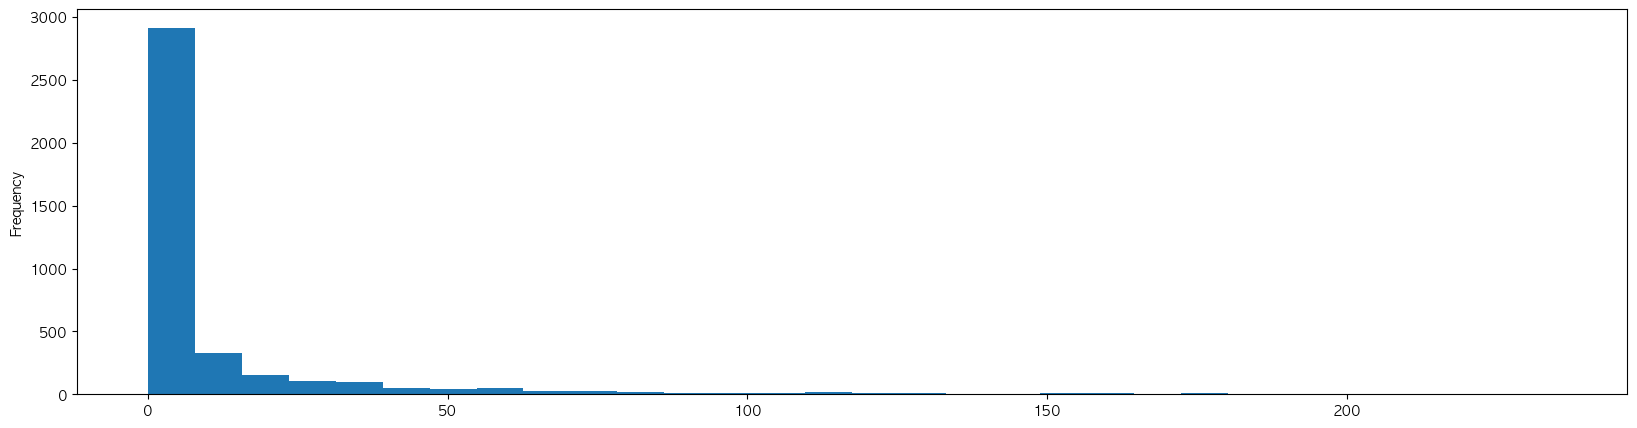

In [ ]:
# 전체 데이터 히스토그램 확인
plt.figure(figsize=(20, 5))
merge_signup_first_subs['diff_signup_first_subs'].plot(kind='hist', bins=30)
plt.show()

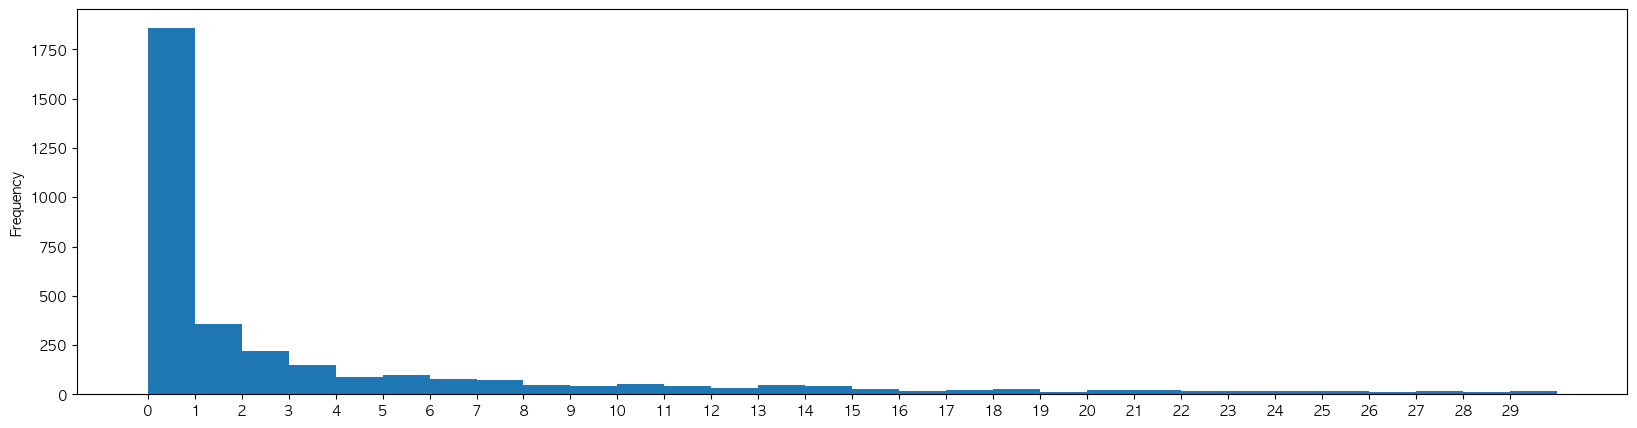

In [ ]:
# 30일 이하 데이터만 확인
plt.figure(figsize=(20, 5))
mask = merge_signup_first_subs['diff_signup_first_subs'] <= 30
merge_signup_first_subs[mask]['diff_signup_first_subs'].plot(kind='hist', bins=30)

plt.xticks(np.arange(0, 30, 1))
plt.show()

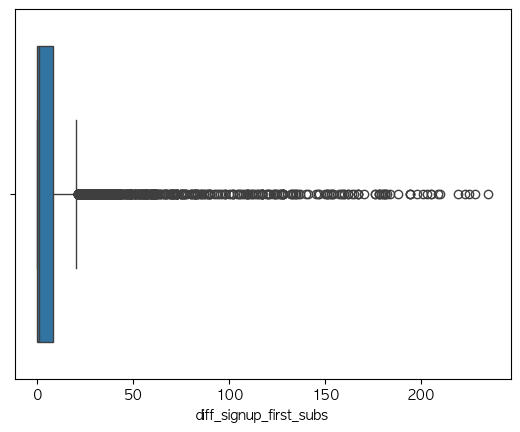

In [ ]:
# 전체 데이터 박스 플롯 확인
sns.boxplot(x=merge_signup_first_subs['diff_signup_first_subs'])
plt.show()

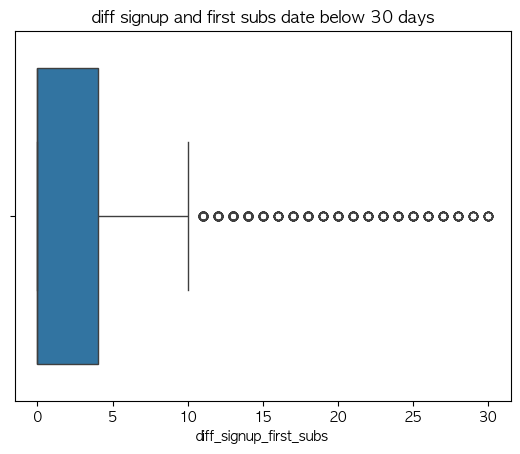

In [ ]:
# 30일 이하 데이터만 확인
mask = merge_signup_first_subs['diff_signup_first_subs'] <= 30
sns.boxplot(x=merge_signup_first_subs[mask]['diff_signup_first_subs'])

plt.title('diff signup and first subs date below 30 days')
plt.show()

### 지표별 확인

In [ ]:
# city
compare_by_columns(merge_enter_complete_payment, 'city', 'enter.payment_page', 'complete.subscription')

event_type,enter.payment_page,complete.subscription,conversion_rate(%)
city,,,
Seoul,4288,647,15.088619
Gangnam-gu,1119,160,14.298481
Seongnam-si,784,120,15.306122
Suwon,714,104,14.565826
Yongin-si,587,99,16.865417
Seo-gu,507,54,10.650888
Goyang-si,492,86,17.479675
Seocho-gu,459,85,18.518519
Gwanak-gu,400,60,15.000000


In [ ]:
# country
compare_by_columns(merge_enter_complete_payment, 'country', 'enter.payment_page', 'complete.subscription')

event_type,enter.payment_page,complete.subscription,conversion_rate(%)
country,,,
South Korea,25152,3625,14.412373
United States,93,13,13.978495
Japan,45,8,17.777778
Canada,36,4,11.111111
Germany,17,1,5.882353
Australia,17,5,29.411765
United Kingdom,14,4,28.571429
Vietnam,12,2,16.666667
Singapore,11,1,9.090909


In [ ]:
# device family
compare_by_columns(merge_enter_complete_payment, 'device_family', 'enter.payment_page', 'complete.subscription')

event_type,enter.payment_page,complete.subscription,conversion_rate(%)
device_family,,,
Windows,13952,2103,15.073108
Apple iPhone,3605,581,16.116505
Mac,2742,516,18.818381
Samsung Phone,2709,281,10.372831
K,1417,88,6.210303
Samsung Galaxy Phone,232,20,8.620690
Samsung Galaxy Note,232,25,10.775862
Apple iPad,228,27,11.842105
Linux,149,14,9.395973


In [ ]:
# device type
compare_by_columns(merge_enter_complete_payment, 'device_type', 'enter.payment_page', 'complete.subscription')

event_type,enter.payment_page,complete.subscription,conversion_rate(%)
device_type,,,
Windows,14023,2103,14.996791
Mac,2748,516,18.777293
Apple iPhone,2155,481,22.320186
Samsung Galaxy S21 5G,230,26,11.304348
Apple iPad,223,27,12.107623
Apple iPhone 14 Pro,218,11,5.045872
Samsung Galaxy S22 Ultra,212,19,8.962264
Samsung Galaxy Z Flip3 5G,182,23,12.637363
Samsung Galaxy S22,178,20,11.235955


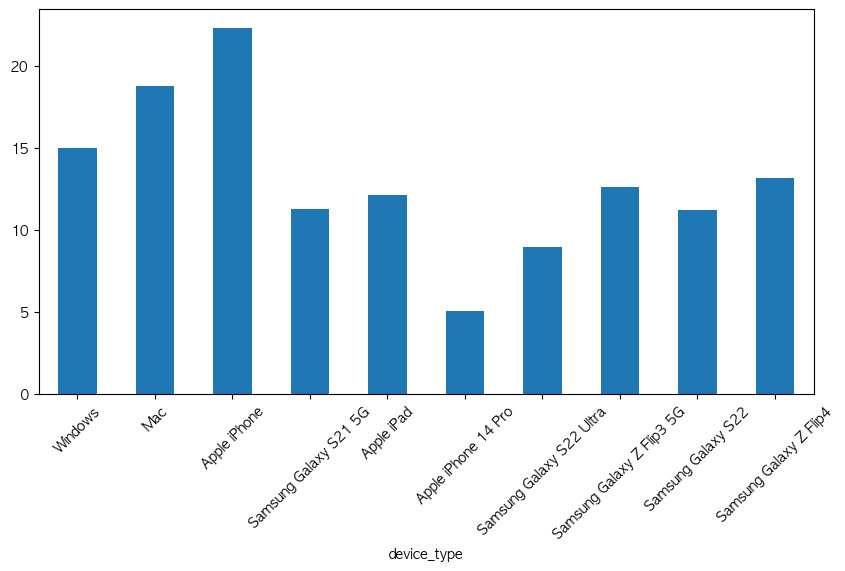

In [ ]:
# device type top 10 시각화
data = compare_by_columns(merge_enter_complete_payment, 'device_type', 'enter.payment_page', 'complete.subscription')

plt.figure(figsize=(10,5))
data[:10]['conversion_rate(%)'].plot(kind='bar')

plt.xticks(rotation=45)
plt.show()

- Mac, Apple iPhone의 전환율이 높은 편

In [ ]:
# language
compare_by_columns(merge_enter_complete_payment, 'language', 'enter.payment_page', 'complete.subscription')

event_type,enter.payment_page,complete.subscription,conversion_rate(%)
language,,,
Korean,24556,3526,14.359016
English,870,144,16.551724
Japanese,23,3,13.043478
Chinese,16,0,0.000000
Russian,14,1,7.142857
Vietnamese,13,0,0.000000
Uzbek,5,0,0.000000
Spanish,4,0,0.000000
French,3,1,33.333333


In [ ]:
# os name
compare_by_columns(merge_enter_complete_payment, 'os_name', 'enter.payment_page', 'complete.subscription')

event_type,enter.payment_page,complete.subscription,conversion_rate(%)
os_name,,,
Chrome,14361,2045,14.239955
Edge,2491,390,15.656363
Instagram,2268,142,6.261023
Mobile Safari,1437,296,20.598469
Whale,1283,220,17.147311
Samsung Browser,1119,94,8.400357
Safari,838,151,18.019093
Chrome WebView,827,139,16.807739
WebKit,498,174,34.939759


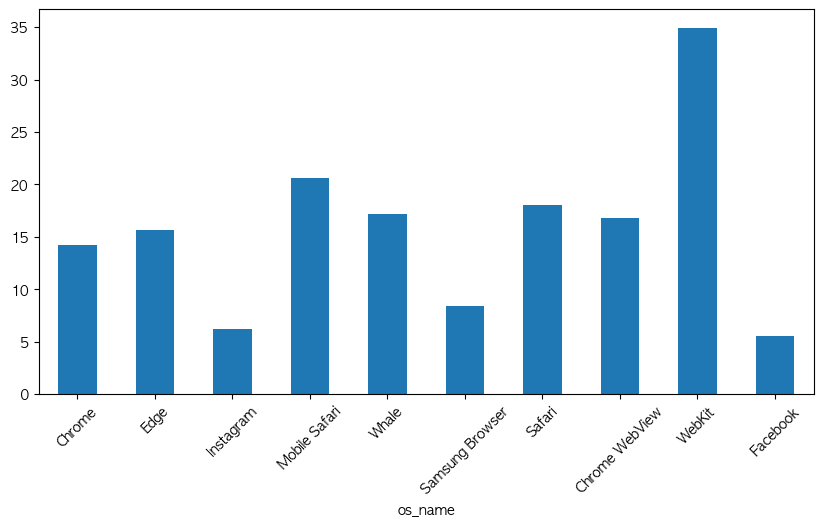

In [ ]:
# os name 시각화
data = compare_by_columns(merge_enter_complete_payment, 'os_name', 'enter.payment_page', 'complete.subscription')

plt.figure(figsize=(10,5))
data[:10]['conversion_rate(%)'].plot(kind='bar')

plt.xticks(rotation=45)
plt.show()

- Instagram 6.26%, Samsung Browser 8.4%, Facebook 5.55%
- WebKit 34.93%
- 아이폰, 아이패드, 맥에서 무언가 앱 내에서 링크를 클릭해서 우리 사이트로 유입되었을 걸로 추정

In [ ]:
# os version
compare_by_columns(merge_enter_complete_payment, 'os_version', 'enter.payment_page', 'complete.subscription')

event_type,enter.payment_page,complete.subscription,conversion_rate(%)
os_version,,,
119.0.0.0,2965,342,11.534570
114.0.0.0,2749,487,17.715533
116.0.0.0,2685,309,11.508380
117.0.0.0,1544,132,8.549223
118.0.0.0,1521,144,9.467456
115.0.0.0,1397,229,16.392269
113.0.0.0,1034,111,10.735010
16.6,633,93,14.691943
22.0,557,32,5.745063


- 605.1.15: 34% 유독 높은 전환율

In [ ]:
# 605.1.15 버전의 device, os 정보 확인
search_os_version = merge_enter_complete_payment[merge_enter_complete_payment['os_version'] == '605.1.15']
search_os_version.head(1)

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,is_new_member
user_id,,,,,,,,,,,,
00b447a427830f997b10d54428702dc8,Gwangju,2023-07-26 19:08:52+09:00,South Korea,NaN,Apple iPhone,Apple iPhone,enter.payment_page,Korean,WebKit,605.1.15,Web,True


In [ ]:
search_os_version[['device_family','os_name']].value_counts()

device_family  os_name
Apple iPhone   WebKit     639
Apple iPad     WebKit      33
Name: count, dtype: int64

- iPhone, iPad 사용자의 높은 전환율 확인 가능
- 위의 os_name에서 Webkit과 동일한 숫자와 전환율을 보임

## 결론
- 회원가입 당일 첫 구독: 47.24%
- 회원가입 후 7일 이내 첫 구독: 72.23%
- 그 외의 일수는 최대 235일까지 길어지고 분포도 적은 상태이므로, 이 회원들은 구독의 의지가 없는 휴면 회원으로 볼 수 있음.
- 따라서 현재 정해진 데이터 기간대로 그대로 진행해도 결과의 방향성이 크게 달라지진 않을 것으로 보임

## 2-2. Funnel Part 2

# Preparation Phase

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import datetime

In [ ]:
# 1구간
enter_main = normalize_loaded_dataframe(pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_enter_main_page_funnel2.csv'), sep=None, engine='python'))
enter_signup = normalize_loaded_dataframe(pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_enter_signup_page_funnel2.csv'), sep=None, engine='python'))
complete_signup = normalize_loaded_dataframe(pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_complete_signup_funnel2.csv'), sep=None, engine='python'))
enter_payment = normalize_loaded_dataframe(pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_enter_payment_page_funnel2.csv'), sep=None, engine='python'))

# 2구간
complete_first_subs = normalize_loaded_dataframe(pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_complete_subscription_funnel2.csv'), sep=None, engine='python'))
renew_subs = normalize_loaded_dataframe(pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_renew_subscription_funnel2.csv'), sep=None, engine='python'))
resubscribe_subs = normalize_loaded_dataframe(pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_resubscribe_subscription_funnel2.csv'), sep=None, engine='python'))
click_cancel = normalize_loaded_dataframe(pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_click_cancel_plan_button_funnel2.csv'), sep=None, engine='python'))

###### 한글

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = KOREAN_FONT
plt.rcParams['axes.unicode_minus'] = False


# Funnel
- 1구간: 메인페이지 -> 회원가입 페이지 -> 회원가입 완료 -> 결제 페이지
- 2-1구간: 첫 구독 완료
- 2-2구간: 첫 구독 완료 -> 자동 갱신
- 2-3구간: 첫 구독 완료 -> 만료 후 재구독

## 1구간

### EDA 및 전처리

In [ ]:
enter_main = pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_enter_main_page_funnel2.csv'), sep = None, engine = 'python')
enter_signup = pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_enter_signup_page_funnel2.csv'), sep = None, engine = 'python')
complete_signup = pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_complete_signup_funnel2.csv'), sep = None, engine = 'python')
enter_payment = pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_enter_payment_page_funnel2.csv'), sep = None, engine = 'python')

In [ ]:
display(enter_main.shape)
display(enter_main.columns)
display(enter_signup.shape)
display(enter_signup.columns)
display(complete_signup.shape)
display(complete_signup.columns)
display(enter_payment.shape)
display(enter_payment.columns)

(2133548, 12)

Index(['city', 'client_event_time', 'country', 'device_carrier',
       'device_family', 'device_type', 'event_type', 'language', 'os_name',
       'os_version', 'platform', 'user_id'],
      dtype='object')

(596829, 12)

Index(['city', 'client_event_time', 'country', 'device_carrier',
       'device_family', 'device_type', 'event_type', 'language', 'os_name',
       'os_version', 'platform', 'user_id'],
      dtype='object')

(145133, 13)

Index(['city', 'client_event_time', 'country', 'device_carrier',
       'device_family', 'device_type', 'event_type', 'language', 'os_name',
       'os_version', 'platform', 'user_id', 'type'],
      dtype='object')

(165061, 12)

Index(['city', 'client_event_time', 'country', 'device_carrier',
       'device_family', 'device_type', 'event_type', 'language', 'os_name',
       'os_version', 'platform', 'user_id'],
      dtype='object')

In [ ]:
# 데이터 타입 변경 및 UTC -> KST 변환
dfs = {
    'enter_main': enter_main,
    'enter_signup': enter_signup,
    'complete_signup': complete_signup,
    'enter_payment': enter_payment
}

for name, df in dfs.items():
    df['client_event_time'] = (
        pd.to_datetime(df['client_event_time'], utc=True)
        .dt.tz_convert('Asia/Seoul')
        .dt.tz_localize(None)
    )


# 공통 데이터 기간
start_date = '2023-05-01'
end_date = '2024-01-01'

# 데이터 기간 필터링
enter_main = enter_main[(enter_main['client_event_time'] >= start_date) & (enter_main['client_event_time'] < end_date)]
enter_signup = enter_signup[(enter_signup['client_event_time'] >= start_date) & (enter_signup['client_event_time'] < end_date)]
complete_signup = complete_signup[(complete_signup['client_event_time'] >= start_date) & (complete_signup['client_event_time'] < end_date)]
enter_payment = enter_payment[(enter_payment['client_event_time'] >= start_date) & (enter_payment['client_event_time'] < end_date)]



print(f"메인페이지 진입 로그: {len(enter_main)}건")
print(f"회원가입 페이지 진입 로그: {len(enter_signup)}건")
print(f"회원가입 완료 로그: {len(complete_signup)}건")
print(f"결제 페이지 진입 로그: {len(enter_payment)}건")

메인페이지 진입 로그: 602958건
회원가입 페이지 진입 로그: 263638건
회원가입 완료 로그: 55982건
결제 페이지 진입 로그: 93570건


In [ ]:
display(enter_main['client_event_time'].min())
display(enter_main['client_event_time'].max())
display(enter_signup['client_event_time'].min())
display(enter_signup['client_event_time'].max())
display(complete_signup['client_event_time'].min())
display(complete_signup['client_event_time'].max())
display(enter_payment['client_event_time'].min())
display(enter_payment['client_event_time'].max())

Timestamp('2023-05-01 00:00:10')

Timestamp('2023-12-15 11:46:11')

Timestamp('2023-05-01 00:00:40')

Timestamp('2023-12-31 23:59:29')

Timestamp('2023-05-01 00:03:00')

Timestamp('2023-12-31 23:41:02')

Timestamp('2023-05-01 00:03:08')

Timestamp('2023-12-10 23:56:01')

In [ ]:
print(enter_main.isnull().sum())
print(enter_main.duplicated().sum())

print('-------------------')

print(enter_signup.isnull().sum())
print(enter_signup.duplicated().sum())

print('-------------------')

print(complete_signup.isnull().sum())
print(complete_signup.duplicated().sum())

print('-------------------')

print(enter_payment.isnull().sum())
print(enter_payment.duplicated().sum())

city                  15486
client_event_time         0
country                 380
device_carrier       602958
device_family           827
device_type           46429
event_type                0
language                  0
os_name                 648
os_version             2803
platform                  0
user_id              573688
dtype: int64
784
-------------------
city                   7253
client_event_time         0
country                 186
device_carrier       263638
device_family             9
device_type           25973
event_type                0
language                  0
os_name                   8
os_version              759
platform                  0
user_id              263638
dtype: int64
76
-------------------
city                 44980
client_event_time        0
country              44751
device_carrier       55982
device_family        44747
device_type          45667
event_type               0
language             44747
os_name              44747
os_version  

In [ ]:
enter_main = enter_main.drop_duplicates(keep = 'first')
enter_main = enter_main[enter_main['user_id'].isna()]
display(enter_main.shape)
enter_signup = enter_signup.drop_duplicates(keep = 'first')
enter_signup = enter_signup[enter_signup['user_id'].isna()]
display(enter_signup.shape)
complete_signup = complete_signup.drop_duplicates()
display(complete_signup.shape)
enter_payment = enter_payment.drop_duplicates()
display(enter_payment.shape)

(572920, 12)

(263562, 12)

(55982, 13)

(73055, 12)

In [ ]:
print(enter_main.isnull().sum())
print(enter_main.duplicated().sum())

print('-------------------')

print(enter_signup.isnull().sum())
print(enter_signup.duplicated().sum())

print('-------------------')

print(complete_signup.isnull().sum())
print(complete_signup.duplicated().sum())

print('-------------------')

print(enter_payment.isnull().sum())
print(enter_payment.duplicated().sum())

city                  15237
client_event_time         0
country                 366
device_carrier       572920
device_family           806
device_type           45881
event_type                0
language                  0
os_name                 648
os_version             2795
platform                  0
user_id              572920
dtype: int64
0
-------------------
city                   7252
client_event_time         0
country                 186
device_carrier       263562
device_family             9
device_type           25965
event_type                0
language                  0
os_name                   8
os_version              759
platform                  0
user_id              263562
dtype: int64
0
-------------------
city                 44980
client_event_time        0
country              44751
device_carrier       55982
device_family        44747
device_type          45667
event_type               0
language             44747
os_name              44747
os_version     

In [ ]:
# 필요 컬럼 추출
enter_main = enter_main[['user_id', 'client_event_time', 'event_type']].copy()
enter_signup = enter_signup[['user_id', 'client_event_time', 'event_type']].copy()
complete_signup = complete_signup[['user_id', 'client_event_time', 'event_type']].copy()
enter_payment = enter_payment[['user_id', 'client_event_time', 'event_type']].copy()

In [ ]:
# 이벤트 수(로그 수) 확인
print(f"메인페이지 진입 로그 수: {len(enter_main)}건")
print(f"회원가입 페이지 진입 로그 수: {len(enter_signup)}건")
print(f"회원가입 완료 로그 수: {len(complete_signup)}건")
print(f"결제 페이지 진입 로그 수: {len(enter_payment)}건")

print(enter_main.shape)
print(enter_signup.shape)
print(complete_signup.shape)
print(enter_payment.shape)

메인페이지 진입 로그 수: 572920건
회원가입 페이지 진입 로그 수: 263562건
회원가입 완료 로그 수: 55982건
결제 페이지 진입 로그 수: 73055건
(572920, 3)
(263562, 3)
(55982, 3)
(73055, 3)


### 1구간 퍼널 시각화

- enter_main -> enter_signup -> complete_signup: 로그 수 기준 (user_id 없음)
- complete_signup -> enter_payment: user_id 기준

In [ ]:
u1    = set(complete_signup['user_id'])
u_pay = set(enter_payment['user_id']) & u1

funnel = {
    'enter_main':      len(enter_main),
    'enter_signup':    len(enter_signup),
    'complete_signup': len(u1),
    'enter_payment':   len(u_pay),
}

for i, (k, v) in enumerate(funnel.items()):
    vals = list(funnel.values())
    rate = v / vals[i-1] * 100 if i > 0 else 100
    print(f"{k}: {v:,} ({rate:.1f}%)")

enter_main: 572,920 (100.0%)
enter_signup: 263,562 (46.0%)
complete_signup: 55,982 (21.2%)
enter_payment: 25,514 (45.6%)


In [ ]:
import plotly.express as px

df_seg1 = pd.DataFrame({
    'number': list(funnel.values()),
    'stage':  list(funnel.keys())
})

fig = px.funnel(df_seg1, x='number', y='stage', title='메인 진입 ~ 결제 페이지 퍼널')
fig.update_traces(textposition='inside', textinfo='value+percent previous')
fig.update_layout(margin=dict(l=150, r=50))
fig.show()

## 2구간

### EDA 및 전처리

In [ ]:
complete_first_subs = pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_complete_subscription_funnel2.csv'),sep=None, engine='python')
renew_subs = pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_renew_subscription_funnel2.csv'), sep=None, engine='python')
resubscribe_subs = pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_resubscribe_subscription_funnel2.csv'), sep=None, engine='python')
click_cancel = pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_click_cancel_plan_button_funnel2.csv'), sep = None, engine = 'python')

In [ ]:
display(complete_first_subs.shape)
display(complete_first_subs.columns)
display(renew_subs.shape)
display(renew_subs.columns)
display(resubscribe_subs.shape)
display(resubscribe_subs.columns)
display(click_cancel.columns)

(14289, 16)

Index(['city', 'client_event_time', 'country', 'device_carrier',
       'device_family', 'device_type', 'event_type', 'language', 'os_name',
       'os_version', 'platform', 'user_id', 'plan.price', 'paid_amount',
       'coupon.discount_amount', 'pg.type'],
      dtype='object')

(15945, 16)

Index(['city', 'client_event_time', 'country', 'device_carrier',
       'device_family', 'device_type', 'event_type', 'language', 'os_name',
       'os_version', 'platform', 'user_id', 'plan.price', 'paid_amount',
       'coupon.discount_amount', 'pg.type'],
      dtype='object')

(791, 16)

Index(['city', 'client_event_time', 'country', 'device_carrier',
       'device_family', 'device_type', 'event_type', 'language', 'os_name',
       'os_version', 'platform', 'user_id', 'plan.price', 'paid_amount',
       'coupon.discount_amount', 'pg.type'],
      dtype='object')

Index(['city', 'client_event_time', 'country', 'device_carrier',
       'device_family', 'device_type', 'event_type', 'language', 'os_name',
       'os_version', 'platform', 'user_id'],
      dtype='object')

In [ ]:
# UTC to KST
dfs = {
    'complete_first_subs' : complete_first_subs,
    'renew_subs' : renew_subs,
    'resubscribe_subs' : resubscribe_subs,
    'click_cancel' : click_cancel
}

for name, df in dfs.items():
    df['client_event_time'] = (pd.to_datetime(df['client_event_time'], utc = True)
                              .dt.tz_convert('Asia/Seoul')
                              .dt.tz_localize(None))

start_date = '2023-05-01'
end_date = '2024-01-01'

complete_first_subs = complete_first_subs[(complete_first_subs['client_event_time'] >= start_date) & (complete_first_subs['client_event_time'] < end_date)]
renew_subs = renew_subs[(renew_subs['client_event_time'] >= start_date) & (renew_subs['client_event_time'] < end_date)]
resubscribe_subs = resubscribe_subs[(resubscribe_subs['client_event_time'] >= start_date) & (resubscribe_subs['client_event_time'] < end_date)]
click_cancel = click_cancel[(click_cancel['client_event_time'] >= start_date) & (click_cancel['client_event_time'] < end_date)]

In [ ]:
display(complete_first_subs['client_event_time'].min())
display(complete_first_subs['client_event_time'].max())
display(renew_subs['client_event_time'].min())
display(renew_subs['client_event_time'].max())
display(resubscribe_subs['client_event_time'].min())
display(resubscribe_subs['client_event_time'].max())
display(click_cancel['client_event_time'].min())
display(click_cancel['client_event_time'].max())

Timestamp('2023-05-01 00:03:59')

Timestamp('2023-12-31 23:59:39')

Timestamp('2023-05-01 00:00:24')

Timestamp('2023-12-31 23:50:02')

Timestamp('2023-05-01 13:57:30')

Timestamp('2023-12-31 23:57:02')

Timestamp('2023-05-01 00:02:11')

Timestamp('2023-12-31 23:58:19')

In [ ]:
complete_first_subs = complete_first_subs.drop_duplicates().copy()
renew_subs = renew_subs.drop_duplicates().copy()
resubscribe_subs = resubscribe_subs.drop_duplicates().copy()
click_cancel = click_cancel.drop_duplicates().copy()

print(complete_first_subs.isnull().sum())
print(complete_first_subs.duplicated().sum())

print('-------------------')

print(renew_subs.isnull().sum())
print(renew_subs.duplicated().sum())

print('-------------------')

print(resubscribe_subs.isnull().sum())
print(resubscribe_subs.duplicated().sum())

print('-------------------')

print(click_cancel.isnull().sum())
print(click_cancel.duplicated().sum())

city                       278
client_event_time            0
country                    229
device_carrier            4943
device_family              229
device_type                355
event_type                   0
language                   229
os_name                    229
os_version                 233
platform                   229
user_id                      0
plan.price                   0
paid_amount                  0
coupon.discount_amount       0
pg.type                   3307
dtype: int64
0
-------------------
city                       114
client_event_time            0
country                     76
device_carrier            8401
device_family               76
device_type                241
event_type                   0
language                    76
os_name                     76
os_version                  84
platform                    76
user_id                      0
plan.price                   0
paid_amount                  0
coupon.discount_amount       0
pg.t

In [ ]:
click_cancel = click_cancel.dropna().copy()
print(click_cancel.isnull().sum())

city                 0
client_event_time    0
country              0
device_carrier       0
device_family        0
device_type          0
event_type           0
language             0
os_name              0
os_version           0
platform             0
user_id              0
dtype: int64


In [ ]:
# 필요 컬럼 추출
complete_first_subs = complete_first_subs[['user_id', 'client_event_time', 'event_type', 'plan.price', 'paid_amount', 'coupon.discount_amount']].copy()
renew_subs = renew_subs[['user_id', 'client_event_time', 'event_type', 'plan.price', 'paid_amount', 'coupon.discount_amount']].copy()
resubscribe_subs = resubscribe_subs[['user_id', 'client_event_time', 'event_type', 'plan.price', 'paid_amount', 'coupon.discount_amount']].copy()
click_cancel = click_cancel[['user_id', 'client_event_time', 'event_type']].copy()

In [ ]:
print(complete_first_subs.shape)
print(renew_subs.shape)
print(resubscribe_subs.shape)
print(click_cancel.shape)

(4943, 6)
(8401, 6)
(574, 6)
(0, 3)


In [ ]:
u1 = set(complete_signup['user_id'])
u_pay = set(enter_payment['user_id']) & u1
u2 = set(complete_first_subs['user_id']) & u_pay

funnel = {
    'enter_main':      len(enter_main),
    'enter_signup':    len(enter_signup),
    'complete_signup': len(u1),
    'enter_payment':   len(u_pay),
    'complete_first_subs': len(u2),
}

df_funnel = pd.DataFrame({
    'event_type':  list(funnel.keys()),
    'event_count': list(funnel.values())
})

df_funnel['conversion_rate(%)'] = (
    df_funnel['event_count'] / df_funnel['event_count'].shift(1) * 100
)
df_funnel['bounce_rate(%)']     = 100 - df_funnel['conversion_rate(%)']
df_funnel['conversion_rate_total'] = (
    df_funnel['event_count'] / df_funnel['event_count'].iloc[0]
)

display(df_funnel)

,event_type,event_count,conversion_rate(%),bounce_rate(%),conversion_rate_total
0,enter_main,572920,NaN,NaN,1.000000
1,enter_signup,263562,46.003281,53.996719,0.460033
2,complete_signup,55982,21.240543,78.759457,0.097713
3,enter_payment,25514,45.575364,54.424636,0.044533
4,complete_first_subs,2844,11.146821,88.853179,0.004964


### 2구간 퍼널 시각화 (퍼널 전체 시각화)
- case1. 첫구독
- case2. 첫구독 → 갱신
- case3. 첫구독 → 재구독

In [ ]:
for name, df in {
    'complete_first_subs': complete_first_subs,
    'renew_subs':          renew_subs,
    'resubscribe_subs':    resubscribe_subs,
    'click_cancel':        click_cancel
}.items():
    print(f"[{name}]")
    print(df.shape)
    print(df.isnull().sum())
    print(df.duplicated().sum())
    print()

[complete_first_subs]
(4943, 6)
user_id                   0
client_event_time         0
event_type                0
plan.price                0
paid_amount               0
coupon.discount_amount    0
dtype: int64
0

[renew_subs]
(8401, 6)
user_id                   0
client_event_time         0
event_type                0
plan.price                0
paid_amount               0
coupon.discount_amount    0
dtype: int64
0

[resubscribe_subs]
(574, 6)
user_id                   0
client_event_time         0
event_type                0
plan.price                0
paid_amount               0
coupon.discount_amount    0
dtype: int64
0

[click_cancel]
(0, 3)
user_id              0
client_event_time    0
event_type           0
dtype: int64
0



In [ ]:
u1    = set(complete_signup['user_id'])
u_pay = set(enter_payment['user_id']) & u1
u2    = set(complete_first_subs['user_id']) & u_pay
u3    = set(renew_subs['user_id']) & u2
u4    = set(resubscribe_subs['user_id']) & u2
u5    = set(click_cancel['user_id']) & u2

# 2-1) 첫 구독 후 이탈
funnel_2_1 = {
    'enter_main':          len(enter_main),
    'enter_signup':        len(enter_signup),
    'complete_signup':     len(u1),
    'enter_payment':       len(u_pay),
    'complete_first_subs': len(u2),
    'click_cancel':        len(u5)
}


# 2-2) 재구독
funnel_2_2 = {
    'enter_main':          len(enter_main),
    'enter_signup':        len(enter_signup),
    'complete_signup':     len(u1),
    'enter_payment':       len(u_pay),
    'complete_first_subs': len(u2),
    'renew_subs':          len(u3),
}

# 2-3) 만료 후 재구독
funnel_2_3 = {
    'enter_main':          len(enter_main),
    'enter_signup':        len(enter_signup),
    'complete_signup':     len(u1),
    'enter_payment':       len(u_pay),
    'complete_first_subs': len(u2),
    'resubscribe_subs':    len(u4),
}

for name, funnel in [('2-1 첫 구독 후 이탈', funnel_2_1),('2-2 재구독', funnel_2_2), ('2-3 만료 후 재구독', funnel_2_3)]:
    print(f"\n[{name}]")
    vals = list(funnel.values())
    for i, (k, v) in enumerate(funnel.items()):
        rate = v / vals[i-1] * 100 if i > 0 else 100
        print(f"{k}: {v:,} ({rate:.1f}%)")


[2-1 첫 구독 후 이탈]
enter_main: 572,920 (100.0%)
enter_signup: 263,562 (46.0%)
complete_signup: 55,982 (21.2%)
enter_payment: 25,514 (45.6%)
complete_first_subs: 2,844 (11.1%)
click_cancel: 0 (0.0%)

[2-2 재구독]
enter_main: 572,920 (100.0%)
enter_signup: 263,562 (46.0%)
complete_signup: 55,982 (21.2%)
enter_payment: 25,514 (45.6%)
complete_first_subs: 2,844 (11.1%)
renew_subs: 1,533 (53.9%)

[2-3 만료 후 재구독]
enter_main: 572,920 (100.0%)
enter_signup: 263,562 (46.0%)
complete_signup: 55,982 (21.2%)
enter_payment: 25,514 (45.6%)
complete_first_subs: 2,844 (11.1%)
resubscribe_subs: 48 (1.7%)


In [ ]:
import plotly.express as px

funnels = {
    '2-1 첫 구독 후 이탈':     funnel_2_1,
    '2-2 갱신':             funnel_2_2,
    '2-3 만료 후 재구독':      funnel_2_3,
}

for title, funnel in funnels.items():
    df = pd.DataFrame({
        'number': list(funnel.values()),
        'stage':  list(funnel.keys())
    })
    fig = px.funnel(df, x='number', y='stage', title=title)
    fig.update_traces(
        textposition='inside',
        textinfo='value+percent previous',
        constraintext='none', textfont=dict(color='black')
    )
    fig.update_layout(
        width=1400,
        height=500,
        margin=dict(l=150, r=500, t=50, b=50)
    )
    fig.show()

# 매출
첫 구독 후 방향성 별 매출에 어떤 영향을 미치는가?
- 정상가 합계 (plan.price)
- 실결제액 합계 (paid_amount)
- 할인액 합계 (coupon.discount_amount)

### EDA 및 전처리

In [ ]:
end_content = pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_end_content_funnel2.csv'), sep = None, engine = 'python')
complete_lesson = pd.read_csv(os.path.join(PATH_FUNNEL2, 'raw_complete_lesson_funnel2.csv'), sep = None, engine = 'python')

In [ ]:
display(end_content.shape)
display(end_content.columns)
display(complete_lesson.shape)
display(complete_lesson.columns)

(120582, 13)

Index(['city', 'client_event_time', 'country', 'device_carrier',
       'device_family', 'device_type', 'event_type', 'language', 'os_name',
       'os_version', 'platform', 'user_id', 'content.id'],
      dtype='object')

(2035937, 5)

Index(['﻿user_id', 'content.id', 'event_type', 'lesson.id',
       'client_event_time'],
      dtype='object')

In [ ]:
# 필요 컬럼 추출
end_content = select_columns(
    end_content,
    ['user_id', 'client_event_time', 'content.id'],
    df_name='end_content'
)
complete_lesson = select_columns(
    complete_lesson,
    ['user_id', 'client_event_time', 'content.id', 'lesson.id'],
    df_name='complete_lesson'
)

# UTC to KST
dfs = {
    'end_content': end_content,
    'complete_lesson': complete_lesson
}

for name, df in dfs.items():
    df['client_event_time'] = (
        pd.to_datetime(df['client_event_time'], utc=True)
        .dt.tz_convert('Asia/Seoul')
        .dt.tz_localize(None)
    )

start_date = '2023-05-01'
end_date = '2024-01-01'

end_content = end_content[
    (end_content['client_event_time'] >= start_date) & (end_content['client_event_time'] < end_date)
]
complete_lesson = complete_lesson[
    (complete_lesson['client_event_time'] >= start_date) & (complete_lesson['client_event_time'] < end_date)
]

# 중복 제거
end_content = end_content.drop_duplicates().copy()
complete_lesson = complete_lesson.drop_duplicates().copy()

print(end_content.shape)
print(complete_lesson.shape)

(46359, 3)
(2030058, 4)


In [ ]:
for name, df in {'end_content': end_content, 'complete_lesson': complete_lesson}.items():
    print(f"[{name}]")
    print(df.shape)
    print(df.isnull().sum())
    print(df.duplicated().sum())
    print()

[end_content]
(46359, 3)
user_id              0
client_event_time    0
content.id           0
dtype: int64
0

[complete_lesson]
(2030058, 4)
user_id              0
client_event_time    0
content.id           0
lesson.id            0
dtype: int64
0



### 상관계수 (안씀)
- end_content/complete_lesson과 첫구독 후 갱신, 이탈, 재구독
- 이탈 제외하고 무의미함

In [ ]:
# 그룹 user_id 정의
first_users  = set(complete_first_subs['user_id'])
renew_users  = set(renew_subs['user_id']) & first_users
resub_users  = set(resubscribe_subs['user_id']) & first_users
cancel_users = set(click_cancel['user_id']) & first_users

def get_usage(user_set, label):
    ec = end_content[end_content['user_id'].isin(user_set)]
    cl = complete_lesson[complete_lesson['user_id'].isin(user_set)]

    user_count = len(user_set)

    return {
        'group': label,
        'user_count': user_count,
        'content_count': len(ec),
        'lesson_count': len(cl),
        'avg_content_per_user': len(ec) / user_count if user_count > 0 else 0,
        'avg_lesson_per_user': len(cl) / user_count if user_count > 0 else 0,
    }

df_usage = pd.DataFrame([
    get_usage(first_users, 'complete_first_subs'),
    get_usage(renew_users, 'renew_subs'),
    get_usage(resub_users, 'resubscribe_subs'),
    get_usage(cancel_users, 'click_cancel'),
])

display(df_usage)

,group,user_count,content_count,lesson_count,avg_content_per_user,avg_lesson_per_user
0,complete_first_subs,4870,14411,627898,2.959138,128.931828
1,renew_subs,2266,8563,384006,3.778906,169.464254
2,resubscribe_subs,79,340,16579,4.303797,209.860759
3,click_cancel,0,0,0,0.000000,0.000000


그룹 간 평균 content, lesson 이용량 차이

- 콘텐츠/레슨 이용량이 많을수록 갱신/재구독 경향이 높음

- resubscribe_subs가 가장 높은 이용량 → 한번 이탈해도 적극 이용자가 돌아옴

- click_cancel 이용량이 complete_first_subs보다 높음 → 이탈 유저도 어느정도 이용은 했음

In [ ]:
# user별 콘텐츠/레슨 이용량 집계
ec_agg = end_content.groupby('user_id').size().reset_index(name='content_count')
cl_agg = complete_lesson.groupby('user_id').size().reset_index(name='lesson_count')

# complete_first_subs에 join
df_user = complete_first_subs[['user_id', 'paid_amount']].copy()
df_user = df_user.merge(ec_agg, on='user_id', how='left')
df_user = df_user.merge(cl_agg, on='user_id', how='left')
df_user = df_user.fillna(0)

# 그룹 레이블 추가
df_user['group'] = 'first_only'
df_user.loc[df_user['user_id'].isin(renew_users),  'group'] = 'renew'
df_user.loc[df_user['user_id'].isin(resub_users),  'group'] = 'resub'
df_user.loc[df_user['user_id'].isin(cancel_users), 'group'] = 'cancel'

display(df_user.head())

,user_id,paid_amount,content_count,lesson_count,group
0,d4f54ecf6c4d7bf8742f80505f02d6dc,15920,0.0,0.0,renew
1,ac7c3298f6afc990333b9dbf937f2378,15920,8.0,582.0,renew
2,eb94155d7d652f3633bbc45980c6db20,15920,2.0,68.0,renew
3,de268c470001d1b0ff39f0c4869c60e0,15920,1.0,273.0,renew
4,ea4ca47baa41447263b90957e0cf39c2,15920,2.0,238.0,resub


In [ ]:
from scipy import stats

for group in ['renew', 'resub']:
    subset = df_user[df_user['group'] == group]
    r, p = stats.pearsonr(subset['lesson_count'], subset['paid_amount'])
    print(f"{group} - 상관계수: {r:.3f}, p-value: {p:.3f}")

renew - 상관계수: -0.017, p-value: 0.436
resub - 상관계수: 0.092, p-value: 0.415


cancel 유저만 p-value 0.05 이하로 통계적으로 유의미함

레슨을 많이 들을수록 오히려 취소 경향 (-0.042)이 있지만 상관계수 자체가 매우 작아서 실질적 의미는 약함

resub는 표본(79명)이 너무 작아 신뢰하기 어려움

paid_amount가 15920으로 전부 동일한 것으로 보여 상관분석 의미가 없을 수 있음

In [ ]:
print(df_user['paid_amount'].value_counts())
print(df_user['paid_amount'].describe())

paid_amount
15920     2841
95520      847
131600     534
13532      270
14328      224
111860     100
118440      97
93520       17
7960         4
14805        2
12736        1
105280       1
9552         1
11940        1
78960        1
119756       1
98700        1
Name: count, dtype: int64
count      4943.000000
mean      46132.827433
std       45151.267002
min        7960.000000
25%       15920.000000
50%       15920.000000
75%       95520.000000
max      131600.000000
Name: paid_amount, dtype: float64


In [ ]:
# 플랜 구분 (15920 = 1개월, 95520/131600 = 장기)
df_user['plan_type'] = df_user['paid_amount'].apply(
    lambda x: '1개월' if x == 15920 else '장기'
)

print(df_user.groupby(['plan_type', 'group']).size().unstack(fill_value=0))

group      first_only  renew  resub
plan_type                          
1개월               891   1876     74
장기               1747    349      6


1개월 플랜 - 취소(1,790)가 갱신(678)의 2.6배. 이탈률 높음

장기 플랜 - first_only(1,399)가 압도적으로 많음. 장기 플랜 유저가 갱신 이벤트 자체가 적은 게 당연함 (분석 기간 내 갱신 시점이 안 왔을 수 있음)

재구독(resub) - 두 플랜 모두 매우 적음

In [ ]:
df_1month = df_user[df_user['plan_type'] == '1개월'].copy()

print(df_1month['group'].value_counts())
print()

total = len(df_1month)
for group, count in df_1month['group'].value_counts().items():
    print(f"{group}: {count:,} ({count/total*100:.1f}%)")

group
renew         1876
first_only     891
resub           74
Name: count, dtype: int64

renew: 1,876 (66.0%)
first_only: 891 (31.4%)
resub: 74 (2.6%)


1개월 플랜 유저 2,841명 중:

- cancel 63% - 1개월 구독 후 이탈이 압도적
- renew 23.9% - 갱신 유저는 4명 중 1명꼴
- first_only 12.7% - 분석 기간 내 아직 갱신 시점 안 온 유저
- resub 0.4% - 재구독은 극히 드묾

In [ ]:
target = df_1month[df_1month['group'].isin(['cancel', 'renew'])]

print(target.groupby('group')[['content_count', 'lesson_count']].mean())

       content_count  lesson_count
group                             
renew       3.809701    169.763859


In [ ]:
from scipy import stats

cancel_lesson = df_1month[df_1month['group'] == 'cancel']['lesson_count']
renew_lesson  = df_1month[df_1month['group'] == 'renew']['lesson_count']

stat, p = stats.mannwhitneyu(cancel_lesson, renew_lesson, alternative='two-sided')
print(f"p-value: {p:.3f}")

p-value: nan


/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/628628417.py:6: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.



- 레슨/콘텐츠 이용량은 갱신/이탈을 결정하는 요인이 아님
- cancel과 renew 유저의 이용 패턴이 거의 동일함

#### 첫구독 후 구독 갱신 여부의 따른 매출의 차이
- 어떤 특성이 다른지를 통해 aha moment 발굴

In [ ]:
print('complete_first_subs')
print(complete_first_subs['client_event_time'].dtype)
print(complete_first_subs['client_event_time'].head())
print('end_content')
print(end_content['client_event_time'].dtype)
print(end_content['client_event_time'].head())
print('complete_lesson')
print(complete_lesson['client_event_time'].dtype)
print(complete_lesson['client_event_time'].head())

complete_first_subs
datetime64[ns]
4    2023-05-31 10:25:56
5    2023-05-31 10:27:06
41   2023-05-11 13:12:50
48   2023-05-05 00:30:02
49   2023-05-05 22:28:35
Name: client_event_time, dtype: datetime64[ns]
end_content
datetime64[ns]
21   2023-05-28 03:03:55
22   2023-05-28 03:21:49
25   2023-05-31 10:46:06
26   2023-05-31 10:03:07
27   2023-05-31 10:07:09
Name: client_event_time, dtype: datetime64[ns]
complete_lesson
datetime64[ns]
0   2023-05-28 12:58:28
1   2023-05-28 12:19:29
2   2023-05-28 12:22:03
3   2023-05-28 12:04:08
4   2023-05-28 12:22:24
Name: client_event_time, dtype: datetime64[ns]


In [ ]:
# 첫 구독 시점 기준으로 이후 행동만 필터링
def get_post_sub_activity(user_sub_df, activity_df):
    merged = activity_df.merge(
        user_sub_df[['user_id', 'client_event_time']].rename(
            columns={'client_event_time': 'sub_time'}),
        on='user_id', how='inner'
    )
    # 구독 이후 행동만
    return merged[merged['client_event_time'] >= merged['sub_time']]

lesson_after  = get_post_sub_activity(complete_first_subs, complete_lesson)
content_after = get_post_sub_activity(complete_first_subs, end_content)

# user별 집계
lesson_agg = lesson_after.groupby('user_id').agg(
    lesson_count=('lesson.id', 'count'),
    content_diversity=('content.id', 'nunique'),
    first_lesson_date=('client_event_time', 'min')
).reset_index()

# 첫 구독 시점과 첫 레슨 시점 차이 (일)
lesson_agg = lesson_agg.merge(
    complete_first_subs[['user_id', 'client_event_time']].rename(
        columns={'client_event_time': 'sub_time'}),
    on='user_id', how='left'
)
lesson_agg['days_to_first_lesson'] = (
    lesson_agg['first_lesson_date'] - lesson_agg['sub_time']
).dt.days

display(lesson_agg.head())

,user_id,lesson_count,content_diversity,first_lesson_date,sub_time,days_to_first_lesson
0,0001f15911b404f3bf5b8571afafa4e4,43,3,2023-11-29 18:55:02,2023-11-29 10:13:52,0
1,0031482d16469048027f6096d13c8b22,240,9,2023-09-11 19:31:51,2023-09-11 08:34:22,0
2,0032f459acd07365803996f97f98d224,73,4,2023-07-16 05:12:35,2023-07-16 01:01:57,0
3,003dc1089ee8075dfe8aab161efc6188,53,6,2023-08-16 04:45:31,2023-08-15 19:07:27,0
4,0052fcc7e62a04f47a1b23c3488d31a0,91,4,2023-05-29 00:46:21,2023-05-24 00:38:01,5


In [ ]:
# group 정보 merge
lesson_agg = lesson_agg.merge(
    df_user[['user_id', 'group']],
    on='user_id', how='left'
)

# renew vs cancel 비교
target = lesson_agg[lesson_agg['group'].isin(['renew', 'cancel'])]

print(target.groupby('group')[['lesson_count', 'content_diversity', 'days_to_first_lesson']].mean())

       lesson_count  content_diversity  days_to_first_lesson
group                                                       
renew    170.369048           6.262363              1.857143


### 유지관점
- 2-1) cancel첫 구독 후 이탈 → 90일 매출 = first만
- 2-2) renew연속 갱신 → 90일 내 갱신 결제 포함
- 2-3) resub이탈 후 복귀 → 90일 내 재구독 결제 포함

### renew와 resub을 교집합함 (안씀)

In [ ]:
# 결제 통합
complete_first_subs['payment_type'] = 'first'
renew_subs['payment_type']          = 'renew'
resubscribe_subs['payment_type']    = 'resub'

all_payments = pd.concat([
    complete_first_subs[['user_id', 'client_event_time', 'paid_amount', 'payment_type']],
    renew_subs[['user_id', 'client_event_time', 'paid_amount', 'payment_type']],
    resubscribe_subs[['user_id', 'client_event_time', 'paid_amount', 'payment_type']]
]).reset_index(drop=True)

print(all_payments.shape)
print(all_payments['payment_type'].value_counts())

(13918, 4)
payment_type
renew    8401
first    4943
resub     574
Name: count, dtype: int64


In [ ]:
# 첫 구독 시점 추출
first_sub_time = complete_first_subs.groupby('user_id')['client_event_time'].min().reset_index()
first_sub_time.columns = ['user_id', 'first_sub_time']

# all_payments에 첫 구독 시점 merge
df_pay = all_payments.merge(first_sub_time, on='user_id', how='left')

# 첫 구독 기준 경과일 계산
df_pay['days_from_sub'] = (df_pay['client_event_time'] - df_pay['first_sub_time']).dt.days

# 90일 이내 필터링
df_pay_90 = df_pay[(df_pay['days_from_sub'] >= 0) & (df_pay['days_from_sub'] <= 90)].copy()

# 유저별 90일 매출 합산
revenue_90 = df_pay_90.groupby('user_id')['paid_amount'].sum().reset_index()
revenue_90.columns = ['user_id', 'revenue_90']

print(revenue_90.shape)
display(revenue_90.head())

(4870, 2)


,user_id,revenue_90
0,0001f15911b404f3bf5b8571afafa4e4,15920
1,0031482d16469048027f6096d13c8b22,47760
2,0032f459acd07365803996f97f98d224,15920
3,003dc1089ee8075dfe8aab161efc6188,47760
4,0052fcc7e62a04f47a1b23c3488d31a0,47760


In [ ]:
group_map = {}
for uid in u2:
    if uid in u3:
        group_map[uid] = 'renew'   # 2-2
    elif uid in u4:
        group_map[uid] = 'resub'   # 2-3
    else:
        group_map[uid] = 'cancel'  # 2-1

revenue_90['group'] = revenue_90['user_id'].map(group_map)

summary = revenue_90.groupby('group').agg(
    user_count=('user_id', 'count'),
    total_revenue=('revenue_90', 'sum'),
    avg_revenue=('revenue_90', 'mean')
).reset_index()

display(summary)

,group,user_count,total_revenue,avg_revenue
0,cancel,1295,90167245,69627.216216
1,renew,1533,63205513,41229.949772
2,resub,16,616364,38522.750000


In [ ]:
# 그룹별 플랜 타입 분포 확인
df_pay_90['group'] = df_pay_90['user_id'].map(group_map)

print(df_pay_90.groupby(['group', 'paid_amount']).size().unstack(fill_value=0))

paid_amount  13532   14328   14805   15920   78960   95520   105280  111860  \
group                                                                         
cancel           62      47       1     559       1     129       1      86   
renew           184     129       0    3178       0      18       2       7   
resub             3       1       0      15       0       2       0       0   

paid_amount  118440  131600  7960    9552    12736   92119   
group                                                        
cancel           72     373       0       0       0       0  
renew             0      23     270       2       7       3  
resub             0       1       0       0       0       0  


In [ ]:
summary = revenue_90.groupby('group').agg(
    user_count=('user_id', 'count'),
    total_revenue=('revenue_90', 'sum'),
).reset_index()

summary['avg_revenue'] = summary['total_revenue'] / summary['user_count']
display(summary)

# 유저별 결제 횟수 확인
df_pay_90['group'] = df_pay_90['user_id'].map(group_map)
print(df_pay_90.groupby('group')['paid_amount'].agg(['count', 'sum', 'mean']))

,group,user_count,total_revenue,avg_revenue
0,cancel,1295,90167245,69627.216216
1,renew,1533,63205513,41229.949772
2,resub,16,616364,38522.750000


        count       sum          mean
group                                
cancel   1331  90167245  67743.985725
renew    3823  63205513  16532.961810
resub      22    616364  28016.545455


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=3,
    subplot_titles=['유저 수', '총 매출', '유저당 평균 매출'])

groups = summary['group'].tolist()
colors = ['#EF553B', '#636EFA', '#00CC96']

fig.add_trace(go.Bar(x=groups, y=summary['user_count'],
    marker_color=colors, text=summary['user_count'],
    textposition='outside'), row=1, col=1)

fig.add_trace(go.Bar(x=groups, y=summary['total_revenue'],
    marker_color=colors, text=summary['total_revenue'].apply(lambda x: f'{x:,.0f}'),
    textposition='outside'), row=1, col=2)

fig.add_trace(go.Bar(x=groups, y=summary['avg_revenue'],
    marker_color=colors, text=summary['avg_revenue'].apply(lambda x: f'{x:,.0f}'),
    textposition='outside'), row=1, col=3)

fig.update_layout(
    title='퍼널 그룹별 90일 매출 분석',
    showlegend=False,
    height=500,
    width=1200,
)
fig.show()

In [ ]:
u1    = set(complete_signup['user_id'])
u_pay = set(enter_payment['user_id']) & u1
u2    = set(complete_first_subs['user_id']) & u_pay
u3    = set(renew_subs['user_id']) & u2
u4    = set(resubscribe_subs['user_id']) & u2  # u3 교집합 제거

print(f"u2 (first): {len(u2)}")
print(f"u3 (renew): {len(u3)}")
print(f"u4 (resub): {len(u4)}")
print(f"u3 ∩ u4:    {len(u3 & u4)}")

u2 (first): 2844
u3 (renew): 1533
u4 (resub): 48
u3 ∩ u4:    32


In [ ]:
group_map = {}
for uid in u2:
    if uid in u3 and uid in u4:
        group_map[uid] = 'renew'   # 2-2에도 2-3에도 속하지만 renew 우선
    elif uid in u3:
        group_map[uid] = 'renew'   # 2-2
    elif uid in u4:
        group_map[uid] = 'resub'   # 2-3
    else:
        group_map[uid] = 'cancel'  # 2-1

In [ ]:
cancel_users = u2 - u3 - u4
renew_users  = u3          # u2 교집합 이미 됨
resub_users  = u4          # u2 교집합 이미 됨

for label, users in [('cancel', cancel_users), ('renew', renew_users), ('resub', resub_users)]:
    rev = revenue_90[revenue_90['user_id'].isin(users)]
    print(f"{label}: {len(rev):,}명 / total {rev['revenue_90'].sum():,.0f} / avg {rev['revenue_90'].mean():,.0f}")

cancel: 1,295명 / total 90,167,245 / avg 69,627
renew: 1,533명 / total 63,205,513 / avg 41,230
resub: 48명 / total 1,657,532 / avg 34,532


In [ ]:
u5 = set(click_cancel['user_id']) & u2  # 퍼널 2-1과 동일

for label, users in [('cancel', u5), ('renew', u3), ('resub', u4)]:
    rev = revenue_90[revenue_90['user_id'].isin(users)]
    print(f"{label}: {len(rev):,}명 / total {rev['revenue_90'].sum():,.0f} / avg {rev['revenue_90'].mean():,.0f}")

cancel: 0명 / total 0 / avg nan
renew: 1,533명 / total 63,205,513 / avg 41,230
resub: 48명 / total 1,657,532 / avg 34,532


In [ ]:
summary = pd.DataFrame({
    'group':         ['cancel', 'renew', 'resub'],
    'user_count':    [1464, 1533, 48],
    'total_revenue': [61286890, 63205513, 1657532],
    'avg_revenue':   [41863, 41230, 34532]
})

fig = make_subplots(rows=1, cols=3,
    subplot_titles=['유저 수', '총 매출', '유저당 평균 매출'])

colors = ['#EF553B', '#636EFA', '#00CC96']

fig.add_trace(go.Bar(x=summary['group'], y=summary['user_count'],
    marker_color=colors, text=summary['user_count'],
    textposition='outside'), row=1, col=1)

fig.add_trace(go.Bar(x=summary['group'], y=summary['total_revenue'],
    marker_color=colors, text=summary['total_revenue'].apply(lambda x: f'{x:,.0f}'),
    textposition='outside'), row=1, col=2)

fig.add_trace(go.Bar(x=summary['group'], y=summary['avg_revenue'],
    marker_color=colors, text=summary['avg_revenue'].apply(lambda x: f'{x:,.0f}'),
    textposition='outside'), row=1, col=3)

fig.update_layout(
    title='퍼널 그룹별 90일 매출 분석',
    showlegend=False,
    height=500,
    width=1200,
)
fig.show()

### 퍼널별 매출

In [ ]:
# 퍼널 정의 (2구간에서 이어짐)
u1    = set(complete_signup['user_id'])
u_pay = set(enter_payment['user_id']) & u1
u2    = set(complete_first_subs['user_id']) & u_pay
u3    = set(renew_subs['user_id']) & u2
u4    = set(resubscribe_subs['user_id']) & u2
u5    = set(click_cancel['user_id']) & u2

In [ ]:
# payment 데이터 통합
complete_first_subs['payment_type'] = 'first'
renew_subs['payment_type']          = 'renew'
resubscribe_subs['payment_type']    = 'resub'

all_payments = pd.concat([
    complete_first_subs[['user_id', 'client_event_time', 'paid_amount', 'payment_type']],
    renew_subs[['user_id', 'client_event_time', 'paid_amount', 'payment_type']],
    resubscribe_subs[['user_id', 'client_event_time', 'paid_amount', 'payment_type']]
]).reset_index(drop=True)

In [ ]:
# 90일 매출
first_sub_time = complete_first_subs.groupby('user_id')['client_event_time'].min().reset_index()
first_sub_time.columns = ['user_id', 'first_sub_time']

df_pay = all_payments.merge(first_sub_time, on='user_id', how='left')
df_pay['days_from_sub'] = (df_pay['client_event_time'] - df_pay['first_sub_time']).dt.days
df_pay_90 = df_pay[(df_pay['days_from_sub'] >= 0) & (df_pay['days_from_sub'] <= 90)].copy()

revenue_90 = df_pay_90.groupby('user_id')['paid_amount'].sum().reset_index()
revenue_90.columns = ['user_id', 'revenue_90']

In [ ]:
# 퍼널별 매출 집계
rows = []
for label, users in [('cancel', u5), ('renew', u3), ('resub', u4)]:
    rev = revenue_90[revenue_90['user_id'].isin(users)]
    rows.append({
        'group':         label,
        'user_count':    len(rev),
        'total_revenue': rev['revenue_90'].sum(),
        'avg_revenue':   rev['revenue_90'].mean(),
    })
df_summary = pd.DataFrame(rows)

In [ ]:
# 매출 시각화
fig = make_subplots(rows=1, cols=3,
    subplot_titles=['유저 수', '총 매출', '유저당 평균 매출'])
colors = ['#EF553B', '#636EFA', '#00CC96']

fig.add_trace(go.Bar(x=df_summary['group'], y=df_summary['user_count'],
    marker_color=colors, text=df_summary['user_count'],
    textposition='outside'), row=1, col=1)
fig.add_trace(go.Bar(x=df_summary['group'], y=df_summary['total_revenue'],
    marker_color=colors, text=df_summary['total_revenue'].apply(lambda x: f'{x:,.0f}'),
    textposition='outside'), row=1, col=2)
fig.add_trace(go.Bar(x=df_summary['group'], y=df_summary['avg_revenue'],
    marker_color=colors, text=df_summary['avg_revenue'].apply(lambda x: f'{x:,.0f}'),
    textposition='outside'), row=1, col=3)

fig.update_layout(title='퍼널 그룹별 90일 매출 분석',
    showlegend=False, height=500, width=1200)
fig.show()

###### 안씀

In [ ]:
# 유저별 레슨/콘텐츠 완강 수 집계
lesson_agg  = complete_lesson.groupby('user_id').size().reset_index(name='total_completed_lessons')
content_agg = end_content.groupby('user_id').size().reset_index(name='total_completed_contents')

# revenue_90과 merge
df_corr = revenue_90[revenue_90['user_id'].isin(u2)].copy()
df_corr = df_corr.merge(lesson_agg,  on='user_id', how='left')
df_corr = df_corr.merge(content_agg, on='user_id', how='left')
df_corr[['total_completed_lessons', 'total_completed_contents']] = \
    df_corr[['total_completed_lessons', 'total_completed_contents']].fillna(0)

# 상관계수
from scipy import stats
for col, label in [('total_completed_lessons', '레슨'), ('total_completed_contents', '콘텐츠')]:
    r, p = stats.pearsonr(df_corr[col], df_corr['revenue_90'])
    print(f"[{label}] 상관계수: {r:.3f}, p-value: {p:.3f}")

# Magic Number 탐색
print("\n[레슨 Magic Number]")
for n in [1, 3, 5, 10, 20, 30, 50]:
    above = df_corr[df_corr['total_completed_lessons'] >= n]
    print(f"{n}개 이상: {len(above)}명 / avg_revenue {above['revenue_90'].mean():,.0f}")

print("\n[콘텐츠 Magic Number]")
for n in [1, 2, 3, 5, 10]:
    above = df_corr[df_corr['total_completed_contents'] >= n]
    print(f"{n}개 이상: {len(above)}명 / avg_revenue {above['revenue_90'].mean():,.0f}")

[레슨] 상관계수: 0.001, p-value: 0.947
[콘텐츠] 상관계수: 0.010, p-value: 0.603

[레슨 Magic Number]
1개 이상: 2720명 / avg_revenue 53,867
3개 이상: 2675명 / avg_revenue 53,741
5개 이상: 2633명 / avg_revenue 53,833
10개 이상: 2545명 / avg_revenue 53,746
20개 이상: 2395명 / avg_revenue 53,568
30개 이상: 2235명 / avg_revenue 53,655
50개 이상: 1960명 / avg_revenue 53,732

[콘텐츠 Magic Number]
1개 이상: 2273명 / avg_revenue 54,308
2개 이상: 1671명 / avg_revenue 54,802
3개 이상: 1220명 / avg_revenue 53,773
5개 이상: 705명 / avg_revenue 53,858
10개 이상: 212명 / avg_revenue 57,149


### 3-1 콘텐츠/레슨 완강여부와 갱신/재구독 상관관계

In [ ]:
# 갱신 여부 이진변수
df_corr['is_renew'] = df_corr['user_id'].isin(u3).astype(int)

for col, label in [('total_completed_lessons', '레슨'), ('total_completed_contents', '콘텐츠')]:
    r, p = stats.pointbiserialr(df_corr[col], df_corr['is_renew'])
    print(f"[{label}] 상관계수: {r:.3f}, p-value: {p:.3f}")

[레슨] 상관계수: 0.140, p-value: 0.000
[콘텐츠] 상관계수: 0.123, p-value: 0.000


In [ ]:
df_corr['is_resub'] = df_corr['user_id'].isin(u4).astype(int)

for col, label in [('total_completed_lessons', '레슨'), ('total_completed_contents', '콘텐츠')]:
    r, p = stats.pointbiserialr(df_corr[col], df_corr['is_resub'])
    print(f"[{label}] 상관계수: {r:.3f}, p-value: {p:.3f}")

[레슨] 상관계수: 0.043, p-value: 0.023
[콘텐츠] 상관계수: 0.031, p-value: 0.103


### 3-2

In [ ]:
# click_cancel 유저 중 complete_lesson 기록 없는 유저
cancel_users_lesson = df_corr[df_corr['user_id'].isin(u5)].copy()

cancel_users_lesson['has_lesson'] = cancel_users_lesson['total_completed_lessons'] > 0

print(cancel_users_lesson['has_lesson'].value_counts())
print()

total = len(cancel_users_lesson)
no_lesson = (cancel_users_lesson['has_lesson'] == False).sum()
has_lesson = (cancel_users_lesson['has_lesson'] == True).sum()

print(f"전체 이탈 유저:        {total:,}명")
print(f"레슨 기록 없는 유저:   {no_lesson:,}명 ({no_lesson/total*100:.1f}%)")
print(f"레슨 기록 있는 유저:   {has_lesson:,}명 ({has_lesson/total*100:.1f}%)")

Series([], Name: count, dtype: int64)

전체 이탈 유저:        0명
레슨 기록 없는 유저:   0명 (nan%)
레슨 기록 있는 유저:   0명 (nan%)


/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/2335754986.py:14: RuntimeWarning:

invalid value encountered in scalar divide

/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/2335754986.py:15: RuntimeWarning:

invalid value encountered in scalar divide



In [ ]:
# 이탈 유저의 평균 레슨 수
print(f"이탈 유저 평균 레슨 수: {cancel_users_lesson['total_completed_lessons'].mean():.1f}")
print(f"갱신 유저 평균 레슨 수: {df_corr[df_corr['user_id'].isin(u3)]['total_completed_lessons'].mean():.1f}")

이탈 유저 평균 레슨 수: nan
갱신 유저 평균 레슨 수: 175.8


### 3-3 90days-LTV

In [ ]:
# Group A (renew) vs Group B (resub) ObservedRevenue90 비교
renew_rev = revenue_90[revenue_90['user_id'].isin(u3)]['revenue_90']
resub_rev = revenue_90[revenue_90['user_id'].isin(u4)]['revenue_90']

print(f"[Group A - renew]")
print(f"유저 수:       {len(renew_rev):,}명")
print(f"총 매출:       {renew_rev.sum():,.0f}")
print(f"평균 매출:     {renew_rev.mean():,.0f}")
print(f"중앙값 매출:   {renew_rev.median():,.0f}")

print(f"\n[Group B - resub]")
print(f"유저 수:       {len(resub_rev):,}명")
print(f"총 매출:       {resub_rev.sum():,.0f}")
print(f"평균 매출:     {resub_rev.mean():,.0f}")
print(f"중앙값 매출:   {resub_rev.median():,.0f}")

# 통계적 유의미성 검정
stat, p = stats.mannwhitneyu(renew_rev, resub_rev, alternative='two-sided')
print(f"\nMann-Whitney U test p-value: {p:.3f}")

[Group A - renew]
유저 수:       1,533명
총 매출:       63,205,513
평균 매출:     41,230
중앙값 매출:   37,412

[Group B - resub]
유저 수:       48명
총 매출:       1,657,532
평균 매출:     34,532
중앙값 매출:   31,840

Mann-Whitney U test p-value: 0.000


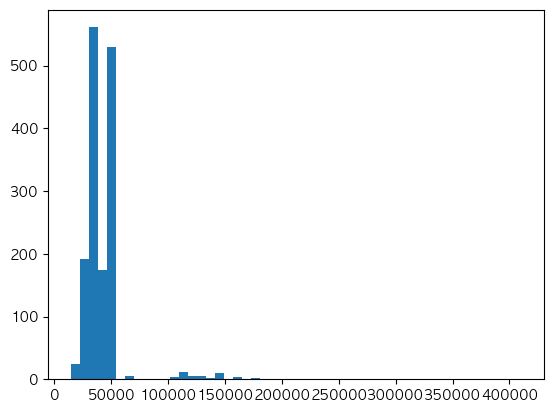

In [ ]:
import matplotlib.pyplot as plt
plt.hist(renew_rev, bins=50)
plt.show()

In [ ]:
cancel_rev = revenue_90[revenue_90['user_id'].isin(u5)]['revenue_90']

print(f"[Group C - cancel]")
print(f"유저 수:       {len(cancel_rev):,}명")
print(f"총 매출:       {cancel_rev.sum():,.0f}")
print(f"평균 매출:     {cancel_rev.mean():,.0f}")
print(f"중앙값 매출:   {cancel_rev.median():,.0f}")

# 3그룹 비교
print("\n[그룹간 Mann-Whitney U test]")
stat, p = stats.mannwhitneyu(renew_rev, cancel_rev, alternative='two-sided')
print(f"renew vs cancel p-value: {p:.3f}")

stat, p = stats.mannwhitneyu(resub_rev, cancel_rev, alternative='two-sided')
print(f"resub vs cancel p-value: {p:.3f}")

stat, p = stats.mannwhitneyu(renew_rev, resub_rev, alternative='two-sided')
print(f"renew vs resub p-value: {p:.3f}")

[Group C - cancel]
유저 수:       0명
총 매출:       0
평균 매출:     nan
중앙값 매출:   nan

[그룹간 Mann-Whitney U test]
renew vs cancel p-value: nan
resub vs cancel p-value: nan
renew vs resub p-value: 0.000


/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/3413211527.py:11: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.

/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/3413211527.py:14: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.



In [ ]:
# u2 전체 기준
first_rev = revenue_90[revenue_90['user_id'].isin(u2)]['revenue_90']
renew_rev = revenue_90[revenue_90['user_id'].isin(u3)]['revenue_90']
resub_rev = revenue_90[revenue_90['user_id'].isin(u4)]['revenue_90']
cancel_rev = revenue_90[revenue_90['user_id'].isin(u5)]['revenue_90']

stat, p = stats.mannwhitneyu(renew_rev, cancel_rev, alternative='two-sided')
print(f"first→renew vs first→cancel p-value: {p:.3f}")

first→renew vs first→cancel p-value: nan


/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/324427335.py:7: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.



# 3. Aha Moment

## 3-1. 학습 관련 전처리 EDA

# Aha Moment 후보 탐색  
## 유저의 첫 콘텐츠 완주까지 걸린 시간 분석

이 노트북의 목적은 사용자가 서비스에서 **처음으로 콘텐츠를 완주하는 경험이 얼마나 빠르게 발생하는지** 파악하는 것이다.  
이를 위해 `start_content`와 `end_content` 이벤트를 연결하고, 유저별 첫 완주 콘텐츠를 기준으로 **첫 시작 시점부터 첫 완주 시점까지의 실제 경과 시간**을 계산한다.

핵심 질문은 다음과 같다.

- 사용자는 첫 콘텐츠를 얼마나 빠르게 완주하는가
- 초기 학습 경험에는 어느 정도의 마찰이 존재하는가
- 빠른 첫 완주 경험은 Aha Moment 후보로 볼 수 있는가


## 1. 시작 이벤트 데이터 로드

먼저 `start_content` 데이터를 불러와 기본 정보와 샘플 행을 확인한다.  
이 단계에서는 이후 분석에 필요한 주요 컬럼이 존재하는지, 데이터 규모가 어느 정도인지 빠르게 점검한다.


In [ ]:
import pandas as pd

df_start_content = pd.read_csv(os.path.join(PATH_AHA, 'raw_start_content_aha.csv'))
print(df_start_content.head(10))
print('='*60)
print(df_start_content.info())
print('='*60)
print(df_start_content.describe())
print('='*60)

                            user_id                        content.id  \
0  9d55fbab092d0fd0388ca762f8c23c7c  ca35d0138a7550f002f975310604a9b7   
1  8f19e4832651ff3c64cd3708417fdda2  61b6463287573f00de13a930805a52d6   
2  08ebb0b2858b5a1bc1f496a29735c54b  61b6463287573f00de13a930805a52d6   
3  08ebb0b2858b5a1bc1f496a29735c54b  c269eb6df3a374b464f7c18f12fa398f   
4  cd682cfd3c7131dda66bc9206cf171b5  c269eb6df3a374b464f7c18f12fa398f   
5  4f805a348f0be156f7f3f3533900666f  ca35d0138a7550f002f975310604a9b7   
6  511011a6ac765ecdb25015cc971a1306  f4be1a0fe0e301b03115591777fddf29   
7  94d0997ddca881fb9cb6794d29541f01  68a3658f1b936bfff3bd6960cd561b0a   
8  83bd8855b0e0d6755626c050df628bf3  6ed981e96eb69b7169b85ed3994a4980   
9  c22a5a26b21cb070c11f377c9fbd7ce8  f4be1a0fe0e301b03115591777fddf29   

      event_type content.difficulty           client_event_time  
0  start.content           beginner  2023-05-28 03:02:55.617000  
1  start.content           beginner  2023-05-28 03:09:42.892000 

## 1-1. 시작 이벤트 컬럼 구조 및 크기 확인

이 셀은 `start_content`의 컬럼 목록과 전체 shape를 확인하는 단계다.  
분석 전에 어떤 필드가 실제로 존재하는지 명확히 파악해 두면 이후 전처리와 조인 기준을 안정적으로 설정할 수 있다.


In [ ]:
print(df_start_content.columns)
print('='*60)
print(df_start_content.shape)

Index(['user_id', 'content.id', 'event_type', 'content.difficulty',
       'client_event_time'],
      dtype='object')
(74961, 5)


## 1-2. 시작 이벤트의 시간 범위 확인

`client_event_time`을 datetime으로 변환한 뒤 데이터가 어느 기간에 걸쳐 적재되어 있는지 확인한다.  
이 단계는 월별 시계열 분석과 이벤트 분포 해석의 기준 기간을 정하는 데 필요하다.


In [ ]:
import pandas as pd

# 시간형 변환
tmp = df_start_content.copy()
tmp["client_event_time"] = pd.to_datetime(tmp["client_event_time"], errors="coerce")

# 범위 확인
time_min = tmp["client_event_time"].min()
time_max = tmp["client_event_time"].max()

print("최소 시간:", time_min)
print("최대 시간:", time_max)
print("기간 차이:", time_max - time_min)

최소 시간: 2023-05-01 00:00:00.977000
최대 시간: 2023-12-31 23:57:28.452000
기간 차이: 244 days 23:57:27.475000


## 1-3. 시작 이벤트 품질 점검

이벤트 로그 기반 분석에서는 결측치와 반복 적재가 결과를 왜곡할 수 있다.  
따라서 `user_id`, `content.id`, `event_type`, `client_event_time`, `content.difficulty` 중심으로 null과 중복 후보를 점검한다.


In [ ]:
# =========================================
# df_start_content null / 중복 점검
# 기준: user_id, content.id
# =========================================

check_cols = ['user_id', 'content.id', 'event_type', 'client_event_time',
       'content.difficulty']
check_cols2 = ['user_id', 'content.id']
start_check = df_start_content.copy()

# 1. 전체 행 수
print("전체 행 수:", len(start_check))

# 2. 기준 컬럼별 null 개수
print("\n[기준 컬럼별 null 개수]")
print(start_check[check_cols].isna().sum())

# 3. 기준 컬럼 중 하나라도 null인 행 개수
null_rows = start_check[start_check[check_cols].isna().any(axis=1)].copy()
print("\n[user_id 또는 content.id가 null인 행 개수]:", len(null_rows))
display(null_rows.head())

# 4. null 제거 후 데이터
start_no_null = start_check.dropna(subset=check_cols).copy()
print("\nnull 제거 후 행 수:", len(start_no_null))

# 5. user_id + content.id 기준 중복 여부 확인
dup_mask = start_no_null.duplicated(subset=check_cols2, keep=False)
dup_rows = start_no_null[dup_mask].copy()

print("\n[user_id + content.id 기준 중복으로 잡히는 행 개수]:", len(dup_rows))

# 6. 중복 그룹 개수 확인
dup_group_count = (
    start_no_null
    .groupby(check_cols2, dropna=False)
    .size()
    .reset_index(name="count")
    .query("count > 1")
)

print("[중복 그룹 수]:", len(dup_group_count))
display(dup_group_count.head(140))

# 7. 실제 중복 행 일부 보기
dup_rows_sorted = dup_rows.sort_values(check_cols)
display(dup_rows_sorted.head(20))

전체 행 수: 74961

[기준 컬럼별 null 개수]
user_id               0
content.id            0
event_type            0
client_event_time     0
content.difficulty    0
dtype: int64

[user_id 또는 content.id가 null인 행 개수]: 0


,user_id,content.id,event_type,content.difficulty,client_event_time



null 제거 후 행 수: 74961

[user_id + content.id 기준 중복으로 잡히는 행 개수]: 306
[중복 그룹 수]: 140


,user_id,content.id,count
849,02c6b331129ea8588abca4e1dd41adea,621c7ad99b17d2d16832b618d47aea7e,2
1758,061dcd92f1dafec5700fb05ca537dc51,1ccd38c0253604fb48f78970736f915c,2
1764,061dcd92f1dafec5700fb05ca537dc51,445fac33232adcb3d1cdab7d8a579430,2
1770,061dcd92f1dafec5700fb05ca537dc51,61b6463287573f00de13a930805a52d6,2
1783,061dcd92f1dafec5700fb05ca537dc51,f4be1a0fe0e301b03115591777fddf29,2
...,...,...,...
70194,f03db3fdc233683ed22426ae15d6e1bb,445fac33232adcb3d1cdab7d8a579430,2
71305,f40c8e42b9a072d00423f24ad217396b,7102ec0223c06a3a14a7556274d86b7d,2
72299,f70cf2877fa7fcdac2f6a42a058d231f,9982f3f4fcaf73515a5474c68c6a218a,2
72675,f84c4f83ca1e977a89e0f7f7e6561a48,f64c475280676531a31f2f8e0648599c,4


,user_id,content.id,event_type,content.difficulty,client_event_time
65759,02c6b331129ea8588abca4e1dd41adea,621c7ad99b17d2d16832b618d47aea7e,start.content,advanced,2023-10-15 17:36:55.029000
65760,02c6b331129ea8588abca4e1dd41adea,621c7ad99b17d2d16832b618d47aea7e,start.content,advanced,2023-10-15 17:36:55.103000
5646,061dcd92f1dafec5700fb05ca537dc51,1ccd38c0253604fb48f78970736f915c,start.content,advanced,2023-06-23 18:39:16.172000
48572,061dcd92f1dafec5700fb05ca537dc51,1ccd38c0253604fb48f78970736f915c,start.content,advanced,2023-08-25 07:44:43.070000
14153,061dcd92f1dafec5700fb05ca537dc51,445fac33232adcb3d1cdab7d8a579430,start.content,beginner,2023-06-19 19:59:53.859000
59733,061dcd92f1dafec5700fb05ca537dc51,445fac33232adcb3d1cdab7d8a579430,start.content,beginner,2023-08-09 17:37:40.898000
11205,061dcd92f1dafec5700fb05ca537dc51,61b6463287573f00de13a930805a52d6,start.content,beginner,2023-06-16 08:01:02.762000
40307,061dcd92f1dafec5700fb05ca537dc51,61b6463287573f00de13a930805a52d6,start.content,beginner,2023-08-02 17:27:23.336000
6794,061dcd92f1dafec5700fb05ca537dc51,f4be1a0fe0e301b03115591777fddf29,start.content,beginner,2023-06-14 22:26:27.163000
57084,061dcd92f1dafec5700fb05ca537dc51,f4be1a0fe0e301b03115591777fddf29,start.content,beginner,2023-07-19 12:18:34.131000


## 1-4. 시작 이벤트의 3초 이내 중복 제거

동일한 `user_id`와 `content.id`에서 아주 짧은 시간 안에 발생한 반복 이벤트는 실제 행동보다 로그 노이즈일 가능성이 높다.  
그래서 3초 이내 반복 기록은 하나의 행동으로 간주해 정제한다.


In [ ]:
import pandas as pd

# =========================================
# 3초 이내 중복 제거 함수
# 기준: user_id + content.id
# 시간컬럼: client_event_time
# =========================================
def remove_near_duplicates(df, group_cols, time_col, threshold_seconds=3):
    temp = df.copy()

    # 시간형 변환
    temp[time_col] = pd.to_datetime(temp[time_col], errors="coerce")

    # 필수값 없는 행 제거
    temp = temp.dropna(subset=group_cols + [time_col]).copy()

    # 정렬
    temp = temp.sort_values(group_cols + [time_col]).reset_index(drop=True)

    kept_rows = []

    for _, group in temp.groupby(group_cols, sort=False):
        group = group.sort_values(time_col).copy()

        keep_idx = []
        last_kept_time = None

        for idx, row in group.iterrows():
            current_time = row[time_col]

            if last_kept_time is None:
                keep_idx.append(idx)
                last_kept_time = current_time
            else:
                diff_sec = (current_time - last_kept_time).total_seconds()

                # 3초 초과일 때만 새로운 정상 이벤트로 인정
                if diff_sec > threshold_seconds:
                    keep_idx.append(idx)
                    last_kept_time = current_time

        kept_rows.extend(keep_idx)

    result = temp.loc[kept_rows].sort_values(group_cols + [time_col]).reset_index(drop=True)
    return result


# =========================================
# 원본 데이터 점검
# =========================================
df_start_tmp = df_start_content.copy()

# 시간형 변환
df_start_tmp["client_event_time"] = pd.to_datetime(df_start_tmp["client_event_time"], errors="coerce")

# 비교 전 행 수
print("원본 행 수:", len(df_start_tmp))

# 중복 제거 실행
df_start_dedup_3s = remove_near_duplicates(
    df=df_start_tmp,
    group_cols=["user_id", "content.id"],
    time_col="client_event_time",
    threshold_seconds=3
)

# 결과 확인
print("3초 이내 중복 제거 후 행 수:", len(df_start_dedup_3s))
print("제거된 행 수:", len(df_start_tmp.dropna(subset=["user_id", "content.id", "client_event_time"])) - len(df_start_dedup_3s))
df_start_content=df_start_dedup_3s
display(df_start_dedup_3s.head())

원본 행 수: 74961
3초 이내 중복 제거 후 행 수: 74827
제거된 행 수: 74


,user_id,content.id,event_type,content.difficulty,client_event_time
0,000087537cbfd934375364218ff10f91,0ab2b890d4068c1490b89676773256f6,start.content,intermediate,2023-05-01 19:31:15.918
1,0001f15911b404f3bf5b8571afafa4e4,61b6463287573f00de13a930805a52d6,start.content,beginner,2023-11-29 10:14:22.988
2,0001f15911b404f3bf5b8571afafa4e4,c8e53577758bf66711094352a5abd8c3,start.content,intermediate,2023-11-30 11:35:37.133
3,0001f15911b404f3bf5b8571afafa4e4,f4be1a0fe0e301b03115591777fddf29,start.content,beginner,2023-11-22 21:50:00.941
4,0003b028a745bdfda9e88539424248af,c269eb6df3a374b464f7c18f12fa398f,start.content,advanced,2023-06-24 15:11:41.788


## 1-5. 정제된 시작 이벤트를 분석용 데이터로 반영

앞 단계에서 만든 중복 제거 결과를 이후 분석의 기준 데이터프레임으로 사용한다.  
즉, 이후의 시작 이벤트 EDA와 조인 로직은 이 정제본을 기준으로 해석해야 한다.


In [ ]:
df_start_content = df_start_dedup_3s.copy()

## 1-6. 난이도별 시작 이벤트 분포 시각화

사용자가 어떤 난이도의 콘텐츠에서 학습을 시작하는지 막대그래프로 확인한다.  
이 분포는 초기 진입 난이도 편중 여부를 보여주며, 이후 첫 완주 시간 차이를 해석하는 배경 자료가 된다.


content.difficulty
advanced        13761
beginner        40726
hard             1370
intermediate    18970
Name: count, dtype: int64

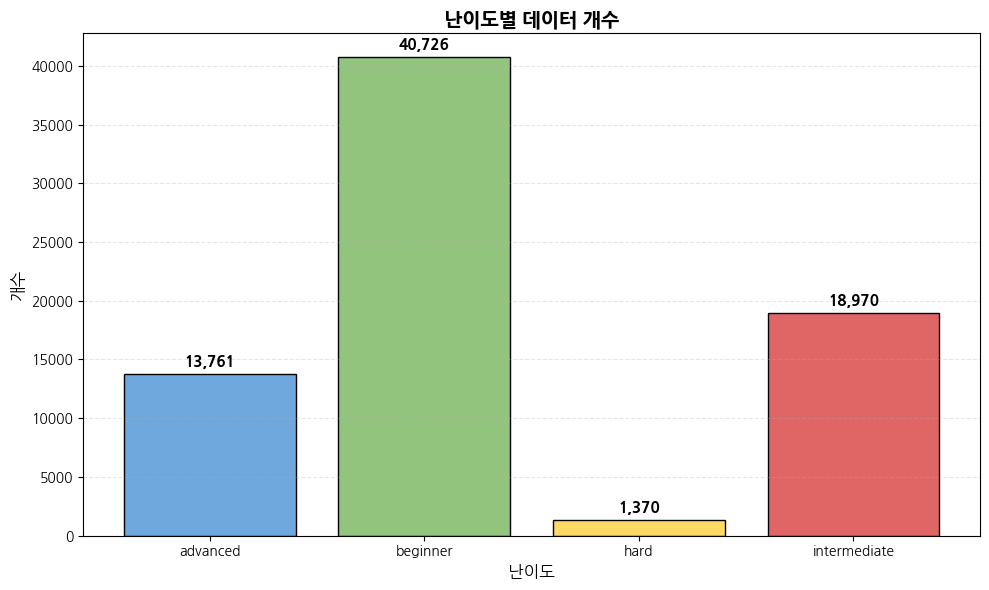

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

col = "content.difficulty"

difficulty_count = (
    df_start_content[col]
    .fillna("Unknown")
    .astype(str)
    .value_counts()
    .sort_index()
)

display(difficulty_count)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    difficulty_count.index,
    difficulty_count.values,
    color=["#6FA8DC", "#93C47D", "#FFD966", "#E06666", "#8E7CC3"][:len(difficulty_count)],
    edgecolor="black",
    linewidth=1
)

plt.title("난이도별 데이터 개수", fontsize=14, fontweight="bold")
plt.xlabel("난이도", fontsize=12)
plt.ylabel("개수", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

# 막대 위에 개수 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(difficulty_count.values) * 0.01,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## 시작 이벤트 난이도 분포 해석

이 셀은 `start_content` 기준으로 사용자가 **어떤 난이도의 콘텐츠에서 학습을 시작하는지** 확인하는 단계다.  
이 분포는 이후 첫 완주 시간 해석의 배경이 된다. 특정 난이도에 시작 이벤트가 편중되어 있다면, 완주 속도 역시 난이도의 영향을 받을 수 있기 때문이다.


## 1-7. 월별·난이도별 시작 건수 시각화

월 단위로 시작 이벤트를 집계하고, 난이도별 추이를 선 그래프로 비교한다.  
이 셀의 목적은 특정 시점에 어떤 난이도가 상대적으로 더 많이 시작되었는지 파악하는 것이다.


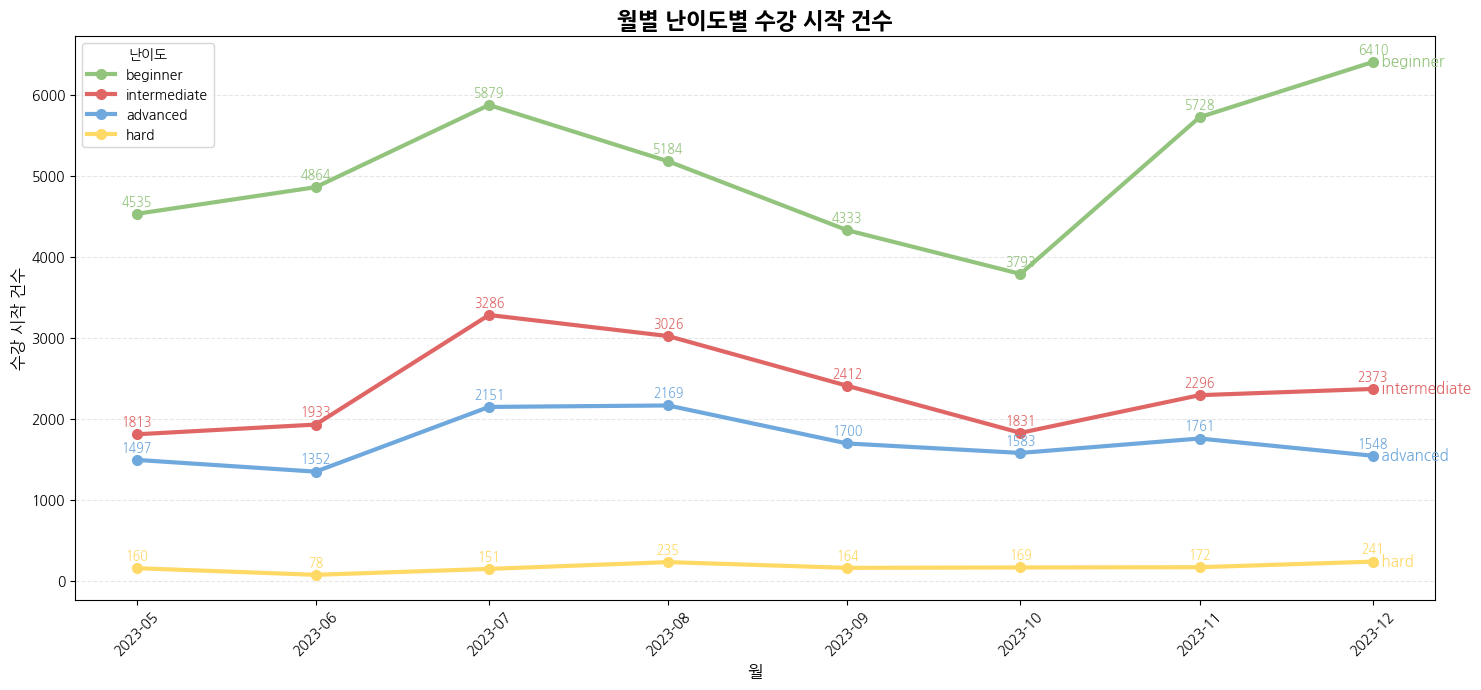

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 원본 복사
tmp = df_start_content.copy()

# 날짜 변환
tmp["client_event_time"] = pd.to_datetime(tmp["client_event_time"], errors="coerce")

# 필요한 컬럼만 남기기
tmp = tmp.dropna(subset=["client_event_time", "content.difficulty"])

# 월 단위 컬럼 생성
tmp["year_month"] = tmp["client_event_time"].dt.to_period("M").dt.to_timestamp()

# 난이도 순서
difficulty_order = ["beginner", "intermediate", "advanced", "hard"]

# 월별 난이도별 시작 건수 집계
monthly_difficulty = (
    tmp.groupby(["year_month", "content.difficulty"])
       .size()
       .reset_index(name="start_count")
)

# 피벗 테이블 생성
pivot_df = (
    monthly_difficulty
    .pivot(index="year_month", columns="content.difficulty", values="start_count")
    .fillna(0)
    .sort_index()
)

# 실제 존재하는 난이도 컬럼만 순서대로 정렬
existing_cols = [c for c in difficulty_order if c in pivot_df.columns]
pivot_df = pivot_df.reindex(columns=existing_cols)

# 색상 지정
colors = {
    "beginner": "#93C47D",
    "intermediate": "#E06666",
    "advanced": "#6FA8DC",
    "hard": "#FFD966"
}

plt.figure(figsize=(15, 7))

for col in pivot_df.columns:
    plt.plot(
        pivot_df.index,
        pivot_df[col],
        linewidth=3,
        marker="o",
        markersize=7,
        label=col,
        color=colors.get(col, None)
    )

    # 각 점 위에 값 표시
    for x, y in zip(pivot_df.index, pivot_df[col]):
        plt.text(
            x,
            y + max(pivot_df.max()) * 0.01,   # 점보다 살짝 위
            f"{int(y)}",
            color=colors.get(col, "black"),
            fontsize=9,
            ha="center",
            va="bottom"
        )

    # 마지막 점 오른쪽에 라인 이름 표시
    plt.text(
        pivot_df.index[-1],
        pivot_df[col].iloc[-1],
        f"  {col}",
        color=colors.get(col, "black"),
        fontsize=11,
        va="center"
    )

plt.title("월별 난이도별 수강 시작 건수", fontsize=16, fontweight="bold")
plt.xlabel("월", fontsize=12)
plt.ylabel("수강 시작 건수", fontsize=12)

xticks = pivot_df.index[::1]
plt.xticks(xticks, [d.strftime("%Y-%m") for d in xticks], rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="난이도")
plt.tight_layout()
plt.show()

## 월별 난이도별 시작 추이 해석

이 시각화는 월별로 시작 이벤트가 어떻게 변화하는지 보여준다.  
목적은 **계절성·유입 변화·난이도별 편중 가능성**을 파악하는 것이며, 여기서 보이는 패턴은 이후 완주 시점 분석을 해석하는 참고 배경으로 사용한다.


## 1-8. 시작 건수 기준 상위 콘텐츠 확인

어떤 콘텐츠가 가장 많이 시작되었는지 TOP 10을 확인한다.  
이는 인기 콘텐츠 편중 여부를 파악하는 보조 탐색 단계이며, 이후 완주 분석에서 특정 콘텐츠 영향 가능성을 생각해볼 수 있다.


,content.id,시작건수
137,f4be1a0fe0e301b03115591777fddf29,20295
52,61b6463287573f00de13a930805a52d6,9377
33,445fac33232adcb3d1cdab7d8a579430,3536
60,68a3658f1b936bfff3bd6960cd561b0a,3390
115,ca35d0138a7550f002f975310604a9b7,2162
136,f491517f4737a60d661cd1fcacc702c0,2146
108,c269eb6df3a374b464f7c18f12fa398f,2043
43,595cb4bbfc83e683b0314ca1312cfbde,2022
101,b314d5aba64a0aab40602cb72a4a1504,1470
121,d6227ba76134f6cf821bb98b5f235bd0,1316


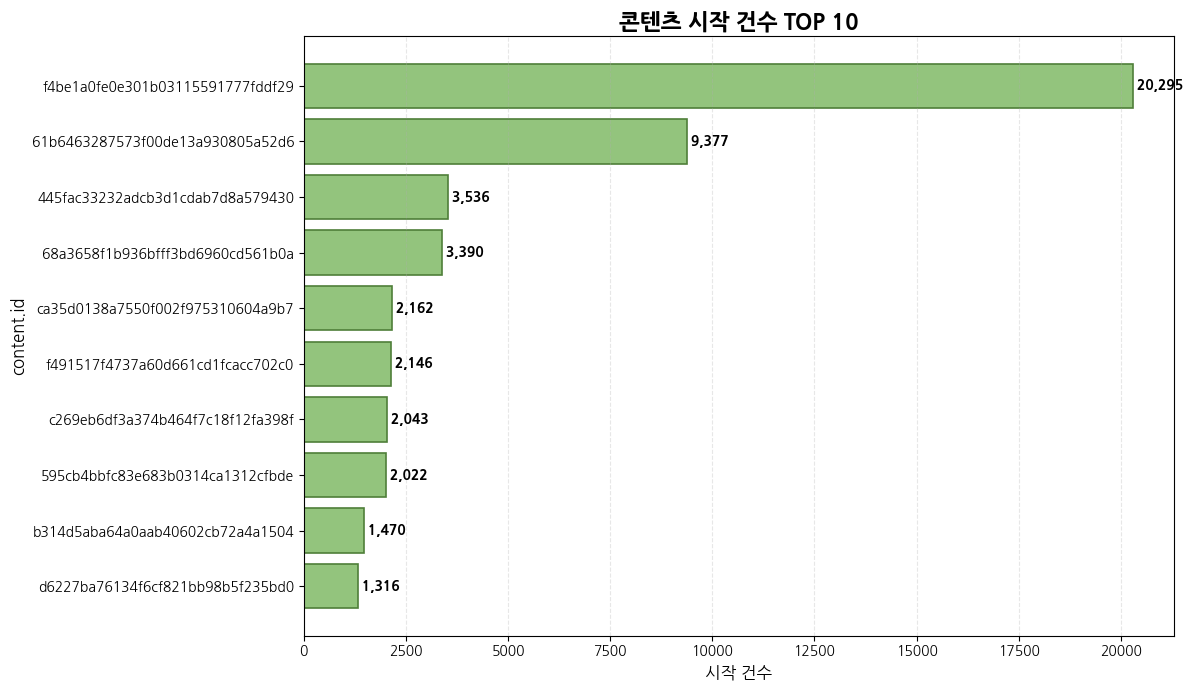

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 원본 복사
tmp = df_start_content.copy()

# 필요하면 시작 이벤트만 필터링
# tmp = tmp[tmp["event_type"] == "content_start"].copy()

# content.id 결측 제거
tmp = tmp.dropna(subset=["content.id"])

# 콘텐츠별 시작 건수 TOP 10
content_start_top10 = (
    tmp.groupby("content.id")
       .size()
       .reset_index(name="시작건수")
       .sort_values("시작건수", ascending=False)
       .head(10)
)

display(content_start_top10)

# 시각화
plt.figure(figsize=(12, 7))
bars = plt.barh(
    content_start_top10["content.id"].astype(str),
    content_start_top10["시작건수"],
    color="#93C47D",
    edgecolor="#4F7F39",
    linewidth=1.2
)

# 막대 옆 수치 표시
for bar in bars:
    w = bar.get_width()
    plt.text(
        w,
        bar.get_y() + bar.get_height() / 2,
        f" {int(w):,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("콘텐츠 시작 건수 TOP 10", fontsize=16, fontweight="bold")
plt.xlabel("시작 건수", fontsize=12)
plt.ylabel("content.id", fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. 완료 이벤트 데이터 로드

이번에는 `end_content` 데이터를 불러와 샘플·정보·기초 통계를 확인한다.  
`start_content`와 동일한 방식으로 구조를 점검해야 두 테이블을 안정적으로 연결할 수 있다.


In [ ]:
import pandas as pd
df_end_content = normalize_loaded_dataframe(pd.read_csv(os.path.join(PATH_AHA, 'raw_end_content_aha.csv')))

print(df_end_content.head())
print('='*60)
print(df_end_content.info())
print('='*60)
print(df_end_content.describe())
print('='*60)

                            user_id                        content.id  \
0  010a54b7adcb47015c5813cf8509461e  18992b667be06d6f29ba0008f99d9745   
1  00ba1c93acb0f55a25e3ab0fb5e66459  f131e2fc518ebc882b8ae4741e19b1f1   
2  83bd8855b0e0d6755626c050df628bf3  e88906bb19b773dcbf2adb5d34c49d9c   
3  40db59b4f38140011fbccb471707a79d  5cea8d6e02eb18b2660f98f424867e4d   
4  b9a1e53d7c06ba4f6c63e04f09510338  66fbc8fa22ac46a73eb3dfe499d270a7   

    event_type    client_event_time  
0  end.content  2023-05-28 03:03:55  
1  end.content  2023-05-28 03:21:49  
2  end.content  2023-05-31 10:46:06  
3  end.content  2023-05-31 10:03:07  
4  end.content  2023-05-31 10:07:09  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46362 entries, 0 to 46361
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            46362 non-null  object
 1   content.id         46362 non-null  object
 2   event_type         46362 non-nul

## 2-1. 완료 이벤트 컬럼 구조 및 크기 확인

완료 이벤트 테이블의 컬럼 목록과 shape를 확인한다.  
이 단계는 이후 조인 키와 시간 컬럼, 이벤트 타입 필터가 정상적으로 존재하는지 점검하는 역할을 한다.


In [ ]:
print(df_end_content.columns)
print('='*60)
print(df_end_content.shape)

Index(['user_id', 'content.id', 'event_type', 'client_event_time'], dtype='object')
(46362, 4)


## 2-2. 완료 이벤트의 시간 범위 확인

완료 이벤트가 기록된 전체 기간을 확인한다.  
시작 이벤트와 완료 이벤트의 기간 범위를 비교하면 두 데이터셋의 시계열 해석 가능 범위를 보다 명확히 잡을 수 있다.


In [ ]:
import pandas as pd

# 시간형 변환
tmp = df_end_content.copy()
tmp["client_event_time"] = pd.to_datetime(tmp["client_event_time"], errors="coerce")

# 범위 확인
time_min = tmp["client_event_time"].min()
time_max = tmp["client_event_time"].max()

print("최소 시간:", time_min)
print("최대 시간:", time_max)
print("기간 차이:", time_max - time_min)

최소 시간: 2023-05-01 00:05:18
최대 시간: 2023-12-31 23:55:36
기간 차이: 244 days 23:50:18


## 2-3. 완료 이벤트 품질 점검

`end_content` 역시 결측치와 반복 적재 여부를 점검해야 한다.  
특히 완료 이벤트는 첫 완주 시점을 정의하는 기준이므로, null과 중복 검사는 핵심 전처리 단계다.


In [ ]:
# =========================================
# df_end_content null / 중복 점검
# 기준: user_id, content.id
# =========================================

check_cols = ['user_id', 'content.id', 'event_type', 'client_event_time',]
check_cols2 = ['user_id', 'content.id']
end_check = df_end_content.copy()

# 1. 전체 행 수
print("전체 행 수:", len(end_check))

# 2. 기준 컬럼별 null 개수
print("\n[기준 컬럼별 null 개수]")
print(end_check[check_cols].isna().sum())

# 3. 기준 컬럼 중 하나라도 null인 행 개수
null_rows = end_check[end_check[check_cols].isna().any(axis=1)].copy()
print("\n[user_id 또는 content.id가 null인 행 개수]:", len(null_rows))
display(null_rows.head())

# 4. null 제거 후 데이터
end_no_null = end_check.dropna(subset=check_cols).copy()
print("\nnull 제거 후 행 수:", len(end_no_null))

# 5. user_id + content.id 기준 중복 여부 확인
dup_mask = end_no_null.duplicated(subset=check_cols2, keep=False)
dup_rows = end_no_null[dup_mask].copy()

print("\n[user_id + content.id 기준 중복으로 잡히는 행 개수]:", len(dup_rows))

# 6. 중복 그룹 개수 확인
dup_group_count = (
    end_no_null
    .groupby(check_cols2, dropna=False)
    .size()
    .reset_index(name="count")
    .query("count > 1")
)

print("[중복 그룹 수]:", len(dup_group_count))
display(dup_group_count.head(140))

# 7. 실제 중복 행 일부 보기
dup_rows_sorted = dup_rows.sort_values(check_cols)
display(dup_rows_sorted.head(59))
display(dup_rows_sorted.tail(59))

전체 행 수: 46362

[기준 컬럼별 null 개수]
user_id              0
content.id           0
event_type           0
client_event_time    0
dtype: int64

[user_id 또는 content.id가 null인 행 개수]: 0


,user_id,content.id,event_type,client_event_time



null 제거 후 행 수: 46362

[user_id + content.id 기준 중복으로 잡히는 행 개수]: 248
[중복 그룹 수]: 118


,user_id,content.id,count
263,014b8c3e1d2070303c07f2b1253c4108,5e91cfee387a0e3b45c0522d63be434e,2
809,049bda1a55855c123731d977e6160114,eb4ad7a11f1ce6638ec7971d5be00475,2
1039,061dcd92f1dafec5700fb05ca537dc51,61b6463287573f00de13a930805a52d6,2
1182,06c088703949d8d7146cd28b4eb874c2,f4be1a0fe0e301b03115591777fddf29,2
2701,0f82e673819f6c8d886498ed3da1878c,3b883765ba3731d00686a78af35a6dbb,2
...,...,...,...
43729,f2454e7e1f01a1a17fe76398f9f9e090,5e91cfee387a0e3b45c0522d63be434e,2
44568,f6d5f0c5b13eebb32bd1a224f16cfe7f,445fac33232adcb3d1cdab7d8a579430,2
44571,f6d5f0c5b13eebb32bd1a224f16cfe7f,6ed981e96eb69b7169b85ed3994a4980,2
44572,f6d5f0c5b13eebb32bd1a224f16cfe7f,e88906bb19b773dcbf2adb5d34c49d9c,2


,user_id,content.id,event_type,client_event_time
46286,014b8c3e1d2070303c07f2b1253c4108,5e91cfee387a0e3b45c0522d63be434e,end.content,2023-12-01 09:48:31
10954,014b8c3e1d2070303c07f2b1253c4108,5e91cfee387a0e3b45c0522d63be434e,end.content,2023-12-03 15:46:57
26028,049bda1a55855c123731d977e6160114,eb4ad7a11f1ce6638ec7971d5be00475,end.content,2023-11-29 11:44:11
22526,049bda1a55855c123731d977e6160114,eb4ad7a11f1ce6638ec7971d5be00475,end.content,2023-12-11 11:00:15
1018,061dcd92f1dafec5700fb05ca537dc51,61b6463287573f00de13a930805a52d6,end.content,2023-06-16 09:11:44
36604,061dcd92f1dafec5700fb05ca537dc51,61b6463287573f00de13a930805a52d6,end.content,2023-08-09 17:36:41
6592,06c088703949d8d7146cd28b4eb874c2,f4be1a0fe0e301b03115591777fddf29,end.content,2023-06-07 10:47:08
46183,06c088703949d8d7146cd28b4eb874c2,f4be1a0fe0e301b03115591777fddf29,end.content,2023-08-04 15:02:25
13409,0f82e673819f6c8d886498ed3da1878c,3b883765ba3731d00686a78af35a6dbb,end.content,2023-12-01 00:44:15
9469,0f82e673819f6c8d886498ed3da1878c,3b883765ba3731d00686a78af35a6dbb,end.content,2023-12-01 17:12:22


,user_id,content.id,event_type,client_event_time
36798,ae0265d0817781ccf5c9e04e0fd464af,5e91cfee387a0e3b45c0522d63be434e,end.content,2023-12-01 22:55:25
22955,b1afce05891b9c65a8648057ec43c141,eb4ad7a11f1ce6638ec7971d5be00475,end.content,2023-12-06 16:34:11
24079,b1afce05891b9c65a8648057ec43c141,eb4ad7a11f1ce6638ec7971d5be00475,end.content,2023-12-17 17:13:59
11279,b340f54841d9846775042ef7edd41ae6,f4be1a0fe0e301b03115591777fddf29,end.content,2023-11-05 15:04:06
20429,b340f54841d9846775042ef7edd41ae6,f4be1a0fe0e301b03115591777fddf29,end.content,2023-12-11 22:50:30
35741,b7d6395c8313bf5c66af0dd5af269647,634f93f037bb2c534c2f99fdd16a04f0,end.content,2023-07-26 23:28:42
35742,b7d6395c8313bf5c66af0dd5af269647,634f93f037bb2c534c2f99fdd16a04f0,end.content,2023-07-26 23:28:42
35743,b7d6395c8313bf5c66af0dd5af269647,634f93f037bb2c534c2f99fdd16a04f0,end.content,2023-07-26 23:28:42
26375,b8eb0b7d29a907ad56162c96ed868f98,68a3658f1b936bfff3bd6960cd561b0a,end.content,2023-08-24 10:50:14
20241,b8eb0b7d29a907ad56162c96ed868f98,68a3658f1b936bfff3bd6960cd561b0a,end.content,2023-10-19 10:10:42


## 2-4. 완료 이벤트의 3초 이내 중복 제거

시작 이벤트와 동일한 기준으로 완료 이벤트도 정제한다.  
이렇게 해야 start/end 비교와 조인에서 전처리 일관성을 유지할 수 있다.


In [ ]:
import pandas as pd

# =========================================
# 3초 이내 중복 제거 함수
# 기준: user_id + content.id
# 시간컬럼: client_event_time
# =========================================
def remove_near_duplicates(df, group_cols, time_col, threshold_seconds=3):
    temp = df.copy()

    # 시간형 변환
    temp[time_col] = pd.to_datetime(temp[time_col], errors="coerce")

    # 필수값 없는 행 제거
    temp = temp.dropna(subset=group_cols + [time_col]).copy()

    # 정렬
    temp = temp.sort_values(group_cols + [time_col]).reset_index(drop=True)

    kept_rows = []

    for _, group in temp.groupby(group_cols, sort=False):
        group = group.sort_values(time_col).copy()

        keep_idx = []
        last_kept_time = None

        for idx, row in group.iterrows():
            current_time = row[time_col]

            if last_kept_time is None:
                keep_idx.append(idx)
                last_kept_time = current_time
            else:
                diff_sec = (current_time - last_kept_time).total_seconds()

                # 3초 초과일 때만 새로운 정상 이벤트로 인정
                if diff_sec > threshold_seconds:
                    keep_idx.append(idx)
                    last_kept_time = current_time

        kept_rows.extend(keep_idx)

    result = temp.loc[kept_rows].sort_values(group_cols + [time_col]).reset_index(drop=True)
    return result


# =========================================
# 원본 데이터 점검
# =========================================
df_end_tmp = df_end_content.copy()

# 시간형 변환
df_end_tmp["client_event_time"] = pd.to_datetime(df_end_tmp["client_event_time"], errors="coerce")

# 비교 전 행 수
print("원본 행 수:", len(df_end_tmp))

# 중복 제거 실행
df_end_dedup_3s = remove_near_duplicates(
    df=df_end_tmp,
    group_cols=["user_id", "content.id"],
    time_col="client_event_time",
    threshold_seconds=3
)

# 결과 확인
print("3초 이내 중복 제거 후 행 수:", len(df_end_dedup_3s))
print("제거된 행 수:", len(df_end_tmp.dropna(subset=["user_id", "content.id", "client_event_time"])) - len(df_end_dedup_3s))
df_end_content=df_end_dedup_3s
display(df_end_dedup_3s.head())

원본 행 수: 46362
3초 이내 중복 제거 후 행 수: 46359
제거된 행 수: 3


,user_id,content.id,event_type,client_event_time
0,0001f15911b404f3bf5b8571afafa4e4,61b6463287573f00de13a930805a52d6,end.content,2023-11-30 11:35:26
1,0001f15911b404f3bf5b8571afafa4e4,f4be1a0fe0e301b03115591777fddf29,end.content,2023-11-29 10:04:46
2,0008fe653493aa211bc7bd217bc0725c,4641438a6c81ef572d997dbdc9100f8b,end.content,2023-05-27 20:49:03
3,0008fe653493aa211bc7bd217bc0725c,68a3658f1b936bfff3bd6960cd561b0a,end.content,2023-05-27 20:18:50
4,0008fe653493aa211bc7bd217bc0725c,db1819d3a7a4c4d85dccb3b9e982fbcd,end.content,2023-05-27 21:32:13


## 2-5. 정제된 완료 이벤트를 분석용 데이터로 반영

중복 제거가 끝난 `end_content`를 이후 분석에서 사용할 최종 데이터프레임으로 지정한다.  
이 시점부터 완료 이벤트 관련 집계와 첫 완주 계산은 정제본 기준으로 수행된다.


In [ ]:
df_end_content = df_end_dedup_3s.copy()

## 2-6. 월별 완료 건수 시각화

완료 이벤트를 월 단위로 집계해 전체 완료 흐름을 확인한다.  
이 그래프는 시작 이벤트 시계열과 함께 보았을 때, 시작과 완료 사이의 시차 가능성을 해석하는 데 도움이 된다.


,year_month,complete_count
0,2023-05-01,4307
1,2023-06-01,3967
2,2023-07-01,6609
3,2023-08-01,6567
4,2023-09-01,5798
5,2023-10-01,5586
6,2023-11-01,6279
7,2023-12-01,7246


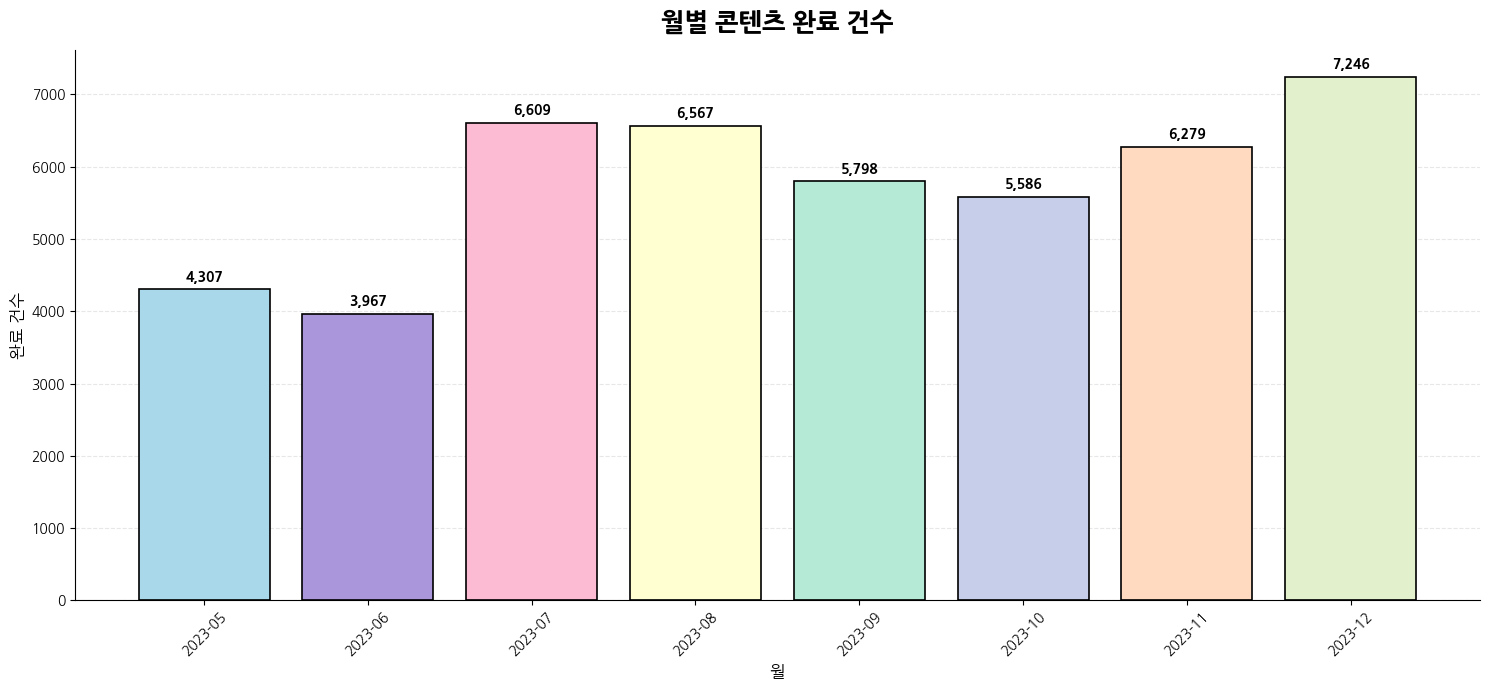

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

tmp = df_end_content.copy()

# 날짜 변환
tmp["client_event_time"] = pd.to_datetime(tmp["client_event_time"], errors="coerce")

# 날짜 결측 제거
tmp = tmp.dropna(subset=["client_event_time"])

# 월 컬럼 생성
tmp["year_month"] = tmp["client_event_time"].dt.to_period("M").dt.to_timestamp()

# 월별 완료 건수 집계
monthly_complete = (
    tmp.groupby("year_month")
       .size()
       .reset_index(name="complete_count")
       .sort_values("year_month")
)

display(monthly_complete)

# x축용 문자열
x_labels = monthly_complete["year_month"].dt.strftime("%Y-%m")
y_values = monthly_complete["complete_count"]

# 색상 리스트
bar_colors = [
    "#A8D8EA", "#AA96DA", "#FCBAD3", "#FFFFD2",
    "#B5EAD7", "#C7CEEA", "#FFDAC1", "#E2F0CB"
]

# 월 수보다 색이 적으면 반복
colors = (bar_colors * ((len(monthly_complete) // len(bar_colors)) + 1))[:len(monthly_complete)]

# 그래프
plt.figure(figsize=(15, 7))
bars = plt.bar(
    x_labels,
    y_values,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# 막대 위 숫자 표시
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + max(y_values) * 0.01,
        f"{int(h):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# 제목 / 축
plt.title("월별 콘텐츠 완료 건수", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("월", fontsize=12)
plt.ylabel("완료 건수", fontsize=12)

# 축 스타일
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# 배경/격자
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)

# 위/오른쪽 테두리 제거
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 2-7. 완료 건수 기준 상위 콘텐츠 확인

어떤 콘텐츠가 가장 많이 완료되었는지 TOP 10을 확인한다.  
이 셀은 특정 콘텐츠가 완주 분석 결과에 과도한 영향을 주는지 감을 잡기 위한 보조 탐색이다.


,content.id,완료건수
147,f4be1a0fe0e301b03115591777fddf29,6933
60,61b6463287573f00de13a930805a52d6,2869
67,68a3658f1b936bfff3bd6960cd561b0a,2562
146,f491517f4737a60d661cd1fcacc702c0,2372
51,595cb4bbfc83e683b0314ca1312cfbde,2294
39,445fac33232adcb3d1cdab7d8a579430,1465
109,b314d5aba64a0aab40602cb72a4a1504,1374
128,d6227ba76134f6cf821bb98b5f235bd0,1304
130,db1819d3a7a4c4d85dccb3b9e982fbcd,1242
41,4641438a6c81ef572d997dbdc9100f8b,1094


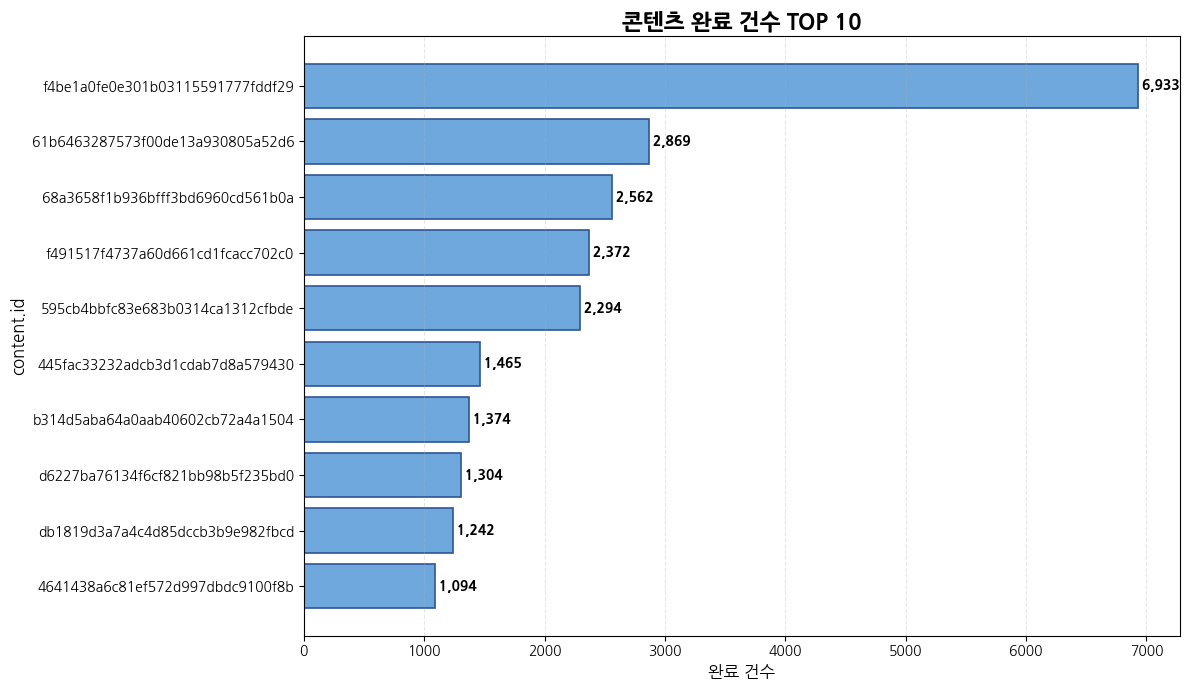

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 원본 복사
tmp = df_end_content.copy()


# content.id 결측 제거
tmp = tmp.dropna(subset=["content.id"])

# 콘텐츠별 완료 건수 TOP 10
content_top10 = (
    tmp.groupby("content.id")
       .size()
       .reset_index(name="완료건수")
       .sort_values("완료건수", ascending=False)
       .head(10)
)

display(content_top10)

# 시각화
plt.figure(figsize=(12, 7))
bars = plt.barh(
    content_top10["content.id"].astype(str),
    content_top10["완료건수"],
    color="#6FA8DC",
    edgecolor="#2F5597",
    linewidth=1.2
)

# 막대 옆에 수치 표시
for bar in bars:
    w = bar.get_width()
    plt.text(
        w,
        bar.get_y() + bar.get_height() / 2,
        f" {int(w):,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("콘텐츠 완료 건수 TOP 10", fontsize=16, fontweight="bold")
plt.xlabel("완료 건수", fontsize=12)
plt.ylabel("content.id", fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## 월별 완료 건수 해석

이 셀은 완료 이벤트의 시계열 흐름을 확인하는 단계다.  
시작 이벤트와 완료 이벤트를 함께 보면, 사용자가 학습을 시작한 직후 빠르게 완주하는지 아니면 일정 기간 이후에 완주하는지에 대한 감을 얻을 수 있다.

이 결과만으로 원인을 단정할 수는 없지만, **첫 완주까지의 시간 분포 분석이 왜 필요한지**를 설명하는 배경 자료로 활용할 수 있다.


## 부록 A. `complete_lesson` 데이터 추가 탐색

아래부터는 `complete_lesson` 테이블을 활용한 보조 분석 구간이다.  
이 구간은 메인 결론의 핵심 근거라기보다, **학습 완료 행동을 더 넓게 이해하기 위한 부록 탐색**으로 보면 된다.


In [ ]:
df_complete_lesson = normalize_loaded_dataframe(pd.read_csv(os.path.join(PATH_AHA, 'raw_complete_lesson_aha.csv')))
df_complete_lesson.info()
print(df_complete_lesson.head())
print('='*60)
print(df_complete_lesson.info())
print('='*60)
print(df_complete_lesson.describe())
print('='*60)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2035937 entries, 0 to 2035936
Data columns (total 5 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   user_id            object
 1   content.id         object
 2   event_type         object
 3   lesson.id          object
 4   client_event_time  object
dtypes: object(5)
memory usage: 77.7+ MB
                            user_id                        content.id  \
0  c1cb96f77ced3270097082bb62c0a8f3  94bdcbd9f329aafa84ab464b6721187d   
1  c1f85ebbfe6ac132fe5fd2127c692983  db1819d3a7a4c4d85dccb3b9e982fbcd   
2  c1f85ebbfe6ac132fe5fd2127c692983  db1819d3a7a4c4d85dccb3b9e982fbcd   
3  40dd0984448c33fdfc4a5dca89cac285  db43a841c994231e2795d4df8931af50   
4  6889ff4db275ecf85e34b1b16fc0be78  b314d5aba64a0aab40602cb72a4a1504   

        event_type                         lesson.id    client_event_time  
0  complete.lesson  63a32e026257ce29c05b98b718646b65  2023-05-28 03:58:28  
1  complete.lesson  245dac60e7835a9f29b

## A-1. `complete_lesson` 컬럼 구조 및 크기 확인

보조 분석용 테이블의 컬럼 목록과 shape를 먼저 확인한다.  
어떤 수준의 완료 이벤트가 기록되어 있는지 파악해야 이후 월별 집계와 분포 분석의 의미를 정확히 설명할 수 있다.


In [ ]:

print(df_complete_lesson.columns)
print('='*60)
print(df_complete_lesson.shape)

Index(['user_id', 'content.id', 'event_type', 'lesson.id',
       'client_event_time'],
      dtype='object')
(2035937, 5)


## A-2. `complete_lesson` 전처리 및 분석용 형태 준비

시간형 변환과 핵심 식별자 결측 제거를 수행한 뒤, 월 단위 집계를 위한 `year_month` 컬럼을 생성한다.  
즉, 이 셀은 부록 분석 전반의 공통 전처리 역할을 한다.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 원본 복사
tmp = df_complete_lesson.copy()

# 날짜형 변환
tmp["client_event_time"] = pd.to_datetime(tmp["client_event_time"], errors="coerce")

# 핵심 컬럼 결측 제거
tmp = tmp.dropna(subset=["client_event_time", "user_id", "content.id", "lesson.id"])

# 월 컬럼 생성
tmp["year_month"] = tmp["client_event_time"].dt.to_period("M").dt.to_timestamp()

print(tmp.shape)
display(tmp.head())

(2035937, 6)


,user_id,content.id,event_type,lesson.id,client_event_time,year_month
0,c1cb96f77ced3270097082bb62c0a8f3,94bdcbd9f329aafa84ab464b6721187d,complete.lesson,63a32e026257ce29c05b98b718646b65,2023-05-28 03:58:28,2023-05-01
1,c1f85ebbfe6ac132fe5fd2127c692983,db1819d3a7a4c4d85dccb3b9e982fbcd,complete.lesson,245dac60e7835a9f29bfa518aad19ccb,2023-05-28 03:19:29,2023-05-01
2,c1f85ebbfe6ac132fe5fd2127c692983,db1819d3a7a4c4d85dccb3b9e982fbcd,complete.lesson,b5f8bd008b0f27c21a8ad1dcb1d2bb57,2023-05-28 03:22:03,2023-05-01
3,40dd0984448c33fdfc4a5dca89cac285,db43a841c994231e2795d4df8931af50,complete.lesson,7ef8c93c6e18435e74b9615137191686,2023-05-28 03:04:08,2023-05-01
4,6889ff4db275ecf85e34b1b16fc0be78,b314d5aba64a0aab40602cb72a4a1504,complete.lesson,73eab76ab63e56526452b25e763abc4b,2023-05-28 03:22:24,2023-05-01


## A-3. 월별 레슨 완료 건수

월별로 완료된 레슨 총량을 집계해 전체 완료 볼륨을 본다.  
이 값은 특정 시점에 학습 소비량이 얼마나 집중되었는지 파악하는 데 유용하다.


,year_month,완료건수
0,2023-05-01,203550
1,2023-06-01,183191
2,2023-07-01,296514
3,2023-08-01,286382
4,2023-09-01,253709
5,2023-10-01,249770
6,2023-11-01,276321
7,2023-12-01,286500


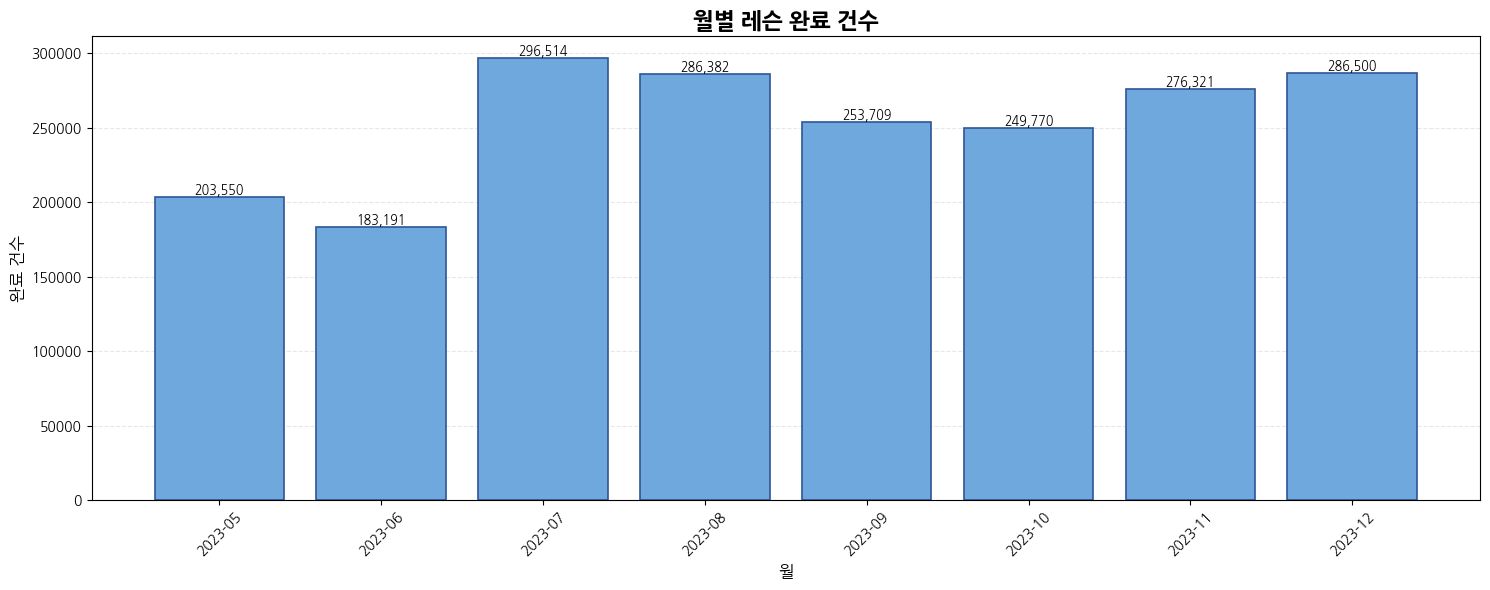

In [ ]:
monthly_complete = (
    tmp.groupby("year_month")
       .size()
       .reset_index(name="완료건수")
       .sort_values("year_month")
)

display(monthly_complete)

plt.figure(figsize=(15, 6))
bars = plt.bar(
    monthly_complete["year_month"].dt.strftime("%Y-%m"),
    monthly_complete["완료건수"],
    color="#6FA8DC",
    edgecolor="#2F5597",
    linewidth=1.2
)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{int(h):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("월별 레슨 완료 건수", fontsize=16, fontweight="bold")
plt.xlabel("월", fontsize=12)
plt.ylabel("완료 건수", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

## A-4. 월별 완료 유저 수

이번에는 완료 건수 자체가 아니라 **완료 행동을 한 고유 유저 수**를 본다.  
총 완료량과 완료 유저 수를 함께 보면, 소수 헤비 유저 중심인지 더 넓은 유저 기반의 행동인지 구분할 수 있다.


,year_month,완료유저수
0,2023-05-01,4493
1,2023-06-01,5211
2,2023-07-01,6322
3,2023-08-01,6170
4,2023-09-01,5049
5,2023-10-01,5094
6,2023-11-01,6334
7,2023-12-01,6664


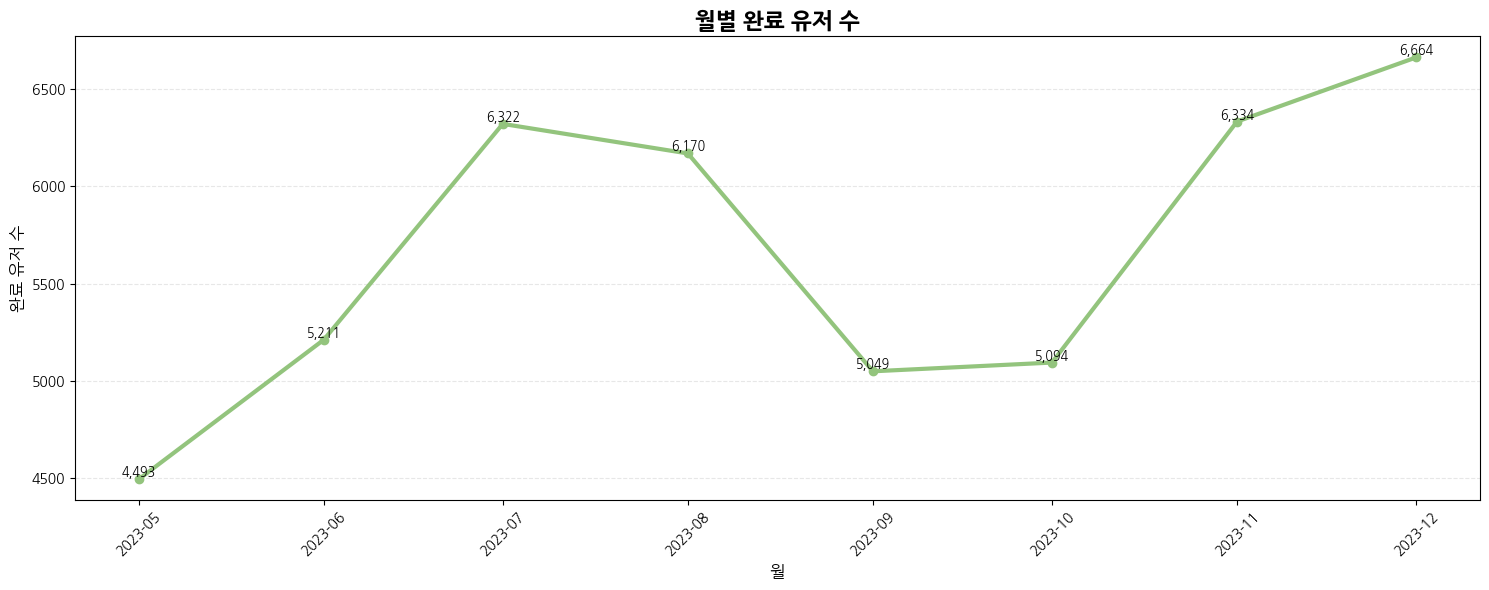

In [ ]:
monthly_users = (
    tmp.groupby("year_month")["user_id"]
       .nunique()
       .reset_index(name="완료유저수")
       .sort_values("year_month")
)

display(monthly_users)

plt.figure(figsize=(15, 6))
plt.plot(
    monthly_users["year_month"],
    monthly_users["완료유저수"],
    marker="o",
    linewidth=3,
    color="#93C47D"
)

for x, y in zip(monthly_users["year_month"], monthly_users["완료유저수"]):
    plt.text(x, y, f"{int(y):,}", ha="center", va="bottom", fontsize=9)

plt.title("월별 완료 유저 수", fontsize=16, fontweight="bold")
plt.xlabel("월", fontsize=12)
plt.ylabel("완료 유저 수", fontsize=12)
plt.xticks(
    monthly_users["year_month"],
    monthly_users["year_month"].dt.strftime("%Y-%m"),
    rotation=45
)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## A-5. 유저당 평균 완료 레슨 수

월별 완료건수와 완료유저수를 결합해 유저당 평균 완료 레슨 수를 계산한다.  
이는 학습 강도의 변화를 보는 지표로 활용할 수 있다.


,year_month,완료건수,완료유저수,유저당평균완료레슨수
0,2023-05-01,203550,4493,45.303806
1,2023-06-01,183191,5211,35.154673
2,2023-07-01,296514,6322,46.901930
3,2023-08-01,286382,6170,46.415235
4,2023-09-01,253709,5049,50.249356
5,2023-10-01,249770,5094,49.032195
6,2023-11-01,276321,6334,43.625039
7,2023-12-01,286500,6664,42.992197


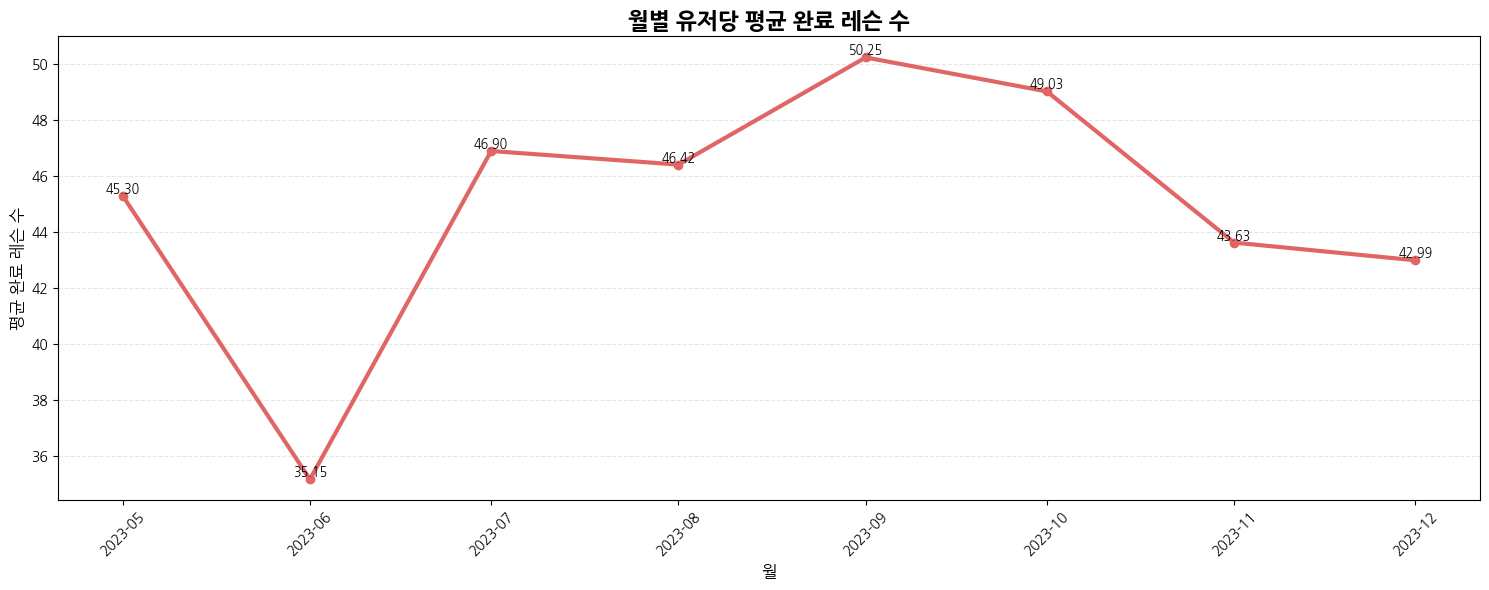

In [ ]:
monthly_stat = (
    tmp.groupby("year_month")
       .agg(
           완료건수=("lesson.id", "count"),
           완료유저수=("user_id", "nunique")
       )
       .reset_index()
       .sort_values("year_month")
)

monthly_stat["유저당평균완료레슨수"] = (
    monthly_stat["완료건수"] / monthly_stat["완료유저수"]
)

display(monthly_stat)

plt.figure(figsize=(15, 6))
plt.plot(
    monthly_stat["year_month"],
    monthly_stat["유저당평균완료레슨수"],
    marker="o",
    linewidth=3,
    color="#E06666"
)

for x, y in zip(monthly_stat["year_month"], monthly_stat["유저당평균완료레슨수"]):
    plt.text(x, y, f"{y:.2f}", ha="center", va="bottom", fontsize=9)

plt.title("월별 유저당 평균 완료 레슨 수", fontsize=16, fontweight="bold")
plt.xlabel("월", fontsize=12)
plt.ylabel("평균 완료 레슨 수", fontsize=12)
plt.xticks(
    monthly_stat["year_month"],
    monthly_stat["year_month"].dt.strftime("%Y-%m"),
    rotation=45
)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## A-6. 콘텐츠별 레슨 완료 건수 TOP 10

특정 콘텐츠가 레슨 완료를 많이 유도했는지 확인한다.  
상위 콘텐츠가 극단적으로 몰려 있다면 전체 평균 해석 시 콘텐츠 편중 가능성을 고려해야 한다.


,content.id,완료건수
156,f4be1a0fe0e301b03115591777fddf29,132135
155,f491517f4737a60d661cd1fcacc702c0,121929
120,c269eb6df3a374b464f7c18f12fa398f,100460
41,445fac33232adcb3d1cdab7d8a579430,99718
139,db1819d3a7a4c4d85dccb3b9e982fbcd,80492
63,61b6463287573f00de13a930805a52d6,78545
53,595cb4bbfc83e683b0314ca1312cfbde,72457
147,e88906bb19b773dcbf2adb5d34c49d9c,70988
43,4641438a6c81ef572d997dbdc9100f8b,65838
136,d6227ba76134f6cf821bb98b5f235bd0,61687


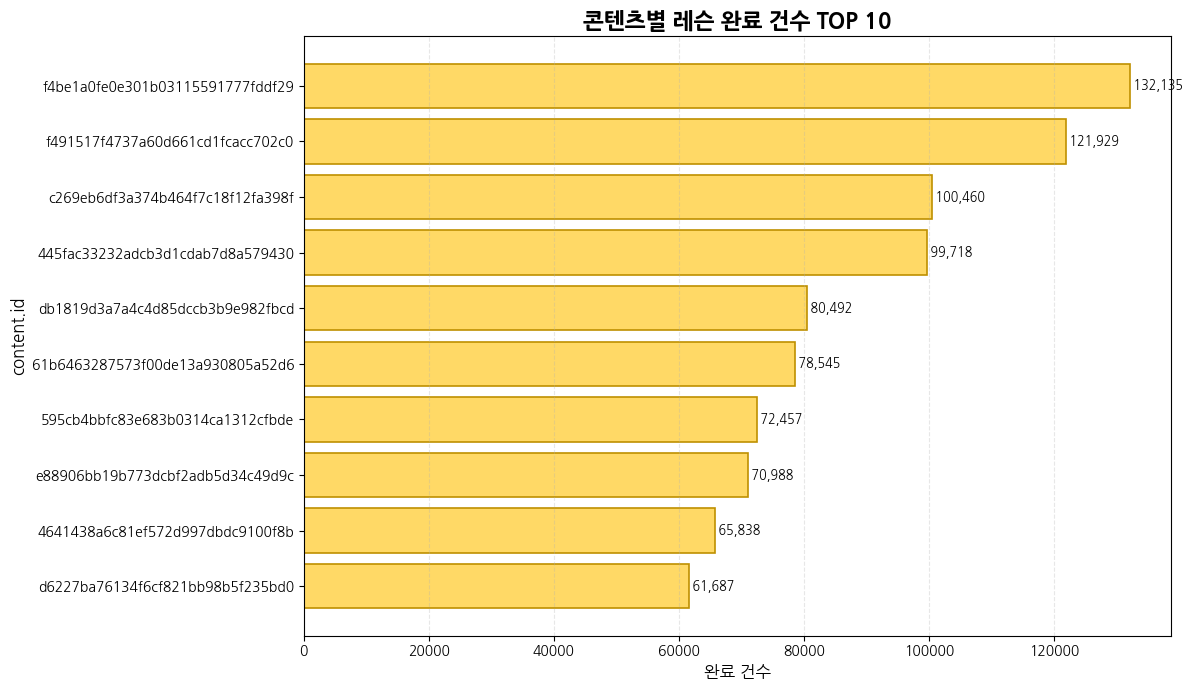

In [ ]:
content_top10 = (
    tmp.groupby("content.id")
       .size()
       .reset_index(name="완료건수")
       .sort_values("완료건수", ascending=False)
       .head(10)
)

display(content_top10)

plt.figure(figsize=(12, 7))
bars = plt.barh(
    content_top10["content.id"].astype(str),
    content_top10["완료건수"],
    color="#FFD966",
    edgecolor="#BF9000",
    linewidth=1.2
)

for bar in bars:
    w = bar.get_width()
    plt.text(
        w,
        bar.get_y() + bar.get_height() / 2,
        f" {int(w):,}",
        va="center",
        fontsize=9
    )

plt.title("콘텐츠별 레슨 완료 건수 TOP 10", fontsize=16, fontweight="bold")
plt.xlabel("완료 건수", fontsize=12)
plt.ylabel("content.id", fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## 핵심 분석 설계: 유저별 첫 완주 기준

한 명의 사용자는 여러 콘텐츠를 여러 번 시작하거나 완료할 수 있다.  
따라서 분석 단위를 단순 이벤트가 아니라 **유저별 첫 완주 콘텐츠 1건**으로 고정해야 한다.

이후에는 해당 콘텐츠의 **첫 시작 시점**과 **첫 완주 시점**을 연결하여,
유저가 처음 의미 있는 학습 성취를 경험하기까지 걸린 시간을 계산한다.


## 3. 유저별 첫 완주 콘텐츠 및 소요시간 계산

이 셀은 본 노트북의 핵심 계산 단계다.  
정제된 시작 이벤트와 완료 이벤트를 연결하여, **유저별 첫 완주 콘텐츠 1건**을 확정하고 그 콘텐츠의 **첫 시작 시점부터 첫 완주 시점까지의 경과 시간**을 계산한다.


In [ ]:
import numpy as np
import pandas as pd
# =========================================================
# 유저별 첫 완주 콘텐츠 기준
# "그 콘텐츠를 처음 시작한 시점부터 첫 완주까지" 소요시간 계산
# =========================================================
# ---------------------------------------------------------
# 0. 원본 복사 및 전처리
# ---------------------------------------------------------
start_df = df_start_content.copy()
end_df = df_end_content.copy()
# 시간형 변환
start_df["client_event_time"] = pd.to_datetime(start_df["client_event_time"], errors="coerce")
end_df["client_event_time"] = pd.to_datetime(end_df["client_event_time"], errors="coerce") # 필수값 결측 제거
start_df = start_df.dropna(subset=["user_id", "content.id", "client_event_time"]).copy()
end_df = end_df.dropna(subset=["user_id", "content.id", "client_event_time"]).copy()
# 자료형 통일
start_df["user_id"] = start_df["user_id"].astype(str)
start_df["content.id"] = start_df["content.id"].astype(str)
end_df["user_id"] = end_df["user_id"].astype(str)
end_df["content.id"] = end_df["content.id"].astype(str)
# 필요 시 event_type 필터링 #
start_df = start_df[start_df["event_type"] == "start.content"].copy()
end_df = end_df[end_df["event_type"] == "end.content"].copy()
# 컬럼명 변경
start_df = start_df.rename(columns={"client_event_time": "start_time"})
end_df = end_df.rename(columns={"client_event_time": "end_time"})
print("전처리 후 start 건수:", len(start_df))
print("전처리 후 end 건수:", len(end_df))
# ---------------------------------------------------------
# 1. user_id + content.id 기준 조인
# ---------------------------------------------------------
candidate = end_df[["user_id", "content.id", "end_time"]].merge( start_df[["user_id", "content.id", "start_time", "content.difficulty"]], on=["user_id", "content.id"], how="inner" )
print("조인 후 후보 건수:", len(candidate))
# ---------------------------------------------------------
# 2. 정상 후보만 남기기 # 시작이 완료보다 늦으면 비정상
# ---------------------------------------------------------
candidate = candidate[candidate["start_time"] <= candidate["end_time"]].copy()
print("정상 매칭 후보 건수:", len(candidate))
display(candidate.head())
# ---------------------------------------------------------
# 3. 유저별 첫 완주 시점(가장 빠른 end_time) 찾기
# ---------------------------------------------------------
first_end_per_user = ( candidate .groupby("user_id", as_index=False)["end_time"] .min() .rename(columns={"end_time": "first_end_time"}) )
print("유저별 첫 완주 시점 수:", len(first_end_per_user))
display(first_end_per_user.head())
# ---------------------------------------------------------
# 4. 첫 완주 시점에 해당하는 행만 남기기
# -> 여기서 첫 완주 콘텐츠 후보가 정해짐
# ---------------------------------------------------------
first_end_rows = candidate.merge( first_end_per_user, left_on=["user_id", "end_time"], right_on=["user_id", "first_end_time"], how="inner" )
print("첫 완주 시점 후보 행 수:", len(first_end_rows))
display(first_end_rows.head())
# ---------------------------------------------------------
# 5. 첫 완주 콘텐츠 1건 확정 # 같은 시각에 여러 콘텐츠가 있으면 content.id 기준으로 1건 고정
# ---------------------------------------------------------
first_completion_content = ( first_end_rows .sort_values(["user_id", "content.id"]) .drop_duplicates(subset=["user_id"], keep="first") [["user_id", "content.id", "first_end_time"]] .reset_index(drop=True) )
print("유저별 첫 완주 콘텐츠 수:", len(first_completion_content))
display(first_completion_content.head())
# ---------------------------------------------------------
# 6. 확정된 첫 완주 콘텐츠에 대해 # 첫 시작 시점(start_time 최소값) 찾기
# # ---------------------------------------------------------
chosen_rows = candidate.merge( first_completion_content, left_on=["user_id", "content.id", "end_time"], right_on=["user_id", "content.id", "first_end_time"], how="inner" )
first_start_per_completion = ( chosen_rows .groupby(["user_id", "content.id", "first_end_time", "content.difficulty"], as_index=False) ["start_time"] .min() )
print("최종 매칭 건수:", len(first_start_per_completion))
display(first_start_per_completion.head())
# ---------------------------------------------------------
# # 7. 첫 시작 ~ 첫 완주 소요시간 계산 # ---------------------------------------------------------
result = first_start_per_completion.copy()
result["duration_min"] = ( result["first_end_time"] - result["start_time"] ).dt.total_seconds() / 60
result["duration_days"] = result["duration_min"] / (60 * 24)
result["duration_day_label_num"] = ( np.ceil(result["duration_days"]) .clip(lower=1) .astype(int) )
result["duration_day_label"] = ( result["duration_day_label_num"].astype(str) + "일" )
result = result[ [ "user_id", "content.id", "content.difficulty", "start_time", "first_end_time", "duration_min", "duration_days", "duration_day_label" ] ].copy()
print("최종 결과 행 수:", len(result))
display(result.head())
# ---------------------------------------------------------
# 8. 요약 통계
# ---------------------------------------------------------
summary_first_complete = pd.DataFrame({ "지표": [ "유저별 첫 완주 매칭 건수", "평균 소요시간(분)", "평균 소요일수", "최소 소요일수", "최대 소요일수" ], "값": [ len(result), round(result["duration_min"].mean(), 2), round(result["duration_days"].mean(), 2), round(result["duration_days"].min(), 5), round(result["duration_days"].max(), 2), ] })
display(summary_first_complete)

전처리 후 start 건수: 74827
전처리 후 end 건수: 46359
조인 후 후보 건수: 26817
정상 매칭 후보 건수: 26776


,user_id,content.id,end_time,start_time,content.difficulty
0,0001f15911b404f3bf5b8571afafa4e4,61b6463287573f00de13a930805a52d6,2023-11-30 11:35:26,2023-11-29 10:14:22.988,beginner
1,0001f15911b404f3bf5b8571afafa4e4,f4be1a0fe0e301b03115591777fddf29,2023-11-29 10:04:46,2023-11-22 21:50:00.941,beginner
2,000be07bc09ceff42c11978f4a9f1c1a,ca35d0138a7550f002f975310604a9b7,2023-05-26 15:25:28,2023-05-23 13:14:30.009,beginner
3,001a8c6ed927bd4502bf67de0e0f181d,61b6463287573f00de13a930805a52d6,2023-08-23 20:04:38,2023-08-23 17:51:35.845,beginner
4,001a8c6ed927bd4502bf67de0e0f181d,f4be1a0fe0e301b03115591777fddf29,2023-08-25 19:46:46,2023-08-23 20:08:32.019,beginner


유저별 첫 완주 시점 수: 9236


,user_id,first_end_time
0,0001f15911b404f3bf5b8571afafa4e4,2023-11-29 10:04:46
1,000be07bc09ceff42c11978f4a9f1c1a,2023-05-26 15:25:28
2,001a8c6ed927bd4502bf67de0e0f181d,2023-08-23 20:04:38
3,002d6194ca671b8d14967f8e52c27052,2023-11-10 15:13:38
4,0031482d16469048027f6096d13c8b22,2023-09-18 10:29:26


첫 완주 시점 후보 행 수: 9241


...

최종 매칭 건수: 9236


,user_id,content.id,first_end_time,content.difficulty,start_time
0,0001f15911b404f3bf5b8571afafa4e4,f4be1a0fe0e301b03115591777fddf29,2023-11-29 10:04:46,beginner,2023-11-22 21:50:00.941
1,000be07bc09ceff42c11978f4a9f1c1a,ca35d0138a7550f002f975310604a9b7,2023-05-26 15:25:28,beginner,2023-05-23 13:14:30.009
2,001a8c6ed927bd4502bf67de0e0f181d,61b6463287573f00de13a930805a52d6,2023-08-23 20:04:38,beginner,2023-08-23 17:51:35.845
3,002d6194ca671b8d14967f8e52c27052,101e1d0dcc38d9c86156f008a145083e,2023-11-10 15:13:38,advanced,2023-11-07 14:18:17.835
4,0031482d16469048027f6096d13c8b22,c269eb6df3a374b464f7c18f12fa398f,2023-09-18 10:29:26,advanced,2023-09-11 10:31:49.936


최종 결과 행 수: 9236


,user_id,content.id,content.difficulty,start_time,first_end_time,duration_min,duration_days,duration_day_label
0,0001f15911b404f3bf5b8571afafa4e4,f4be1a0fe0e301b03115591777fddf29,beginner,2023-11-22 21:50:00.941,2023-11-29 10:04:46,9374.750983,6.510244,7일
1,000be07bc09ceff42c11978f4a9f1c1a,ca35d0138a7550f002f975310604a9b7,beginner,2023-05-23 13:14:30.009,2023-05-26 15:25:28,4450.966517,3.090949,4일
2,001a8c6ed927bd4502bf67de0e0f181d,61b6463287573f00de13a930805a52d6,beginner,2023-08-23 17:51:35.845,2023-08-23 20:04:38,133.035917,0.092386,1일
3,002d6194ca671b8d14967f8e52c27052,101e1d0dcc38d9c86156f008a145083e,advanced,2023-11-07 14:18:17.835,2023-11-10 15:13:38,4375.336083,3.038428,4일
4,0031482d16469048027f6096d13c8b22,c269eb6df3a374b464f7c18f12fa398f,advanced,2023-09-11 10:31:49.936,2023-09-18 10:29:26,10077.601067,6.998334,7일


,지표,값
0,유저별 첫 완주 매칭 건수,9236.00000
1,평균 소요시간(분),10247.59000
2,평균 소요일수,7.12000
3,최소 소요일수,0.00021
4,최대 소요일수,228.22000


## 3-1. 동일 시각 다중 첫 완주 후보 검증

간혹 한 유저의 가장 빠른 완료 시각에 여러 콘텐츠가 동시에 걸릴 수 있다.  
이 셀은 그런 tie case가 실제로 얼마나 존재하는지 점검해, 첫 완주 콘텐츠 확정 로직의 안정성을 확인하는 검증 단계다.


In [ ]:
# 같은 유저의 첫 완주 시각에 콘텐츠가 여러 개 겹치는지 확인
tie_check = (
    first_end_rows
    .groupby("user_id", as_index=False)
    .agg(first_completion_candidates=("content.id", "nunique"))
)

print("동일한 첫 완주 시각에 여러 콘텐츠가 있는 유저 수:",
      (tie_check["first_completion_candidates"] > 1).sum())

display(tie_check[tie_check["first_completion_candidates"] > 1].head(20))

동일한 첫 완주 시각에 여러 콘텐츠가 있는 유저 수: 0


,user_id,first_completion_candidates


## 4. 첫 완주 소요시간 구간화

계산된 `result`를 바탕으로 소요시간을 분 단위 구간으로 나누어 요약한다.  
이 단계는 사용자의 첫 완주가 얼마나 빠르게 발생하는지 보다 직관적으로 설명하기 위한 것이다.


In [ ]:
import numpy as np
import pandas as pd

# -----------------------------------
# result 기준 소요시간 구간 테이블
# -----------------------------------
time_table = result.copy()

# 분/시간 컬럼 추가
time_table["duration_hour"] = time_table["duration_min"] / 60

# 구간 정의
bins = [-np.inf, 1, 10, 30, 60, 360, 1440, 4320, 10080, np.inf]
labels = [
    "1분 미만",
    "1~10분",
    "10~30분",
    "30분~1시간",
    "1~6시간",
    "6~24시간",
    "1~3일",
    "3~7일",
    "7일 초과"
]

time_table["소요시간구간"] = pd.cut(
    time_table["duration_min"],
    bins=bins,
    labels=labels,
    right=False
)

# 구간별 요약 테이블
duration_summary = (
    time_table.groupby("소요시간구간", observed=False)
    .agg(
        유저수=("user_id", "nunique"),
        건수=("user_id", "size"),
        평균소요시간_분=("duration_min", "mean"),
        중앙소요시간_분=("duration_min", "median"),
        평균소요일수=("duration_days", "mean")
    )
    .reset_index()
)

duration_summary["비중(%)"] = (
    duration_summary["건수"] / duration_summary["건수"].sum() * 100
).round(2)

# 보기 좋게 반올림
duration_summary["평균소요시간_분"] = duration_summary["평균소요시간_분"].round(2)
duration_summary["중앙소요시간_분"] = duration_summary["중앙소요시간_분"].round(2)
duration_summary["평균소요일수"] = duration_summary["평균소요일수"].round(4)

display(duration_summary)

,소요시간구간,유저수,건수,평균소요시간_분,중앙소요시간_분,평균소요일수,비중(%)
0,1분 미만,6,6,0.75,0.81,0.0005,0.06
1,1~10분,143,143,5.23,4.74,0.0036,1.55
2,10~30분,317,317,20.43,20.91,0.0142,3.43
3,30분~1시간,790,790,46.09,46.65,0.0320,8.55
4,1~6시간,2110,2110,141.00,114.05,0.0979,22.85
5,6~24시간,1203,1203,939.11,996.25,0.6522,13.03
6,1~3일,1587,1587,2552.73,2639.21,1.7727,17.18
7,3~7일,1214,1214,6787.10,6509.64,4.7133,13.14
8,7일 초과,1866,1866,43346.79,24562.50,30.1019,20.20


## 4-1. 1분 미만 구간 샘플 점검

소요시간이 매우 짧은 사례를 직접 확인하는 셀이다.  
이상치인지, 실제로 매우 빠른 완주 사례인지 판단하기 위한 품질 검토용 샘플 조회다.


In [ ]:
time_table[time_table["소요시간구간"] == "1분 미만"].sort_values("duration_min").head(20)

,user_id,content.id,content.difficulty,start_time,first_end_time,duration_min,duration_days,duration_day_label,duration_hour,소요시간구간
2055,38f4a0b5485059b62cee12fb02b1e0cf,b8e55a7d179c5ae033dbc04062ed5fa4,intermediate,2023-05-25 02:25:55.189,2023-05-25 02:26:13,0.296850,0.000206,1일,0.004947,1분 미만
5501,98b3d3a6a467426ccc69e39e77d37bcf,6c1ab2ac2b70a203dad068301a9152a4,beginner,2023-09-05 09:35:47.711,2023-09-05 09:36:29,0.688150,0.000478,1일,0.011469,1분 미만
1542,2b238df192eed6fa94ec32d166cb91a7,ca35d0138a7550f002f975310604a9b7,beginner,2023-11-17 16:06:08.896,2023-11-17 16:06:52,0.718400,0.000499,1일,0.011973,1분 미만
1936,359e247f13a386ec0901463b5812c3a1,61b6463287573f00de13a930805a52d6,beginner,2023-06-30 19:18:46.948,2023-06-30 19:19:41,0.900867,0.000626,1일,0.015014,1분 미만
2194,3cf9c009fbaeb839c6e0e2c2c868d6de,61b6463287573f00de13a930805a52d6,beginner,2023-12-06 19:11:15.145,2023-12-06 19:12:11,0.930917,0.000646,1일,0.015515,1분 미만
5271,92b37971a45e25d050ed996057c30746,235c5afae879c3a87ba07e7a465240f8,intermediate,2023-06-28 19:48:50.836,2023-06-28 19:49:47,0.936067,0.000650,1일,0.015601,1분 미만


## 4-2. 1~10분 구간 샘플 점검

짧은 시간 내 완주한 사례를 몇 건 직접 살펴본다.  
이 셀은 극단값이 아닌 빠른 완주 패턴이 실제로 존재하는지 확인하는 보조 검토용이다.


In [ ]:
time_table[time_table["소요시간구간"] == "1~10분"].sort_values("duration_min").head(20)

,user_id,content.id,content.difficulty,start_time,first_end_time,duration_min,duration_days,duration_day_label,duration_hour,소요시간구간
8632,ef2ce8e3f7bf0db6547e837154b5d14b,ed88bded4d552a42b70b65cf09e3943a,intermediate,2023-12-30 10:28:47.882,2023-12-30 10:29:54,1.101967,0.000765,1일,0.018366,1~10분
8089,e0d62180f72e5b7384a1c525b63a5be3,ed88bded4d552a42b70b65cf09e3943a,intermediate,2023-12-31 22:39:38.312,2023-12-31 22:40:50,1.194800,0.000830,1일,0.019913,1~10분
5580,9ad5ef0e2eb7ba675957d815efde96ff,45d3eda4b13093cee31036a32bc4a9b5,beginner,2023-12-20 03:21:15.793,2023-12-20 03:22:32,1.270117,0.000882,1일,0.021169,1~10분
1518,2a6515b8abc4e35e8d6e07778b8c9117,ed88bded4d552a42b70b65cf09e3943a,intermediate,2023-12-31 14:18:25.109,2023-12-31 14:19:53,1.464850,0.001017,1일,0.024414,1~10분
8283,e6189d679b1c6f5c5d42ce3a4f0d8e12,61b6463287573f00de13a930805a52d6,beginner,2023-11-15 05:59:41.072,2023-11-15 06:01:19,1.632133,0.001133,1일,0.027202,1~10분
955,1a379548fb316eb12582753011612562,0ab2b890d4068c1490b89676773256f6,intermediate,2023-11-12 02:54:57.160,2023-11-12 02:56:36,1.647333,0.001144,1일,0.027456,1~10분
1389,26fdb4a794e56abdd05464c6dead4438,3ca120746c79812b35a345a8a509b5ba,advanced,2023-05-01 00:05:21.722,2023-05-01 00:07:09,1.787967,0.001242,1일,0.029799,1~10분
7066,c3d86f64c3350448c42d7ce7ec84f084,61b6463287573f00de13a930805a52d6,beginner,2023-06-21 09:38:42.606,2023-06-21 09:40:32,1.823233,0.001266,1일,0.030387,1~10분
3044,5478558b226a2d853986d126e9f99834,61b6463287573f00de13a930805a52d6,beginner,2023-08-18 09:37:02.165,2023-08-18 09:39:01,1.980583,0.001375,1일,0.033010,1~10분
2603,48078a55fde9f4a3732d615017ee719f,f4be1a0fe0e301b03115591777fddf29,beginner,2023-12-21 18:35:12.155,2023-12-21 18:37:15,2.047417,0.001422,1일,0.034124,1~10분


## 4-3. 7일 초과 구간 샘플 점검

오랜 시간이 걸린 첫 완주 사례를 직접 확인한다.  
이 구간은 초기 학습 마찰, 재방문 지연, 장기 보관 후 완주 등의 가능성을 생각해볼 수 있는 사례군이다.


In [ ]:
time_table[time_table["소요시간구간"] == "7일 초과"].sort_values("duration_min", ascending=False).head(20)

,user_id,content.id,content.difficulty,start_time,first_end_time,duration_min,duration_days,duration_day_label,duration_hour,소요시간구간
7052,c3a1266e34a59d4aed315887c2351e34,61b6463287573f00de13a930805a52d6,beginner,2023-05-02 17:36:27.512,2023-12-16 22:54:46,328638.308133,228.221047,229일,5477.305136,7일 초과
7453,cf682a0092abd270408d3cae4bf9289b,ca35d0138a7550f002f975310604a9b7,beginner,2023-05-15 18:03:22.517,2023-12-17 12:21:09,310697.774717,215.762344,216일,5178.296245,7일 초과
7671,d58c45122044c1347403bfc0ad28261c,f4be1a0fe0e301b03115591777fddf29,beginner,2023-06-10 14:55:21.581,2023-12-23 16:59:38,282364.273650,196.086301,197일,4706.071227,7일 초과
1061,1d4741897931b5ccf9f481847aa4fd95,68a3658f1b936bfff3bd6960cd561b0a,beginner,2023-05-29 21:52:24.949,2023-12-06 11:44:05,274431.667517,190.577547,191일,4573.861125,7일 초과
859,16eb12b954cb35dd5b18ac45b2ee5b75,4641438a6c81ef572d997dbdc9100f8b,intermediate,2023-05-09 18:40:38.600,2023-11-16 01:28:39,274008.006667,190.283338,191일,4566.800111,7일 초과
4771,85182926c1506e41c7278618712a04f1,f4be1a0fe0e301b03115591777fddf29,beginner,2023-06-05 23:37:49.841,2023-12-09 23:18:28,269260.635983,186.986553,187일,4487.677266,7일 초과
7466,cfc469518958dcaa4b832a18dfb71932,445fac33232adcb3d1cdab7d8a579430,beginner,2023-05-10 14:49:18.447,2023-11-07 17:09:10,260779.859217,181.097124,182일,4346.330987,7일 초과
8035,df7eec6936f50cad465377b880d46461,b314d5aba64a0aab40602cb72a4a1504,intermediate,2023-05-24 14:27:03.683,2023-11-20 13:17:56,259130.871950,179.951994,180일,4318.847866,7일 초과
373,09ff433521ff5120c2d8579a43a529d7,f491517f4737a60d661cd1fcacc702c0,intermediate,2023-05-20 15:24:32.236,2023-11-12 15:39:30,253454.962733,176.010391,177일,4224.249379,7일 초과
5415,9687720c687bfb2116d7a24638c6ae28,ca35d0138a7550f002f975310604a9b7,beginner,2023-06-26 15:28:15.870,2023-12-18 16:59:16,252091.002167,175.063196,176일,4201.516703,7일 초과


## 5. 일 단위 구간으로 다시 요약

마지막으로 분 단위가 아닌 **일 단위 구간**으로 재요약한다.  
발표에서는 `1일 이내`, `1~3일`, `3~7일`처럼 더 직관적인 구간이 전달력이 높기 때문에 이 테이블이 결론용으로 특히 유용하다.


In [ ]:
day_table = result.copy()

# 혹시 이상치 있으면 먼저 확인
day_table = day_table[day_table["duration_min"].notna()].copy()

hour_bins = [-np.inf, 180, 360, 720, 1440, 4320, 10080, 20160, 43200, np.inf]
hour_labels = [
    "3시간미만",
    "3~6시간",
    "6~12시간",
    "12~24시간",
    "1~3일",
    "3~7일",
    "7~14일",
    "14~30일",
    "30일 초과"
]

day_table["소요일구간_세분화"] = pd.cut(
    day_table["duration_min"],
    bins=hour_bins,
    labels=hour_labels,
    right=False
)

day_summary_fine = (
    day_table.groupby("소요일구간_세분화", observed=False)
    .agg(
        유저수=("user_id", "nunique"),
        건수=("user_id", "size"),
        평균소요시간_분=("duration_min", "mean"),
        평균소요일수=("duration_days", "mean")
    )
    .reset_index()
)

day_summary_fine["비중(%)"] = (
    day_summary_fine["건수"] / day_summary_fine["건수"].sum() * 100
).round(2)

day_summary_fine["평균소요시간_분"] = day_summary_fine["평균소요시간_분"].round(2)
day_summary_fine["평균소요일수"] = day_summary_fine["평균소요일수"].round(2)

display(day_summary_fine)

,소요일구간_세분화,유저수,건수,평균소요시간_분,평균소요일수,비중(%)
0,3시간미만,2829,2829,72.18,0.05,30.63
1,3~6시간,537,537,255.04,0.18,5.81
2,6~12시간,397,397,511.97,0.36,4.30
3,12~24시간,806,806,1149.50,0.80,8.73
4,1~3일,1587,1587,2552.73,1.77,17.18
5,3~7일,1214,1214,6787.10,4.71,13.14
6,7~14일,737,737,14527.15,10.09,7.98
7,14~30일,605,605,29334.73,20.37,6.55
8,30일 초과,524,524,100059.31,69.49,5.67


## 5-1. 소요일 구간별 시각화

앞서 계산한 일 단위 구간 요약표를 시각화하여,
사용자가 첫 콘텐츠를 얼마나 빠르게 완주하는지 직관적으로 확인한다.

특히 `1일 이내`, `1~3일`, `3~7일` 구간의 비중을 비교하면
초기 학습 경험이 얼마나 빠르게 완주로 이어지는지 파악할 수 있다.

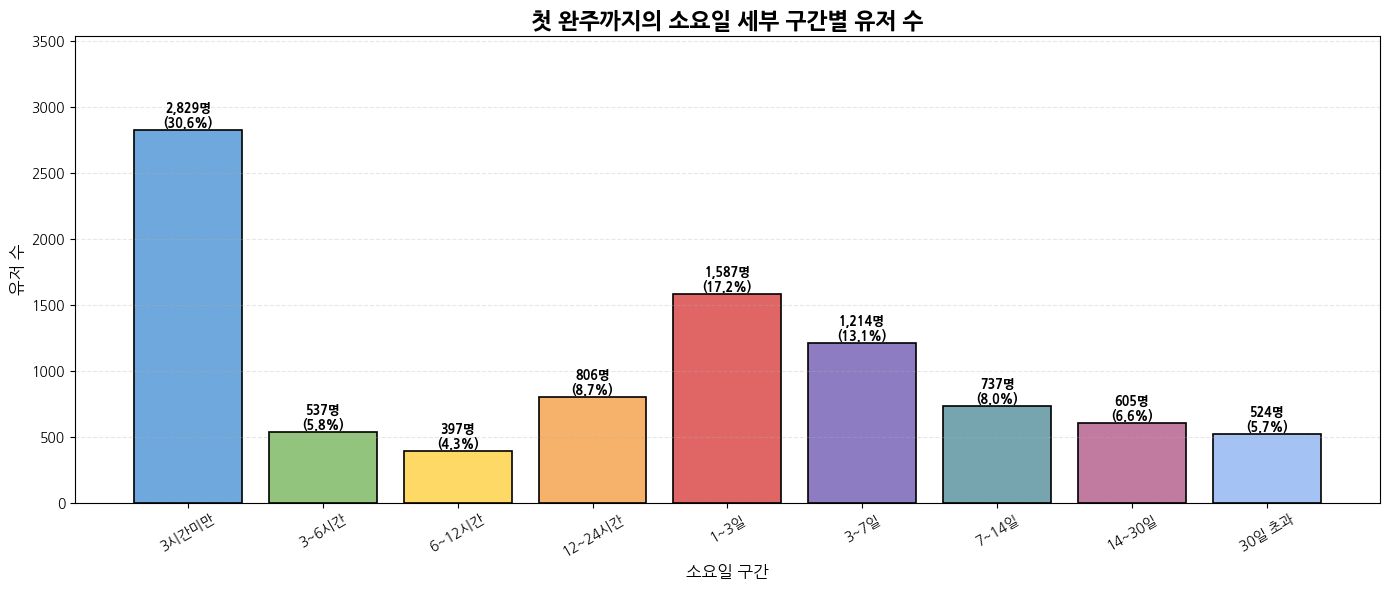

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

plot_df = day_summary_fine.copy()

# 유저수 기준 비율 계산
plot_df["유저수비율(%)"] = plot_df["유저수"] / plot_df["유저수"].sum() * 100

plt.figure(figsize=(14, 6))
bars = plt.bar(
    plot_df["소요일구간_세분화"].astype(str),
    plot_df["유저수"],
    color=[
        "#6FA8DC", "#93C47D", "#FFD966", "#F6B26B", "#E06666",
        "#8E7CC3", "#76A5AF", "#C27BA0", "#A4C2F4", "#B6D7A8"
    ][:len(plot_df)],
    edgecolor="black",
    linewidth=1.2
)

# 막대 위에 유저수 + 비율 표시
for bar, user_cnt, pct in zip(bars, plot_df["유저수"], plot_df["유저수비율(%)"]):
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{int(user_cnt):,}명\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title("첫 완주까지의 소요일 세부 구간별 유저 수", fontsize=16, fontweight="bold")
plt.xlabel("소요일 구간", fontsize=12)
plt.ylabel("유저 수", fontsize=12)
plt.xticks(rotation=30)
plt.ylim(0, plot_df["유저수"].max() * 1.25)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## 정리

이 노트북의 핵심 메시지는 다음과 같다.

- 첫 완주는 유저 초기 학습 여정에서 의미 있는 전환 행동이다.
- 첫 완주까지 걸린 시간은 초기 경험의 마찰 정도를 보여주는 지표다.
- 특히 **빠른 첫 완주 경험**은 이후 리텐션·재방문·결제와 연결된다면 Aha Moment 후보 지표로 확장할 수 있다.


## 미완료 학습 시도 시각화

start_content에는 기록이 있으나 end_content에는 대응 기록이 없는 경우를 추출하여,
시작 이후 완료로 이어지지 않은 학습 시도를 별도로 확인하였다.

이때 동일 유저-콘텐츠 쌍의 반복 시작 기록이 해석을 왜곡하지 않도록,
시각화는 각 유저-콘텐츠의 첫 시작 기록 기준으로 집계하였다.

이를 통해 난이도별, 월별, 콘텐츠별로
어디에서 미완료가 많이 발생하는지 확인할 수 있다.

In [ ]:
start = df_start_content.copy()
end = df_end_content.copy()

start["client_event_time"] = pd.to_datetime(start["client_event_time"], errors="coerce")
end["client_event_time"] = pd.to_datetime(end["client_event_time"], errors="coerce")

start = start.dropna(subset=["user_id", "content.id"])
end = end.dropna(subset=["user_id", "content.id"])

start_keys = start[["user_id", "content.id"]].drop_duplicates()
end_keys = end[["user_id", "content.id"]].drop_duplicates()

not_completed_keys = (
    start_keys.merge(
        end_keys,
        on=["user_id", "content.id"],
        how="left",
        indicator=True
    )
    .query("_merge == 'left_only'")
    [["user_id", "content.id"]]
    .copy()
)

not_completed_start_detail = (
    not_completed_keys.merge(start, on=["user_id", "content.id"], how="left")
    .sort_values(["user_id", "content.id", "client_event_time"])
)

print("전체 시작 user-content 수:", len(start_keys))
print("미완료 user-content 수:", len(not_completed_keys))
print("미완료 비율: {:.2f}%".format(len(not_completed_keys) / len(start_keys) * 100))
print("미완료 유저 수:", not_completed_keys["user_id"].nunique())

display(not_completed_start_detail.head(20))

전체 시작 user-content 수: 74737
미완료 user-content 수: 48047
미완료 비율: 64.29%
미완료 유저 수: 30365


,user_id,content.id,event_type,content.difficulty,client_event_time
0,000087537cbfd934375364218ff10f91,0ab2b890d4068c1490b89676773256f6,start.content,intermediate,2023-05-01 19:31:15.918
1,0001f15911b404f3bf5b8571afafa4e4,c8e53577758bf66711094352a5abd8c3,start.content,intermediate,2023-11-30 11:35:37.133
2,0003b028a745bdfda9e88539424248af,c269eb6df3a374b464f7c18f12fa398f,start.content,advanced,2023-06-24 15:11:41.788
3,000509014329002768958b9210789b4b,61b6463287573f00de13a930805a52d6,start.content,beginner,2023-09-15 02:24:18.795
4,000634ec5553ca63f77c61690353a0be,445fac33232adcb3d1cdab7d8a579430,start.content,beginner,2023-05-26 15:06:18.682
5,000a2230b80d8366158b71d7610836c7,f4be1a0fe0e301b03115591777fddf29,start.content,beginner,2023-08-29 12:55:48.736
6,000ad2412e2ced1b030a32089d794f5d,f4be1a0fe0e301b03115591777fddf29,start.content,beginner,2023-10-31 04:12:47.585
7,000be07bc09ceff42c11978f4a9f1c1a,c269eb6df3a374b464f7c18f12fa398f,start.content,advanced,2023-09-22 13:49:45.636
8,000cc51c9fbd26ca926e42f6712270ba,61b6463287573f00de13a930805a52d6,start.content,beginner,2023-11-11 15:17:15.847
9,000e0489901491b13ede9d670c7d0164,f4be1a0fe0e301b03115591777fddf29,start.content,beginner,2023-08-18 09:22:43.219


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

# -----------------------------
# 시각화용 기준 테이블 만들기
# -----------------------------
start = df_start_content.copy()
start["client_event_time"] = pd.to_datetime(start["client_event_time"], errors="coerce")
start = start.dropna(subset=["user_id", "content.id", "client_event_time"])

# not_completed_keys가 이미 있다고 가정
# (start에는 있는데 end에는 없는 user_id + content.id)
first_not_completed_start = (
    not_completed_keys
    .merge(start, on=["user_id", "content.id"], how="left")
    .sort_values(["user_id", "content.id", "client_event_time"])
    .groupby(["user_id", "content.id"], as_index=False)
    .first()
)

# 파생 컬럼
first_not_completed_start["year_month"] = (
    first_not_completed_start["client_event_time"].dt.to_period("M").astype(str)
)

first_not_completed_start["난이도"] = (
    first_not_completed_start["content.difficulty"]
    .fillna("Unknown")
    .astype(str)
)

print("미완료 user-content 수:", len(first_not_completed_start))
display(first_not_completed_start.head())

미완료 user-content 수: 48047


,user_id,content.id,event_type,content.difficulty,client_event_time,year_month,난이도
0,000087537cbfd934375364218ff10f91,0ab2b890d4068c1490b89676773256f6,start.content,intermediate,2023-05-01 19:31:15.918,2023-05,intermediate
1,0001f15911b404f3bf5b8571afafa4e4,c8e53577758bf66711094352a5abd8c3,start.content,intermediate,2023-11-30 11:35:37.133,2023-11,intermediate
2,0003b028a745bdfda9e88539424248af,c269eb6df3a374b464f7c18f12fa398f,start.content,advanced,2023-06-24 15:11:41.788,2023-06,advanced
3,000509014329002768958b9210789b4b,61b6463287573f00de13a930805a52d6,start.content,beginner,2023-09-15 02:24:18.795,2023-09,beginner
4,000634ec5553ca63f77c61690353a0be,445fac33232adcb3d1cdab7d8a579430,start.content,beginner,2023-05-26 15:06:18.682,2023-05,beginner


,난이도,유저콘텐츠수,비중(%)
0,beginner,28122,58.530189
1,intermediate,9946,20.700564
2,advanced,8998,18.727496
3,hard,981,2.041751


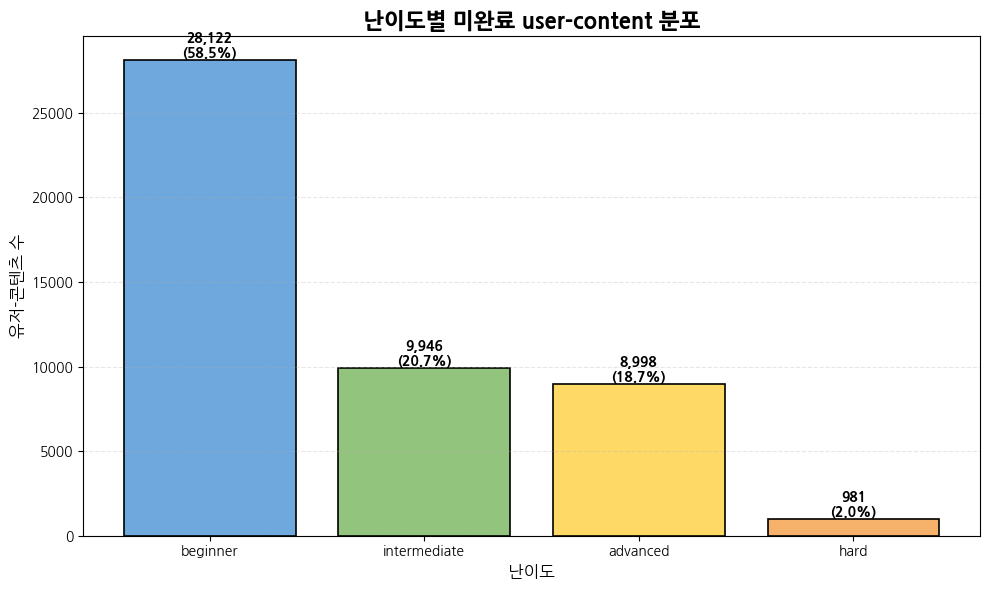

In [ ]:
# -----------------------------
# 난이도별 미완료 user-content 수
# -----------------------------
diff_summary = (
    first_not_completed_start["난이도"]
    .value_counts(dropna=False)
    .sort_values(ascending=False)
    .rename_axis("난이도")
    .reset_index(name="유저콘텐츠수")
)

diff_summary["비중(%)"] = diff_summary["유저콘텐츠수"] / diff_summary["유저콘텐츠수"].sum() * 100

display(diff_summary)

plt.figure(figsize=(10, 6))
bars = plt.bar(
    diff_summary["난이도"],
    diff_summary["유저콘텐츠수"],
    color=["#6FA8DC", "#93C47D", "#FFD966", "#F6B26B", "#E06666", "#8E7CC3"][:len(diff_summary)],
    edgecolor="black",
    linewidth=1.2
)

for bar, cnt, pct in zip(bars, diff_summary["유저콘텐츠수"], diff_summary["비중(%)"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{cnt:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("난이도별 미완료 user-content 분포", fontsize=16, fontweight="bold")
plt.xlabel("난이도", fontsize=12)
plt.ylabel("유저-콘텐츠 수", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

,year_month,유저콘텐츠수
0,2023-05,5621
1,2023-06,5201
2,2023-07,6836
3,2023-08,6487
4,2023-09,5339


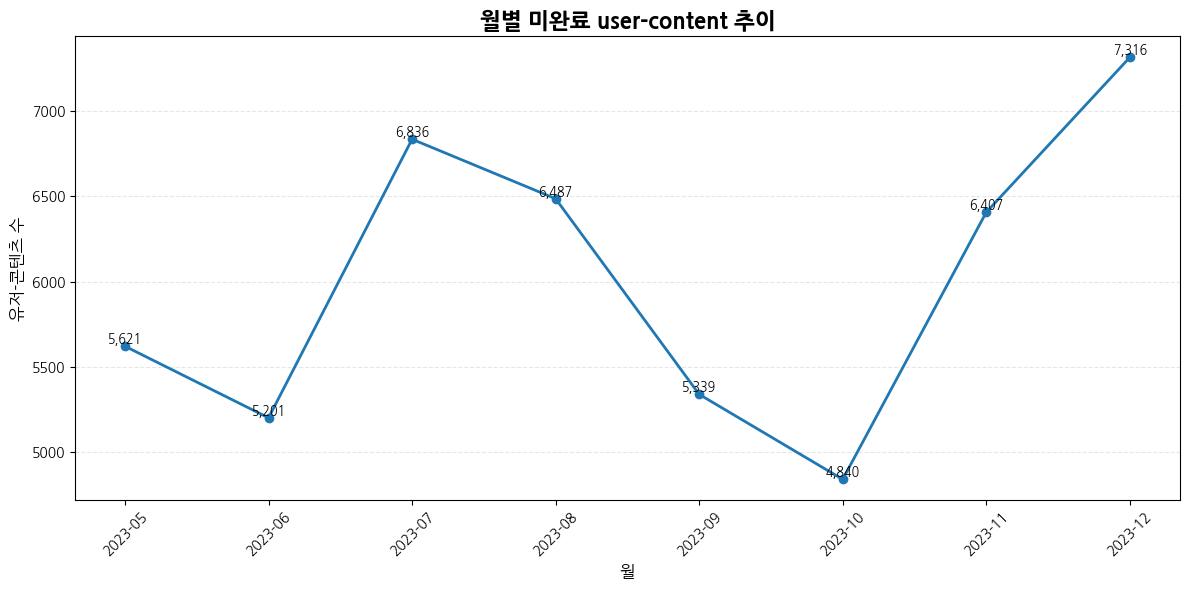

In [ ]:
# -----------------------------
# 월별 미완료 user-content 수
# -----------------------------
monthly_summary = (
    first_not_completed_start
    .groupby("year_month", observed=False)
    .size()
    .reset_index(name="유저콘텐츠수")
    .sort_values("year_month")
)

display(monthly_summary.head())

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_summary["year_month"],
    monthly_summary["유저콘텐츠수"],
    marker="o",
    linewidth=2
)

for x, y in zip(monthly_summary["year_month"], monthly_summary["유저콘텐츠수"]):
    plt.text(x, y, f"{y:,}", ha="center", va="bottom", fontsize=9)

plt.title("월별 미완료 user-content 추이", fontsize=16, fontweight="bold")
plt.xlabel("월", fontsize=12)
plt.ylabel("유저-콘텐츠 수", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

난이도,advanced,beginner,hard,intermediate
year_month,,,,
2023-05,1061,3405,121,1034
2023-06,915,3295,59,932
2023-07,1344,3881,109,1502
2023-08,1352,3433,159,1543
2023-09,1053,2872,116,1298


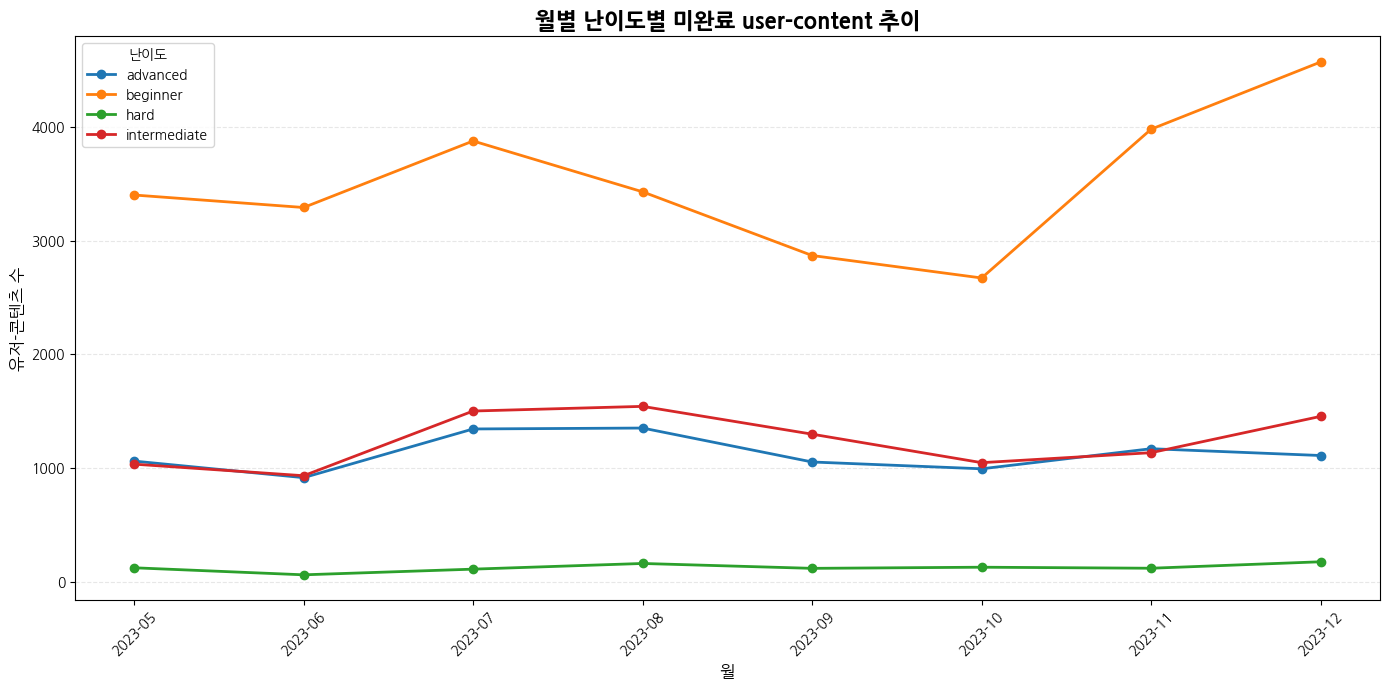

In [ ]:
# -----------------------------
# 월별 × 난이도별 미완료 추이
# -----------------------------
monthly_diff = (
    first_not_completed_start
    .groupby(["year_month", "난이도"], observed=False)
    .size()
    .reset_index(name="유저콘텐츠수")
)

pivot_monthly_diff = (
    monthly_diff
    .pivot(index="year_month", columns="난이도", values="유저콘텐츠수")
    .fillna(0)
    .sort_index()
)

display(pivot_monthly_diff.head())

plt.figure(figsize=(14, 7))

for col in pivot_monthly_diff.columns:
    plt.plot(
        pivot_monthly_diff.index,
        pivot_monthly_diff[col],
        marker="o",
        linewidth=2,
        label=col
    )

plt.title("월별 난이도별 미완료 user-content 추이", fontsize=16, fontweight="bold")
plt.xlabel("월", fontsize=12)
plt.ylabel("유저-콘텐츠 수", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="난이도")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

,content.id,유저콘텐츠수
0,f4be1a0fe0e301b03115591777fddf29,14819
1,61b6463287573f00de13a930805a52d6,6765
2,445fac33232adcb3d1cdab7d8a579430,2513
3,68a3658f1b936bfff3bd6960cd561b0a,1864
4,c269eb6df3a374b464f7c18f12fa398f,1747
5,ca35d0138a7550f002f975310604a9b7,1592
6,f491517f4737a60d661cd1fcacc702c0,886
7,595cb4bbfc83e683b0314ca1312cfbde,838
8,b314d5aba64a0aab40602cb72a4a1504,779
9,d6227ba76134f6cf821bb98b5f235bd0,764


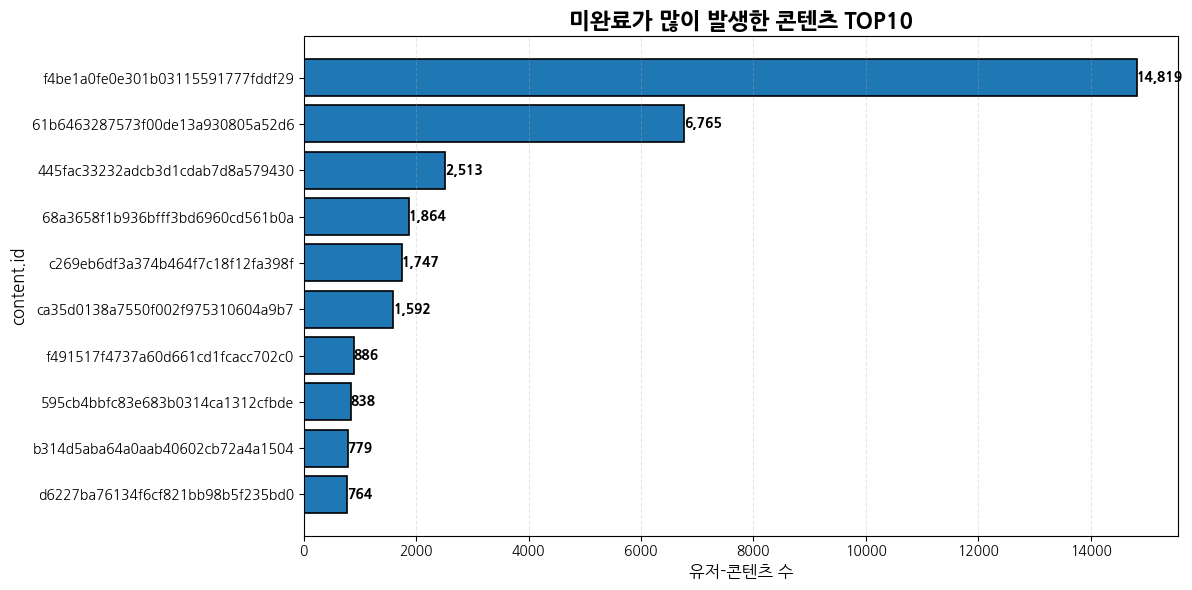

In [ ]:
# -----------------------------
# 미완료 콘텐츠 TOP10
# -----------------------------
top_content = (
    first_not_completed_start["content.id"]
    .astype(str)
    .value_counts()
    .head(10)
    .rename_axis("content.id")
    .reset_index(name="유저콘텐츠수")
)

display(top_content)

plt.figure(figsize=(12, 6))
bars = plt.barh(
    top_content["content.id"],
    top_content["유저콘텐츠수"],
    edgecolor="black",
    linewidth=1.2
)

for bar, val in zip(bars, top_content["유저콘텐츠수"]):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{val:,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("미완료가 많이 발생한 콘텐츠 TOP10", fontsize=16, fontweight="bold")
plt.xlabel("유저-콘텐츠 수", fontsize=12)
plt.ylabel("content.id", fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### 해석

미완료 user-content를 시각화한 결과,
특정 난이도 또는 특정 시점에 시작 후 완료로 이어지지 않은 학습 시도가 상대적으로 많이 발생하는지 확인할 수 있었다.

이는 단순한 학습 시작 수 증가뿐 아니라,
콘텐츠 난이도, 학습 피로도, 진입 후 이탈 등의 요인으로 인해
완료 전 이탈이 발생할 가능성을 시사한다.

따라서 미완료 구간은 Aha Moment 이전의 마찰 구간으로 해석할 수 있으며,
향후 완주 전환율 개선 대상 구간으로 활용할 수 있다.

In [ ]:
import numpy as np
import pandas as pd

# =========================================================
# 유저별 첫 완주 경험 기준 최종 테이블
# - start_content / end_content만 사용
# - 첫완주전_시작시도횟수 제외
# - 첫완주까지_소요일수 = 올림 정수(1일, 2일, 3일 ...)
# =========================================================

# ---------------------------------------------------------
# 0. 원본 복사
# 가능하면 3초 중복 제거본 사용 권장
# ---------------------------------------------------------
start_df = df_start_content.copy()
end_df = df_end_content.copy()

# ---------------------------------------------------------
# 1. 전처리
# ---------------------------------------------------------
start_df["client_event_time"] = pd.to_datetime(start_df["client_event_time"], errors="coerce")
end_df["client_event_time"] = pd.to_datetime(end_df["client_event_time"], errors="coerce")

start_df = start_df.dropna(subset=["user_id", "content.id", "client_event_time"]).copy()
end_df = end_df.dropna(subset=["user_id", "content.id", "client_event_time"]).copy()

start_df["user_id"] = start_df["user_id"].astype(str)
start_df["content.id"] = start_df["content.id"].astype(str)
end_df["user_id"] = end_df["user_id"].astype(str)
end_df["content.id"] = end_df["content.id"].astype(str)

if "event_type" in start_df.columns:
    start_df = start_df[start_df["event_type"] == "start.content"].copy()

if "event_type" in end_df.columns:
    end_df = end_df[end_df["event_type"] == "end.content"].copy()

start_df = start_df.rename(columns={
    "client_event_time": "시작시각",
    "content.difficulty": "콘텐츠난이도"
})

end_df = end_df.rename(columns={
    "client_event_time": "완료시각"
})

print("전처리 후 start 건수:", len(start_df))
print("전처리 후 end 건수:", len(end_df))

# ---------------------------------------------------------
# 2. start/end 후보 조인
# ---------------------------------------------------------
candidate = end_df[["user_id", "content.id", "완료시각"]].merge(
    start_df[["user_id", "content.id", "시작시각", "콘텐츠난이도"]],
    on=["user_id", "content.id"],
    how="inner"
)

# 정상 후보만 유지
candidate = candidate[candidate["시작시각"] <= candidate["완료시각"]].copy()

print("정상 매칭 후보 건수:", len(candidate))

# ---------------------------------------------------------
# 3. 유저별 첫 완주 시각
# ---------------------------------------------------------
first_end_per_user = (
    candidate
    .groupby("user_id", as_index=False)["완료시각"]
    .min()
    .rename(columns={"완료시각": "첫완주시각"})
)

# ---------------------------------------------------------
# 4. 첫 완주 시각에 해당하는 콘텐츠 후보
# 같은 시각에 여러 콘텐츠면 content.id 오름차순 1건 고정
# ---------------------------------------------------------
first_end_rows = candidate.merge(
    first_end_per_user,
    left_on=["user_id", "완료시각"],
    right_on=["user_id", "첫완주시각"],
    how="inner"
)

first_completion_content = (
    first_end_rows
    .sort_values(["user_id", "content.id"])
    .drop_duplicates(subset=["user_id"], keep="first")
    [["user_id", "content.id", "첫완주시각"]]
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# 5. 확정된 첫 완주 콘텐츠의 최초 시작 시각
# ---------------------------------------------------------
chosen_rows = candidate.merge(
    first_completion_content,
    left_on=["user_id", "content.id", "완료시각"],
    right_on=["user_id", "content.id", "첫완주시각"],
    how="inner"
)

base = (
    chosen_rows
    .groupby(["user_id", "content.id", "첫완주시각", "콘텐츠난이도"], as_index=False)["시작시각"]
    .min()
    .rename(columns={
        "content.id": "첫완주콘텐츠_id",
        "시작시각": "첫완주콘텐츠_최초시작시각",
        "콘텐츠난이도": "첫완주콘텐츠_난이도"
    })
)

# ---------------------------------------------------------
# 6. 소요시간 계산
# ---------------------------------------------------------
base["첫완주까지_소요분"] = (
    base["첫완주시각"] - base["첫완주콘텐츠_최초시작시각"]
).dt.total_seconds() / 60

base["첫완주까지_소요시간"] = base["첫완주까지_소요분"] / 60
base["첫완주까지_실제소요일수"] = base["첫완주까지_소요분"] / (60 * 24)

# 보고용: 올림 정수 일수
# 예) 0.2일 -> 1일, 1.0일 -> 1일, 1.01일 -> 2일
base["첫완주까지_소요일수"] = (
    np.ceil(base["첫완주까지_실제소요일수"])
    .clip(lower=1)
    .astype(int)
)

base["첫완주까지_소요시간"] = base["첫완주까지_소요시간"].round(2)
base["첫완주까지_실제소요일수"] = base["첫완주까지_실제소요일수"].round(4)

# ---------------------------------------------------------
# 7. 소요구간 라벨
# ---------------------------------------------------------
time_bins = [0, 180, 360, 720, 1440, 4320, 10080, 20160, 43200, np.inf]
time_labels = [
    "3시간미만",
    "3~6시간",
    "6~12시간",
    "12~24시간",
    "1~3일",
    "3~7일",
    "7~14일",
    "14~30일",
    "30일 초과"
]

base["첫완주까지_소요구간"] = pd.cut(
    base["첫완주까지_소요분"],
    bins=time_bins,
    labels=time_labels,
    right=False,
    include_lowest=True
)

# ---------------------------------------------------------
# 8. 24시간 / 7일 이내 첫 완주 여부
# ---------------------------------------------------------
base["첫완주_24시간이내여부"] = (
    base["첫완주시각"] <= base["첫완주콘텐츠_최초시작시각"] + pd.Timedelta(days=1)
)

base["첫완주_7일이내여부"] = (
    base["첫완주시각"] <= base["첫완주콘텐츠_최초시작시각"] + pd.Timedelta(days=7)
)

# ---------------------------------------------------------
# 9. 유저별 전체 완주 콘텐츠 수
# ---------------------------------------------------------
user_total_completed = (
    end_df
    .groupby("user_id", as_index=False)["content.id"]
    .nunique()
    .rename(columns={"content.id": "유저별_전체완주콘텐츠수"})
)

# ---------------------------------------------------------
# 10. 첫 시작 후 7일 내 완주 콘텐츠 수
# ---------------------------------------------------------
end_in_7d = base[["user_id", "첫완주콘텐츠_최초시작시각"]].merge(
    end_df[["user_id", "content.id", "완료시각"]],
    on="user_id",
    how="left"
)

end_in_7d = end_in_7d[
    (end_in_7d["완료시각"] >= end_in_7d["첫완주콘텐츠_최초시작시각"]) &
    (end_in_7d["완료시각"] <= end_in_7d["첫완주콘텐츠_최초시작시각"] + pd.Timedelta(days=7))
].copy()

user_completed_7d = (
    end_in_7d
    .groupby("user_id", as_index=False)["content.id"]
    .nunique()
    .rename(columns={"content.id": "첫시작후7일내_완주콘텐츠수"})
)

# ---------------------------------------------------------
# 11. 최종 결합
# ---------------------------------------------------------
final_first_completion = (
    base
    .merge(user_total_completed, on="user_id", how="left")
    .merge(user_completed_7d, on="user_id", how="left")
)

final_first_completion["유저별_전체완주콘텐츠수"] = (
    final_first_completion["유저별_전체완주콘텐츠수"].fillna(0).astype(int)
)

final_first_completion["첫시작후7일내_완주콘텐츠수"] = (
    final_first_completion["첫시작후7일내_완주콘텐츠수"].fillna(0).astype(int)
)

final_first_completion["첫완주_24시간이내여부"] = final_first_completion["첫완주_24시간이내여부"].astype(bool)
final_first_completion["첫완주_7일이내여부"] = final_first_completion["첫완주_7일이내여부"].astype(bool)

# ---------------------------------------------------------
# 12. 최종 컬럼
# ---------------------------------------------------------
final_first_completion = final_first_completion[
    [
        "user_id",
        "첫완주콘텐츠_id",
        "첫완주콘텐츠_최초시작시각",
        "첫완주시각",
        "첫완주까지_소요분",
        "첫완주까지_소요시간",
        "첫완주까지_실제소요일수",
        "첫완주까지_소요일수",
        "첫완주까지_소요구간",
        "첫완주_24시간이내여부",
        "첫완주_7일이내여부",
        "첫완주콘텐츠_난이도",
        "유저별_전체완주콘텐츠수",
        "첫시작후7일내_완주콘텐츠수"
    ]
].copy()

display(final_first_completion.head(20))
print("최종 행 수:", len(final_first_completion))
print("유저 수:", final_first_completion["user_id"].nunique())

# ---------------------------------------------------------
# 13. 검증
# ---------------------------------------------------------
print("\n[검증 1] 유저당 1행 여부")
print("중복 user_id 수:", final_first_completion["user_id"].duplicated().sum())

print("\n[검증 2] 시작 <= 첫완주 여부")
print((final_first_completion["첫완주콘텐츠_최초시작시각"] <= final_first_completion["첫완주시각"]).all())

print("\n[검증 3] 음수 소요시간 존재 여부")
print((final_first_completion["첫완주까지_소요분"] < 0).sum())

print("\n[검증 4] 24시간 이내 완주면 7일 이내 완주도 항상 True 인지")
print(
    final_first_completion.loc[
        final_first_completion["첫완주_24시간이내여부"],
        "첫완주_7일이내여부"
    ].eq(True).all()
)

print("\n[검증 5] 소요일수 샘플 확인")
display(
    final_first_completion[
        ["첫완주까지_실제소요일수", "첫완주까지_소요일수", "첫완주까지_소요구간"]
    ].head(20)
)

전처리 후 start 건수: 74827
전처리 후 end 건수: 46359
정상 매칭 후보 건수: 26776


,user_id,첫완주콘텐츠_id,첫완주콘텐츠_최초시작시각,첫완주시각,첫완주까지_소요분,첫완주까지_소요시간,첫완주까지_실제소요일수,첫완주까지_소요일수,첫완주까지_소요구간,첫완주_24시간이내여부,첫완주_7일이내여부,첫완주콘텐츠_난이도,유저별_전체완주콘텐츠수,첫시작후7일내_완주콘텐츠수
0,0001f15911b404f3bf5b8571afafa4e4,f4be1a0fe0e301b03115591777fddf29,2023-11-22 21:50:00.941,2023-11-29 10:04:46,9374.750983,156.25,6.5102,7,3~7일,False,True,beginner,2,1
1,000be07bc09ceff42c11978f4a9f1c1a,ca35d0138a7550f002f975310604a9b7,2023-05-23 13:14:30.009,2023-05-26 15:25:28,4450.966517,74.18,3.0909,4,3~7일,False,True,beginner,3,2
2,001a8c6ed927bd4502bf67de0e0f181d,61b6463287573f00de13a930805a52d6,2023-08-23 17:51:35.845,2023-08-23 20:04:38,133.035917,2.22,0.0924,1,3시간미만,True,True,beginner,2,2
3,002d6194ca671b8d14967f8e52c27052,101e1d0dcc38d9c86156f008a145083e,2023-11-07 14:18:17.835,2023-11-10 15:13:38,4375.336083,72.92,3.0384,4,3~7일,False,True,advanced,8,2
4,0031482d16469048027f6096d13c8b22,c269eb6df3a374b464f7c18f12fa398f,2023-09-11 10:31:49.936,2023-09-18 10:29:26,10077.601067,167.96,6.9983,7,3~7일,False,True,advanced,3,1
5,0032f459acd07365803996f97f98d224,61b6463287573f00de13a930805a52d6,2023-07-15 20:12:34.695,2023-07-15 21:16:25,63.838417,1.06,0.0443,1,3시간미만,True,True,beginner,3,3
6,0038d8966e0f3a61286047d44ce28efc,f4be1a0fe0e301b03115591777fddf29,2023-11-05 22:15:53.180,2023-11-12 19:32:05,9916.197000,165.27,6.8862,7,3~7일,False,True,beginner,1,1
7,003d94a1c1aacab781d2f811503fc806,0ab2b890d4068c1490b89676773256f6,2023-11-07 06:05:16.877,2023-11-27 03:00:05,28614.802050,476.91,19.8714,20,14~30일,False,False,intermediate,8,0
8,00407142251a1d41ec06320a3890d629,ecde9a1b01763f791c3a185d53b5f394,2023-05-15 11:48:46.329,2023-05-30 13:47:32,21718.761183,361.98,15.0825,16,14~30일,False,False,advanced,2,0
9,004e91905ad639b89a6ba15c0acc0210,445fac33232adcb3d1cdab7d8a579430,2023-05-13 02:47:29.639,2023-05-14 04:51:01,1563.522683,26.06,1.0858,2,1~3일,False,True,beginner,10,5


최종 행 수: 9236
유저 수: 9236

[검증 1] 유저당 1행 여부
중복 user_id 수: 0

[검증 2] 시작 <= 첫완주 여부
True

[검증 3] 음수 소요시간 존재 여부
0

[검증 4] 24시간 이내 완주면 7일 이내 완주도 항상 True 인지
True

[검증 5] 소요일수 샘플 확인


,첫완주까지_실제소요일수,첫완주까지_소요일수,첫완주까지_소요구간
0,6.5102,7,3~7일
1,3.0909,4,3~7일
2,0.0924,1,3시간미만
3,3.0384,4,3~7일
4,6.9983,7,3~7일
5,0.0443,1,3시간미만
6,6.8862,7,3~7일
7,19.8714,20,14~30일
8,15.0825,16,14~30일
9,1.0858,2,1~3일


In [ ]:
# ---------------------------------------------------------
# 소요일수별 유저 수 / 비율 요약표
# ---------------------------------------------------------
day_count_summary = (
    final_first_completion
    .groupby("첫완주까지_소요일수", as_index=False)
    .agg(유저수=("user_id", "nunique"))
    .sort_values("첫완주까지_소요일수")
)

day_count_summary["유저비율(%)"] = (
    day_count_summary["유저수"] / day_count_summary["유저수"].sum() * 100
).round(2)

display(day_count_summary.head(30))
print("전체 소요일수 구간 수:", len(day_count_summary))

,첫완주까지_소요일수,유저수,유저비율(%)
0,1,4569,49.47
1,2,990,10.72
2,3,597,6.46
3,4,423,4.58
4,5,309,3.35
5,6,234,2.53
6,7,248,2.69
7,8,143,1.55
8,9,126,1.36
9,10,98,1.06


전체 소요일수 구간 수: 160


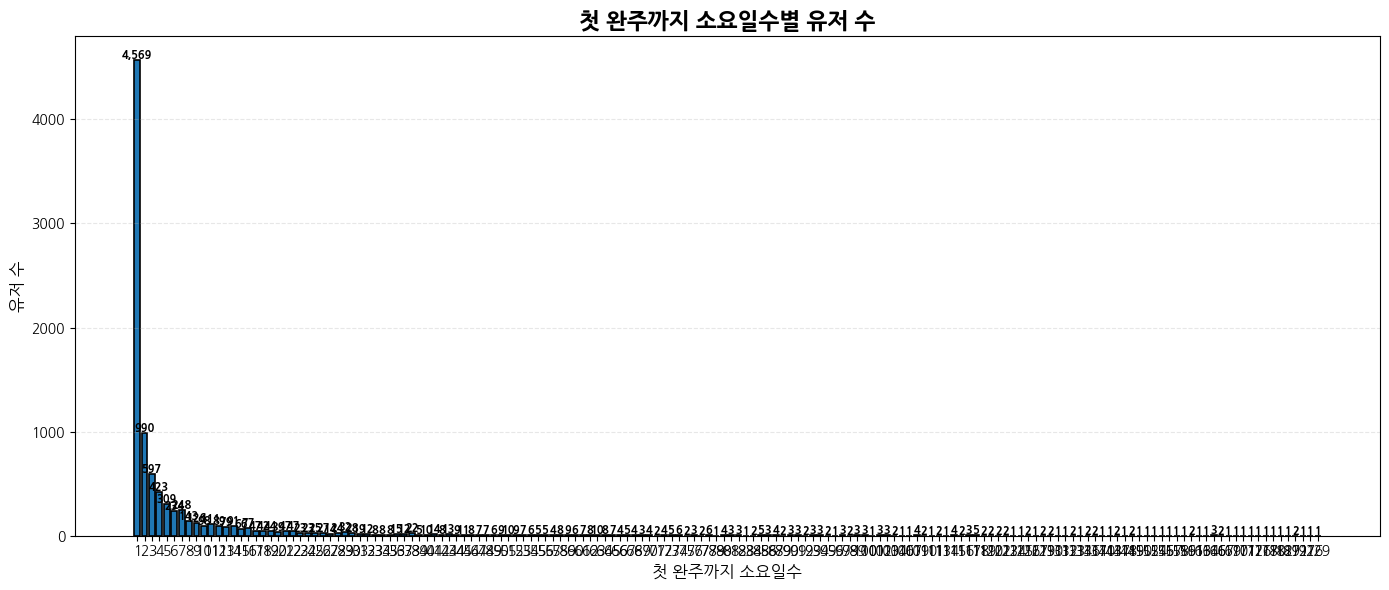

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

plot_df = day_count_summary.copy()

plt.figure(figsize=(14, 6))
bars = plt.bar(
    plot_df["첫완주까지_소요일수"].astype(str),
    plot_df["유저수"],
    edgecolor="black",
    linewidth=1.2
)

for bar, cnt in zip(bars, plot_df["유저수"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(cnt):,}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

plt.title("첫 완주까지 소요일수별 유저 수", fontsize=16, fontweight="bold")
plt.xlabel("첫 완주까지 소요일수", fontsize=12)
plt.ylabel("유저 수", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

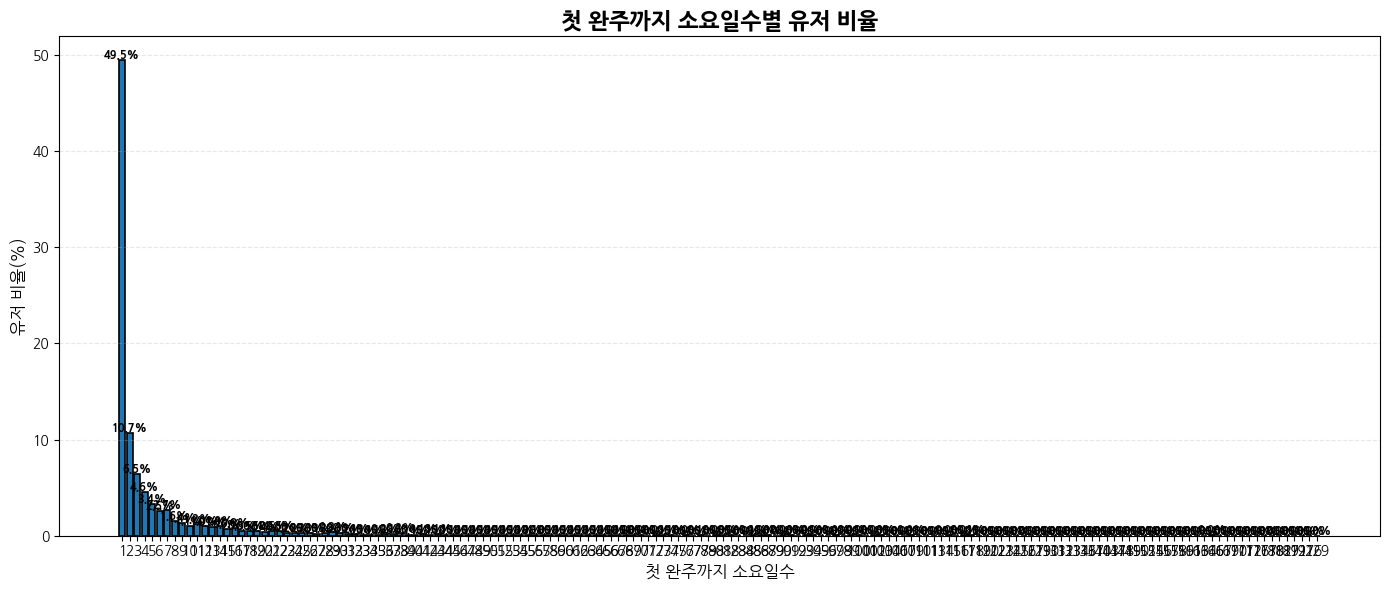

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

plot_df = day_count_summary.copy()

plt.figure(figsize=(14, 6))
bars = plt.bar(
    plot_df["첫완주까지_소요일수"].astype(str),
    plot_df["유저비율(%)"],
    edgecolor="black",
    linewidth=1.2
)

for bar, pct in zip(bars, plot_df["유저비율(%)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

plt.title("첫 완주까지 소요일수별 유저 비율", fontsize=16, fontweight="bold")
plt.xlabel("첫 완주까지 소요일수", fontsize=12)
plt.ylabel("유저 비율(%)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
day_count_summary = (
    final_first_completion
    .groupby("첫완주까지_소요일수", as_index=False)
    .agg(유저수=("user_id", "nunique"))
    .sort_values("첫완주까지_소요일수")
)

day_count_summary["유저비율(%)"] = (
    day_count_summary["유저수"] / day_count_summary["유저수"].sum() * 100
).round(2)

plot_df_30 = day_count_summary[day_count_summary["첫완주까지_소요일수"] <= 30].copy()

display(plot_df_30.head())

,첫완주까지_소요일수,유저수,유저비율(%)
0,1,4569,49.47
1,2,990,10.72
2,3,597,6.46
3,4,423,4.58
4,5,309,3.35


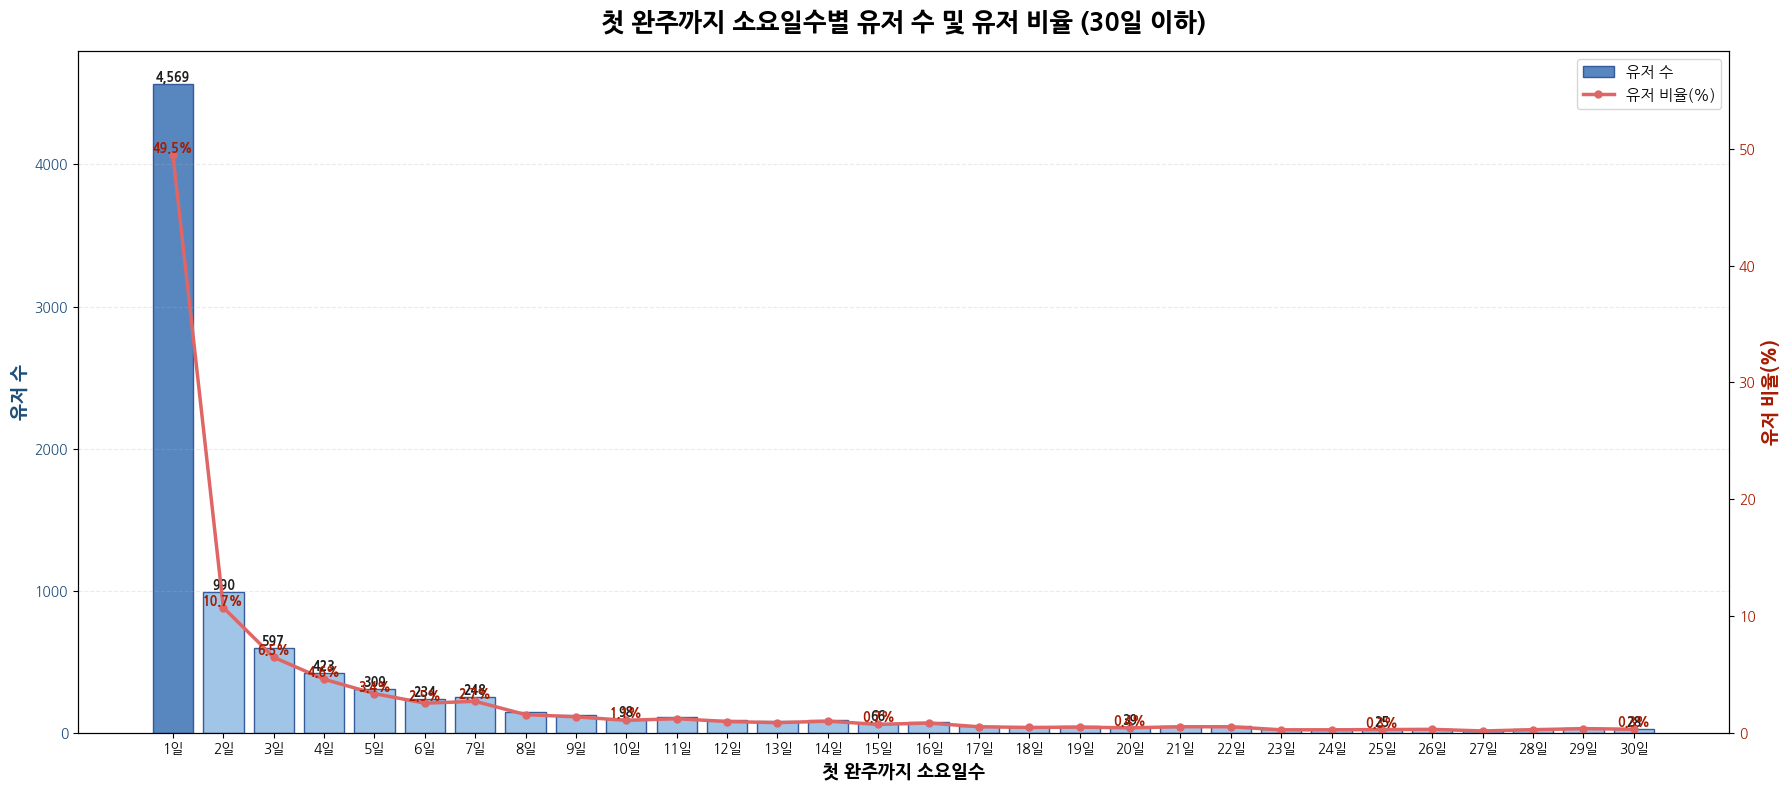

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np

# -----------------------------
# 1. 요약표 준비
# -----------------------------
day_count_summary = (
    final_first_completion
    .groupby("첫완주까지_소요일수", as_index=False)
    .agg(유저수=("user_id", "nunique"))
    .sort_values("첫완주까지_소요일수")
)

day_count_summary["유저비율(%)"] = (
    day_count_summary["유저수"] / day_count_summary["유저수"].sum() * 100
).round(2)

plot_df = day_count_summary[day_count_summary["첫완주까지_소요일수"] <= 30].copy()
plot_df["소요일수라벨"] = plot_df["첫완주까지_소요일수"].astype(str) + "일"

# -----------------------------
# 2. 색상 설정
#    1일은 강조, 나머지는 통일
# -----------------------------
bar_colors = ["#4F81BD" if d == 1 else "#9CC2E5" for d in plot_df["첫완주까지_소요일수"]]

# -----------------------------
# 3. 그래프
# -----------------------------
fig, ax1 = plt.subplots(figsize=(18, 8))

bars = ax1.bar(
    plot_df["소요일수라벨"],
    plot_df["유저수"],
    color=bar_colors,
    edgecolor="#2F5597",
    linewidth=1.0,
    alpha=0.95,
    label="유저 수"
)

# 유저 수 라벨: 너무 많으니 일부만 표시
# 1~7일은 모두 표시, 이후는 5일 단위만 표시
for bar, day, cnt in zip(bars, plot_df["첫완주까지_소요일수"], plot_df["유저수"]):
    if (day <= 7) or (day % 5 == 0):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(cnt):,}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="#1F1F1F"
        )

ax1.set_xlabel("첫 완주까지 소요일수", fontsize=13, fontweight="bold")
ax1.set_ylabel("유저 수", fontsize=13, fontweight="bold", color="#1F4E79")
ax1.tick_params(axis="y", labelcolor="#1F4E79")
ax1.grid(axis="y", linestyle="--", alpha=0.25)

# -----------------------------
# 4. 보조축: 유저 비율 선그래프
# -----------------------------
ax2 = ax1.twinx()
ax2.plot(
    plot_df["소요일수라벨"],
    plot_df["유저비율(%)"],
    color="#E06666",
    marker="o",
    linewidth=2.5,
    markersize=5,
    label="유저 비율(%)"
)

# 비율 라벨도 일부만 표시
for x, day, pct in zip(plot_df["소요일수라벨"], plot_df["첫완주까지_소요일수"], plot_df["유저비율(%)"]):
    if (day <= 7) or (day % 5 == 0):
        ax2.text(
            x,
            pct,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="#A61C00"
        )

ax2.set_ylabel("유저 비율(%)", fontsize=13, fontweight="bold", color="#A61C00")
ax2.tick_params(axis="y", labelcolor="#A61C00")
ax2.set_ylim(0, plot_df["유저비율(%)"].max() * 1.18)

# -----------------------------
# 5. 제목 / 범례 / 레이아웃
# -----------------------------
plt.title("첫 완주까지 소요일수별 유저 수 및 유저 비율 (30일 이하)", fontsize=18, fontweight="bold", pad=15)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right", frameon=True, fontsize=11)

plt.xticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

day_count_summary = (
    final_first_completion
    .groupby("첫완주까지_소요일수", as_index=False)
    .agg(유저수=("user_id", "nunique"))
    .sort_values("첫완주까지_소요일수")
)

day_count_summary["유저비율(%)"] = (
    day_count_summary["유저수"] / day_count_summary["유저수"].sum() * 100
).round(2)

display(day_count_summary.head(30))

,첫완주까지_소요일수,유저수,유저비율(%)
0,1,4569,49.47
1,2,990,10.72
2,3,597,6.46
3,4,423,4.58
4,5,309,3.35
5,6,234,2.53
6,7,248,2.69
7,8,143,1.55
8,9,126,1.36
9,10,98,1.06


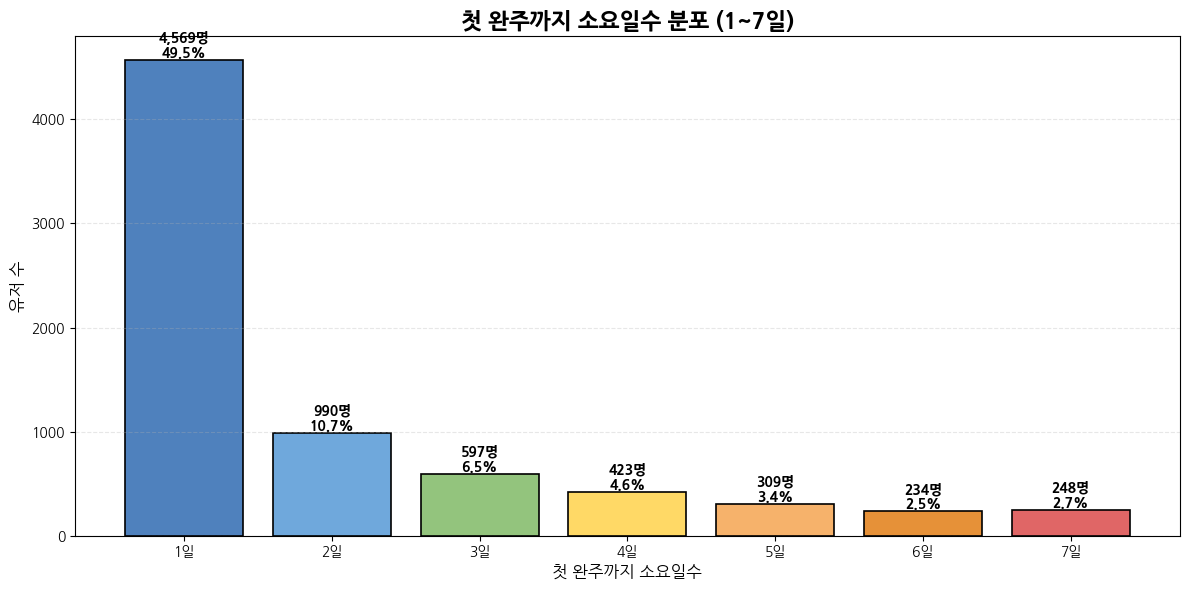

In [ ]:
plot_df_1_7 = day_count_summary[
    (day_count_summary["첫완주까지_소요일수"] >= 1) &
    (day_count_summary["첫완주까지_소요일수"] <= 7)
].copy()

plot_df_1_7["라벨"] = plot_df_1_7["첫완주까지_소요일수"].astype(str) + "일"

plt.figure(figsize=(12, 6))

colors_1_7 = ["#4F81BD", "#6FA8DC", "#93C47D", "#FFD966", "#F6B26B", "#E69138", "#E06666"][:len(plot_df_1_7)]

bars = plt.bar(
    plot_df_1_7["라벨"],
    plot_df_1_7["유저수"],
    color=colors_1_7,
    edgecolor="black",
    linewidth=1.2
)

for bar, cnt, pct in zip(bars, plot_df_1_7["유저수"], plot_df_1_7["유저비율(%)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(cnt):,}명\n{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("첫 완주까지 소요일수 분포 (1~7일)", fontsize=16, fontweight="bold")
plt.xlabel("첫 완주까지 소요일수", fontsize=12)
plt.ylabel("유저 수", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

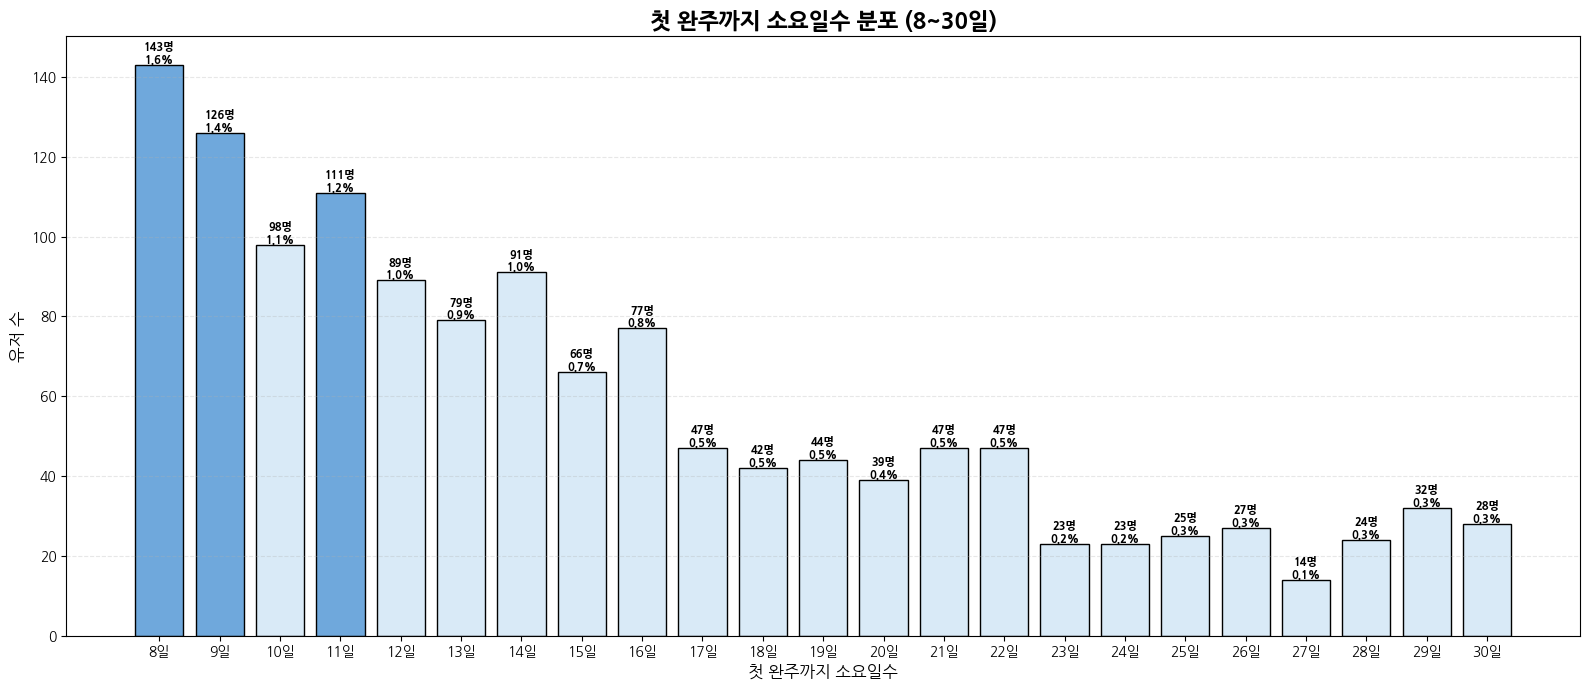

In [ ]:
plot_df_8_30 = day_count_summary[
    (day_count_summary["첫완주까지_소요일수"] >= 8) &
    (day_count_summary["첫완주까지_소요일수"] <= 30)
].copy()

plot_df_8_30["라벨"] = plot_df_8_30["첫완주까지_소요일수"].astype(str) + "일"

# 유저 수 상위 3개 강조색
top_days = plot_df_8_30.nlargest(3, "유저수")["첫완주까지_소요일수"].tolist()
colors_8_30 = [
    "#6FA8DC" if d in top_days else "#D9EAF7"
    for d in plot_df_8_30["첫완주까지_소요일수"]
]

plt.figure(figsize=(16, 7))
bars = plt.bar(
    plot_df_8_30["라벨"],
    plot_df_8_30["유저수"],
    color=colors_8_30,
    edgecolor="black",
    linewidth=1.0
)

for bar, cnt, pct in zip(bars, plot_df_8_30["유저수"], plot_df_8_30["유저비율(%)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(cnt):,}명\n{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

plt.title("첫 완주까지 소요일수 분포 (8~30일)", fontsize=16, fontweight="bold")
plt.xlabel("첫 완주까지 소요일수", fontsize=12)
plt.ylabel("유저 수", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# =====================================
# 0. 원본 복사
# 가능하면 3초 중복 제거본 사용 권장
# 예: start_df = df_start_dedup_3s.copy()
#     end_df = df_end_dedup_3s.copy()
# =====================================
start_df = df_start_content.copy()
end_df = df_end_content.copy()

# =====================================
# 1. 시간형 변환
# =====================================
start_df["client_event_time"] = pd.to_datetime(start_df["client_event_time"], errors="coerce")
end_df["client_event_time"] = pd.to_datetime(end_df["client_event_time"], errors="coerce")

# =====================================
# 2. 필수값 결측 제거
# =====================================
start_df = start_df.dropna(subset=["user_id", "content.id", "client_event_time"]).copy()
end_df = end_df.dropna(subset=["user_id", "content.id", "client_event_time"]).copy()

# =====================================
# 3. 자료형 통일
# =====================================
start_df["user_id"] = start_df["user_id"].astype(str)
start_df["content.id"] = start_df["content.id"].astype(str)
end_df["user_id"] = end_df["user_id"].astype(str)
end_df["content.id"] = end_df["content.id"].astype(str)

# =====================================
# 4. event_type 필터링 (컬럼 있으면 적용)
# =====================================
if "event_type" in start_df.columns:
    start_df = start_df[start_df["event_type"] == "start.content"].copy()

if "event_type" in end_df.columns:
    end_df = end_df[end_df["event_type"] == "end.content"].copy()

# =====================================
# 5. 컬럼명 정리
# =====================================
start_df = start_df.rename(columns={"client_event_time": "start_time"})
end_df = end_df.rename(columns={"client_event_time": "end_time"})

print("전처리 후 start 건수:", len(start_df))
print("전처리 후 end 건수:", len(end_df))

# =====================================
# 6. 정상 start-end 후보 만들기
# 같은 user_id + content.id 기준
# start 이후 end만 인정
# =====================================
candidate = start_df[["user_id", "content.id", "start_time"]].merge(
    end_df[["user_id", "content.id", "end_time"]],
    on=["user_id", "content.id"],
    how="inner"
)

candidate = candidate[candidate["start_time"] <= candidate["end_time"]].copy()

print("정상 start-end 매칭 후보 건수:", len(candidate))
display(candidate.head())

전처리 후 start 건수: 74827
전처리 후 end 건수: 46359
정상 start-end 매칭 후보 건수: 26776


,user_id,content.id,start_time,end_time
0,0001f15911b404f3bf5b8571afafa4e4,61b6463287573f00de13a930805a52d6,2023-11-29 10:14:22.988,2023-11-30 11:35:26
1,0001f15911b404f3bf5b8571afafa4e4,f4be1a0fe0e301b03115591777fddf29,2023-11-22 21:50:00.941,2023-11-29 10:04:46
2,000be07bc09ceff42c11978f4a9f1c1a,ca35d0138a7550f002f975310604a9b7,2023-05-23 13:14:30.009,2023-05-26 15:25:28
3,001a8c6ed927bd4502bf67de0e0f181d,61b6463287573f00de13a930805a52d6,2023-08-23 17:51:35.845,2023-08-23 20:04:38
4,001a8c6ed927bd4502bf67de0e0f181d,f4be1a0fe0e301b03115591777fddf29,2023-08-23 20:08:32.019,2023-08-25 19:46:46


In [ ]:
# =====================================
# 7. 유저 기준 완주경험 여부
# start 기록이 있는 유저 중
# 하나라도 정상 완주 경험이 있으면 True
# =====================================

# start 기록이 있는 전체 유저
start_users = (
    start_df[["user_id"]]
    .drop_duplicates()
    .copy()
)

# 완주 경험이 있는 유저
completion_users = (
    candidate[["user_id"]]
    .drop_duplicates()
    .assign(완주경험여부=True)
)

# 전체 유저에 완주경험 여부 붙이기
user_completion_status = start_users.merge(
    completion_users,
    on="user_id",
    how="left"
)

user_completion_status["완주경험여부"] = (
    user_completion_status["완주경험여부"]
    .fillna(False)
    .astype(bool)
)

display(user_completion_status.head())

/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/253446157.py:30: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,user_id,완주경험여부
0,000087537cbfd934375364218ff10f91,False
1,0001f15911b404f3bf5b8571afafa4e4,True
2,0003b028a745bdfda9e88539424248af,False
3,000509014329002768958b9210789b4b,False
4,000634ec5553ca63f77c61690353a0be,False


In [ ]:
전체_start유저수 = user_completion_status["user_id"].nunique()
완주경험유저수 = int(user_completion_status["완주경험여부"].sum())
미완주경험유저수 = int((~user_completion_status["완주경험여부"]).sum())
완주경험비율 = round(user_completion_status["완주경험여부"].mean() * 100, 2)

summary_table = pd.DataFrame({
    "지표": [
        "전체 start 유저 수",
        "완주경험 유저 수",
        "미완주경험 유저 수",
        "완주경험 비율(%)"
    ],
    "값": [
        전체_start유저수,
        완주경험유저수,
        미완주경험유저수,
        완주경험비율
    ]
})

display(summary_table)

print("전체 start 유저 수:", 전체_start유저수)
print("완주경험 유저 수:", 완주경험유저수)
print("미완주경험 유저 수:", 미완주경험유저수)
print("완주경험 비율(%):", 완주경험비율)

,지표,값
0,전체 start 유저 수,32996.00
1,완주경험 유저 수,9236.00
2,미완주경험 유저 수,23760.00
3,완주경험 비율(%),27.99


전체 start 유저 수: 32996
완주경험 유저 수: 9236
미완주경험 유저 수: 23760
완주경험 비율(%): 27.99


In [ ]:
aha_start_preprocessed = df_start_content.copy()
aha_end_preprocessed = df_end_content.copy()

## 3-2. 구독 관련 전처리 EDA

# subscription EDA

## content

### 1. 데이터 품질 점검
    * 행 수, 유저 수, 기간
    * client_event_time 결측 / 파싱 불가
    * user_id 결측 / 빈문자열
    * plan.price, paid_amount, coupon.discount_amount 결측
    * 음수 / 0 / 비정상적으로 큰 값
    * 중복 이벤트 의심치
### 2. 테이블 자체 EDA
    * 건수 / 유저수 / 기간
    * 월별 추이
    * 금액 분포
    * 할인 사용 비율
    * 플랜 가격 대비 실제 결제금액 관계
    * 플랜 구성 비중
    * 결제수단(pg.type) 분포
    * 유저당 이벤트 수 분포
        → 특히 renew, resubscribe는 일부 유저가 여러 번 발생시키는 구조인지 확인
### 3. 테이블 간 연결 EDA
    * 첫 결제 후 갱신 여부
    * 첫 결제 → 첫 갱신까지 소요기간
    * 갱신 경험 유저 중 재구독 여부
    * 마지막 갱신 → 첫 재구독까지 소요기간
    * complete만 있고 renew 없는 유저
    * renew 없이 바로 resubscribe 있는 유저
        → 구조 점검용.
### 4. AHA용 종속변수 베이스 만들기
    * 유저별 첫 complete 시점
    * 첫 renew 시점
    * 첫 resubscribe 시점
    * 첫 결제 금액 / 누적 매출 / 갱신 여부 / 복귀 여부

## 데이터 점검 및 전처리

### 라이브러리

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = KOREAN_FONT
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

### table import

In [ ]:
complete_df = normalize_loaded_dataframe(pd.read_csv(os.path.join(PATH_AHA, 'raw_complete_subscription_aha.csv')))
renew_df = normalize_loaded_dataframe(pd.read_csv(os.path.join(PATH_AHA, 'raw_renew_subscription_aha.csv')))
resub_df = normalize_loaded_dataframe(pd.read_csv(os.path.join(PATH_AHA, 'raw_resubscribe_subscription_aha.csv')))

for _df in [complete_df, renew_df, resub_df]:
    rename_map = {}
    if 'plan.price' in _df.columns:
        rename_map['plan.price'] = 'plan_price'
    if 'coupon.discount_amount' in _df.columns:
        rename_map['coupon.discount_amount'] = 'coupon_discount_amount'
    if rename_map:
        _df.rename(columns=rename_map, inplace=True)

In [ ]:
print(complete_df.info(),'\n')
print(renew_df.info(),'\n')
print(resub_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4943 entries, 0 to 4942
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   client_event_time       4943 non-null   object
 1   event_type              4943 non-null   object
 2   user_id                 4943 non-null   object
 3   plan_price              4943 non-null   int64 
 4   paid_amount             4943 non-null   int64 
 5   coupon_discount_amount  4943 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 231.8+ KB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8401 entries, 0 to 8400
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   client_event_time       8401 non-null   object
 1   event_type              8401 non-null   object
 2   user_id                 8401 non-null   object
 3   plan_price              8401 non-null   int64 
 

In [ ]:
complete_df.head()

,client_event_time,event_type,user_id,plan_price,paid_amount,coupon_discount_amount
0,2023-05-31 01:25:56,complete.subscription,d4f54ecf6c4d7bf8742f80505f02d6dc,15920,15920,0
1,2023-05-31 01:27:06,complete.subscription,ac7c3298f6afc990333b9dbf937f2378,15920,15920,0
2,2023-05-11 04:12:50,complete.subscription,eb94155d7d652f3633bbc45980c6db20,15920,15920,0
3,2023-05-04 15:30:02,complete.subscription,de268c470001d1b0ff39f0c4869c60e0,15920,15920,0
4,2023-05-05 13:28:35,complete.subscription,ea4ca47baa41447263b90957e0cf39c2,15920,15920,0


In [ ]:
complete_df['event_time'] = pd.to_datetime(complete_df['client_event_time'], utc=True).dt.tz_convert('Asia/Seoul')
complete_df['event_type'] = 'complete_subscription'

In [ ]:
renew_df['event_time'] = pd.to_datetime(renew_df['client_event_time'], utc=True).dt.tz_convert('Asia/Seoul')
renew_df['event_type'] = 'renew_subscription'
renew_df.head()

,client_event_time,event_type,user_id,plan_price,paid_amount,coupon_discount_amount,event_time
0,2023-04-30 15:00:24,renew_subscription,743f19451c645547580700a28c40d756,15920,15920,0,2023-05-01 00:00:24+09:00
1,2023-04-30 15:30:02,renew_subscription,f6e22c44284ba6fe30e499e36b27f0a4,15920,15920,0,2023-05-01 00:30:02+09:00
2,2023-05-01 00:15:02,renew_subscription,ba57954e6208361ce72398c9be664f97,15920,15920,0,2023-05-01 09:15:02+09:00
3,2023-05-01 01:00:04,renew_subscription,74e4e9fc43a6a5af4c0f92d01ac466d9,15920,15920,0,2023-05-01 10:00:04+09:00
4,2023-05-01 01:45:03,renew_subscription,b6a97f261b53f9f6c208a72bfd4ab2ca,15920,15920,0,2023-05-01 10:45:03+09:00


In [ ]:
resub_df['event_time'] = pd.to_datetime(resub_df['client_event_time'], utc=True).dt.tz_convert('Asia/Seoul')
resub_df['event_type'] = 'resubscribe_subscription'
resub_df.head()

,client_event_time,event_type,user_id,plan_price,paid_amount,coupon_discount_amount,event_time
0,2023-06-30 09:59:57,resubscribe_subscription,68831c27e47f0e8f04ba809baeec218e,15920,15920,0,2023-06-30 18:59:57+09:00
1,2023-06-13 06:20:23,resubscribe_subscription,4e7568cb7db01f8386614ec2c6c961cd,15920,15920,0,2023-06-13 15:20:23+09:00
2,2023-06-11 11:02:12,resubscribe_subscription,f91f19527b9ec688e028ec884b1b5c1c,131600,131600,0,2023-06-11 20:02:12+09:00
3,2023-06-13 14:39:26,resubscribe_subscription,2276d7d2a31e05f4a5558c6406cc36c9,131600,131600,0,2023-06-13 23:39:26+09:00
4,2023-06-15 12:01:13,resubscribe_subscription,e2652bbc8ce6ef935dc655ed9b3a1464,15920,15920,0,2023-06-15 21:01:13+09:00


In [ ]:
# null / 빈문자열 점검 ...compete
print(complete_df.isna().sum().sum())
print((complete_df=='').sum().sum())

0
0


In [ ]:
# null / 빈문자열 점검 ... renew
print(renew_df.isna().sum().sum())
print((renew_df=='').sum().sum())

0
0


In [ ]:
# null / 빈문자열 점검 ... resub
print(resub_df.isna().sum().sum())
print((resub_df=='').sum().sum())

0
0


### 공통 파생변수 생성

In [ ]:
dfs = [complete_df, renew_df, resub_df]

for df in dfs:
    # event 발생일, 월 파생변수
    df['event_date'] = df['event_time'].dt.date
    df['event_month'] = df['event_time'].dt.to_period('M').astype(str)

    # 할인 여부 파생변수
    df['used_coupon'] = np.where(df['coupon_discount_amount'] > 0, 1, 0)

    # 결제 0원 여부 파생변수
    df['is_zero_paid'] = np.where(df['paid_amount'] == 0, 1, 0)

    # 가격-실결제 차이 변수 파생
    df['price_minus_paid'] = df['plan_price'] - df['paid_amount']

print(complete_df.columns)

Index(['client_event_time', 'event_type', 'user_id', 'plan_price', 'paid_amount', 'coupon_discount_amount', 'event_time', 'event_date', 'event_month', 'used_coupon', 'is_zero_paid',
       'price_minus_paid'],
      dtype='object')


/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/2708722930.py:6: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.

/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/2708722930.py:6: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.

/var/folders/m3/m7y6w2l56z3bzv5xt50f29qh0000gn/T/ipykernel_4740/2708722930.py:6: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



In [ ]:
# ### coupon_discount_amount = price_minus_paid 일치여부 확인
# 애초에 그렇게 파생된 변수지만 점검차..

mask_cc = complete_df['coupon_discount_amount'] != complete_df['price_minus_paid']
complete_df.loc[mask_cc]

,client_event_time,event_type,user_id,plan_price,paid_amount,coupon_discount_amount,event_time,event_date,event_month,used_coupon,is_zero_paid,price_minus_paid


In [ ]:
mask_nc = renew_df['coupon_discount_amount'] != renew_df['price_minus_paid']
renew_df.loc[mask_nc]

,client_event_time,event_type,user_id,plan_price,paid_amount,coupon_discount_amount,event_time,event_date,event_month,used_coupon,is_zero_paid,price_minus_paid


In [ ]:
mask_sc = resub_df['coupon_discount_amount'] != resub_df['price_minus_paid']
resub_df.loc[mask_sc]

,client_event_time,event_type,user_id,plan_price,paid_amount,coupon_discount_amount,event_time,event_date,event_month,used_coupon,is_zero_paid,price_minus_paid


In [ ]:
for df in dfs:
    df.drop(columns=['price_minus_paid'], inplace=True)

### 테이블별 행수, 유저수, 기간
dt변환, 결측치 점검은 위에서 완료  
[ complete_df ]

In [ ]:
print(f'첫구독 건수: {len(complete_df):,}') # 행ㅇ수
print(f"첫구독 유저 수: {complete_df['user_id'].nunique(dropna=True):,}")
print(f"기간: {complete_df['event_time'].min()} ~ {complete_df['event_time'].max()}")

첫구독 건수: 4,943
첫구독 유저 수: 4,870
기간: 2023-05-01 00:03:59+09:00 ~ 2023-12-31 23:59:39+09:00


[ renew_df ]

In [ ]:
print(f'구독갱신 건수: {len(renew_df):,}') # 행ㅇ수
print(f"구독갱신 유저 수: {renew_df['user_id'].nunique(dropna=True):,}")
print(f"기간: {renew_df['event_time'].min()} ~ {renew_df['event_time'].max()}")

구독갱신 건수: 8,401
구독갱신 유저 수: 3,977
기간: 2023-05-01 00:00:24+09:00 ~ 2023-12-31 23:50:02+09:00


[ resub_df]

In [ ]:
print(f'만료후 재구독 건수: {len(resub_df):,}') # 행ㅇ수
print(f"만료후 재구독 유저 수: {resub_df['user_id'].nunique(dropna=True):,}")
print(f"기간: {resub_df['event_time'].min()} ~ {resub_df['event_time'].max()}")

만료후 재구독 건수: 574
만료후 재구독 유저 수: 563
기간: 2023-05-01 13:57:30+09:00 ~ 2023-12-31 23:57:02+09:00


### 금액관련 컬럼

[ complete_df]

In [ ]:
print(complete_df[['plan_price', 'paid_amount', 'coupon_discount_amount']].describe().round(2))

       plan_price  paid_amount  coupon_discount_amount
count     4943.00      4943.00                 4943.00
mean     47026.97     46132.83                  894.14
std      46140.66     45151.27                 3444.48
min      14328.00      7960.00                    0.00
25%      15920.00     15920.00                    0.00
50%      15920.00     15920.00                    0.00
75%      95520.00     95520.00                    0.00
max     131600.00    131600.00                52640.00


In [ ]:
print(renew_df[['plan_price', 'paid_amount', 'coupon_discount_amount']].describe().round(2))

       plan_price  paid_amount  coupon_discount_amount
count     8401.00      8401.00                 8401.00
mean     26758.70     25939.67                  819.04
std      29981.92     29664.31                 3409.98
min      14328.00      7960.00                    0.00
25%      15920.00     15920.00                    0.00
50%      15920.00     15920.00                    0.00
75%      15920.00     15920.00                    0.00
max     131600.00    131600.00                65800.00


In [ ]:
print(resub_df[['plan_price', 'paid_amount', 'coupon_discount_amount']].describe().round(2))

       plan_price  paid_amount  coupon_discount_amount
count      574.00       574.00                  574.00
mean     46072.89     45395.49                  677.40
std      46122.49     45339.77                 3735.21
min      15920.00      7960.00                    0.00
25%      15920.00     15920.00                    0.00
50%      15920.00     15920.00                    0.00
75%      95520.00     95520.00                    0.00
max     131600.00    131600.00                32900.00


* 음수 금액, 0원 결제 없음
* 첫구독, 갱신, 재구독 모두 plan_price, paid_amount의 중앙값이 15,920원으로 같음
  * 저가 플랜에 많이 집중된 편
* 반면 평균은 중앙값보다 훨씬 높음
  * 일부 고가 결제가 전체 평균을 끌어올리는 우측편포 형태
* renew_df는 평균 결제금액이 25,950원으로 complete_df, resub_df보다 낮음
  * 상대적으로 저가 플랜 비중이 더 큼
* coupon_discount_amount는 75% 지점까지 모두 0원
    * 대부분의 결제에서는 할인 적용이 없었던 것으로 보임
* 다만 최대 할인금액은 꽤 큼  
   * 할인은 소수 결제건에만 선택적으로 크게 적용된 것으로 보임

### 상위금액만 확인

In [ ]:
display(complete_df[['plan_price', 'paid_amount', 'coupon_discount_amount']].quantile([0.5, 0.9, 0.95, 0.99, 1.0]).round(2))
display(renew_df[['plan_price', 'paid_amount', 'coupon_discount_amount']].quantile([0.5, 0.9, 0.95, 0.99, 1.0]).round(2))
display(resub_df[['plan_price', 'paid_amount', 'coupon_discount_amount']].quantile([0.5, 0.9, 0.95, 0.99, 1.0]).round(2))

,plan_price,paid_amount,coupon_discount_amount
0.50,15920.0,15920.0,0.0
0.90,131600.0,131600.0,1592.0
0.95,131600.0,131600.0,2388.0
0.99,131600.0,131600.0,19740.0
1.00,131600.0,131600.0,52640.0


,plan_price,paid_amount,coupon_discount_amount
0.50,15920.0,15920.0,0.0
0.90,95520.0,95520.0,0.0
0.95,95520.0,95520.0,7960.0
0.99,131600.0,131600.0,7960.0
1.00,131600.0,131600.0,65800.0


,plan_price,paid_amount,coupon_discount_amount
0.50,15920.0,15920.0,0.0
0.90,131600.0,131600.0,0.0
0.95,131600.0,131600.0,2388.0
0.99,131600.0,131600.0,19740.0
1.00,131600.0,131600.0,32900.0


* 상위 분위수로 갈수록 plan_price, paid_amount가 특정 고가 플랜(95,520원, 131,600원)에 집중되는 패턴
* 할인금액은 중앙값·상위 90%까지도 대부분 0원이어서, 할인 적용 비중이 생각보다 매우 낮은 편
* 할인 적용 구간에 들어가면 할인폭이 한 번에 커지는 형태 -> 전반적 상시 할인보다는 일부 케이스 중심의 선택적 할인 패턴에 가까움

### 중복행 점검

[complete_df]

In [ ]:
complete_df.duplicated(subset=['user_id', 'event_time', 'paid_amount', 'event_type']).sum()
complete_df.duplicated(subset=['user_id', 'event_time', 'plan_price', 'paid_amount', 'coupon_discount_amount', 'event_type']).sum()

np.int64(0)

[renew_df]

In [ ]:
renew_df.duplicated(subset=['user_id', 'event_time', 'paid_amount', 'event_type']).sum()
renew_df.duplicated(subset=['user_id', 'event_time', 'plan_price', 'paid_amount', 'coupon_discount_amount', 'event_type']).sum()

np.int64(0)

[resub_df]

In [ ]:
resub_df.duplicated(subset=['user_id', 'event_time', 'paid_amount', 'event_type']).sum()
resub_df.duplicated(subset=['user_id', 'event_time', 'plan_price', 'paid_amount', 'coupon_discount_amount', 'event_type']).sum()

np.int64(0)

## EDA

### 이벤트별 기본 요약
유저당 평균 추가해서 확인

[complte_df]

In [ ]:
print('[complete_df]')
print(f'첫구독 건수: {len(complete_df):,}')
print(f'첫구독 유저수: {complete_df["user_id"].nunique():,}')
print(f'기간: {complete_df["event_time"].min()} ~ {complete_df["event_time"].max()}')
print(f'유저당 평균 첫구독 횟수: {len(complete_df) / complete_df["user_id"].nunique():.2f}')

[complete_df]
첫구독 건수: 4,943
첫구독 유저수: 4,870
기간: 2023-05-01 00:03:59+09:00 ~ 2023-12-31 23:59:39+09:00
유저당 평균 첫구독 횟수: 1.01


In [ ]:
print('[renew_df]')
print(f'갱신 건수: {len(renew_df):,}')
print(f'갱신 유저수: {renew_df["user_id"].nunique():,}')
print(f'기간: {renew_df["event_time"].min()} ~ {renew_df["event_time"].max()}')
print(f'유저당 평균 갱신 횟수: {len(renew_df) / renew_df["user_id"].nunique():.2f}')

[renew_df]
갱신 건수: 8,401
갱신 유저수: 3,977
기간: 2023-05-01 00:00:24+09:00 ~ 2023-12-31 23:50:02+09:00
유저당 평균 갱신 횟수: 2.11


In [ ]:
print('[resub_df]')
print(f'만료후 재구독 건수: {len(resub_df):,}')
print(f'만료후 재구독 유저수: {resub_df["user_id"].nunique():,}')
print(f'기간: {resub_df["event_time"].min()} ~ {resub_df["event_time"].max()}')
print(f'유저당 평균 재구독 횟수: {len(resub_df) / resub_df["user_id"].nunique():.2f}')

[resub_df]
만료후 재구독 건수: 574
만료후 재구독 유저수: 563
기간: 2023-05-01 13:57:30+09:00 ~ 2023-12-31 23:57:02+09:00
유저당 평균 재구독 횟수: 1.02


### 유저당 이벤트 수 분포

[complete_df]   
유저당 첫구독 횟수 점검 (이벤트 정의상 1이어야 정상)

In [ ]:
complete_user_event_cnt = complete_df.groupby('user_id').size()

print('유저당 첫구독수 요약')
print(complete_user_event_cnt.describe().round(2))
print('\n첫구독 횟수별 유저 수')
print(complete_user_event_cnt.value_counts().sort_index().head(10))

유저당 첫구독수 요약
count    4870.00
mean        1.01
std         0.18
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         8.00
dtype: float64

첫구독 횟수별 유저 수
1    4814
2      49
3       4
5       1
6       1
8       1
Name: count, dtype: int64


In [ ]:
# 유저당 첫구독 2회이상 유저 점검
complete_over2_users = complete_user_event_cnt[complete_user_event_cnt >= 2].index.tolist()

print('첫구독 2회 이상 유저 수:', len(complete_over2_users))

# 해당 유저들의 complete_subscription 로그
complete_over2_logs = (
    complete_df[complete_df['user_id'].isin(complete_over2_users)]
    .sort_values(['user_id', 'event_time'])
    .copy()
)

complete_over2_logs

첫구독 2회 이상 유저 수: 56


,client_event_time,event_type,user_id,plan_price,paid_amount,coupon_discount_amount,event_time,event_date,event_month,used_coupon,is_zero_paid
983,2023-05-12 13:30:30,complete_subscription,046469242e1de011419057a9511925c3,131600,131600,0,2023-05-12 22:30:30+09:00,2023-05-12,2023-05,0,0
824,2023-05-12 15:43:35,complete_subscription,046469242e1de011419057a9511925c3,15920,15920,0,2023-05-13 00:43:35+09:00,2023-05-13,2023-05,0,0
1013,2023-06-30 01:53:33,complete_subscription,04e3ed921de9a3cb187256ece5cf81bc,15920,15920,0,2023-06-30 10:53:33+09:00,2023-06-30,2023-06,0,0
552,2023-06-30 03:03:40,complete_subscription,04e3ed921de9a3cb187256ece5cf81bc,15920,15920,0,2023-06-30 12:03:40+09:00,2023-06-30,2023-06,0,0
1129,2023-12-31 11:42:21,complete_subscription,0d7ecf0279a28851ca8aed4d5f715234,95520,95520,0,2023-12-31 20:42:21+09:00,2023-12-31,2023-12,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1482,2023-11-23 02:25:14,complete_subscription,f8ccc11d7f9789b9ac497b1cf46cb6f8,15920,15920,0,2023-11-23 11:25:14+09:00,2023-11-23,2023-11,0,0
2528,2023-11-23 03:02:16,complete_subscription,f8ccc11d7f9789b9ac497b1cf46cb6f8,131600,131600,0,2023-11-23 12:02:16+09:00,2023-11-23,2023-11,0,0
1825,2023-11-23 04:47:04,complete_subscription,f8ccc11d7f9789b9ac497b1cf46cb6f8,15920,15920,0,2023-11-23 13:47:04+09:00,2023-11-23,2023-11,0,0
1397,2023-08-18 03:05:38,complete_subscription,feb2861037f5bb189cc501d05e4126a2,131600,131600,0,2023-08-18 12:05:38+09:00,2023-08-18,2023-08,0,0


* 다른 플랜 첫결제가 섞였음 . 같은날 다른 플랜 첫결제함. diff_minute, 플랜별로봐야함

In [ ]:
# 같은 유저 내에서 이전 complete 로그와의 시간 차이
complete_over2_logs['prev_event_time'] = complete_over2_logs.groupby('user_id')['event_time'].shift(1)

complete_over2_logs['diff_seconds'] = (
    complete_over2_logs['event_time'] - complete_over2_logs['prev_event_time']
).dt.total_seconds()

complete_over2_logs['diff_minutes'] = (
    complete_over2_logs['diff_seconds'] / 60
).round(2)

display(
    complete_over2_logs[
        ['user_id', 'event_time', 'prev_event_time', 'diff_seconds', 'diff_minutes',
         'plan_price', 'paid_amount', 'coupon_discount_amount']
    ]
)

,user_id,event_time,prev_event_time,diff_seconds,diff_minutes,plan_price,paid_amount,coupon_discount_amount
983,046469242e1de011419057a9511925c3,2023-05-12 22:30:30+09:00,NaT,NaN,NaN,131600,131600,0
824,046469242e1de011419057a9511925c3,2023-05-13 00:43:35+09:00,2023-05-12 22:30:30+09:00,7985.0,133.08,15920,15920,0
1013,04e3ed921de9a3cb187256ece5cf81bc,2023-06-30 10:53:33+09:00,NaT,NaN,NaN,15920,15920,0
552,04e3ed921de9a3cb187256ece5cf81bc,2023-06-30 12:03:40+09:00,2023-06-30 10:53:33+09:00,4207.0,70.12,15920,15920,0
1129,0d7ecf0279a28851ca8aed4d5f715234,2023-12-31 20:42:21+09:00,NaT,NaN,NaN,95520,95520,0
...,...,...,...,...,...,...,...,...
1482,f8ccc11d7f9789b9ac497b1cf46cb6f8,2023-11-23 11:25:14+09:00,NaT,NaN,NaN,15920,15920,0
2528,f8ccc11d7f9789b9ac497b1cf46cb6f8,2023-11-23 12:02:16+09:00,2023-11-23 11:25:14+09:00,2222.0,37.03,131600,131600,0
1825,f8ccc11d7f9789b9ac497b1cf46cb6f8,2023-11-23 13:47:04+09:00,2023-11-23 12:02:16+09:00,6288.0,104.80,15920,15920,0
1397,feb2861037f5bb189cc501d05e4126a2,2023-08-18 12:05:38+09:00,NaT,NaN,NaN,131600,131600,0


* 대체로 같은날. 아마 플랜 잘못 결제했거나 고민하다가 취소후 다시 구독?

In [ ]:
# 같은 유저의 연속 complete 로그가 플랜/결제금액까지 같은 경우
complete_over2_logs['same_plan_as_prev'] = (
    complete_over2_logs['plan_price'] ==
    complete_over2_logs.groupby('user_id')['plan_price'].shift(1)
)

complete_over2_logs['same_paid_as_prev'] = (
    complete_over2_logs['paid_amount'] ==
    complete_over2_logs.groupby('user_id')['paid_amount'].shift(1)
)

complete_over2_logs['same_discount_as_prev'] = (
    complete_over2_logs['coupon_discount_amount'] ==
    complete_over2_logs.groupby('user_id')['coupon_discount_amount'].shift(1)
)

complete_dup_suspects = complete_over2_logs[
    complete_over2_logs['prev_event_time'].notna()
].copy()

display(
    complete_dup_suspects[
        ['user_id', 'event_time', 'prev_event_time', 'diff_seconds', 'diff_minutes',
         'plan_price', 'paid_amount', 'coupon_discount_amount',
         'same_plan_as_prev', 'same_paid_as_prev', 'same_discount_as_prev']
    ]
)

,user_id,event_time,prev_event_time,diff_seconds,diff_minutes,plan_price,paid_amount,coupon_discount_amount,same_plan_as_prev,same_paid_as_prev,same_discount_as_prev
824,046469242e1de011419057a9511925c3,2023-05-13 00:43:35+09:00,2023-05-12 22:30:30+09:00,7985.0,133.08,15920,15920,0,False,False,True
552,04e3ed921de9a3cb187256ece5cf81bc,2023-06-30 12:03:40+09:00,2023-06-30 10:53:33+09:00,4207.0,70.12,15920,15920,0,True,True,True
4083,0d7ecf0279a28851ca8aed4d5f715234,2023-12-31 21:38:57+09:00,2023-12-31 20:42:21+09:00,3396.0,56.60,95520,95520,0,True,True,True
4246,12280ceb9038186c7b360d7feca6826d,2023-12-31 14:46:15+09:00,2023-12-31 01:08:21+09:00,49074.0,817.90,95520,95520,0,True,True,True
437,1480f1b180ceb360d5d3e18495aa2d26,2023-06-21 10:20:24+09:00,2023-06-13 13:15:58+09:00,680666.0,11344.43,15920,15920,0,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...
2832,f833cca4c382ac8c502c6f99bc432725,2023-11-13 15:18:23+09:00,2023-10-26 10:12:02+09:00,1573581.0,26226.35,15920,15920,0,False,False,True
1483,f833cca4c382ac8c502c6f99bc432725,2023-11-23 11:34:01+09:00,2023-11-13 15:18:23+09:00,850538.0,14175.63,131600,131600,0,False,False,True
2528,f8ccc11d7f9789b9ac497b1cf46cb6f8,2023-11-23 12:02:16+09:00,2023-11-23 11:25:14+09:00,2222.0,37.03,131600,131600,0,False,False,True
1825,f8ccc11d7f9789b9ac497b1cf46cb6f8,2023-11-23 13:47:04+09:00,2023-11-23 12:02:16+09:00,6288.0,104.80,15920,15920,0,False,False,True


* 로그 중복된 단순 중복으로 볼 순 없음 대체로 하루 내지만 비정상적으로 짧은 시간간격은 아님
* 며칠 지나서 플랜을 바꿔서 첫결제하는 경우가 포함됨.  
    -> 유저당 첫 event를 첫구독으로 정의함

In [ ]:
complete_short_gap = complete_dup_suspects[
    complete_dup_suspects['diff_minutes'] <= 10
].copy()

display(
    complete_short_gap[
        ['user_id', 'event_time', 'prev_event_time', 'diff_seconds', 'diff_minutes',
         'plan_price', 'paid_amount', 'coupon_discount_amount',
         'same_plan_as_prev', 'same_paid_as_prev', 'same_discount_as_prev']
    ]
)

,user_id,event_time,prev_event_time,diff_seconds,diff_minutes,plan_price,paid_amount,coupon_discount_amount,same_plan_as_prev,same_paid_as_prev,same_discount_as_prev


* 10분내 같은 플랜 첫구독 로그는 없기 때문에
* 첫결제 2회이상 로그는 아마도 기술적 duplicate라기보다
    * 플랜 변경
    * 같은 날 재결제
    * 또는 후속 결제가 complete_subscription으로 잘못 라벨링 됐을 수 있음
> * 그래서 결론적으로 이상치로 제거하지 않고 complete_df에서는 유저별 가장 이른1건만 사용한다...

In [ ]:
# 첫구독 분석용 complete_df 정제
# 유저별로 가장 이른 complete_subscription 1건만 남김

complete_df_raw = complete_df.copy()


complete_df = (
    complete_df
    .sort_values(['user_id', 'event_time'])
    .drop_duplicates(subset='user_id', keep='first')
    .copy()
)

print('원본 행 수:', len(complete_df_raw))
print('정제 후 행 수:', len(complete_df))
print('정제 후 유저 수:', complete_df['user_id'].nunique()) # 행수=유저수 일치해야 정상

display(complete_df.head())

원본 행 수: 4943
정제 후 행 수: 4870
정제 후 유저 수: 4870


,client_event_time,event_type,user_id,plan_price,paid_amount,coupon_discount_amount,event_time,event_date,event_month,used_coupon,is_zero_paid
3859,2023-11-29 01:13:52,complete_subscription,0001f15911b404f3bf5b8571afafa4e4,15920,15920,0,2023-11-29 10:13:52+09:00,2023-11-29,2023-11,0,0
2294,2023-09-10 23:34:22,complete_subscription,0031482d16469048027f6096d13c8b22,15920,15920,0,2023-09-11 08:34:22+09:00,2023-09-11,2023-09,0,0
3979,2023-07-15 16:01:57,complete_subscription,0032f459acd07365803996f97f98d224,15920,15920,0,2023-07-16 01:01:57+09:00,2023-07-16,2023-07,0,0
4713,2023-08-15 10:07:27,complete_subscription,003dc1089ee8075dfe8aab161efc6188,15920,15920,0,2023-08-15 19:07:27+09:00,2023-08-15,2023-08,0,0
938,2023-05-23 15:38:01,complete_subscription,0052fcc7e62a04f47a1b23c3488d31a0,15920,15920,0,2023-05-24 00:38:01+09:00,2023-05-24,2023-05,0,0


[renew_df]  
유저당 갱신횟수 분포

In [ ]:
renew_user_event_cnt = renew_df.groupby('user_id').size()

print('유저당 갱신횟수 요약')
print(renew_user_event_cnt.describe().round(2))
print('\n갱신 횟수별 유저 수')
print(renew_user_event_cnt.value_counts().sort_index().head(15))

유저당 갱신횟수 요약
count    3977.00
mean        2.11
std         1.71
min         1.00
25%         1.00
50%         1.00
75%         3.00
max         9.00
dtype: float64

갱신 횟수별 유저 수
1    2208
2     709
3     402
4     242
5     165
6      92
7      53
8     101
9       5
Name: count, dtype: int64


### 유저당 갱신 0ㅇ회 이상 유저 점검

In [ ]:
# 갱신 이벤트가 9회 이상인 유저만 추출
renew_over9_users = renew_user_event_cnt[renew_user_event_cnt >= 9].index.tolist()

print('갱신 9회 이상 유저 수:', len(renew_over9_users))
print('\n갱신 9회 이상 유저별 횟수')
display(renew_user_event_cnt[renew_user_event_cnt >= 9].sort_values(ascending=False))

갱신 9회 이상 유저 수: 5

갱신 9회 이상 유저별 횟수


user_id
1fec210b0b564ab8b540688f0ed67b03    9
9f12c110740a42edb3c837d2562de2e9    9
ad661e25866e73c391721ff56f9c14ef    9
c5a6a6119a7ed29d9685e2e46e9a3985    9
f6e22c44284ba6fe30e499e36b27f0a4    9
dtype: int64

In [ ]:
# 해당 유저들의 renew_subscription 로그
renew_over9_logs = (
    renew_df[renew_df['user_id'].isin(renew_over9_users)]
    .sort_values(['user_id', 'event_time'])
    .copy()
)
renew_over9_logs.head(20)

,client_event_time,event_type,user_id,plan_price,paid_amount,coupon_discount_amount,event_time,event_date,event_month,used_coupon,is_zero_paid
370,2023-05-18 13:05:02,renew_subscription,1fec210b0b564ab8b540688f0ed67b03,15920,15920,0,2023-05-18 22:05:02+09:00,2023-05-18,2023-05,0,0
1081,2023-06-18 13:10:02,renew_subscription,1fec210b0b564ab8b540688f0ed67b03,15920,15920,0,2023-06-18 22:10:02+09:00,2023-06-18,2023-06,0,0
1817,2023-07-18 13:15:01,renew_subscription,1fec210b0b564ab8b540688f0ed67b03,131600,131600,0,2023-07-18 22:15:01+09:00,2023-07-18,2023-07,0,0
1818,2023-07-18 13:46:53,renew_subscription,1fec210b0b564ab8b540688f0ed67b03,15920,15920,0,2023-07-18 22:46:53+09:00,2023-07-18,2023-07,0,0
2957,2023-08-18 13:50:02,renew_subscription,1fec210b0b564ab8b540688f0ed67b03,15920,15920,0,2023-08-18 22:50:02+09:00,2023-08-18,2023-08,0,0
4188,2023-09-18 13:55:02,renew_subscription,1fec210b0b564ab8b540688f0ed67b03,15920,15920,0,2023-09-18 22:55:02+09:00,2023-09-18,2023-09,0,0
5408,2023-10-18 14:00:02,renew_subscription,1fec210b0b564ab8b540688f0ed67b03,15920,15920,0,2023-10-18 23:00:02+09:00,2023-10-18,2023-10,0,0
6443,2023-11-18 14:05:01,renew_subscription,1fec210b0b564ab8b540688f0ed67b03,15920,15920,0,2023-11-18 23:05:01+09:00,2023-11-18,2023-11,0,0
7586,2023-12-18 14:10:01,renew_subscription,1fec210b0b564ab8b540688f0ed67b03,15920,15920,0,2023-12-18 23:10:01+09:00,2023-12-18,2023-12,0,0
330,2023-05-16 06:20:02,renew_subscription,9f12c110740a42edb3c837d2562de2e9,15920,15920,0,2023-05-16 15:20:02+09:00,2023-05-16,2023-05,0,0


In [ ]:
# 같은 유저 내에서 이전 renew 로그와의 시간 차이 확인
renew_over9_logs['prev_event_time'] = renew_over9_logs.groupby('user_id')['event_time'].shift(1)

renew_over9_logs['diff_seconds'] = (
    renew_over9_logs['event_time'] - renew_over9_logs['prev_event_time']
).dt.total_seconds()

renew_over9_logs['diff_hours'] = (
    renew_over9_logs['diff_seconds'] / 3600
).round(2)

renew_over9_logs['diff_days'] = (
    renew_over9_logs['diff_seconds'] / (60 * 60 * 24)
).round(2)

renew_over9_logs[
        ['user_id', 'event_time', 'prev_event_time', 'diff_seconds', 'diff_hours', 'diff_days',
         'plan_price', 'paid_amount', 'coupon_discount_amount']
    ].head()

,user_id,event_time,prev_event_time,diff_seconds,diff_hours,diff_days,plan_price,paid_amount,coupon_discount_amount
370,1fec210b0b564ab8b540688f0ed67b03,2023-05-18 22:05:02+09:00,NaT,NaN,NaN,NaN,15920,15920,0
1081,1fec210b0b564ab8b540688f0ed67b03,2023-06-18 22:10:02+09:00,2023-05-18 22:05:02+09:00,2678700.0,744.08,31.00,15920,15920,0
1817,1fec210b0b564ab8b540688f0ed67b03,2023-07-18 22:15:01+09:00,2023-06-18 22:10:02+09:00,2592299.0,720.08,30.00,131600,131600,0
1818,1fec210b0b564ab8b540688f0ed67b03,2023-07-18 22:46:53+09:00,2023-07-18 22:15:01+09:00,1912.0,0.53,0.02,15920,15920,0
2957,1fec210b0b564ab8b540688f0ed67b03,2023-08-18 22:50:02+09:00,2023-07-18 22:46:53+09:00,2678589.0,744.05,31.00,15920,15920,0


In [ ]:
renew_over9_logs['same_plan_as_prev'] = (
    renew_over9_logs['plan_price'] ==
    renew_over9_logs.groupby('user_id')['plan_price'].shift(1)
)

renew_over9_logs['same_paid_as_prev'] = (
    renew_over9_logs['paid_amount'] ==
    renew_over9_logs.groupby('user_id')['paid_amount'].shift(1)
)

renew_over9_logs['same_discount_as_prev'] = (
    renew_over9_logs['coupon_discount_amount'] ==
    renew_over9_logs.groupby('user_id')['coupon_discount_amount'].shift(1)
)

renew_over9_check = renew_over9_logs[
    renew_over9_logs['prev_event_time'].notna()
].copy()

renew_over9_check[
        ['user_id', 'event_time', 'prev_event_time', 'diff_seconds', 'diff_hours', 'diff_days',
         'plan_price', 'paid_amount', 'coupon_discount_amount',
         'same_plan_as_prev', 'same_paid_as_prev', 'same_discount_as_prev']
    ].head()

,user_id,event_time,prev_event_time,diff_seconds,diff_hours,diff_days,plan_price,paid_amount,coupon_discount_amount,same_plan_as_prev,same_paid_as_prev,same_discount_as_prev
1081,1fec210b0b564ab8b540688f0ed67b03,2023-06-18 22:10:02+09:00,2023-05-18 22:05:02+09:00,2678700.0,744.08,31.00,15920,15920,0,True,True,True
1817,1fec210b0b564ab8b540688f0ed67b03,2023-07-18 22:15:01+09:00,2023-06-18 22:10:02+09:00,2592299.0,720.08,30.00,131600,131600,0,False,False,True
1818,1fec210b0b564ab8b540688f0ed67b03,2023-07-18 22:46:53+09:00,2023-07-18 22:15:01+09:00,1912.0,0.53,0.02,15920,15920,0,False,False,True
2957,1fec210b0b564ab8b540688f0ed67b03,2023-08-18 22:50:02+09:00,2023-07-18 22:46:53+09:00,2678589.0,744.05,31.00,15920,15920,0,True,True,True
4188,1fec210b0b564ab8b540688f0ed67b03,2023-09-18 22:55:02+09:00,2023-08-18 22:50:02+09:00,2678700.0,744.08,31.00,15920,15920,0,True,True,True


In [ ]:
renew_short_gap = renew_over9_check[
    renew_over9_check['diff_days'] <= 1
].copy()

display(
    renew_short_gap[
        ['user_id', 'event_time', 'prev_event_time', 'diff_seconds', 'diff_hours', 'diff_days',
         'plan_price', 'paid_amount', 'coupon_discount_amount',
         'same_plan_as_prev', 'same_paid_as_prev', 'same_discount_as_prev']
    ]
)

,user_id,event_time,prev_event_time,diff_seconds,diff_hours,diff_days,plan_price,paid_amount,coupon_discount_amount,same_plan_as_prev,same_paid_as_prev,same_discount_as_prev
1818,1fec210b0b564ab8b540688f0ed67b03,2023-07-18 22:46:53+09:00,2023-07-18 22:15:01+09:00,1912.0,0.53,0.02,15920,15920,0,False,False,True
4200,9f12c110740a42edb3c837d2562de2e9,2023-09-19 14:03:49+09:00,2023-09-19 13:53:28+09:00,621.0,0.17,0.01,15920,15920,0,False,False,True
3864,ad661e25866e73c391721ff56f9c14ef,2023-09-11 01:04:49+09:00,2023-09-10 19:10:02+09:00,21287.0,5.91,0.25,15920,15920,0,False,False,True
1724,f6e22c44284ba6fe30e499e36b27f0a4,2023-07-14 17:01:10+09:00,2023-07-14 16:53:30+09:00,460.0,0.13,0.01,15920,15920,0,False,False,True


* 대부분 로그는 약 30일 간격으로 반복 -> 월간 갱신으로 보면 구조상 충분히 가능
* 일부는 같은 날/몇시간 내 추가 renew가 찍혀 있음 -> 이 부분만 별도 이상 로그 후보로
> 처리조건
> * diff_days <= 1
> * same_plan_as_prev == True
> * same_paid_as_prev == True
> * same_discount_as_prev == True

In [ ]:
# 같은 유저의 직전 renew와 비교했을 때 1일 이내 + 같은 플랜 + 같은 결제금액 + 같은 할인금액이면 중복
renew_dup_candidates = renew_over9_check[
    (renew_over9_check['diff_days'] <= 1) &
    (renew_over9_check['same_plan_as_prev'] == True) &
    (renew_over9_check['same_paid_as_prev'] == True) &
    (renew_over9_check['same_discount_as_prev'] == True)
].copy()

renew_dup_candidates

,client_event_time,event_type,user_id,plan_price,paid_amount,coupon_discount_amount,event_time,event_date,event_month,used_coupon,is_zero_paid,prev_event_time,diff_seconds,diff_hours,diff_days,same_plan_as_prev,same_paid_as_prev,same_discount_as_prev


[resub_df]

In [ ]:
resub_user_event_cnt = resub_df.groupby('user_id').size()

print('유저당 재구독횟수 요약')
print(resub_user_event_cnt.describe().round(2))
print('\n재구독 횟수별 유저 수')
print(resub_user_event_cnt.value_counts().sort_index().head(15))

유저당 재구독횟수 요약
count    563.00
mean       1.02
std        0.15
min        1.00
25%        1.00
50%        1.00
75%        1.00
max        3.00
dtype: float64

재구독 횟수별 유저 수
1    553
2      9
3      1
Name: count, dtype: int64


### 월별 추이

[complete_df 월별 건수 / 유저수 / 매출]

In [ ]:
complete_monthly = (
    complete_df.groupby('event_month')
    .agg(
        event_cnt=('user_id', 'size'),
        user_cnt=('user_id', 'nunique'),
        revenue=('paid_amount', 'sum'),
        avg_paid=('paid_amount', 'mean')
    )
    .reset_index()
)

display(complete_monthly)

,event_month,event_cnt,user_cnt,revenue,avg_paid
0,2023-05,388,388,16592616,42764.474227
1,2023-06,657,657,20252120,30825.144597
2,2023-07,801,801,24478152,30559.490637
3,2023-08,520,520,18927417,36398.878846
4,2023-09,584,584,20181000,34556.506849
5,2023-10,366,366,14841096,40549.442623
6,2023-11,567,567,21121816,37251.880071
7,2023-12,987,987,86539016,87678.840932


[renew_df]

In [ ]:
renew_monthly = (
    renew_df.groupby('event_month')
    .agg(
        event_cnt=('user_id', 'size'),
        user_cnt=('user_id', 'nunique'),
        revenue=('paid_amount', 'sum'),
        avg_paid=('paid_amount', 'mean')
    )
    .reset_index()
)

display(renew_monthly)

,event_month,event_cnt,user_cnt,revenue,avg_paid
0,2023-05,664,663,15121577,22773.459337
1,2023-06,741,738,17890130,24143.225371
2,2023-07,909,902,20423659,22468.271727
3,2023-08,1099,1096,21831885,19865.227480
4,2023-09,1210,1199,24257401,20047.438843
5,2023-10,1187,1180,22391321,18863.791912
6,2023-11,998,993,18228844,18265.374749
7,2023-12,1593,1576,77774312,48822.543628


[resub_df]

In [ ]:
resub_monthly = (
    resub_df.groupby('event_month')
    .agg(
        event_cnt=('user_id', 'size'),
        user_cnt=('user_id', 'nunique'),
        revenue=('paid_amount', 'sum'),
        avg_paid=('paid_amount', 'mean')
    )
    .reset_index()
)

display(resub_monthly)

,event_month,event_cnt,user_cnt,revenue,avg_paid
0,2023-05,59,59,2327440,39448.135593
1,2023-06,78,78,2976960,38166.153846
2,2023-07,79,79,2992880,37884.556962
3,2023-08,76,76,2906520,38243.684211
4,2023-09,67,67,2499828,37310.865672
5,2023-10,50,50,1205962,24119.240000
6,2023-11,63,63,2279980,36190.158730
7,2023-12,102,102,8867440,86935.686275


In [ ]:
# complete / renew / resub 월별 집계 테이블 - 병합전 컬럼명 구분

complete_monthly_cmp = complete_monthly.rename(columns={
    'event_cnt': 'complete_event_cnt',
    'user_cnt': 'complete_user_cnt',
    'revenue': 'complete_revenue',
    'avg_paid': 'complete_avg_paid'
})

renew_monthly_cmp = renew_monthly.rename(columns={
    'event_cnt': 'renew_event_cnt',
    'user_cnt': 'renew_user_cnt',
    'revenue': 'renew_revenue',
    'avg_paid': 'renew_avg_paid'
})

resub_monthly_cmp = resub_monthly.rename(columns={
    'event_cnt': 'resub_event_cnt',
    'user_cnt': 'resub_user_cnt',
    'revenue': 'resub_revenue',
    'avg_paid': 'resub_avg_paid'
})

In [ ]:
# 월별 비교용 통합 테이블
# 분석기간 내 특정 월에 어떤 이벤트는 없을 수도 있으므로 outer join 사용

monthly_summary = (
    complete_monthly_cmp
    .merge(renew_monthly_cmp, on='event_month', how='outer')
    .merge(resub_monthly_cmp, on='event_month', how='outer')
    .sort_values('event_month')
    .reset_index(drop=True)
)

# event_cnt / user_cnt / revenue 컬럼은 결측이면 0으로 채움
count_cols = [
    'complete_event_cnt', 'complete_user_cnt', 'complete_revenue',
    'renew_event_cnt', 'renew_user_cnt', 'renew_revenue',
    'resub_event_cnt', 'resub_user_cnt', 'resub_revenue'
]

monthly_summary[count_cols] = monthly_summary[count_cols].fillna(0)

display(monthly_summary)

,event_month,complete_event_cnt,complete_user_cnt,complete_revenue,complete_avg_paid,renew_event_cnt,renew_user_cnt,renew_revenue,renew_avg_paid,resub_event_cnt,resub_user_cnt,resub_revenue,resub_avg_paid
0,2023-05,388,388,16592616,42764.474227,664,663,15121577,22773.459337,59,59,2327440,39448.135593
1,2023-06,657,657,20252120,30825.144597,741,738,17890130,24143.225371,78,78,2976960,38166.153846
2,2023-07,801,801,24478152,30559.490637,909,902,20423659,22468.271727,79,79,2992880,37884.556962
3,2023-08,520,520,18927417,36398.878846,1099,1096,21831885,19865.227480,76,76,2906520,38243.684211
4,2023-09,584,584,20181000,34556.506849,1210,1199,24257401,20047.438843,67,67,2499828,37310.865672
5,2023-10,366,366,14841096,40549.442623,1187,1180,22391321,18863.791912,50,50,1205962,24119.240000
6,2023-11,567,567,21121816,37251.880071,998,993,18228844,18265.374749,63,63,2279980,36190.158730
7,2023-12,987,987,86539016,87678.840932,1593,1576,77774312,48822.543628,102,102,8867440,86935.686275


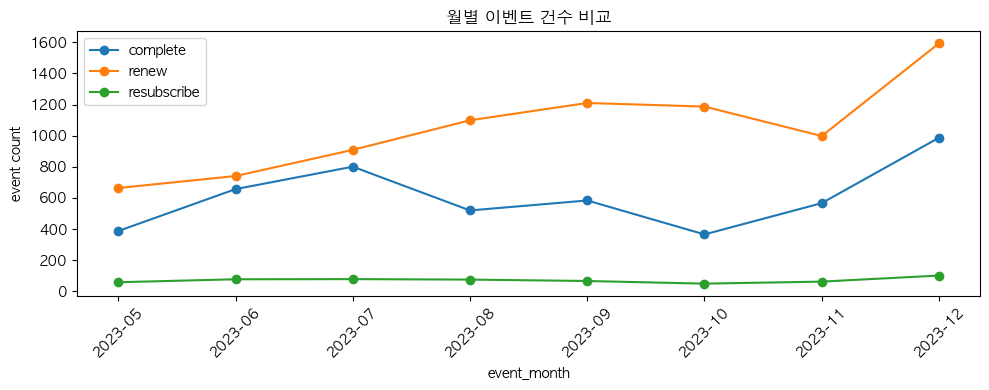

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(monthly_summary['event_month'], monthly_summary['complete_event_cnt'],
         marker='o', label='complete')
plt.plot(monthly_summary['event_month'], monthly_summary['renew_event_cnt'],
         marker='o', label='renew')
plt.plot(monthly_summary['event_month'], monthly_summary['resub_event_cnt'],
         marker='o', label='resubscribe')

plt.title('월별 이벤트 건수 비교')
plt.xlabel('event_month')
plt.ylabel('event count')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

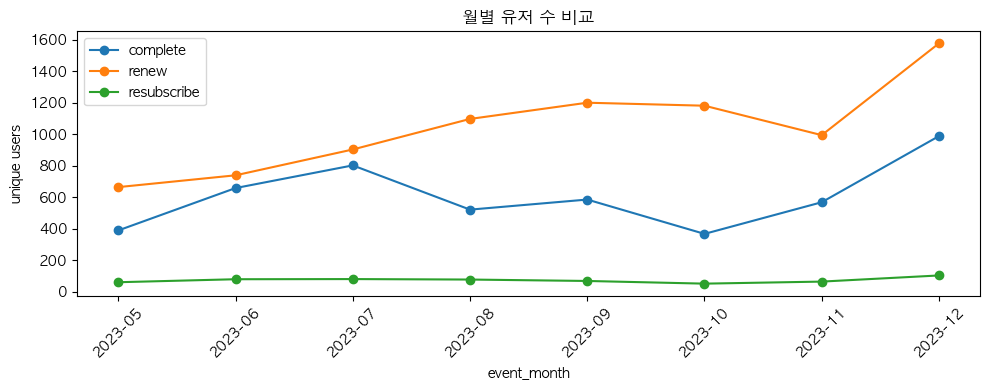

In [ ]:
# 월별 유저 수 비교 그래프
plt.figure(figsize=(10, 4))

plt.plot(monthly_summary['event_month'], monthly_summary['complete_user_cnt'],
         marker='o', label='complete')
plt.plot(monthly_summary['event_month'], monthly_summary['renew_user_cnt'],
         marker='o', label='renew')
plt.plot(monthly_summary['event_month'], monthly_summary['resub_user_cnt'],
         marker='o', label='resubscribe')

plt.title('월별 유저 수 비교')
plt.xlabel('event_month')
plt.ylabel('unique users')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

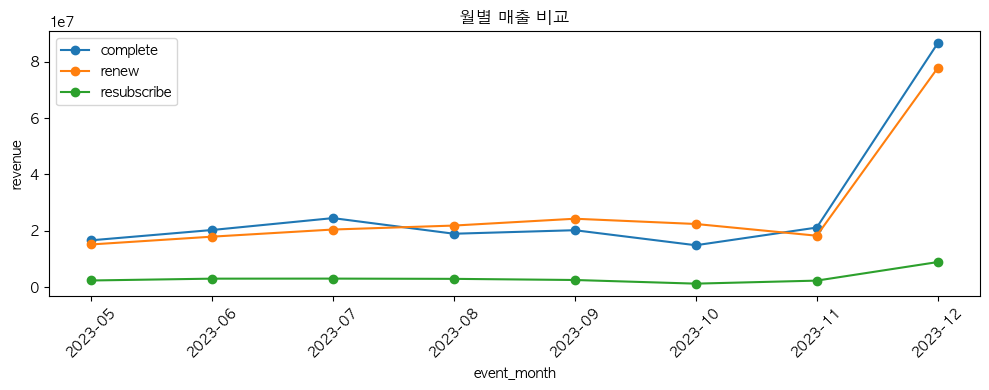

In [ ]:
# 월별 매출 비교 그래프
plt.figure(figsize=(10, 4))

plt.plot(monthly_summary['event_month'], monthly_summary['complete_revenue'],
         marker='o', label='complete')
plt.plot(monthly_summary['event_month'], monthly_summary['renew_revenue'],
         marker='o', label='renew')
plt.plot(monthly_summary['event_month'], monthly_summary['resub_revenue'],
         marker='o', label='resubscribe')

plt.title('월별 매출 비교')
plt.xlabel('event_month')
plt.ylabel('revenue')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 플랜 가격 분포
[complete_df 플랜 분포]

In [ ]:
complete_plan_dist = (
    complete_df['plan_price']
    .value_counts()
    .sort_index()
    .reset_index()
)
complete_plan_dist.columns = ['plan_price', 'count']
complete_plan_dist['ratio'] = (complete_plan_dist['count'] / complete_plan_dist['count'].sum() * 100).round(2)

complete_plan_dist

,plan_price,count,ratio
0,14328,7,0.14
1,15920,3304,67.84
2,95520,848,17.41
3,118440,2,0.04
4,131600,709,14.56



  * 정상가 14328원, 118440원?
    * 월간, 연간 플랜 프로모션?
   
[renew_df 플랜 분포]

In [ ]:
renew_plan_dist = (
    renew_df['plan_price']
    .value_counts()
    .sort_index()
    .reset_index()
)
renew_plan_dist.columns = ['plan_price', 'count']
renew_plan_dist['ratio'] = (renew_plan_dist['count'] / renew_plan_dist['count'].sum() * 100).round(2)

renew_plan_dist

,plan_price,count,ratio
0,14328,16,0.19
1,15920,7284,86.70
2,42960,191,2.27
3,95520,536,6.38
4,118440,1,0.01
5,131600,373,4.44


* 갱신 정상가에는 42960원이 추가되고 191건 존재

[resub_df 플랜 분포]

In [ ]:
resub_plan_dist = (
    resub_df['plan_price']
    .value_counts()
    .sort_index()
    .reset_index()
)
resub_plan_dist.columns = ['plan_price', 'count']
resub_plan_dist['ratio'] = (resub_plan_dist['count'] / resub_plan_dist['count'].sum() * 100).round(2)

resub_plan_dist

,plan_price,count,ratio
0,15920,396,68.99
1,95520,91,15.85
2,131600,87,15.16


 * 추측컨대 14328, 42960, 118440원은 신규 회원 할인(첫 구독가) or 갱신할인가?

### 할인 사용 비율
* 0원 결제는 없었음

In [ ]:
print('[complete_df]')
print(f'할인 사용 비율: {complete_df["used_coupon"].mean() * 100:.2f}%')

[complete_df]
할인 사용 비율: 14.39%


In [ ]:
print('[renew_df]')
print(f'할인 사용 비율: {renew_df["used_coupon"].mean() * 100:.2f}%')

[renew_df]
할인 사용 비율: 9.74%


In [ ]:
print('[resub_df]')
print(f'할인 사용 비율: {resub_df["used_coupon"].mean() * 100:.2f}%')

[resub_df]
할인 사용 비율: 8.36%


### 플랜별 결제 구조
[complete_df]

In [ ]:
complete_plan_paid_summary = (
    complete_df.groupby('plan_price')
    .agg(
        count=('user_id', 'size'),
        avg_paid=('paid_amount', 'mean'),
        median_paid=('paid_amount', 'median'),
        used_coupon_rate=('used_coupon', 'mean'),
        avg_discount=('coupon_discount_amount', 'mean')
    )
    .reset_index()
    .sort_values('plan_price')
)

complete_plan_paid_summary['used_coupon_rate'] = (complete_plan_paid_summary['used_coupon_rate'] * 100).round(2)
display(complete_plan_paid_summary.round(2))

,plan_price,count,avg_paid,median_paid,used_coupon_rate,avg_discount
0,14328,7,14328.00,14328.0,0.00,0.00
1,15920,3304,15611.53,15920.0,14.83,308.47
2,95520,848,95479.91,95520.0,2.00,40.09
3,118440,2,118440.00,118440.0,0.00,0.00
4,131600,709,127007.92,131600.0,27.36,4592.08


[renew_df]

In [ ]:
renew_plan_paid_summary = (
    renew_df.groupby('plan_price')
    .agg(
        count=('user_id', 'size'),
        avg_paid=('paid_amount', 'mean'),
        median_paid=('paid_amount', 'median'),
        used_coupon_rate=('used_coupon', 'mean'),
        avg_discount=('coupon_discount_amount', 'mean')
    )
    .reset_index()
    .sort_values('plan_price')
)

renew_plan_paid_summary['used_coupon_rate'] = (renew_plan_paid_summary['used_coupon_rate'] * 100).round(2)
display(renew_plan_paid_summary.round(2))

,plan_price,count,avg_paid,median_paid,used_coupon_rate,avg_discount
0,14328,16,14328.00,14328.0,0.00,0.00
1,15920,7284,15220.01,15920.0,10.42,699.99
2,42960,191,42773.31,42960.0,1.57,186.69
3,95520,536,95520.00,95520.0,0.00,0.00
4,118440,1,118440.00,118440.0,0.00,0.00
5,131600,373,126918.07,131600.0,15.01,4681.93


[resub_df]

In [ ]:
resub_plan_paid_summary = (
    resub_df.groupby('plan_price')
    .agg(
        count=('user_id', 'size'),
        avg_paid=('paid_amount', 'mean'),
        median_paid=('paid_amount', 'median'),
        used_coupon_rate=('used_coupon', 'mean'),
        avg_discount=('coupon_discount_amount', 'mean')
    )
    .reset_index()
    .sort_values('plan_price')
)

resub_plan_paid_summary['used_coupon_rate'] = (resub_plan_paid_summary['used_coupon_rate'] * 100).round(2)
display(resub_plan_paid_summary.round(2))

,plan_price,count,avg_paid,median_paid,used_coupon_rate,avg_discount
0,15920,396,15729.04,15920.0,8.08,190.96
1,95520,91,95520.00,95520.0,0.00,0.00
2,131600,87,127999.91,131600.0,18.39,3600.09


### 월별 할인 사용 추이
[complete_Df]

In [ ]:
complete_monthly_coupon = (
    complete_df.groupby('event_month')
    .agg(
        event_cnt=('user_id', 'size'),
        used_coupon_rate=('used_coupon', 'mean'),
        avg_discount=('coupon_discount_amount', 'mean')
    )
    .reset_index()
)

complete_monthly_coupon['used_coupon_rate'] = (complete_monthly_coupon['used_coupon_rate'] * 100).round(2)
complete_monthly_coupon['avg_discount'] = complete_monthly_coupon['avg_discount'].round(2)

display(complete_monthly_coupon)

,event_month,event_cnt,used_coupon_rate,avg_discount
0,2023-05,388,2.58,194.21
1,2023-06,657,7.00,410.79
2,2023-07,801,9.36,380.13
3,2023-08,520,13.27,654.97
4,2023-09,584,27.91,1765.96
5,2023-10,366,37.43,2868.26
6,2023-11,567,29.28,1926.53
7,2023-12,987,3.55,147.14


[renew_df]

In [ ]:
renew_monthly_coupon = (
    renew_df.groupby('event_month')
    .agg(
        event_cnt=('user_id', 'size'),
        used_coupon_rate=('used_coupon', 'mean'),
        avg_discount=('coupon_discount_amount', 'mean')
    )
    .reset_index()
)

renew_monthly_coupon['used_coupon_rate'] = (renew_monthly_coupon['used_coupon_rate'] * 100).round(2)
renew_monthly_coupon['avg_discount'] = renew_monthly_coupon['avg_discount'].round(2)

display(renew_monthly_coupon)

,event_month,event_cnt,used_coupon_rate,avg_discount
0,2023-05,664,4.52,321.00
1,2023-06,741,6.21,458.22
2,2023-07,909,10.34,827.43
3,2023-08,1099,11.65,859.59
4,2023-09,1210,12.64,944.31
5,2023-10,1187,11.88,897.30
6,2023-11,998,12.42,957.24
7,2023-12,1593,6.40,921.64


[resub_df]

In [ ]:
resub_monthly_coupon = (
    resub_df.groupby('event_month')
    .agg(
        event_cnt=('user_id', 'size'),
        used_coupon_rate=('used_coupon', 'mean'),
        avg_discount=('coupon_discount_amount', 'mean')
    )
    .reset_index()
)

resub_monthly_coupon['used_coupon_rate'] = (resub_monthly_coupon['used_coupon_rate'] * 100).round(2)
resub_monthly_coupon['avg_discount'] = resub_monthly_coupon['avg_discount'].round(2)

display(resub_monthly_coupon)

,event_month,event_cnt,used_coupon_rate,avg_discount
0,2023-05,59,0.00,0.00
1,2023-06,78,0.00,0.00
2,2023-07,79,0.00,0.00
3,2023-08,76,6.58,507.89
4,2023-09,67,23.88,2781.07
5,2023-10,50,26.00,1055.16
6,2023-11,63,22.22,1764.13
7,2023-12,102,0.00,0.00


### 월별 플랜 믹스
각 월에 어떤 가격대 플랜이 얼마나 많이 팔렸는지 & 구성비 변화 확인
  
* if) 6월 15,920원 플랜 비중이 80% -> 11월에는 95,520원, 131,600원 비중이 늘었다면  
  -> 그 달 매출이 오른 이유가 유저 수 증가 때문인지 vs. 고가 플랜 비중 증가 때문인지  
  
[complete_df]

In [ ]:
complete_monthly_plan = (
    complete_df.groupby(['event_month', 'plan_price'])
    .size()
    .reset_index(name='count')
)

complete_monthly_plan['ratio'] = (
    complete_monthly_plan['count'] /
    complete_monthly_plan.groupby('event_month')['count'].transform('sum') * 100
).round(2)

display(complete_monthly_plan.sort_values(['event_month', 'plan_price']))

,event_month,plan_price,count,ratio
0,2023-05,14328,6,1.55
1,2023-05,15920,291,75.00
2,2023-05,118440,2,0.52
3,2023-05,131600,89,22.94
4,2023-06,14328,1,0.15
5,2023-06,15920,569,86.61
6,2023-06,131600,87,13.24
7,2023-07,15920,697,87.02
8,2023-07,131600,104,12.98
9,2023-08,15920,425,81.73


* 5~11월까지는 15,920원 플랜이 계속 가장 큰 비중
    * 대체로 약 75~87% 수준
* 같은 기간 131,600원 플랜은 보조적 비중
    * 대체로 약 13~24%
* 12월에는 구조가 상당히 바뀌는 모습
    * 15,920원 비중이 10.71%로 급감
    * 95,520원 플랜이 86.31%로 급증
    * 131,600원은 2.98%로 축소
  > * 첫 구독은 대부분 기간 동안 저가 플랜 중심으로 발생
  > * 그런데 12월에는 첫 구독의 주력 플랜이 갑자기 95,520원으로 이동
  > * 그래서 12월 complete 매출 급증은 단순 유저 수 증가뿐 아니라, 플랜 구성 자체가 고가 쪽으로 이동한 영향이 매우 큼
  > * 즉 12월은 이전 달들과 같은 구조로 보면 안 될 듯. 프로모션/운영 변화/연말 시즌 효과 등 가능성 있음

[renew_df]

In [ ]:
renew_monthly_plan = (
    renew_df.groupby(['event_month', 'plan_price'])
    .size()
    .reset_index(name='count')
)

renew_monthly_plan['ratio'] = (
    renew_monthly_plan['count'] /
    renew_monthly_plan.groupby('event_month')['count'].transform('sum') * 100
).round(2)

display(renew_monthly_plan.sort_values(['event_month', 'plan_price']))

,event_month,plan_price,count,ratio
0,2023-05,15920,596,89.76
1,2023-05,42960,35,5.27
2,2023-05,131600,33,4.97
3,2023-06,14328,4,0.54
4,2023-06,15920,659,88.93
5,2023-06,42960,29,3.91
6,2023-06,118440,1,0.13
7,2023-06,131600,48,6.48
8,2023-07,14328,4,0.44
9,2023-07,15920,824,90.65


* 5~11월까지는 15,920원 플랜 비중이 압도적임
    * 대체로 89~96%
    * 42,960원, 131,600원은 소수
* 12월에는 renew도 구조 변화
    * 15,920원 비중이 59.23%로 하락
    * 95,520원 33.84%
    * 131,600원 5.80%
      > * 갱신은 첫 구독보다 더 강하게 저가 플랜 중심 구조였음
      > * 즉 유지 구간에서는 상대적으로 저가 플랜에 더 집중돼 있었다고 볼 수 있음
      > * BUT 12월에는 renew에서도 95,520원 비중이 유의미하게 커짐
      > * => 12월 매출 변화는 complete뿐 아니라 renew에서도 플랜 믹스 변화가 함께 나타난 것으로 보임

[resub_df]

In [ ]:
resub_monthly_plan = (
    resub_df.groupby(['event_month', 'plan_price'])
    .size()
    .reset_index(name='count')
)

resub_monthly_plan['ratio'] = (
    resub_monthly_plan['count'] /
    resub_monthly_plan.groupby('event_month')['count'].transform('sum') * 100
).round(2)

display(resub_monthly_plan.sort_values(['event_month', 'plan_price']))

,event_month,plan_price,count,ratio
0,2023-05,15920,47,79.66
1,2023-05,131600,12,20.34
2,2023-06,15920,63,80.77
3,2023-06,131600,15,19.23
4,2023-07,15920,64,81.01
5,2023-07,131600,15,18.99
6,2023-08,15920,61,80.26
7,2023-08,131600,15,19.74
8,2023-09,15920,53,79.10
9,2023-09,131600,14,20.90



> * 재구독 역시 대부분 기간은 저가 플랜 중심
> * 한편 12월에는 재구독에서도 주력 플랜이 95,520원으로 전환
> * 즉 12월은 첫 구독, 갱신, 재구독 모두에서 플랜 구조 변화가 동시에 나타난 시점으로 보임

## 테이블 연결 EDA

### 첫 구독 후 갱신(renew) 비율

In [ ]:
first_complete = (
    complete_df.groupby('user_id', as_index=False)
    .agg(first_complete_time=('event_time', 'min'))
)

first_renew = (
    renew_df.groupby('user_id', as_index=False)
    .agg(first_renew_time=('event_time', 'min'))
)

complete_renew_base = first_complete.merge(first_renew, on='user_id', how='left')

complete_renew_base['has_renew_after_complete'] = np.where(
    complete_renew_base['first_renew_time'].notna() &
    (complete_renew_base['first_renew_time'] > complete_renew_base['first_complete_time']),
    1, 0
)

print(f'첫 complete 이후 renew 비율: {complete_renew_base["has_renew_after_complete"].mean() * 100:.2f}%')

첫 complete 이후 renew 비율: 46.53%


### 첫 구독 후 갱신 소요기간 분포
분석기간 2023-05 ~ 2023-12: 8개월밖에 안 되고, 갱신은 플랜 주기 영향을 받기 때문에 소요기간은 의미쟈나이-

count    2266.00
mean       34.93
std        11.89
min         0.00
25%        30.00
50%        31.00
75%        37.00
90%        45.98
95%        52.00
max       199.66
Name: days_to_renew, dtype: float64


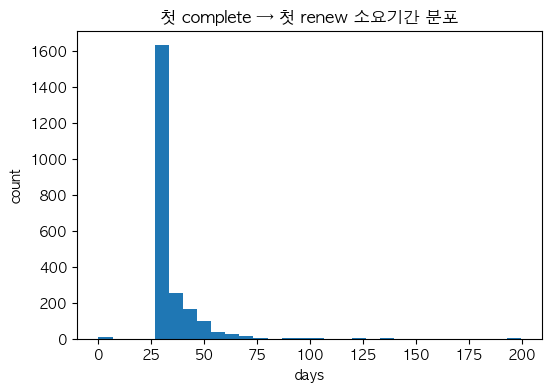

In [ ]:
complete_renew_base['days_to_renew'] = (
    complete_renew_base['first_renew_time'] - complete_renew_base['first_complete_time']
).dt.total_seconds() / (24 * 60 * 60)

days_to_renew_valid = complete_renew_base.loc[
    complete_renew_base['has_renew_after_complete'] == 1,
    'days_to_renew'
]

print(days_to_renew_valid.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).round(2))

plt.figure(figsize=(6,4))
plt.hist(days_to_renew_valid, bins=30)
plt.title('첫 complete → 첫 renew 소요기간 분포')
plt.xlabel('days')
plt.ylabel('count')
plt.show()

### complete 후 resubscribe 비율

In [ ]:
first_resub = (
    resub_df.groupby('user_id', as_index=False)
    .agg(first_resub_time=('event_time', 'min'))
)

complete_resub_base = first_complete.merge(first_resub, on='user_id', how='left')

complete_resub_base['has_resub_after_complete'] = np.where(
    complete_resub_base['first_resub_time'].notna() &
    (complete_resub_base['first_resub_time'] > complete_resub_base['first_complete_time']),
    1, 0
)

print(f'첫 complete 이후 resubscribe 비율: {complete_resub_base["has_resub_after_complete"].mean() * 100:.2f}%')

첫 complete 이후 resubscribe 비율: 1.62%


### renew 경험 후 resubscribe 비율

In [ ]:
last_renew = (
    renew_df.groupby('user_id', as_index=False)
            .agg(last_renew_time=('event_time', 'max'))
)

first_resub = (
    resub_df.groupby('user_id', as_index=False)
            .agg(first_resub_time=('event_time', 'min'))
)

renew_resub_base = last_renew.merge(first_resub, on='user_id', how='left')
renew_resub_base['has_resub_after_renew'] = np.where(
    renew_resub_base['first_resub_time'].notna() &
    (renew_resub_base['first_resub_time'] > renew_resub_base['last_renew_time']),
    1, 0
)

resub_rate_after_renew = renew_resub_base['has_resub_after_renew'].mean() * 100
print(f'renew 경험 유저 중 이후 resubscribe 비율: {resub_rate_after_renew:.2f}%')

renew 경험 유저 중 이후 resubscribe 비율: 1.11%


### 마지막 renew → 첫 resubscribe 소요기간

count     44.00
mean     100.19
std       41.59
min       34.29
25%       68.86
50%       97.48
75%      137.18
90%      156.54
95%      159.39
max      183.06
Name: days_to_resub, dtype: float64


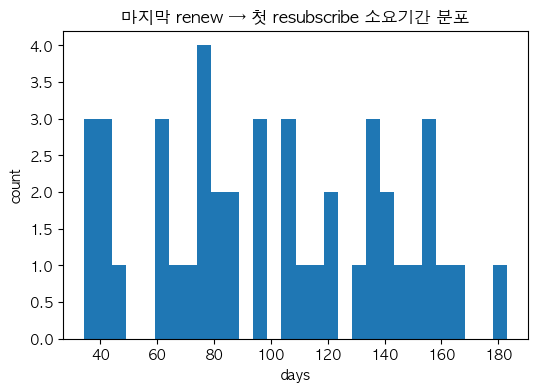

In [ ]:
renew_resub_base['days_to_resub'] = (
    renew_resub_base['first_resub_time'] - renew_resub_base['last_renew_time']
).dt.total_seconds() / (24 * 60 * 60)

days_to_resub_valid = renew_resub_base.loc[
    renew_resub_base['has_resub_after_renew'] == 1,
    'days_to_resub'
]

print(days_to_resub_valid.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).round(2))

plt.figure(figsize=(6,4))
plt.hist(days_to_resub_valid, bins=30)
plt.title('마지막 renew → 첫 resubscribe 소요기간 분포')
plt.xlabel('days')
plt.ylabel('count')
plt.show()

### complete / renew / resub 유저 관계

In [ ]:
complete_users = set(complete_df['user_id'].unique())
renew_users = set(renew_df['user_id'].unique())
resub_users = set(resub_df['user_id'].unique())

print(len(complete_users), len(renew_users), len(resub_users))

4870 3977 563


In [ ]:
# complete만 있고 renew 없는 유저 수
print(len(complete_users - renew_users))
print('비율: {:.2f}%'.format(len(complete_users - renew_users) / len(complete_users) * 100))

2604
비율: 53.47%


In [ ]:
# # complete만 있고 renew / resub 둘다 없는 유저 수
complete_only_users = complete_users - (renew_users | resub_users)

print(len(complete_only_users))
print('비율: {:.2f}%'.format(len(complete_only_users) / len(complete_users) * 100))

2584
비율: 53.06%


In [ ]:
# renew는 있는데 complete 없는 유저 수
len(renew_users - complete_users)

1711

In [ ]:
#resub는 있는데 renew 없는 유저 수
len(resub_users - renew_users)

247

In [ ]:
# resub는 있는데 complete 없는 유저 수
len(resub_users - complete_users)

484

* left censoring필요

## 유저별 구독 lifescycle 테이블
* 유저별로 첫 결제 이후 구독 관련 결과변수들 한 행으로 집계
  * 첫 complete 시점
  * renew 여부 & 첫 renew 시점
  * resub 여부 * 첫 resub 시점
  * 총 매출  

In [ ]:
# complete 유저 기준, 유저별 첫 결제 시점 & 첫 결제 정보
# -> renew / resub 여부 판단 기준

first_complete = (
    complete_df
    .sort_values(['user_id', 'event_time'])
    .groupby('user_id', as_index=False)
    .agg(
        first_complete_time=('event_time', 'min'),
        first_paid_amount=('paid_amount', 'first'),
        first_plan_price=('plan_price', 'first')
    )
)

In [ ]:
# 유저별 첫 renew 시점

first_renew = (
    renew_df
    .groupby('user_id', as_index=False)
    .agg(
        first_renew_time=('event_time', 'min')
    )
)

# 유저별 첫 resubscribe 시점

first_resub = (
    resub_df
    .groupby('user_id', as_index=False)
    .agg(
        first_resub_time=('event_time', 'min')
    )
)

In [ ]:
# 유저별 총 매출
# complete / renew / resub에서 발생한 paid_amount 합

all_payment_logs = pd.concat([
    complete_df[['user_id', 'paid_amount']],
    renew_df[['user_id', 'paid_amount']],
    resub_df[['user_id', 'paid_amount']]
], axis=0)

revenue_by_user = (
    all_payment_logs
    .groupby('user_id', as_index=False)
    .agg(
        total_revenue=('paid_amount', 'sum')
    )
)

In [ ]:
# complete 유저 기준 - renew / resub / 매출 정보 결합

sub_lifecycle = (
    first_complete
    .merge(first_renew, on='user_id', how='left')
    .merge(first_resub, on='user_id', how='left')
    .merge(revenue_by_user, on='user_id', how='left')
)

In [ ]:
# complete 이후 renew 발생 여부
# (renew 기록이 있어도 first_complete_time보다 전이면 제외)


sub_lifecycle['has_renew'] = np.where(
    sub_lifecycle['first_renew_time'].notna() &
    (sub_lifecycle['first_renew_time'] > sub_lifecycle['first_complete_time']),
    1, 0
)

# ㅊcomplete 이후 resubscribe 발생 여부
# (first_complete_time 전이면 제외)

sub_lifecycle['has_resub'] = np.where(
    sub_lifecycle['first_resub_time'].notna() &
    (sub_lifecycle['first_resub_time'] > sub_lifecycle['first_complete_time']),
    1, 0
)


In [ ]:
# complete 이후 renew 또는 resub 중 하나라도 있었는지
# (아무튼 2회이상 결제했는지 - 유지or복귀 경험 여부)

sub_lifecycle['has_any_return'] = np.where(
    (sub_lifecycle['has_renew'] == 1) |
    (sub_lifecycle['has_resub'] == 1),
    1, 0
)

print(sub_lifecycle.info())
sub_lifecycle.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype                     
---  ------               --------------  -----                     
 0   user_id              4870 non-null   object                    
 1   first_complete_time  4870 non-null   datetime64[ns, Asia/Seoul]
 2   first_paid_amount    4870 non-null   int64                     
 3   first_plan_price     4870 non-null   int64                     
 4   first_renew_time     2266 non-null   datetime64[ns, Asia/Seoul]
 5   first_resub_time     79 non-null     datetime64[ns, Asia/Seoul]
 6   total_revenue        4870 non-null   int64                     
 7   has_renew            4870 non-null   int64                     
 8   has_resub            4870 non-null   int64                     
 9   has_any_return       4870 non-null   int64                     
dtypes: datetime64[ns, Asia/Seoul](3), int64(6), object(1)
memory

,user_id,first_complete_time,first_paid_amount,first_plan_price,first_renew_time,first_resub_time,total_revenue,has_renew,has_resub,has_any_return
0,0001f15911b404f3bf5b8571afafa4e4,2023-11-29 10:13:52+09:00,15920,15920,NaT,NaT,15920,0,0,0
1,0031482d16469048027f6096d13c8b22,2023-09-11 08:34:22+09:00,15920,15920,2023-10-11 08:35:03+09:00,NaT,63680,1,0,1
2,0032f459acd07365803996f97f98d224,2023-07-16 01:01:57+09:00,15920,15920,NaT,NaT,15920,0,0,0
3,003dc1089ee8075dfe8aab161efc6188,2023-08-15 19:07:27+09:00,15920,15920,2023-09-15 19:10:02+09:00,NaT,47760,1,0,1
4,0052fcc7e62a04f47a1b23c3488d31a0,2023-05-24 00:38:01+09:00,15920,15920,2023-06-24 00:40:02+09:00,NaT,47760,1,0,1


### 첫 구독 유저 기준 종속변수 후보 요약
* content 완주경험에 따라 달라지는지 확인할 지표들
  * 이단계에서는 complete_subscription 기준.
  * 첫결제율 변수는 설명변수 테이블(content 시작/완료) 붙여서 생성해야 함

In [ ]:
display(
    sub_lifecycle[
        ['first_paid_amount', 'first_plan_price', 'total_revenue', 'has_renew', 'has_resub']
    ].describe().round(2)
)

print('has_renew 비율:', round(sub_lifecycle['has_renew'].mean() * 100, 2), '%')
print('has_resub 비율:', round(sub_lifecycle['has_resub'].mean() * 100, 2), '%')

,first_paid_amount,first_plan_price,total_revenue,has_renew,has_resub
count,4870.00,4870.00,4870.00,4870.00,4870.00
mean,45776.84,46661.65,62541.54,0.47,0.02
std,44960.86,45947.85,42654.15,0.50,0.13
min,7960.00,14328.00,7960.00,0.00,0.00
25%,15920.00,15920.00,28855.00,0.00,0.00
50%,15920.00,15920.00,47760.00,0.00,0.00
75%,95520.00,95520.00,95520.00,1.00,0.00
max,131600.00,131600.00,295040.00,1.00,1.00


has_renew 비율: 46.53 %
has_resub 비율: 1.62 %


In [ ]:
aha_complete_preprocessed = complete_df.copy()
aha_renew_preprocessed = renew_df.copy()
aha_resub_preprocessed = resub_df.copy()

## 3-3. Aha 메인 분석

# Aha Moment 분석

#### 분석 목표: 전환과 유지로 이어지는 핵심 경험으로서 **콘텐츠 첫 완주 경험**의 역할 탐색

## 1. 분석 질문

1. 구독 이전 완주 경험이 있는 유저는 첫 구독 전환율이 더 높은가?
2. 첫 완주까지 빠르게 도달한 유저일수록 첫 구독 전환율이 더 높은가?
3. 첫 완주 콘텐츠의 난이도에 따라 첫 구독 전환율이 달라지는가?
4. 초기 7일 몰입도는 첫 구독 전환과 연결되는가?
5. 구독 이전 완주 경험은 이후 90일 유지, 30/90일 LTV와 연결되는가?
6. 첫 완주의 속도와 난이도는 이후 유지·매출 수준과 연결되는가?

## 2. 공통 기준

- 분석 기간: `2023-05-01 ~ 2023-12-31` (kst 기준)
- 모든 시간 컬럼은 datetime으로 파싱한 뒤 tz 정보만 제거하여 `tz-naive`로 통일
- 기본 모집단: 분석 기간 내 `start_content`가 1회 이상 있는 유저
- 기준 시점: 유저의 `분석기간 내 최초 start_content 시각`
- 완주 판정:
  - 같은 `user_id`, 같은 `content_id`
  - 각 `end_content`를 가장 최근 `start_content`와 1:1 매칭
  - `start_time < end_time`
- 전환 분석 모집단:
  - `first_sub_time`이 없거나(전환=0) `first_start_time < first_sub_time`(전환=1)
- 유지 분석 모집단:
  - `first_subscribed = 1` 이고 `first_start_time < first_sub_time`
- 속도 변수:
  - `session_days`: `matched_start_time → 첫 유효 완주 end_time`
  - `within_7d_first_completion`: 첫 완주 `session_days <= 7`
- 유지 지표:
  - `has_any_return_90d`: 첫 구독 후 90일 내 `renew` 또는 `resub` 발생 여부
- 매출 지표:
  - `ltv_30d`: `first_start_time` 이후 30일 내 결제금액 합
  - `ltv_90d`: `first_start_time` 이후 90일 내 결제금액 합


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, kruskal, spearmanr
import statsmodels.api as sm

# 한글 폰트 설정
setup_korean_font()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (8, 4.5)

ANALYSIS_START = pd.Timestamp('2023-05-01 00:00:00')
ANALYSIS_END_EXCL = pd.Timestamp('2024-01-01 00:00:00')

def to_datetime_naive(series):
    def _parse_one(x):
        ts = pd.to_datetime(x, errors='coerce')
        if pd.isna(ts):
            return pd.NaT
        if getattr(ts, 'tzinfo', None) is not None:
            return ts.tz_localize(None)
        return ts

    return pd.to_datetime(series.apply(_parse_one), errors='coerce')


## 3. 전처리 결과 연결

In [ ]:
start_df = aha_start_preprocessed.copy()
end_df = aha_end_preprocessed.copy()
complete_df = aha_complete_preprocessed.copy()
renew_df = aha_renew_preprocessed.copy()
resub_df = aha_resub_preprocessed.copy()

In [ ]:
for name, df in [
    ('start_df', start_df),
    ('end_df', end_df),
    ('complete_df', complete_df),
    ('renew_df', renew_df),
    ('resub_df', resub_df)
]:
    print(f'[{name}] shape = {df.shape}')

[start_df] shape = (74827, 5)
[end_df] shape = (46359, 4)
[complete_df] shape = (4870, 11)
[renew_df] shape = (8401, 11)
[resub_df] shape = (574, 11)


## 4. 분석용 컬럼 정리

In [ ]:
# start_df 정리
start_time_col = 'event_time' if 'event_time' in start_df.columns else 'client_event_time'
start_content_col = 'content.id' if 'content.id' in start_df.columns else 'content_id'
start_diff_col = 'content.difficulty' if 'content.difficulty' in start_df.columns else 'difficulty'

start_df = (
    start_df[['user_id', start_content_col, start_time_col, start_diff_col]]
    .rename(columns={
        start_content_col: 'content_id',
        start_time_col: 'start_time',
        start_diff_col: 'difficulty'
    })
    .copy()
)

start_df['user_id'] = start_df['user_id'].astype(str)
start_df['content_id'] = start_df['content_id'].astype(str)
start_df['start_time'] = to_datetime_naive(start_df['start_time'])
start_df = start_df.dropna(subset=['user_id', 'content_id', 'start_time']).copy()
start_df = start_df[(start_df['start_time'] >= ANALYSIS_START) & (start_df['start_time'] < ANALYSIS_END_EXCL)].copy()

print(start_df.shape)
display(start_df.head())


(74827, 4)


,user_id,content_id,start_time,difficulty
0,000087537cbfd934375364218ff10f91,0ab2b890d4068c1490b89676773256f6,2023-05-01 19:31:15.918,intermediate
1,0001f15911b404f3bf5b8571afafa4e4,61b6463287573f00de13a930805a52d6,2023-11-29 10:14:22.988,beginner
2,0001f15911b404f3bf5b8571afafa4e4,c8e53577758bf66711094352a5abd8c3,2023-11-30 11:35:37.133,intermediate
3,0001f15911b404f3bf5b8571afafa4e4,f4be1a0fe0e301b03115591777fddf29,2023-11-22 21:50:00.941,beginner
4,0003b028a745bdfda9e88539424248af,c269eb6df3a374b464f7c18f12fa398f,2023-06-24 15:11:41.788,advanced


In [ ]:
# end_df 정리
end_time_col = 'event_time' if 'event_time' in end_df.columns else 'client_event_time'
end_content_col = 'content.id' if 'content.id' in end_df.columns else 'content_id'

end_df = (
    end_df[['user_id', end_content_col, end_time_col]]
    .rename(columns={
        end_content_col: 'content_id',
        end_time_col: 'end_time'
    })
    .copy()
)

end_df['user_id'] = end_df['user_id'].astype(str)
end_df['content_id'] = end_df['content_id'].astype(str)
end_df['end_time'] = to_datetime_naive(end_df['end_time'])
end_df = end_df.dropna(subset=['user_id', 'content_id', 'end_time']).copy()
end_df = end_df[(end_df['end_time'] >= ANALYSIS_START) & (end_df['end_time'] < ANALYSIS_END_EXCL)].copy()

print(end_df.shape)
display(end_df.head())


(46359, 3)


,user_id,content_id,end_time
0,0001f15911b404f3bf5b8571afafa4e4,61b6463287573f00de13a930805a52d6,2023-11-30 11:35:26
1,0001f15911b404f3bf5b8571afafa4e4,f4be1a0fe0e301b03115591777fddf29,2023-11-29 10:04:46
2,0008fe653493aa211bc7bd217bc0725c,4641438a6c81ef572d997dbdc9100f8b,2023-05-27 20:49:03
3,0008fe653493aa211bc7bd217bc0725c,68a3658f1b936bfff3bd6960cd561b0a,2023-05-27 20:18:50
4,0008fe653493aa211bc7bd217bc0725c,db1819d3a7a4c4d85dccb3b9e982fbcd,2023-05-27 21:32:13


In [ ]:
# complete_df 정리
complete_time_col = 'event_time' if 'event_time' in complete_df.columns else 'client_event_time'
complete_paid_col = 'paid_amount' if 'paid_amount' in complete_df.columns else 'payment_amount'
complete_price_col = 'plan_price' if 'plan_price' in complete_df.columns else 'plan.price'

keep_cols = ['user_id', complete_time_col]
if complete_paid_col in complete_df.columns:
    keep_cols.append(complete_paid_col)
if complete_price_col in complete_df.columns:
    keep_cols.append(complete_price_col)

complete_df = complete_df[keep_cols].rename(columns={
    complete_time_col: 'event_time',
    complete_paid_col: 'paid_amount',
    complete_price_col: 'plan_price'
}).copy()

complete_df['user_id'] = complete_df['user_id'].astype(str)
complete_df['event_time'] = to_datetime_naive(complete_df['event_time'])
complete_df['paid_amount'] = pd.to_numeric(complete_df.get('paid_amount', 0), errors='coerce').fillna(0)
complete_df['plan_price'] = pd.to_numeric(complete_df.get('plan_price', np.nan), errors='coerce')
complete_df['event_type'] = 'complete'
complete_df = complete_df.dropna(subset=['user_id', 'event_time']).copy()
complete_df = complete_df[(complete_df['event_time'] >= ANALYSIS_START) & (complete_df['event_time'] < ANALYSIS_END_EXCL)].copy()

print(complete_df.shape)
display(complete_df.head())


(4870, 5)


,user_id,event_time,paid_amount,plan_price,event_type
3859,0001f15911b404f3bf5b8571afafa4e4,2023-11-29 10:13:52,15920,15920,complete
2294,0031482d16469048027f6096d13c8b22,2023-09-11 08:34:22,15920,15920,complete
3979,0032f459acd07365803996f97f98d224,2023-07-16 01:01:57,15920,15920,complete
4713,003dc1089ee8075dfe8aab161efc6188,2023-08-15 19:07:27,15920,15920,complete
938,0052fcc7e62a04f47a1b23c3488d31a0,2023-05-24 00:38:01,15920,15920,complete


In [ ]:
# renew_df 정리
renew_time_col = 'event_time' if 'event_time' in renew_df.columns else 'client_event_time'
renew_paid_col = 'paid_amount' if 'paid_amount' in renew_df.columns else 'payment_amount'
renew_price_col = 'plan_price' if 'plan_price' in renew_df.columns else 'plan.price'

keep_cols = ['user_id', renew_time_col]
if renew_paid_col in renew_df.columns:
    keep_cols.append(renew_paid_col)
if renew_price_col in renew_df.columns:
    keep_cols.append(renew_price_col)

renew_df = renew_df[keep_cols].rename(columns={
    renew_time_col: 'event_time',
    renew_paid_col: 'paid_amount',
    renew_price_col: 'plan_price'
}).copy()

renew_df['user_id'] = renew_df['user_id'].astype(str)
renew_df['event_time'] = to_datetime_naive(renew_df['event_time'])
renew_df['paid_amount'] = pd.to_numeric(renew_df.get('paid_amount', 0), errors='coerce').fillna(0)
renew_df['plan_price'] = pd.to_numeric(renew_df.get('plan_price', np.nan), errors='coerce')
renew_df['event_type'] = 'renew'
renew_df = renew_df.dropna(subset=['user_id', 'event_time']).copy()
renew_df = renew_df[(renew_df['event_time'] >= ANALYSIS_START) & (renew_df['event_time'] < ANALYSIS_END_EXCL)].copy()

print(renew_df.shape)
display(renew_df.head())


(8401, 5)


,user_id,event_time,paid_amount,plan_price,event_type
0,743f19451c645547580700a28c40d756,2023-05-01 00:00:24,15920,15920,renew
1,f6e22c44284ba6fe30e499e36b27f0a4,2023-05-01 00:30:02,15920,15920,renew
2,ba57954e6208361ce72398c9be664f97,2023-05-01 09:15:02,15920,15920,renew
3,74e4e9fc43a6a5af4c0f92d01ac466d9,2023-05-01 10:00:04,15920,15920,renew
4,b6a97f261b53f9f6c208a72bfd4ab2ca,2023-05-01 10:45:03,15920,15920,renew


In [ ]:
# resub_df 정리
resub_time_col = 'event_time' if 'event_time' in resub_df.columns else 'client_event_time'
resub_paid_col = 'paid_amount' if 'paid_amount' in resub_df.columns else 'payment_amount'
resub_price_col = 'plan_price' if 'plan_price' in resub_df.columns else 'plan.price'

keep_cols = ['user_id', resub_time_col]
if resub_paid_col in resub_df.columns:
    keep_cols.append(resub_paid_col)
if resub_price_col in resub_df.columns:
    keep_cols.append(resub_price_col)

resub_df = resub_df[keep_cols].rename(columns={
    resub_time_col: 'event_time',
    resub_paid_col: 'paid_amount',
    resub_price_col: 'plan_price'
}).copy()

resub_df['user_id'] = resub_df['user_id'].astype(str)
resub_df['event_time'] = to_datetime_naive(resub_df['event_time'])
resub_df['paid_amount'] = pd.to_numeric(resub_df.get('paid_amount', 0), errors='coerce').fillna(0)
resub_df['plan_price'] = pd.to_numeric(resub_df.get('plan_price', np.nan), errors='coerce')
resub_df['event_type'] = 'resub'
resub_df = resub_df.dropna(subset=['user_id', 'event_time']).copy()
resub_df = resub_df[(resub_df['event_time'] >= ANALYSIS_START) & (resub_df['event_time'] < ANALYSIS_END_EXCL)].copy()

print(resub_df.shape)
display(resub_df.head())


(574, 5)


,user_id,event_time,paid_amount,plan_price,event_type
0,68831c27e47f0e8f04ba809baeec218e,2023-06-30 18:59:57,15920,15920,resub
1,4e7568cb7db01f8386614ec2c6c961cd,2023-06-13 15:20:23,15920,15920,resub
2,f91f19527b9ec688e028ec884b1b5c1c,2023-06-11 20:02:12,131600,131600,resub
3,2276d7d2a31e05f4a5558c6406cc36c9,2023-06-13 23:39:26,131600,131600,resub
4,e2652bbc8ce6ef935dc655ed9b3a1464,2023-06-15 21:01:13,15920,15920,resub


In [ ]:
# tz 상태 점검 함수
def tz_status(series):
    return 'tz-aware' if getattr(series.dt, 'tz', None) is not None else 'tz-naive'

# 각 테이블의 행수, 유저수, 시간최소, 시간최대, tz 상태 점검 요약
basic_check = pd.DataFrame({
    '테이블': ['start_df', 'end_df', 'complete_df', 'renew_df', 'resub_df'],
    '행수': [len(start_df), len(end_df), len(complete_df), len(renew_df), len(resub_df)],
    '유저수': [
        start_df['user_id'].nunique(),
        end_df['user_id'].nunique(),
        complete_df['user_id'].nunique(),
        renew_df['user_id'].nunique(),
        resub_df['user_id'].nunique()
    ],
    '시작시각': [
        start_df['start_time'].min(),
        end_df['end_time'].min(),
        complete_df['event_time'].min(),
        renew_df['event_time'].min(),
        resub_df['event_time'].min()
    ],
    '종료시각': [
        start_df['start_time'].max(),
        end_df['end_time'].max(),
        complete_df['event_time'].max(),
        renew_df['event_time'].max(),
        resub_df['event_time'].max()
    ],
    'tz상태': [
        tz_status(start_df['start_time']),
        tz_status(end_df['end_time']),
        tz_status(complete_df['event_time']),
        tz_status(renew_df['event_time']),
        tz_status(resub_df['event_time'])
    ]
})

display(basic_check)


,테이블,행수,유저수,시작시각,종료시각,tz상태
0,start_df,74827,32996,2023-05-01 00:00:00.977,2023-12-31 23:57:28.452,tz-naive
1,end_df,46359,13484,2023-05-01 00:05:18.000,2023-12-31 23:55:36.000,tz-naive
2,complete_df,4870,4870,2023-05-01 00:03:59.000,2023-12-31 23:59:39.000,tz-naive
3,renew_df,8401,3977,2023-05-01 00:00:24.000,2023-12-31 23:50:02.000,tz-naive
4,resub_df,574,563,2023-05-01 13:57:30.000,2023-12-31 23:57:02.000,tz-naive


## 5. 기준 시점 및 첫 구독 시점
* 유저기준 첫 start_content, 첫 complete_sub 뽑기

In [ ]:
first_start = (
    start_df
    .sort_values(['user_id', 'start_time'])
    .drop_duplicates('user_id', keep='first')
    [['user_id', 'start_time']]
    .rename(columns={'start_time': 'first_start_time'})
    .copy()
)

print('start 기준 모집단 유저 수:', first_start['user_id'].nunique())
display(first_start.head())

start 기준 모집단 유저 수: 32996


,user_id,first_start_time
0,000087537cbfd934375364218ff10f91,2023-05-01 19:31:15.918
3,0001f15911b404f3bf5b8571afafa4e4,2023-11-22 21:50:00.941
4,0003b028a745bdfda9e88539424248af,2023-06-24 15:11:41.788
5,000509014329002768958b9210789b4b,2023-09-15 02:24:18.795
6,000634ec5553ca63f77c61690353a0be,2023-05-26 15:06:18.682


In [ ]:
first_sub = (
    complete_df
    .sort_values(['user_id', 'event_time'])
    .drop_duplicates('user_id', keep='first')
    [['user_id', 'event_time', 'paid_amount', 'plan_price']]
    .rename(columns={
        'event_time': 'first_sub_time',
        'paid_amount': 'first_sub_paid_amount',
        'plan_price': 'first_sub_plan_price'
    })
    .copy()
)

print('분석기간 내 첫 complete 유저 수:', first_sub['user_id'].nunique())
display(first_sub.head())

분석기간 내 첫 complete 유저 수: 4870


,user_id,first_sub_time,first_sub_paid_amount,first_sub_plan_price
3859,0001f15911b404f3bf5b8571afafa4e4,2023-11-29 10:13:52,15920,15920
2294,0031482d16469048027f6096d13c8b22,2023-09-11 08:34:22,15920,15920
3979,0032f459acd07365803996f97f98d224,2023-07-16 01:01:57,15920,15920
4713,003dc1089ee8075dfe8aab161efc6188,2023-08-15 19:07:27,15920,15920
938,0052fcc7e62a04f47a1b23c3488d31a0,2023-05-24 00:38:01,15920,15920


In [ ]:
# 학습 시작 전 이미 첫 구독한 유저 솎아내기 (전환분석에서 제외)
# 콘텐츠 완주 -> 첫 구독의 인과관계를 보기 위한 선후행 관계 정리

time_order_check = first_start.merge(first_sub[['user_id', 'first_sub_time']], on='user_id', how='left')
time_order_check['sub_before_start'] = np.where(
    time_order_check['first_sub_time'].notna() &
    (time_order_check['first_sub_time'] <= time_order_check['first_start_time']),
    1, 0
)

print('학습 시작 전 이미 첫 구독한 유저 수:', time_order_check['sub_before_start'].sum())

학습 시작 전 이미 첫 구독한 유저 수: 2027


## 6. 구독 이전 완주 판정

같은 `user_id + content_id` 기준 `end_content`와 직전 `start_content` 1:1 매칭

### 완주 판정 기준
- `start_time < end_time` 인 경우만 인정
- 한 번 매칭된 `start`는 다시 사용하지 않음
- 이후 `first_sub_time`이 있는 유저는 `end_time < first_sub_time`인 pair만 남김

In [ ]:
def match_one_user_content(group):
    group = group.sort_values(['event_time', 'event_order']).copy()

    start_stack = []
    rows = []

    for _, row in group.iterrows():
        if row['event_kind'] == 'start':
            start_stack.append((row['event_time'], row['difficulty']))
        else:
            if len(start_stack) == 0:
                continue

            matched = None
            while len(start_stack) > 0:
                candidate_start_time, candidate_difficulty = start_stack.pop()
                if candidate_start_time < row['event_time']:
                    matched = (candidate_start_time, candidate_difficulty)
                    break

            if matched is not None:
                rows.append({
                    'user_id': row['user_id'],
                    'content_id': row['content_id'],
                    'matched_start_time': matched[0],
                    'end_time': row['event_time'],
                    'difficulty': matched[1]
                })

    return pd.DataFrame(rows)

In [ ]:
# 시작 이벤트(order=0) & 완료 이벤트(order=1) 병합

start_events = start_df[['user_id', 'content_id', 'start_time', 'difficulty']].copy()
start_events['event_time'] = start_events['start_time']
start_events['event_kind'] = 'start'
start_events['event_order'] = 0

end_events = end_df[['user_id', 'content_id', 'end_time']].copy()
end_events['event_time'] = end_events['end_time']
end_events['event_kind'] = 'end'
end_events['event_order'] = 1
end_events['difficulty'] = np.nan

event_stream = pd.concat([
    start_events[['user_id', 'content_id', 'event_time', 'difficulty', 'event_kind', 'event_order']],
    end_events[['user_id', 'content_id', 'event_time', 'difficulty', 'event_kind', 'event_order']]
], axis=0, ignore_index=True)

print(event_stream.shape)
display(event_stream.head())

(121186, 6)


,user_id,content_id,event_time,difficulty,event_kind,event_order
0,000087537cbfd934375364218ff10f91,0ab2b890d4068c1490b89676773256f6,2023-05-01 19:31:15.918,intermediate,start,0
1,0001f15911b404f3bf5b8571afafa4e4,61b6463287573f00de13a930805a52d6,2023-11-29 10:14:22.988,beginner,start,0
2,0001f15911b404f3bf5b8571afafa4e4,c8e53577758bf66711094352a5abd8c3,2023-11-30 11:35:37.133,intermediate,start,0
3,0001f15911b404f3bf5b8571afafa4e4,f4be1a0fe0e301b03115591777fddf29,2023-11-22 21:50:00.941,beginner,start,0
4,0003b028a745bdfda9e88539424248af,c269eb6df3a374b464f7c18f12fa398f,2023-06-24 15:11:41.788,advanced,start,0


In [ ]:
# 'user_id', 'content_id' 기준 start-end 매칭

completion_pairs_all = (
    event_stream
    .groupby(['user_id', 'content_id'], group_keys=False)
    .apply(match_one_user_content)
    .reset_index(drop=True)
)

completion_pairs_all['session_days'] = (
    completion_pairs_all['end_time'] - completion_pairs_all['matched_start_time']
).dt.total_seconds() / 86400

print('유효한 start-end 1:1 매칭 수:', len(completion_pairs_all))
display(completion_pairs_all.head())

유효한 start-end 1:1 매칭 수: 26707


,user_id,content_id,matched_start_time,end_time,difficulty,session_days
0,0001f15911b404f3bf5b8571afafa4e4,61b6463287573f00de13a930805a52d6,2023-11-29 10:14:22.988,2023-11-30 11:35:26,beginner,1.056285
1,0001f15911b404f3bf5b8571afafa4e4,f4be1a0fe0e301b03115591777fddf29,2023-11-22 21:50:00.941,2023-11-29 10:04:46,beginner,6.510244
2,000be07bc09ceff42c11978f4a9f1c1a,ca35d0138a7550f002f975310604a9b7,2023-05-23 13:14:30.009,2023-05-26 15:25:28,beginner,3.090949
3,001a8c6ed927bd4502bf67de0e0f181d,61b6463287573f00de13a930805a52d6,2023-08-23 17:51:35.845,2023-08-23 20:04:38,beginner,0.092386
4,001a8c6ed927bd4502bf67de0e0f181d,f4be1a0fe0e301b03115591777fddf29,2023-08-23 20:08:32.019,2023-08-25 19:46:46,beginner,1.984884


In [ ]:
completion_pairs_pre = completion_pairs_all.merge(
    first_sub[['user_id', 'first_sub_time']],
    on='user_id',
    how='left'
)

completion_pairs_pre = completion_pairs_pre[
    completion_pairs_pre['first_sub_time'].isna() |
    (completion_pairs_pre['end_time'] < completion_pairs_pre['first_sub_time'])
].copy()

print('구독 이전 기준 유효 완주 pair 수:', len(completion_pairs_pre))
display(completion_pairs_pre.head())

구독 이전 기준 유효 완주 pair 수: 14212


,user_id,content_id,matched_start_time,end_time,difficulty,session_days,first_sub_time
1,0001f15911b404f3bf5b8571afafa4e4,f4be1a0fe0e301b03115591777fddf29,2023-11-22 21:50:00.941,2023-11-29 10:04:46,beginner,6.510244,2023-11-29 10:13:52
2,000be07bc09ceff42c11978f4a9f1c1a,ca35d0138a7550f002f975310604a9b7,2023-05-23 13:14:30.009,2023-05-26 15:25:28,beginner,3.090949,NaT
3,001a8c6ed927bd4502bf67de0e0f181d,61b6463287573f00de13a930805a52d6,2023-08-23 17:51:35.845,2023-08-23 20:04:38,beginner,0.092386,NaT
4,001a8c6ed927bd4502bf67de0e0f181d,f4be1a0fe0e301b03115591777fddf29,2023-08-23 20:08:32.019,2023-08-25 19:46:46,beginner,1.984884,NaT
5,002d6194ca671b8d14967f8e52c27052,101e1d0dcc38d9c86156f008a145083e,2023-11-07 14:18:17.835,2023-11-10 15:13:38,advanced,3.038428,NaT


In [ ]:
first_completion_user = (
    completion_pairs_pre
    .sort_values(['user_id', 'end_time'])
    .drop_duplicates('user_id', keep='first')
    [['user_id', 'matched_start_time', 'end_time', 'difficulty', 'session_days']]
    .rename(columns={
        'matched_start_time': 'first_completion_start_time',
        'end_time': 'first_completion_end_time',
        'difficulty': 'first_completion_difficulty',
        'session_days': 'session_days_to_first_completion'
    })
    .copy()
)

display(first_completion_user.head())

,user_id,first_completion_start_time,first_completion_end_time,first_completion_difficulty,session_days_to_first_completion
1,0001f15911b404f3bf5b8571afafa4e4,2023-11-22 21:50:00.941,2023-11-29 10:04:46,beginner,6.510244
2,000be07bc09ceff42c11978f4a9f1c1a,2023-05-23 13:14:30.009,2023-05-26 15:25:28,beginner,3.090949
3,001a8c6ed927bd4502bf67de0e0f181d,2023-08-23 17:51:35.845,2023-08-23 20:04:38,beginner,0.092386
5,002d6194ca671b8d14967f8e52c27052,2023-11-07 14:18:17.835,2023-11-10 15:13:38,advanced,3.038428
10,0032f459acd07365803996f97f98d224,2023-07-15 20:12:34.695,2023-07-15 21:16:25,beginner,0.044332


## 7. 분석용 베이스 테이블 생성

In [ ]:
pay_events = pd.concat([
    complete_df[['user_id', 'event_time', 'paid_amount', 'event_type']],
    renew_df[['user_id', 'event_time', 'paid_amount', 'event_type']],
    resub_df[['user_id', 'event_time', 'paid_amount', 'event_type']]
], axis=0, ignore_index=True)

pay_events = pay_events.sort_values(['user_id', 'event_time']).copy()

print(pay_events.shape)
display(pay_events.head())

(13845, 4)


,user_id,event_time,paid_amount,event_type
5397,0000572f2ba8079bcefd2760b632e820,2023-05-25 23:50:02,15920,renew
0,0001f15911b404f3bf5b8571afafa4e4,2023-11-29 10:13:52,15920,complete
1,0031482d16469048027f6096d13c8b22,2023-09-11 08:34:22,15920,complete
9895,0031482d16469048027f6096d13c8b22,2023-10-11 08:35:03,15920,renew
11158,0031482d16469048027f6096d13c8b22,2023-11-14 10:17:35,15920,renew


In [ ]:
analysis_base = first_start.merge(first_sub, on='user_id', how='left')
analysis_base = analysis_base.merge(first_completion_user, on='user_id', how='left')

analysis_base['first_subscribed'] = np.where(analysis_base['first_sub_time'].notna(), 1, 0)
analysis_base['pre_sub_completion_any'] = np.where(analysis_base['first_completion_end_time'].notna(), 1, 0)

analysis_base['within_7d_first_completion'] = np.where(
    analysis_base['session_days_to_first_completion'].notna() &
    (analysis_base['session_days_to_first_completion'] <= 7),
    1, 0
)

session_bins = [-0.001, 1, 3, 7, 14, np.inf]
session_labels = ['1일 이내', '1~3일', '3~7일', '7~14일', '14일 초과']
analysis_base['session_bucket'] = pd.cut(
    analysis_base['session_days_to_first_completion'],
    bins=session_bins,
    labels=session_labels
)

analysis_base['eligible_30d'] = np.where(
    analysis_base['first_start_time'] <= (ANALYSIS_END_EXCL - pd.Timedelta(days=30)),
    1, 0
)
analysis_base['eligible_90d'] = np.where(
    analysis_base['first_start_time'] <= (ANALYSIS_END_EXCL - pd.Timedelta(days=90)),
    1, 0
)
analysis_base['eligible_return_90d'] = np.where(
    analysis_base['first_sub_time'].notna() &
    (analysis_base['first_sub_time'] <= (ANALYSIS_END_EXCL - pd.Timedelta(days=90))),
    1, 0
)

display(analysis_base.head())


,user_id,first_start_time,first_sub_time,first_sub_paid_amount,first_sub_plan_price,first_completion_start_time,first_completion_end_time,first_completion_difficulty,session_days_to_first_completion,first_subscribed,pre_sub_completion_any,within_7d_first_completion,session_bucket,eligible_30d,eligible_90d,eligible_return_90d
0,000087537cbfd934375364218ff10f91,2023-05-01 19:31:15.918,NaT,NaN,NaN,NaT,NaT,NaN,NaN,0,0,0,NaN,1,1,0
1,0001f15911b404f3bf5b8571afafa4e4,2023-11-22 21:50:00.941,2023-11-29 10:13:52,15920.0,15920.0,2023-11-22 21:50:00.941,2023-11-29 10:04:46,beginner,6.510244,1,1,1,3~7일,1,0,0
2,0003b028a745bdfda9e88539424248af,2023-06-24 15:11:41.788,NaT,NaN,NaN,NaT,NaT,NaN,NaN,0,0,0,NaN,1,1,0
3,000509014329002768958b9210789b4b,2023-09-15 02:24:18.795,NaT,NaN,NaN,NaT,NaT,NaN,NaN,0,0,0,NaN,1,1,0
4,000634ec5553ca63f77c61690353a0be,2023-05-26 15:06:18.682,NaT,NaN,NaN,NaT,NaT,NaN,NaN,0,0,0,NaN,1,1,0


In [ ]:
# LTV / paid 지표
analysis_base['paid_30d'] = 0.0
analysis_base['paid_90d'] = 0.0
analysis_base['ltv_30d'] = 0.0
analysis_base['ltv_90d'] = 0.0

for i, row in analysis_base[['user_id', 'first_start_time']].iterrows():
    uid = row['user_id']
    t0 = row['first_start_time']

    temp = pay_events[pay_events['user_id'] == uid].copy()

    paid_30 = temp[
        (temp['event_type'] == 'complete') &
        (temp['event_time'] >= t0) &
        (temp['event_time'] < t0 + pd.Timedelta(days=30))
    ]['paid_amount'].sum()

    paid_90 = temp[
        (temp['event_type'] == 'complete') &
        (temp['event_time'] >= t0) &
        (temp['event_time'] < t0 + pd.Timedelta(days=90))
    ]['paid_amount'].sum()

    ltv_30 = temp[
        (temp['event_time'] >= t0) &
        (temp['event_time'] < t0 + pd.Timedelta(days=30))
    ]['paid_amount'].sum()

    ltv_90 = temp[
        (temp['event_time'] >= t0) &
        (temp['event_time'] < t0 + pd.Timedelta(days=90))
    ]['paid_amount'].sum()

    analysis_base.loc[i, 'paid_30d'] = paid_30
    analysis_base.loc[i, 'paid_90d'] = paid_90
    analysis_base.loc[i, 'ltv_30d'] = ltv_30
    analysis_base.loc[i, 'ltv_90d'] = ltv_90

display(analysis_base[['user_id', 'paid_30d', 'paid_90d', 'ltv_30d', 'ltv_90d']].head())

,user_id,paid_30d,paid_90d,ltv_30d,ltv_90d
0,000087537cbfd934375364218ff10f91,0.0,0.0,0.0,0.0
1,0001f15911b404f3bf5b8571afafa4e4,15920.0,15920.0,15920.0,15920.0
2,0003b028a745bdfda9e88539424248af,0.0,0.0,0.0,0.0
3,000509014329002768958b9210789b4b,0.0,0.0,0.0,0.0
4,000634ec5553ca63f77c61690353a0be,0.0,0.0,0.0,0.0


In [ ]:
# 90일 유지 지표
analysis_base['renew_90d'] = 0
analysis_base['resub_90d'] = 0
analysis_base['has_any_return_90d'] = 0

renew_first = renew_df.sort_values(['user_id', 'event_time']).copy()
resub_first = resub_df.sort_values(['user_id', 'event_time']).copy()

for i, row in analysis_base[['user_id', 'first_sub_time']].iterrows():
    uid = row['user_id']
    t0 = row['first_sub_time']

    if pd.isna(t0):
        continue

    renew_flag = (
        (renew_first['user_id'] == uid) &
        (renew_first['event_time'] > t0) &
        (renew_first['event_time'] < t0 + pd.Timedelta(days=90))
    ).any()

    resub_flag = (
        (resub_first['user_id'] == uid) &
        (resub_first['event_time'] > t0) &
        (resub_first['event_time'] < t0 + pd.Timedelta(days=90))
    ).any()

    analysis_base.loc[i, 'renew_90d'] = int(renew_flag)
    analysis_base.loc[i, 'resub_90d'] = int(resub_flag)
    analysis_base.loc[i, 'has_any_return_90d'] = int(renew_flag or resub_flag)

display(analysis_base[['user_id', 'renew_90d', 'resub_90d', 'has_any_return_90d']].head())

,user_id,renew_90d,resub_90d,has_any_return_90d
0,000087537cbfd934375364218ff10f91,0,0,0
1,0001f15911b404f3bf5b8571afafa4e4,0,0,0
2,0003b028a745bdfda9e88539424248af,0,0,0
3,000509014329002768958b9210789b4b,0,0,0
4,000634ec5553ca63f77c61690353a0be,0,0,0


In [ ]:
# A파트 / B파트 모집단 분리
analysis_base_a = analysis_base[
    analysis_base['first_sub_time'].isna() |
    (analysis_base['first_sub_time'] > analysis_base['first_start_time'])
].copy()

analysis_base_b = analysis_base[
    (analysis_base['first_subscribed'] == 1) &
    (analysis_base['first_sub_time'] > analysis_base['first_start_time'])
].copy()

print('전체 start 기준 유저 수:', analysis_base['user_id'].nunique())
print('A파트 전환 분석 유저 수:', analysis_base_a['user_id'].nunique())
print('B파트 유지/매출 분석 유저 수:', analysis_base_b['user_id'].nunique())
print('학습 시작 전 이미 첫 구독해서 A/B에서 제외된 유저 수:',
      analysis_base[
          analysis_base['first_sub_time'].notna() &
          (analysis_base['first_sub_time'] <= analysis_base['first_start_time'])
      ]['user_id'].nunique())

전체 start 기준 유저 수: 32996
A파트 전환 분석 유저 수: 30969
B파트 유지/매출 분석 유저 수: 2606
학습 시작 전 이미 첫 구독해서 A/B에서 제외된 유저 수: 2027


In [ ]:
# 초기 7일 몰입도 변수
start_7d = first_start[['user_id', 'first_start_time']].merge(start_df, on='user_id', how='left')
start_7d = start_7d[
    (start_7d['start_time'] >= start_7d['first_start_time']) &
    (start_7d['start_time'] < start_7d['first_start_time'] + pd.Timedelta(days=7))
].copy()

immersion_7d = (
    start_7d
    .groupby('user_id', as_index=False)
    .agg(
        initial_7d_start_cnt=('start_time', 'count'),
        initial_7d_started_content_cnt=('content_id', 'nunique')
    )
)

analysis_base = analysis_base.merge(immersion_7d, on='user_id', how='left')
analysis_base[['initial_7d_start_cnt', 'initial_7d_started_content_cnt']] = (
    analysis_base[['initial_7d_start_cnt', 'initial_7d_started_content_cnt']].fillna(0)
)

analysis_base['initial_7d_start_cnt'] = analysis_base['initial_7d_start_cnt'].astype(int)
analysis_base['initial_7d_started_content_cnt'] = analysis_base['initial_7d_started_content_cnt'].astype(int)

analysis_base['initial_7d_start_bucket'] = pd.cut(
    analysis_base['initial_7d_start_cnt'],
    bins=[-0.1, 1, 2, 4, np.inf],
    labels=['1회', '2회', '3~4회', '5회 이상']
)

analysis_base['initial_7d_content_bucket'] = pd.cut(
    analysis_base['initial_7d_started_content_cnt'],
    bins=[-0.1, 1, 2, np.inf],
    labels=['1개', '2개', '3개 이상']
)

analysis_base_a = analysis_base[
    analysis_base['first_sub_time'].isna() |
    (analysis_base['first_sub_time'] > analysis_base['first_start_time'])
].copy()

analysis_base_b = analysis_base[
    (analysis_base['first_subscribed'] == 1) &
    (analysis_base['first_sub_time'] > analysis_base['first_start_time'])
].copy()

display(analysis_base[['user_id', 'initial_7d_start_cnt', 'initial_7d_started_content_cnt',
                       'initial_7d_start_bucket', 'initial_7d_content_bucket']].head())

,user_id,initial_7d_start_cnt,initial_7d_started_content_cnt,initial_7d_start_bucket,initial_7d_content_bucket
0,000087537cbfd934375364218ff10f91,1,1,1회,1개
1,0001f15911b404f3bf5b8571afafa4e4,2,2,2회,2개
2,0003b028a745bdfda9e88539424248af,1,1,1회,1개
3,000509014329002768958b9210789b4b,1,1,1회,1개
4,000634ec5553ca63f77c61690353a0be,1,1,1회,1개


## 8. EDA

### 8-1. 기본 구성 확인

In [ ]:
eda_base_summary = pd.DataFrame({
    '항목': ['전체 start 유저', '구독 이전 완주 유저', 'A파트 전환 모집단', 'B파트 유지 모집단'],
    '유저수': [
        analysis_base['user_id'].nunique(),
        analysis_base.loc[analysis_base['pre_sub_completion_any'] == 1, 'user_id'].nunique(),
        analysis_base_a['user_id'].nunique(),
        analysis_base_b['user_id'].nunique()
    ]
})
display(eda_base_summary)

,항목,유저수
0,전체 start 유저,32996
1,구독 이전 완주 유저,6982
2,A파트 전환 모집단,30969
3,B파트 유지 모집단,2606


* 학습 시작 유저 중 구독 이전 완주까지 간 비율은 약 21.2% (6,982 / 32,996명)
* 첫 학습 이후 첫 구독까지 이어진 유저는 전체 start 유저 대비 약 7.9% (2,606 / 32,996)
* 완주 자체가 이미 희소한 행동이라, 이 단계에 도달한 유저는 고의도 유저일 가능성이 큼
  
    > “완주”는 상위 몰입 신호에 가까움  
    > 따라서 완주와 전환의 높은 연관은 자연스러우나 동시에 자기선택 효과도 강함(즉,원래부터 의지가 높고 관심이 큰 유저였을 수 있음)

### 8-2. 월별 유저 흐름 확인

In [ ]:
start_month = (
    start_df.assign(월=start_df['start_time'].dt.to_period('M').astype(str))
    .groupby('월')['user_id'].nunique()
    .reset_index(name='start유저수')
)

completion_month = (
    completion_pairs_pre.assign(월=completion_pairs_pre['end_time'].dt.to_period('M').astype(str))
    .groupby('월')['user_id'].nunique()
    .reset_index(name='구독이전완주유저수')
)

sub_month = (
    first_sub.assign(월=first_sub['first_sub_time'].dt.to_period('M').astype(str))
    .groupby('월')['user_id'].nunique()
    .reset_index(name='첫구독유저수')
)

monthly_flow = start_month.merge(completion_month, on='월', how='left').merge(sub_month, on='월', how='left').fillna(0)
display(monthly_flow)

,월,start유저수,구독이전완주유저수,첫구독유저수
0,2023-05,4662,824,388
1,2023-06,4956,988,657
2,2023-07,5993,1303,801
3,2023-08,5473,1224,520
4,2023-09,4623,1009,584
5,2023-10,4262,882,366
6,2023-11,5637,1247,567
7,2023-12,6069,1222,987


* 월별 start 유저는 4천~6천명대
* 구독 이전 완주 유저도 대체로 start 규모를 따라감
* 첫 구독 유저는 12월이 현저히 높게 나타남

> * 시즌성, 프로모션, 연말 수요, 결제정책 변화 등이 반영되었을 가능성
> * 가설검정 결과가 특정 월에 과도하게 끌려간 것인지 월별 consistency(전반적으로 비슷하게 반복되는 패턴인지)를 확인할 필요가 있어보임
>   * 예컨대 완주여부별 전환율(y)을 월(x)별 선그래프로 비교/월별 학습시작 유저 코호트/회귀에 월고정효과 넣고 로지스틱회귀(y:첫구독여부, x: 완주여부+시작월dummy)

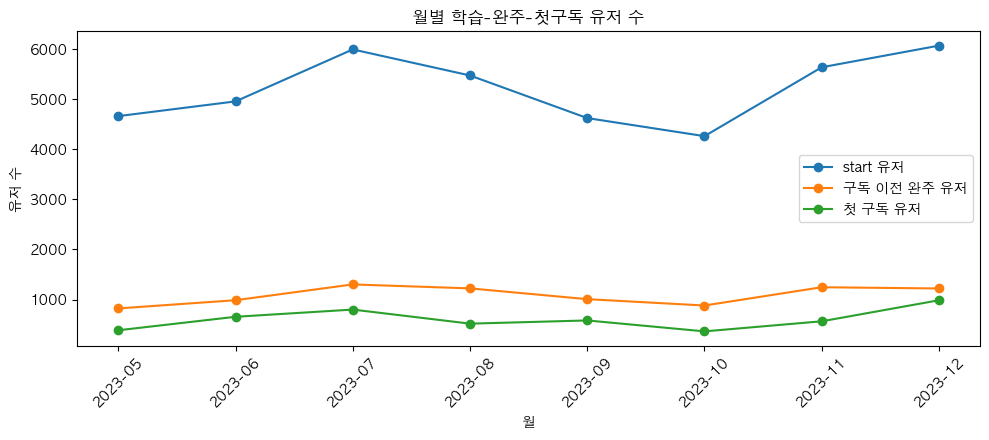

In [ ]:
plt.figure(figsize=(10, 4.5))
plt.plot(monthly_flow['월'], monthly_flow['start유저수'], marker='o', label='start 유저')
plt.plot(monthly_flow['월'], monthly_flow['구독이전완주유저수'], marker='o', label='구독 이전 완주 유저')
plt.plot(monthly_flow['월'], monthly_flow['첫구독유저수'], marker='o', label='첫 구독 유저')
plt.xticks(rotation=45)
plt.title('월별 학습-완주-첫구독 유저 수')
plt.xlabel('월')
plt.ylabel('유저 수')
plt.legend()
plt.tight_layout()
plt.show()

### 8-3. start → 완주 → 구독 퍼널 확인

In [ ]:
funnel_df = pd.DataFrame({
    '단계': ['start_content 유저', '구독 이전 완주 유저', '첫 구독 유저'],
    '유저수': [
        analysis_base['user_id'].nunique(),
        analysis_base.loc[analysis_base['pre_sub_completion_any'] == 1, 'user_id'].nunique(),
        analysis_base_a.loc[analysis_base_a['first_subscribed'] == 1, 'user_id'].nunique()
    ]
})
display(funnel_df)

,단계,유저수
0,start_content 유저,32996
1,구독 이전 완주 유저,6982
2,첫 구독 유저,2606


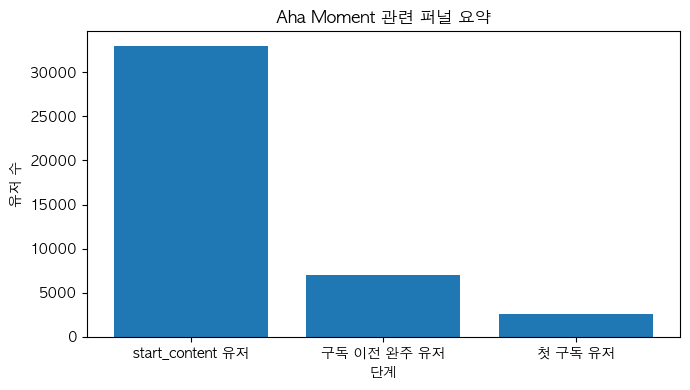

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(funnel_df['단계'], funnel_df['유저수'])
plt.title('Aha Moment 관련 퍼널 요약')
plt.xlabel('단계')
plt.ylabel('유저 수')
plt.tight_layout()
plt.show()

* 가장 큰 이탈은 start 이후 완주 전 구간에서 발생
* 즉, 이 서비스에서 병목은 `학습을 시작하게 하는 것`보다 `첫 완주 경험까지 밀어주는 것`에 있을 가능성이 큼

> * 퍼널상 핵심 레버는 첫 완주 이전 구간
> * 첫 완주를 만들기 위한 추천, 난이도 조정, 리마인드 등의 효과를 실험해볼 가치가 있어보임

### 8-4. 완주 속도 분포 확인

속도 해석 기준 = `session_days`  
(이후 sign_up 결합 시 journel_days 추가 분석 가능)


In [ ]:
session_desc = analysis_base.loc[
    analysis_base['pre_sub_completion_any'] == 1,
    'session_days_to_first_completion'
].describe().round(2)

print('[session_days 요약]')
display(session_desc)


[session_days 요약]


count    6982.00
mean        6.89
std        18.70
min         0.00
25%         0.07
50%         0.89
75%         4.40
max       228.22
Name: session_days_to_first_completion, dtype: float64

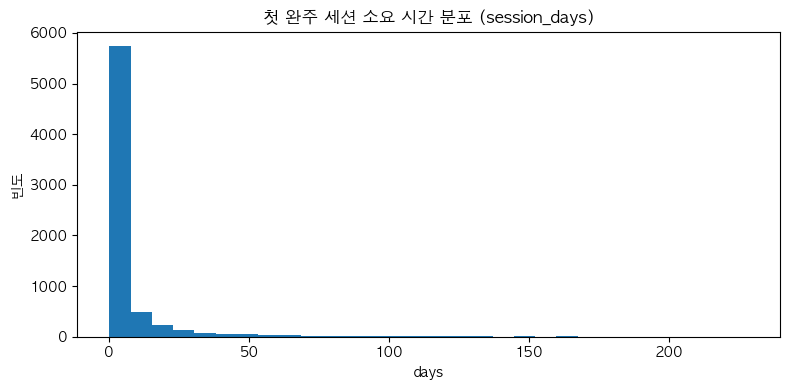

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(
    analysis_base.loc[analysis_base['pre_sub_completion_any'] == 1, 'session_days_to_first_completion'].dropna(),
    bins=30
)
plt.title('첫 완주 세션 소요 시간 분포 (session_days)')
plt.xlabel('days')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()


* median 0.89일
* 75% 4.40일
* max 228.22일
    * 완주가 일어나는 경우 대부분은 빠르게 일어남
    * 단, 매우 늦게 완주하는 일부 case 존재
  
        > 첫 완주는 빠르게 경험되지만 늦게라도 오는 경우가 일부 있음  
        > 전환 관점에서는 초반 3~7일이 핵심 ... 장기 꼬리 구간은 별도 전략이 필요해보임

### 8-4-1. 완주 속도 분포 보정 시각화

`session_days` 분포의 편포가 커서 raw boxplot만으로는 중심부 해석이 어렵기 때문에,
p99 capped / log1p 변환 / 전환 여부별 비교 시각화를 추가로 확인함

session_days p99: 102.84


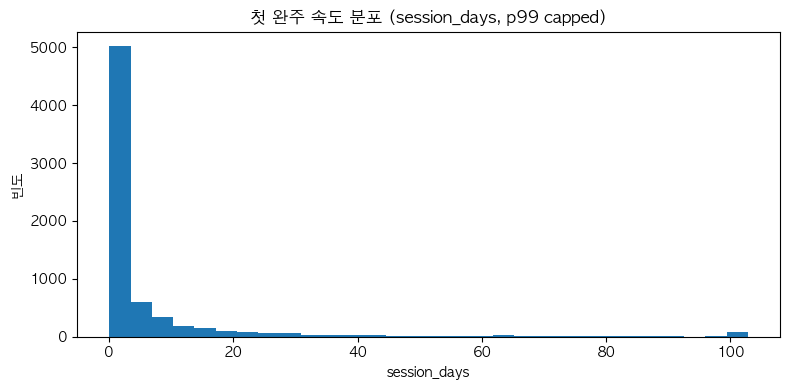

In [ ]:
#p99 histo (백분위 99이상 99값으로 변환)
session_speed = analysis_base.loc[
    analysis_base['pre_sub_completion_any'] == 1,
    'session_days_to_first_completion'
].dropna().copy()

session_p99 = session_speed.quantile(0.99)
session_speed_capped = session_speed.clip(upper=session_p99)

print('session_days p99:', round(session_p99, 2))

plt.figure(figsize=(8, 4))
plt.hist(session_speed_capped, bins=30)
plt.title('첫 완주 속도 분포 (session_days, p99 capped)')
plt.xlabel('session_days')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

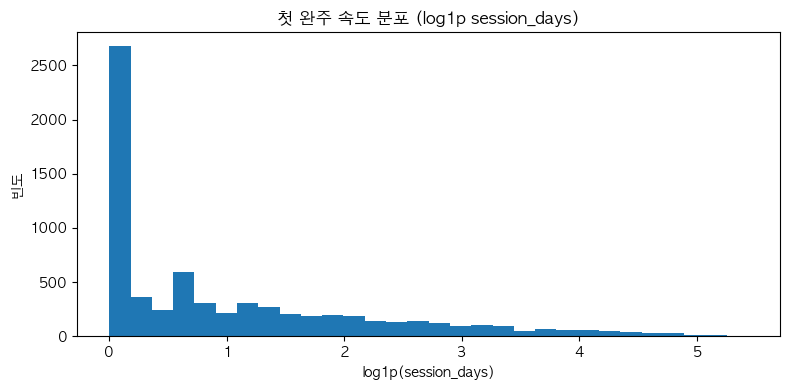

In [ ]:
#log1p 변환 -> 큰값 압축(편포 완화)
session_speed = analysis_base.loc[
    analysis_base['pre_sub_completion_any'] == 1,
    'session_days_to_first_completion'
].dropna().copy()

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(session_speed), bins=30)
plt.title('첫 완주 속도 분포 (log1p session_days)')
plt.xlabel('log1p(session_days)')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

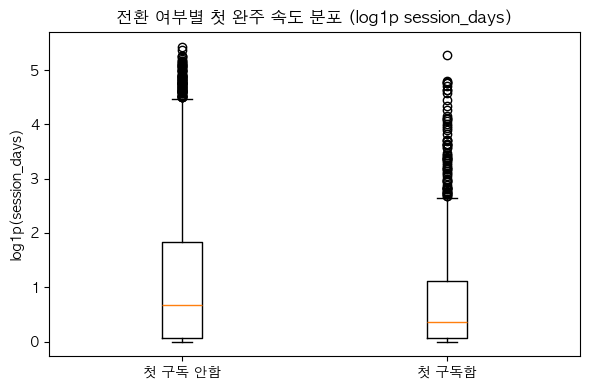

In [ ]:
speed_compare_df = analysis_base_a.loc[
    analysis_base_a['pre_sub_completion_any'] == 1,
    ['session_days_to_first_completion', 'first_subscribed']
].dropna().copy()

speed_compare_df['전환여부'] = np.where(
    speed_compare_df['first_subscribed'] == 1,
    '첫 구독함',
    '첫 구독 안함'
)

speed_nonpay = np.log1p(
    speed_compare_df.loc[
        speed_compare_df['전환여부'] == '첫 구독 안함',
        'session_days_to_first_completion'
    ]
)

speed_pay = np.log1p(
    speed_compare_df.loc[
        speed_compare_df['전환여부'] == '첫 구독함',
        'session_days_to_first_completion'
    ]
)

plt.figure(figsize=(6, 4))
plt.boxplot([speed_nonpay, speed_pay], labels=['첫 구독 안함', '첫 구독함'])
plt.title('전환 여부별 첫 완주 속도 분포 (log1p session_days)')
plt.ylabel('log1p(session_days)')
plt.tight_layout()
plt.show()

### 8-5. 7일 내 첫 완주 여부와 난이도 분포 확인

In [ ]:
within7_summary = (
    analysis_base.loc[analysis_base['pre_sub_completion_any'] == 1]
    .groupby('within_7d_first_completion', as_index=False)
    .agg(유저수=('user_id', 'nunique'))
)

within7_summary['구분'] = np.where(within7_summary['within_7d_first_completion'] == 1, '7일 이내', '7일 초과')
display(within7_summary[['구분', '유저수']])

,구분,유저수
0,7일 초과,1314
1,7일 이내,5668


* 완주자 중 7일 이내 완주 비중: 약 81.2%

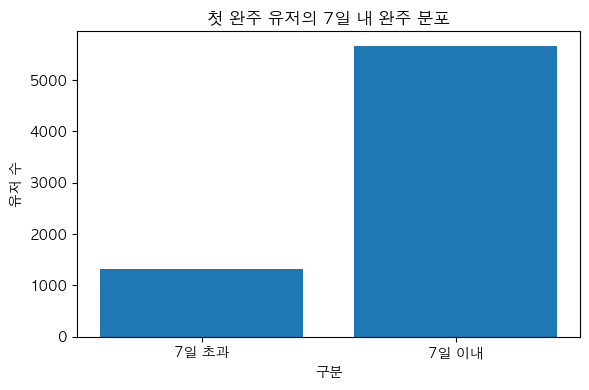

In [ ]:
plt.figure(figsize=(6, 4))
temp = within7_summary[['구분', '유저수']].copy()
plt.bar(temp['구분'], temp['유저수'])
plt.title('첫 완주 유저의 7일 내 완주 분포')
plt.xlabel('구분')
plt.ylabel('유저 수')
plt.tight_layout()
plt.show()

In [ ]:
difficulty_dist = (
    analysis_base.loc[analysis_base['pre_sub_completion_any'] == 1]
    .groupby('first_completion_difficulty', dropna=False, as_index=False)
    .agg(유저수=('user_id', 'nunique'))
    .sort_values('유저수', ascending=False)
)

display(difficulty_dist)

,first_completion_difficulty,유저수
1,beginner,5858
3,intermediate,572
0,advanced,504
2,hard,48


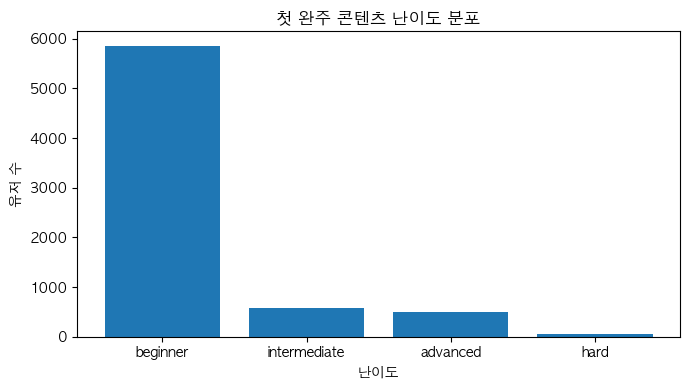

In [ ]:
difficulty_plot = difficulty_dist.dropna(subset=['first_completion_difficulty']).copy()

plt.figure(figsize=(7, 4))
plt.bar(difficulty_plot['first_completion_difficulty'].astype(str), difficulty_plot['유저수'])
plt.title('첫 완주 콘텐츠 난이도 분포')
plt.xlabel('난이도')
plt.ylabel('유저 수')
plt.tight_layout()
plt.show()

* 첫 완주 난이도는 beginner가 압도적
* but, 이는 실제 난이도 효과라기보다는 콘텐츠 공급구조가 반영된 결과로 보임
    * 애초에 난이도별 콘텐츠 수 분포도 begin > inter > adv > hard 순이었음
        > * 이후 가설 검정 파트에서 난이도별 전환"비율"에 대한 카이검정  
            -> 기대빈도와 비교했을 때 전환빈도에 차이가 있는지 확인  
                    (즉, 실제로 난이도의 효과가 존재하는지 통계검정)
                  
        > * if, 실제로 beginner에서 완주가 더 많이 발생하고 이것이 전환으로 이어진다면  
            ->  온보딩용 쉬운 첫 성공 경험이 서비스 설계 포인트일 수 있음  
            -> 즉, 처음 들어온 유저가 너무 어렵지 않은 콘텐츠를 빨리 끝내보게 해주는 게 중요

### 8-6. 초기 7일 몰입도 확인

In [ ]:
immersion_summary = (
    analysis_base
    .agg(
        mean_7일start수=('initial_7d_start_cnt', 'mean'),
        median_7일start수=('initial_7d_start_cnt', 'median'),
        mean_7일콘텐츠수=('initial_7d_started_content_cnt', 'mean'),
        median_7일콘텐츠수=('initial_7d_started_content_cnt', 'median')
    )
    .round(2)
)
display(immersion_summary)

,initial_7d_start_cnt,initial_7d_started_content_cnt
mean_7일start수,1.43,NaN
median_7일start수,1.00,NaN
mean_7일콘텐츠수,NaN,1.43
median_7일콘텐츠수,NaN,1.00


In [ ]:
immersion_bucket_summary = (
    analysis_base
    .groupby('initial_7d_start_bucket', observed=False, as_index=False)
    .agg(유저수=('user_id', 'nunique'))
)

display(immersion_bucket_summary)

,initial_7d_start_bucket,유저수
0,1회,25343
1,2회,4565
2,3~4회,2270
3,5회 이상,818


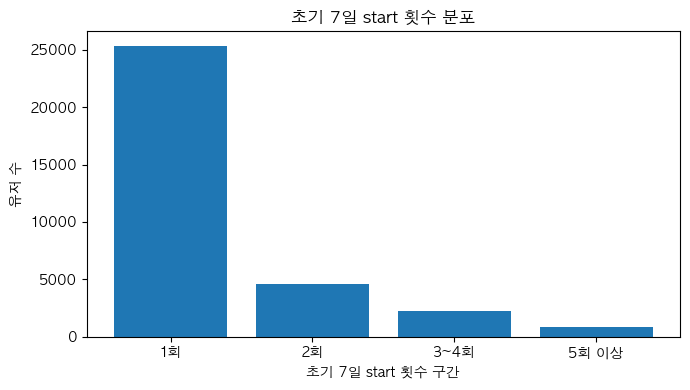

In [ ]:
plt.figure(figsize=(7, 4))
temp = immersion_bucket_summary.dropna(subset=['initial_7d_start_bucket']).copy()
plt.bar(temp['initial_7d_start_bucket'].astype(str), temp['유저수'])
plt.title('초기 7일 start 횟수 분포')
plt.xlabel('초기 7일 start 횟수 구간')
plt.ylabel('유저 수')
plt.tight_layout()
plt.show()

__첫 start_content로부터 7일 내 start_content 수__
* 평균 1.43회, 중앙값 1회
* 1회 유저가 25,343명으로 대부분

    > * 대부분 유저는 첫 7일 동안 반복 학습으로 이어지지 않는 것으로 보임
    > * `두 번째 start` 자체가 굉장히 중요한 signal일 수 있음

### 8-7. 유지·매출 지표와 eligibility 확인
eligibility: 해당 지표를 끝까지 관측할 수 있을 만큼 데이터 뒤쪽 기간이 충분한 유저인지  
즉, 관측창이 확보된 유저수 확인  
* eligible_30d
    * first_start_time <= ANALYSIS_END_EXCL - 30일
    * 즉 첫 학습 시작 후 30일 구간을 끝까지 볼 수 있는 유저
* eligible_90d
    * first_start_time <= ANALYSIS_END_EXCL - 90일
    * 즉 첫 학습 시작 후 90일 구간을 끝까지 볼 수 있는 유저
* eligible_return_90d
    * first_sub_time이 존재하고
    * first_sub_time <= ANALYSIS_END_EXCL - 90일
    * 즉 첫 구독 이후 90일 내 renew/resub를 끝까지 볼 수 있는 유저


In [ ]:
eligibility_summary = pd.DataFrame({
    '지표': ['eligible_30d', 'eligible_90d', 'eligible_return_90d'],
    '유저수': [
        analysis_base.loc[analysis_base['eligible_30d'] == 1, 'user_id'].nunique(),
        analysis_base.loc[analysis_base['eligible_90d'] == 1, 'user_id'].nunique(),
        analysis_base_b.loc[analysis_base_b['eligible_return_90d'] == 1, 'user_id'].nunique()
    ]
})
display(eligibility_summary)

,지표,유저수
0,eligible_30d,28490
1,eligible_90d,21199
2,eligible_return_90d,1573


In [ ]:
ltv_desc = analysis_base.loc[analysis_base['eligible_90d'] == 1, ['paid_30d', 'paid_90d', 'ltv_30d', 'ltv_90d']].describe().round(2)
display(ltv_desc)

,paid_30d,paid_90d,ltv_30d,ltv_90d
count,21199.00,21199.00,21199.00,21199.00
mean,2564.91,2848.97,3048.71,5855.12
std,14948.73,15724.90,15653.67,20052.43
min,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00
75%,0.00,0.00,0.00,0.00
max,131600.00,131600.00,263200.00,279120.00


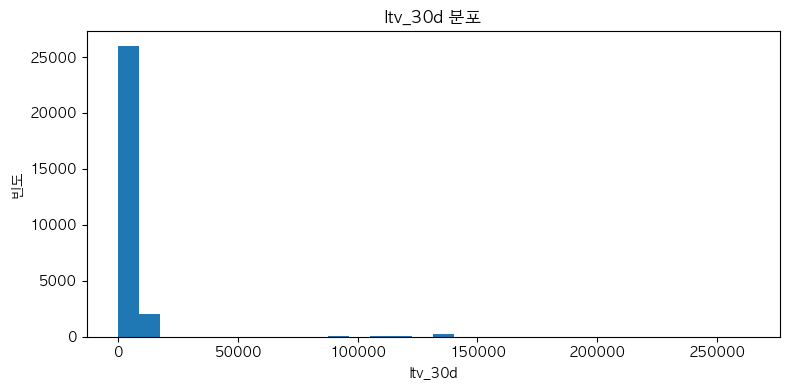

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(analysis_base.loc[analysis_base['eligible_30d'] == 1, 'ltv_30d'], bins=30)
plt.title('ltv_30d 분포')
plt.xlabel('ltv_30d')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

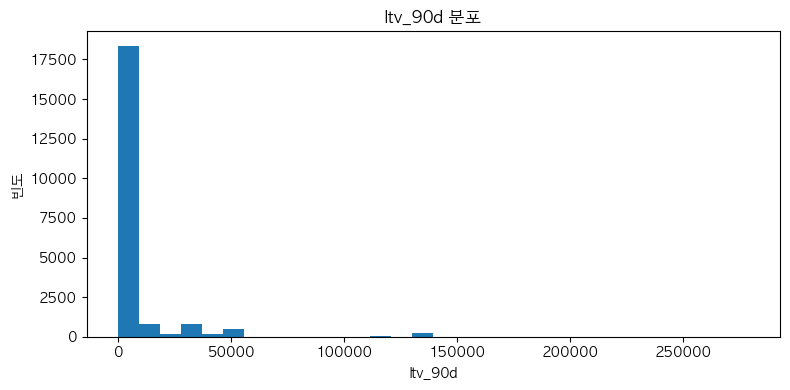

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(analysis_base.loc[analysis_base['eligible_90d'] == 1, 'ltv_90d'], bins=30)
plt.title('ltv_90d 분포')
plt.xlabel('ltv_90d')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

### 8-7-1. LTV 분포 보정 시각화

`ltv_30d`, `ltv_90d`는 0이 많은 zero-inflated 분포이면서 상단 꼬리가 길어 raw histogram만으로는 해석이 제한적  
    -> log 변환 및 양수 LTV 유저 기준 시각화를 추가로 확인함

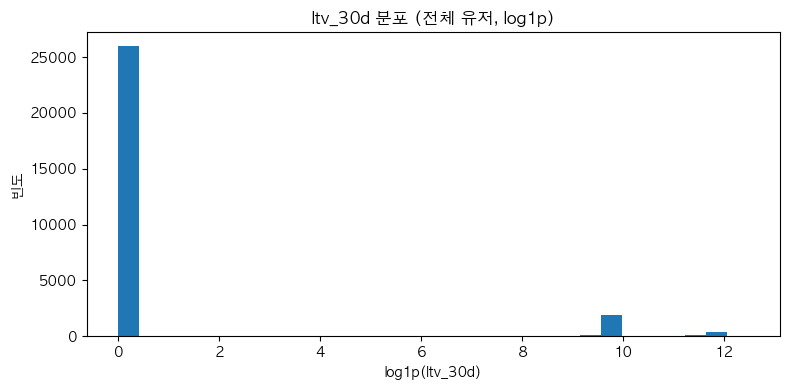

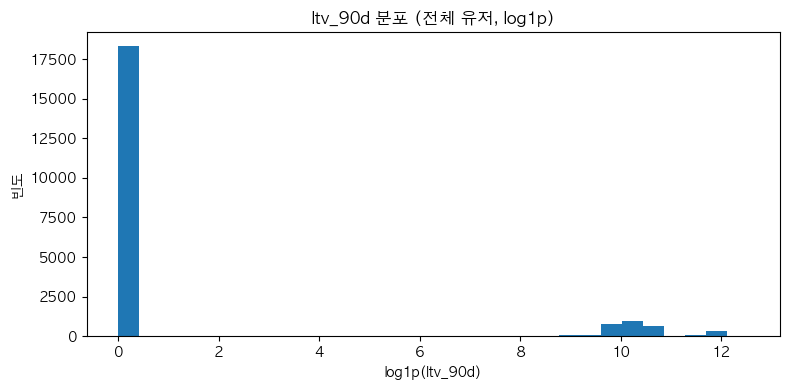

In [ ]:
# 전체유저 기준 ㅣog1p histo
ltv30_all = analysis_base.loc[analysis_base['eligible_30d'] == 1, 'ltv_30d'].fillna(0).copy()
ltv90_all = analysis_base.loc[analysis_base['eligible_90d'] == 1, 'ltv_90d'].fillna(0).copy()

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(ltv30_all), bins=30)
plt.title('ltv_30d 분포 (전체 유저, log1p)')
plt.xlabel('log1p(ltv_30d)')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(ltv90_all), bins=30)
plt.title('ltv_90d 분포 (전체 유저, log1p)')
plt.xlabel('log1p(ltv_90d)')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

양수 ltv_30d 유저 수: 2529
양수 ltv_90d 유저 수: 2897


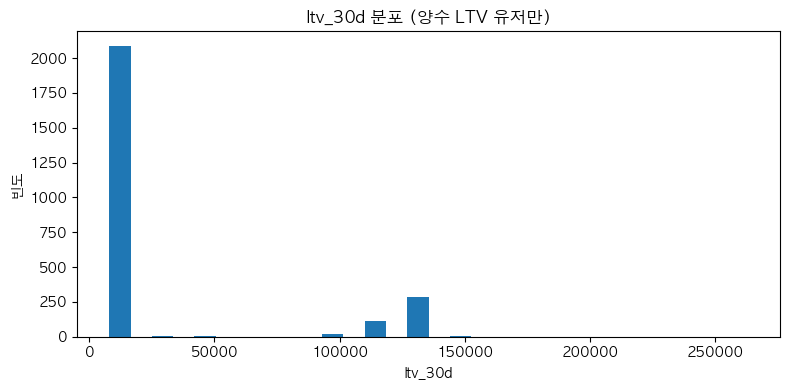

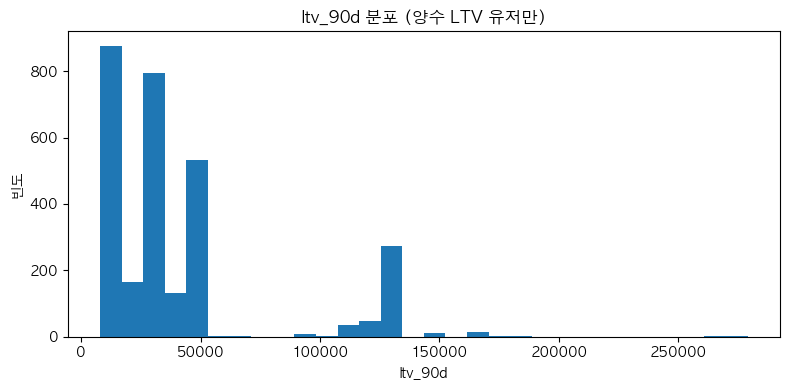

In [ ]:
# 양수 ㅣtv 유저만 histo
ltv30_pos = analysis_base.loc[
    (analysis_base['eligible_30d'] == 1) &
    (analysis_base['ltv_30d'] > 0),
    'ltv_30d'
].copy()

ltv90_pos = analysis_base.loc[
    (analysis_base['eligible_90d'] == 1) &
    (analysis_base['ltv_90d'] > 0),
    'ltv_90d'
].copy()

print('양수 ltv_30d 유저 수:', len(ltv30_pos))
print('양수 ltv_90d 유저 수:', len(ltv90_pos))

plt.figure(figsize=(8, 4))
plt.hist(ltv30_pos, bins=30)
plt.title('ltv_30d 분포 (양수 LTV 유저만)')
plt.xlabel('ltv_30d')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(ltv90_pos, bins=30)
plt.title('ltv_90d 분포 (양수 LTV 유저만)')
plt.xlabel('ltv_90d')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

ltv_30d p95: 131600.0
ltv_90d p95: 131600.0


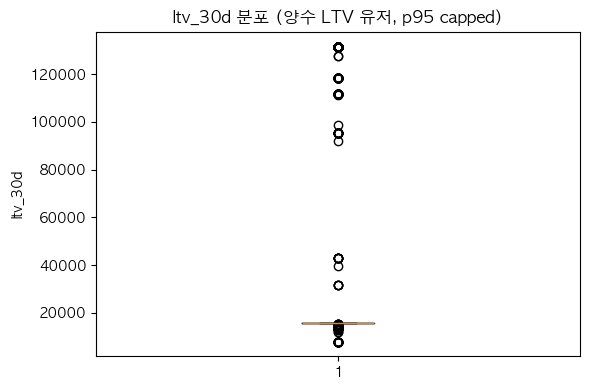

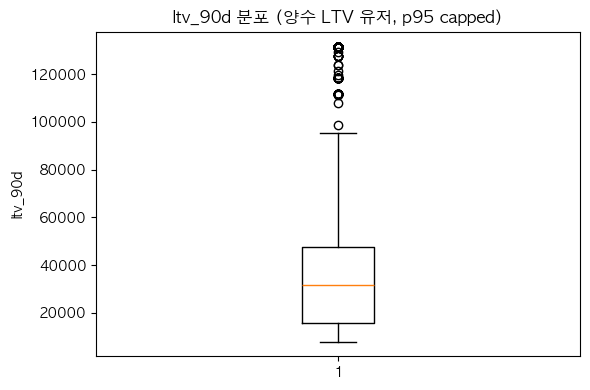

In [ ]:
# 양수 ltv 유저만 p95 capped boxplot
ltv30_pos = analysis_base.loc[
    (analysis_base['eligible_30d'] == 1) &
    (analysis_base['ltv_30d'] > 0),
    'ltv_30d'
].copy()

ltv90_pos = analysis_base.loc[
    (analysis_base['eligible_90d'] == 1) &
    (analysis_base['ltv_90d'] > 0),
    'ltv_90d'
].copy()

ltv30_p95 = ltv30_pos.quantile(0.95)
ltv90_p95 = ltv90_pos.quantile(0.95)

ltv30_pos_capped = ltv30_pos.clip(upper=ltv30_p95)
ltv90_pos_capped = ltv90_pos.clip(upper=ltv90_p95)

print('ltv_30d p95:', round(ltv30_p95, 2))
print('ltv_90d p95:', round(ltv90_p95, 2))

plt.figure(figsize=(6, 4))
plt.boxplot(ltv30_pos_capped)
plt.title('ltv_30d 분포 (양수 LTV 유저, p95 capped)')
plt.ylabel('ltv_30d')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.boxplot(ltv90_pos_capped)
plt.title('ltv_90d 분포 (양수 LTV 유저, p95 capped)')
plt.ylabel('ltv_90d')
plt.tight_layout()
plt.show()

# 9. 가설 검정

## A1. 구독 이전 완주 경험은 첫 구독 전환과 연결되는가?

_가설: __구독 이전에 유효한 완주 경험이 있는 유저는 없는 유저보다 첫 구독 전환율이 높을 것이다.___
  
- 대상: `analysis_base_a` ... start_content보다 먼저 구독한 유저는 제외한 전환 분석용 테이블
- 설명변수: `pre_sub_completion_any` ... 첫구독 이전 완주여부
- 결과변수: `first_subscribed` ... 첫구독 전환
- 분석방법: 교차표, 카이제곱 검정, odds ratio

In [ ]:
a1_df = analysis_base_a.copy()
a1_df['구독이전_완주경험'] = np.where(a1_df['pre_sub_completion_any'] == 1, '있음', '없음')

In [ ]:
a1_summary = (
    a1_df
    .groupby('구독이전_완주경험', as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        전환유저수=('first_subscribed', 'sum')
    )
)

a1_summary['전환율(%)'] = (a1_summary['전환유저수'] / a1_summary['유저수'] * 100).round(2)
display(a1_summary)

,구독이전_완주경험,유저수,전환유저수,전환율(%)
0,없음,23987,1303,5.43
1,있음,6982,1303,18.66


In [ ]:
a1_ct = pd.crosstab(a1_df['구독이전_완주경험'], a1_df['first_subscribed'])
display(a1_ct)

first_subscribed,0,1
구독이전_완주경험,,
없음,22684,1303
있음,5679,1303


In [ ]:
chi2, p, dof, expected = chi2_contingency(a1_ct)
expected_df = pd.DataFrame(expected, index=a1_ct.index, columns=a1_ct.columns)
display(expected_df.round(2))

a = a1_ct.loc['있음', 1] if 1 in a1_ct.columns else 0
b = a1_ct.loc['있음', 0] if 0 in a1_ct.columns else 0
c = a1_ct.loc['없음', 1] if 1 in a1_ct.columns else 0
d = a1_ct.loc['없음', 0] if 0 in a1_ct.columns else 0
odds_ratio = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))

print('chi2:', chi2)
print('p_value:', p)
print('odds_ratio:', odds_ratio)

first_subscribed,0,1
구독이전_완주경험,,
없음,21968.53,2018.47
있음,6394.47,587.53


chi2: 1226.5343499366288
p_value: 1.0439911541438727e-268
odds_ratio: 3.994101593450128


* 완주경험 여부와 첫 구독 전환 간에는 매우 유의한 관련성 존재(chi2=1226.53, p<.001)

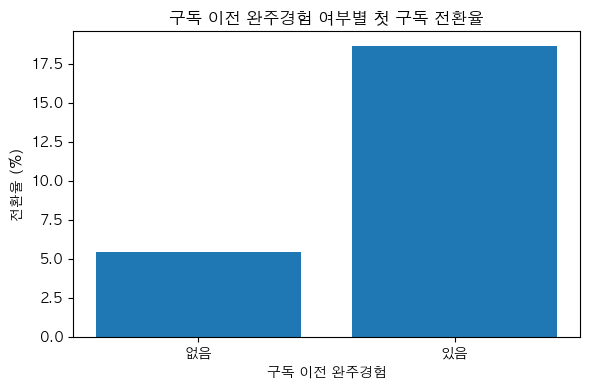

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(a1_summary['구독이전_완주경험'], a1_summary['전환율(%)'])
plt.title('구독 이전 완주경험 여부별 첫 구독 전환율')
plt.xlabel('구독 이전 완주경험')
plt.ylabel('전환율 (%)')
plt.tight_layout()
plt.show()

* 완주 없음: 5.43%
* 완주 있음: 18.66%
* odds 비 약 3.99
* 매우 유의
* `완주 경험이 있는 유저가 첫 구독으로 이어질 가능성이 훨씬 높게 나타남`
  
    > * 완주 경험은 콘텐츠 가치 체험이 끝까지 일어났다는 뜻으로, 서비스 효용을 실제로 느꼈을 가능성이 큼
    > * 다만, 원래 의도가 높은 유저가 완주도 하고 결제도 했을 가능성도 큼
    > * 그럼에도 완주 자체는 좋은 초기성공 KPI로 활용될 수 있음을 시사
  
    > * 초기 완주 경험을 유저로 하여금 “할 수 있다”는 자기효능감을 제공했을 것  
    >   -> 이는 유저의 불확실성을 감소, 즉 유료 전환 전 “돈 내도 괜찮겠다”는 판단이 쉬워지게 만들었을 수 있음
    > * 또한 연구에 따르면 진전 경험은 학습자의 동기를 강화시키는 key 요소(progress principle)
    > * 한 단위의 완료 경험(e.g., 완주경험) -> 인지적 종결 -> 다음 상위단계 행동(e.g., 구독)으로의 trigger가 됨

## A2. 7일 내 첫 완주는 첫 구독 전환과 연결되는가?

- 가설: 첫 완주를 `session_days` 기준 7일 이내에 경험한 유저는 7일 초과 유저보다 첫 구독 전환율이 높을 것이다.
- 대상: `pre_sub_completion_any = 1` 인 유저
- 설명변수: `within_7d_first_completion`
- 결과변수: `first_subscribed`
- 분석방법: 교차표, 카이제곱 검정


In [ ]:
a2_df = analysis_base_a[analysis_base_a['pre_sub_completion_any'] == 1].copy()
a2_df['7일내_첫완주'] = np.where(a2_df['within_7d_first_completion'] == 1, '7일 이내', '7일 초과')

In [ ]:
a2_summary = (
    a2_df
    .groupby('7일내_첫완주', as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        전환유저수=('first_subscribed', 'sum')
    )
)

a2_summary['전환율(%)'] = (a2_summary['전환유저수'] / a2_summary['유저수'] * 100).round(2)
display(a2_summary)

,7일내_첫완주,유저수,전환유저수,전환율(%)
0,7일 이내,5668,1167,20.59
1,7일 초과,1314,136,10.35


In [ ]:
a2_ct = pd.crosstab(a2_df['7일내_첫완주'], a2_df['first_subscribed'])
display(a2_ct)

first_subscribed,0,1
7일내_첫완주,,
7일 이내,4501,1167
7일 초과,1178,136


In [ ]:
chi2, p, dof, expected = chi2_contingency(a2_ct)
expected_df = pd.DataFrame(expected, index=a2_ct.index, columns=a2_ct.columns)
display(expected_df.round(2))

print('chi2:', chi2)
print('p_value:', p)

first_subscribed,0,1
7일내_첫완주,,
7일 이내,4610.22,1057.78
7일 초과,1068.78,245.22


chi2: 73.0020728621067
p_value: 1.2951374215526423e-17


* 7일내 완주여부에 따른 첫구독 전환율 차이는 매우 유의한 것으로 나타남(chi2=73.00, p<.001)

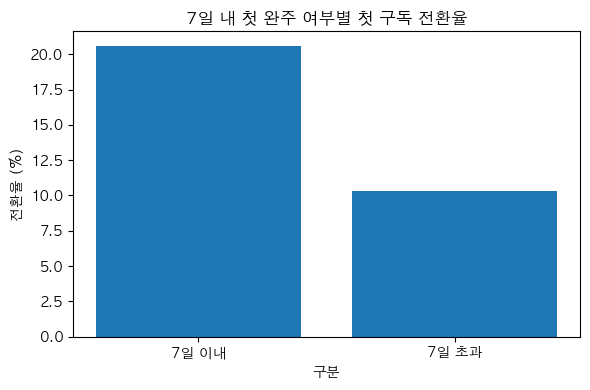

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(a2_summary['7일내_첫완주'], a2_summary['전환율(%)'])
plt.title('7일 내 첫 완주 여부별 첫 구독 전환율')
plt.xlabel('구분')
plt.ylabel('전환율 (%)')
plt.tight_layout()
plt.show()

* 7일 이내: 20.59%
* 7일 초과: 10.35%
* `단순히 완주하느냐뿐 아니라 빨리 완주하느냐 역시 중요`
  
    > * 빠른 완주는 초기 관심이 살아 있을 때 효용 체험이 일어났다는 뜻
    > * 반면 늦은 완주는 이미 관심이 약해진 뒤 뒤늦게 성취가 왔을 가능성이 있음
  
    > * 사람들은 즉시 보상과 강화가 늦어지면 동기가 떨어짐
    > * 빠른 성취(완주 경험)은 "이 서비스가 나와 맞다"거나 "이 서비스는 나에게 가치/효용이 있다"는 인상을 빠르게 만들었을 것

## A3. 첫 완주 속도는 첫 구독 전환과 연결되는가?

- 가설: 첫 완주까지 걸린 `session_days`가 짧을수록 첫 구독 전환율이 높을 것이다.
- 대상: `pre_sub_completion_any = 1` 인 유저
- 설명변수: `session_bucket`, `session_days_to_first_completion`
- 결과변수: `first_subscribed`
- 분석방법: 속도구간별 전환율 비교, 카이제곱 검정, 연속형 보조 점검


In [ ]:
a3_df = analysis_base_a[analysis_base_a['pre_sub_completion_any'] == 1].copy()
a3_df = a3_df.dropna(subset=['session_bucket']).copy()


In [ ]:
a3_summary = (
    a3_df
    .groupby('session_bucket', observed=False, as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        전환유저수=('first_subscribed', 'sum')
    )
)

a3_summary['전환율(%)'] = (a3_summary['전환유저수'] / a3_summary['유저수'] * 100).round(2)
display(a3_summary)


,session_bucket,유저수,전환유저수,전환율(%)
0,1일 이내,3714,808,21.76
1,1~3일,1142,248,21.72
2,3~7일,812,111,13.67
3,7~14일,492,66,13.41
4,14일 초과,822,70,8.52


In [ ]:
a3_ct = pd.crosstab(a3_df['session_bucket'], a3_df['first_subscribed'])
display(a3_ct)


first_subscribed,0,1
session_bucket,,
1일 이내,2906,808
1~3일,894,248
3~7일,701,111
7~14일,426,66
14일 초과,752,70


In [ ]:
chi2, p, dof, expected = chi2_contingency(a3_ct)
expected_df = pd.DataFrame(expected, index=a3_ct.index, columns=a3_ct.columns)
display(expected_df.round(2))

print('chi2:', chi2)
print('p_value:', p)

first_subscribed,0,1
session_bucket,,
1일 이내,3020.88,693.12
1~3일,928.88,213.12
3~7일,660.46,151.54
7~14일,400.18,91.82
14일 초과,668.60,153.40


chi2: 108.4354744731276
p_value: 1.5689695051689223e-22


* 카이검정 결과, 완주 속도 구간에 따른 전환율 차이는 유의한 것으로 나타남(chi2=108.44, p<.001)

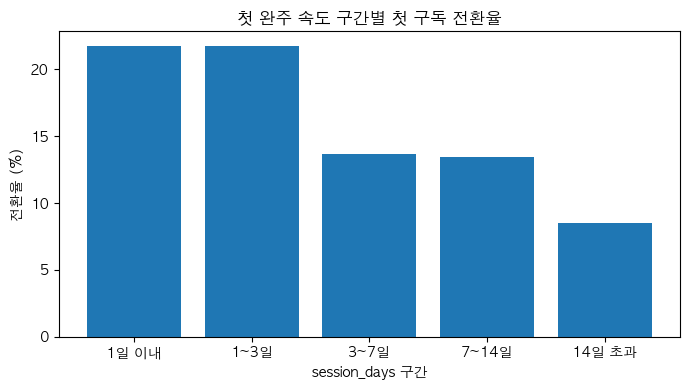

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(a3_summary['session_bucket'].astype(str), a3_summary['전환율(%)'])
plt.title('첫 완주 속도 구간별 첫 구독 전환율')
plt.xlabel('session_days 구간')
plt.ylabel('전환율 (%)')
plt.tight_layout()
plt.show()


In [ ]:
# 연속형 session_days 보조 점검
temp = a3_df[['session_days_to_first_completion', 'first_subscribed']].dropna().copy()

X = sm.add_constant(temp[['session_days_to_first_completion']])
y = temp['first_subscribed']
model = sm.Logit(y, X).fit(disp=0)

coef = model.params['session_days_to_first_completion']
conf = model.conf_int().loc['session_days_to_first_completion']

print('coef:', coef)
print('odds_ratio:', np.exp(coef))
print('ci_low:', np.exp(conf[0]))
print('ci_high:', np.exp(conf[1]))
print('p_value:', model.pvalues['session_days_to_first_completion'])


coef: -0.020539554635248928
odds_ratio: 0.9796699452207794
ci_low: 0.9736719388021668
ci_high: 0.9857049005125844
p_value: 5.560590890369485e-11


* 로지스틱 회귀(session_days -> first_subscribed) 분석 결과, 전환여부(y)에 대한 완주일수(x)의 회귀계수(-0.02)는 유의한 것으로 나타남(ㅔ<.001)
    * session_day(완주일수)가 1일 증가할때마다 odds가 약 2.03%(1-0.9797) 감소
    > * 완주속도 변수를 연속형으로 봤을 때도 느릴수록 전환이 낮아지는 경향성 유의

In [ ]:
# session_days 추가 단조성 점검
temp = a3_df[['session_days_to_first_completion', 'first_subscribed']].dropna().copy()
corr, p = spearmanr(temp['session_days_to_first_completion'], temp['first_subscribed'])

print('session_days vs first_subscribed Spearman corr:', corr)
print('p_value:', p)


session_days vs first_subscribed Spearman corr: -0.07985985012089004
p_value: 2.349993182827646e-11


* spearman 순위상관 검정 결과, session_dyas와 first_subscription 사이의 단조관계 역시 유의한 것으로 나타남(corr=-0.0799, p<.001)
    * corr가 음수로 완주가 느릴수록 전환이 낮아지는 결과 dup, 단 상관 자체는 다소 낮음

* 속도가 느릴수록 전환율이 낮아지는 패턴은 분명하게 나타남.
* 단, 1일 이내와 1~3일은 거의 차이가 없음
  
    > * 7일보다 3일이 핵심 기점일 수 있음
    > * 즉, “초반 3일 안에 완주했는가”가 더 실무적인 기준일 수 있음

## A 추가분석: 3일 내 첫 완주는 첫 구독 전환과 연결되는가?
* A3에서 확인한 패턴을 바탕으로 A2의 분석을 3일 내로 변경하여 추가분석

In [ ]:
a2_3d_df = analysis_base_a[analysis_base_a['pre_sub_completion_any'] == 1].copy()
a2_3d_df['within_3d_first_completion'] = np.where(
    a2_3d_df['session_days_to_first_completion'].notna() &
    (a2_3d_df['session_days_to_first_completion'] <= 3),
    1, 0
)
a2_3d_df['3일내_첫완주'] = np.where(
    a2_3d_df['within_3d_first_completion'] == 1,
    '3일 이내',
    '3일 초과'
)

In [ ]:
a2_3d_summary = (
    a2_3d_df
    .groupby('3일내_첫완주', as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        전환유저수=('first_subscribed', 'sum')
    )
)

a2_3d_summary['전환율(%)'] = (
    a2_3d_summary['전환유저수'] / a2_3d_summary['유저수'] * 100
).round(2)

display(a2_3d_summary)

,3일내_첫완주,유저수,전환유저수,전환율(%)
0,3일 이내,4856,1056,21.75
1,3일 초과,2126,247,11.62


In [ ]:
a2_3d_ct = pd.crosstab(a2_3d_df['3일내_첫완주'], a2_3d_df['first_subscribed'])
display(a2_3d_ct)

chi2, p, dof, expected = chi2_contingency(a2_3d_ct)
expected_df = pd.DataFrame(expected, index=a2_3d_ct.index, columns=a2_3d_ct.columns)
display(expected_df.round(2))

a = a2_3d_ct.loc['3일 이내', 1] if 1 in a2_3d_ct.columns else 0
b = a2_3d_ct.loc['3일 이내', 0] if 0 in a2_3d_ct.columns else 0
c = a2_3d_ct.loc['3일 초과', 1] if 1 in a2_3d_ct.columns else 0
d = a2_3d_ct.loc['3일 초과', 0] if 0 in a2_3d_ct.columns else 0
odds_ratio = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))

print('chi2:', chi2)
print('p_value:', p)
print('odds_ratio:', odds_ratio)

first_subscribed,0,1
3일내_첫완주,,
3일 이내,3800,1056
3일 초과,1879,247


first_subscribed,0,1
3일내_첫완주,,
3일 이내,3949.76,906.24
3일 초과,1729.24,396.76


chi2: 99.25854818161233
p_value: 2.2159804455242388e-23
odds_ratio: 2.111037223969733


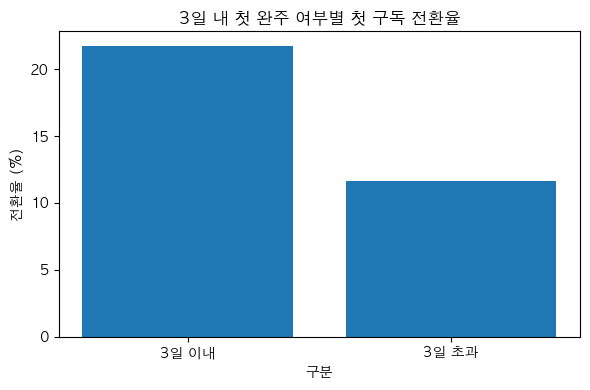

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(a2_3d_summary['3일내_첫완주'], a2_3d_summary['전환율(%)'])
plt.title('3일 내 첫 완주 여부별 첫 구독 전환율')
plt.xlabel('구분')
plt.ylabel('전환율 (%)')
plt.tight_layout()
plt.show()

## A4. 초기 7일 몰입도는 첫 구독 전환과 연결되는가?

- 가설: 최초 start 이후 7일 내 학습량이 많은 유저일수록 첫 구독 전환율이 높을 것이다.
- 대상: `analysis_base_a`
- 설명변수: `initial_7d_start_bucket`, 보조로 `initial_7d_content_bucket`
- 결과변수: `first_subscribed`
- 분석방법: 구간별 전환율 비교, 카이제곱 검정

In [ ]:
a4_df = analysis_base_a.copy()

In [ ]:
a4_summary = (
    a4_df
    .groupby('initial_7d_start_bucket', observed=False, as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        전환유저수=('first_subscribed', 'sum')
    )
)

a4_summary['전환율(%)'] = (a4_summary['전환유저수'] / a4_summary['유저수'] * 100).round(2)
display(a4_summary)

,initial_7d_start_bucket,유저수,전환유저수,전환율(%)
0,1회,24639,790,3.21
1,2회,3984,664,16.67
2,3~4회,1753,772,44.04
3,5회 이상,593,380,64.08


In [ ]:
a4_ct = pd.crosstab(a4_df['initial_7d_start_bucket'], a4_df['first_subscribed'])
display(a4_ct)

first_subscribed,0,1
initial_7d_start_bucket,,
1회,23849,790
2회,3320,664
3~4회,981,772
5회 이상,213,380


In [ ]:
chi2, p, dof, expected = chi2_contingency(a4_ct)
expected_df = pd.DataFrame(expected, index=a4_ct.index, columns=a4_ct.columns)
display(expected_df.round(2))

print('chi2:', chi2)
print('p_value:', p)

first_subscribed,0,1
initial_7d_start_bucket,,
1회,22565.66,2073.34
2회,3648.75,335.25
3~4회,1605.49,147.51
5회 이상,543.10,49.90


chi2: 6490.297159715882
p_value: 0.0


* 카이검정 결과, 초기 7일간 시작한 콘텐츠 수에 따른 첫구독 전환율 차이는 매우 유의(chi2=6490.30. p<.001)

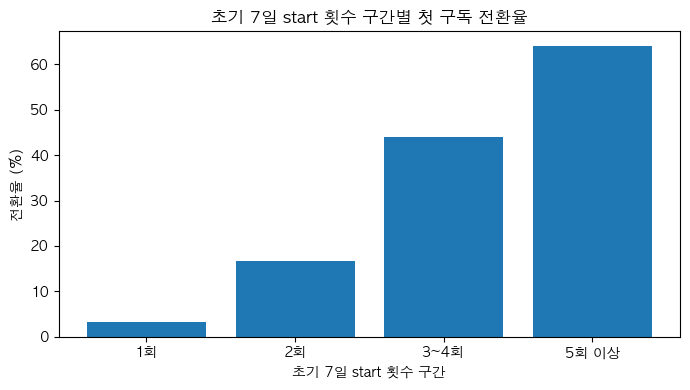

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(a4_summary['initial_7d_start_bucket'].astype(str), a4_summary['전환율(%)'])
plt.title('초기 7일 start 횟수 구간별 첫 구독 전환율')
plt.xlabel('초기 7일 start 횟수 구간')
plt.ylabel('전환율 (%)')
plt.tight_layout()
plt.show()

__초기 7일 콘텐츠 시작 횟수__  
1회: 3.21%  
2회: 16.67%  
3~4회: 44.04%  
5회 이상: 64.08%  
* `초기 7일 몰입도`는 가장 강한 전환 신호로 확인됨
   
    > * 반복 행동은 단순 관심이 아니라 습관화 시작 신호로 볼 수 있음
    > * 여러 콘텐츠를 건드리는 유저 -> 탐색 깊이 & 관여도 높음
  
    > * 반복 노출과 반복 행동 -> 애착과 투자감을 강화시킴
    > * commitment/consistency 측면에서 이미 시간과 주의를 투자한 사용자는 유료 전환 저항이 낮아질 수 있음

In [ ]:
# 보조: 초기 7일 고유 콘텐츠 수
a4_content_summary = (
    a4_df
    .groupby('initial_7d_content_bucket', observed=False, as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        전환유저수=('first_subscribed', 'sum')
    )
)

a4_content_summary['전환율(%)'] = (
    a4_content_summary['전환유저수'] / a4_content_summary['유저수'] * 100
).round(2)

display(a4_content_summary)

,initial_7d_content_bucket,유저수,전환유저수,전환율(%)
0,1개,24645,792,3.21
1,2개,3981,664,16.68
2,3개 이상,2343,1150,49.08


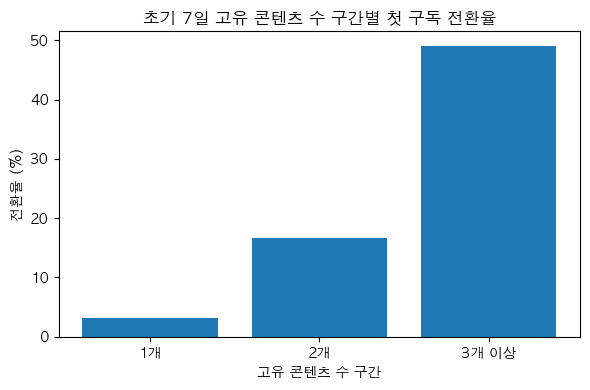

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(a4_content_summary['initial_7d_content_bucket'].astype(str), a4_content_summary['전환율(%)'])
plt.title('초기 7일 고유 콘텐츠 수 구간별 첫 구독 전환율')
plt.xlabel('고유 콘텐츠 수 구간')
plt.ylabel('전환율 (%)')
plt.tight_layout()
plt.show()

## A5. 첫 완주 난이도는 첫 구독 전환과 연결되는가?

- 가설: 첫 완주 콘텐츠 난이도에 따라 첫 구독 전환율이 달라질 것이다.
- 대상: `pre_sub_completion_any = 1` 인 유저
- 설명변수: `first_completion_difficulty`
- 결과변수: `first_subscribed`
- 분석방법: group 비교, 카이제곱 검정

In [ ]:
a5_df = analysis_base_a[analysis_base_a['pre_sub_completion_any'] == 1].copy()
a5_df = a5_df.dropna(subset=['first_completion_difficulty']).copy()

In [ ]:
a5_summary = (
    a5_df
    .groupby('first_completion_difficulty', as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        전환유저수=('first_subscribed', 'sum')
    )
)

a5_summary['전환율(%)'] = (a5_summary['전환유저수'] / a5_summary['유저수'] * 100).round(2)
display(a5_summary)

,first_completion_difficulty,유저수,전환유저수,전환율(%)
0,advanced,504,3,0.60
1,beginner,5858,1291,22.04
2,hard,48,0,0.00
3,intermediate,572,9,1.57


In [ ]:
a5_ct = pd.crosstab(a5_df['first_completion_difficulty'], a5_df['first_subscribed'])
display(a5_ct)

first_subscribed,0,1
first_completion_difficulty,,
advanced,501,3
beginner,4567,1291
hard,48,0
intermediate,563,9


In [ ]:
chi2, p, dof, expected = chi2_contingency(a5_ct)
expected_df = pd.DataFrame(expected, index=a5_ct.index, columns=a5_ct.columns)
display(expected_df.round(2))

print('chi2:', chi2)
print('p_value:', p)

first_subscribed,0,1
first_completion_difficulty,,
advanced,409.94,94.06
beginner,4764.76,1093.24
hard,39.04,8.96
intermediate,465.25,106.75


chi2: 273.4198730148649
p_value: 5.617768124480832e-59


* 카이검정 결과 난이도와 첫구독 전환 간에는 유의한 관련성 존재(chi2=273.42, p<.001)
    * 단, hard는 표본이 작아 해석에 한계 존재.

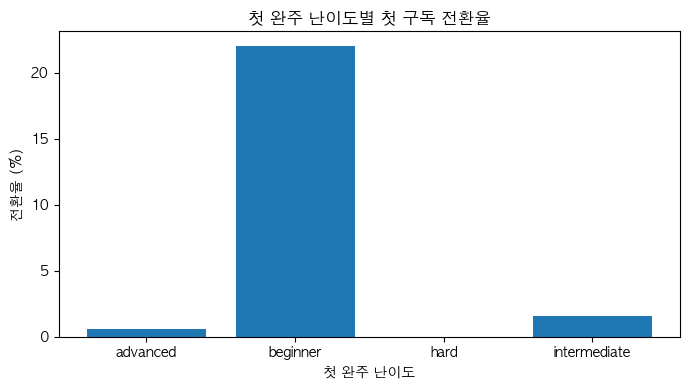

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(a5_summary['first_completion_difficulty'].astype(str), a5_summary['전환율(%)'])
plt.title('첫 완주 난이도별 첫 구독 전환율')
plt.xlabel('첫 완주 난이도')
plt.ylabel('전환율 (%)')
plt.tight_layout()
plt.show()

__첫완주 난이도별 첫구독 전환율__  
beginner: 22.04%  
advanced: 0.60%  
intermediate: 1.57%  
hard: 0%  
* `쉬운 콘텐츠를 먼저 완주한 유저가 (콘텐츠 비중을 고려했을 때에도) 압도적으로 전환이 높음`

    > * 해석 1: 실제 난이도 효과일 가능성   
    >   -> 쉬운 과제가 더 높은 효능감을 제공하여 더 높은 전환율로 이어졌을 수 있음
    > * 해석 2: 온보딩 콘텐츠 효과일 가능성  
    >   -> beginner 콘텐츠가 첫 성공을 만들도록 설계됐거나, 처음 접하는 유저가 접근 가능한 콘텐츠가 대부분 beginner였을 수 있음

## B1. 구독 이전 완주 경험은 이후 유지·매출과 연결되는가?

- 가설: 첫 구독 이전 완주 경험이 있는 유저는 이후 90일 유지와 30/90일 LTV가 더 높을 것이다.
- 대상: `analysis_base_b`
- 설명변수: `pre_sub_completion_any`
- 결과변수:
  - 유지: `renew_90d`, `resub_90d`, `has_any_return_90d`
  - 매출: `ltv_30d`, `ltv_90d`
- 분석방법: 카이제곱 검정, Mann-Whitney U(편포 심함 & 평균 왜곡 가능성 고려)

In [ ]:
b1_df = analysis_base_b.copy()
b1_df['첫구독전_완주경험'] = np.where(b1_df['pre_sub_completion_any'] == 1, '있음', '없음')

In [ ]:
b1_return_df = b1_df[b1_df['eligible_return_90d'] == 1].copy()

b1_return_summary = (
    b1_return_df
    .groupby('첫구독전_완주경험', as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        renew유저수=('renew_90d', 'sum'),
        resub유저수=('resub_90d', 'sum'),
        any_return유저수=('has_any_return_90d', 'sum')
    )
)

b1_return_summary['renew비율(%)'] = (b1_return_summary['renew유저수'] / b1_return_summary['유저수'] * 100).round(2)
b1_return_summary['resub비율(%)'] = (b1_return_summary['resub유저수'] / b1_return_summary['유저수'] * 100).round(2)
b1_return_summary['any_return비율(%)'] = (b1_return_summary['any_return유저수'] / b1_return_summary['유저수'] * 100).round(2)

display(b1_return_summary)

,첫구독전_완주경험,유저수,renew유저수,resub유저수,any_return유저수,renew비율(%),resub비율(%),any_return비율(%)
0,없음,767,441,6,446,57.50,0.78,58.15
1,있음,806,512,5,517,63.52,0.62,64.14


* 첫구독전 완주경험이 있는 유저가 없는 유저에 비해 renew 비율이 더 높고(완=63.52% vs 미완=57.50%), resub비율은 유사(완=0.62% vs M미완=0.78%)
* 종합적으로 any_return 비율은 완주경험 있는 유저집단이 더 높게 나타남(완=64.14% vs 미완=58.15%)

In [ ]:
b1_any_ct = pd.crosstab(b1_return_df['첫구독전_완주경험'], b1_return_df['has_any_return_90d'])
display(b1_any_ct)

has_any_return_90d,0,1
첫구독전_완주경험,,
없음,321,446
있음,289,517


In [ ]:
chi2, p, dof, expected = chi2_contingency(b1_any_ct)
expected_df = pd.DataFrame(expected, index=b1_any_ct.index, columns=b1_any_ct.columns)
display(expected_df.round(2))

a = b1_any_ct.loc['있음', 1] if 1 in b1_any_ct.columns else 0
b = b1_any_ct.loc['있음', 0] if 0 in b1_any_ct.columns else 0
c = b1_any_ct.loc['없음', 1] if 1 in b1_any_ct.columns else 0
d = b1_any_ct.loc['없음', 0] if 0 in b1_any_ct.columns else 0
odds_ratio = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))

print('chi2:', chi2)
print('p_value:', p)
print('odds_ratio:', odds_ratio)

has_any_return_90d,0,1
첫구독전_완주경험,,
없음,297.44,469.56
있음,312.56,493.44


chi2: 5.7002375282721545
p_value: 0.01696261723653117
odds_ratio: 1.2871267022146924


any_return_90d: 58.15% vs 64.14%  
오즈비 약 1.29  
> * 카이검정 결과, 첫구독전 완주경험 여부에 따라 90일내 갱신/재구독율에 유의한 차이가 있는 것으로 나타남(chi2=5.70, p<.05)   
>    -> 즉, 첫구독 전 완주 경험이 있는 유저가 구독 후 갱신/재구독 할 가능성이 유의하게 더 높음

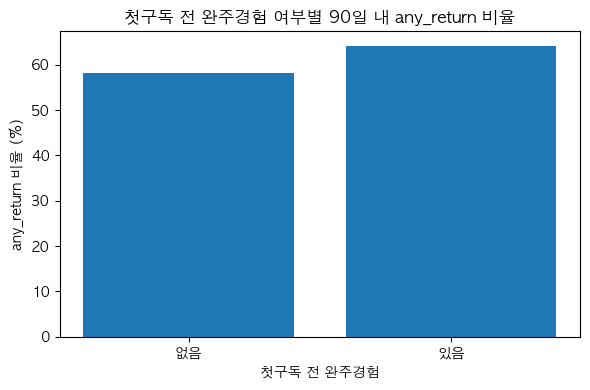

In [ ]:
plt.figure(figsize=(6, 4))
temp = b1_return_summary[['첫구독전_완주경험', 'any_return비율(%)']].copy()
plt.bar(temp['첫구독전_완주경험'], temp['any_return비율(%)'])
plt.title('첫구독 전 완주경험 여부별 90일 내 any_return 비율')
plt.xlabel('첫구독 전 완주경험')
plt.ylabel('any_return 비율 (%)')
plt.tight_layout()
plt.show()

In [ ]:
# renew / resub 개별 검정
b1_renew_ct = pd.crosstab(b1_return_df['첫구독전_완주경험'], b1_return_df['renew_90d'])
b1_resub_ct = pd.crosstab(b1_return_df['첫구독전_완주경험'], b1_return_df['resub_90d'])

print('[renew_90d 분할표]')
display(b1_renew_ct)
chi2, p, dof, expected = chi2_contingency(b1_renew_ct)
print('renew_90d p_value:', p)

print('\n[resub_90d 분할표]')
display(b1_resub_ct)
chi2, p, dof, expected = chi2_contingency(b1_resub_ct)
print('resub_90d p_value:', p)

[renew_90d 분할표]


renew_90d,0,1
첫구독전_완주경험,,
없음,326,441
있음,294,512


renew_90d p_value: 0.016694234314909944

[resub_90d 분할표]


resub_90d,0,1
첫구독전_완주경험,,
없음,761,6
있음,801,5


resub_90d p_value: 0.9342135130505115


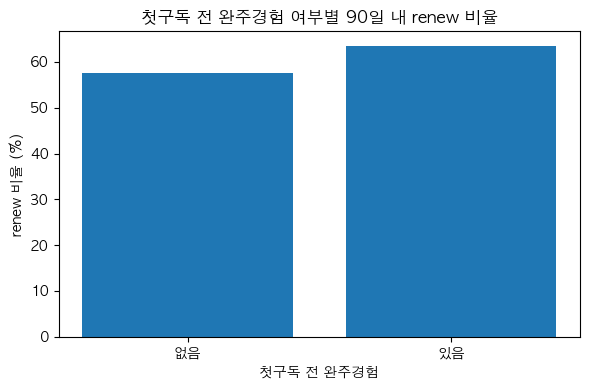

In [ ]:
plt.figure(figsize=(6, 4))
temp = b1_return_summary[['첫구독전_완주경험', 'renew비율(%)']].copy()
plt.bar(temp['첫구독전_완주경험'], temp['renew비율(%)'])
plt.title('첫구독 전 완주경험 여부별 90일 내 renew 비율')
plt.xlabel('첫구독 전 완주경험')
plt.ylabel('renew 비율 (%)')
plt.tight_layout()
plt.show()

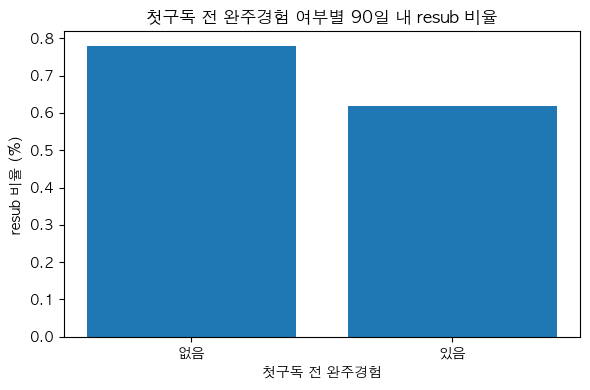

In [ ]:
plt.figure(figsize=(6, 4))
temp = b1_return_summary[['첫구독전_완주경험', 'resub비율(%)']].copy()
plt.bar(temp['첫구독전_완주경험'], temp['resub비율(%)'])
plt.title('첫구독 전 완주경험 여부별 90일 내 resub 비율')
plt.xlabel('첫구독 전 완주경험')
plt.ylabel('resub 비율 (%)')
plt.tight_layout()
plt.show()

* renew/resub에 대해 각각 카이검정 실시한 결과, renew에 대해서만 유의
>   * 첫 구독전 완주 경험 여부는 구독 후 갱신율과만 유의하게 관련됨(renew p < 0.05, resub p = 0.93)
>   * _resub을 결과변수로 보는것이 맞느냐_에 대해 논의한 내용과 합치하는 결과  
>       => 향후 click_cancel_plan_button을 통해 이탈율 분석

In [ ]:
b1_ltv30_df = b1_df[b1_df['eligible_30d'] == 1].copy()

b1_ltv30_summary = (
    b1_ltv30_df
    .groupby('첫구독전_완주경험', as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        ltv_30d_평균=('ltv_30d', 'mean'),
        ltv_30d_중앙=('ltv_30d', 'median')
    )
)
display(b1_ltv30_summary.round(2))

,첫구독전_완주경험,유저수,ltv_30d_평균,ltv_30d_중앙
0,없음,1088,32541.4,15920.0
1,있음,1163,33885.2,15920.0


In [ ]:
g0 = b1_ltv30_df.loc[b1_ltv30_df['첫구독전_완주경험'] == '없음', 'ltv_30d']
g1 = b1_ltv30_df.loc[b1_ltv30_df['첫구독전_완주경험'] == '있음', 'ltv_30d']
stat, p = mannwhitneyu(g0, g1, alternative='two-sided')

print('ltv_30d stat:', stat)
print('ltv_30d p_value:', p)

ltv_30d stat: 604527.5
ltv_30d p_value: 0.04395357184980609


* 완주경험 여부에 따른 30일 ltv 차이 유의(완주M=33885.2 vs. 미완주M=32541.4, U=604527.5, p<.05)

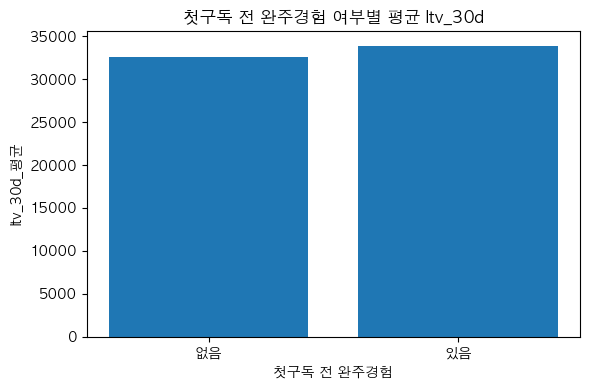

In [ ]:
plt.figure(figsize=(6, 4))

x_col = '첫구독전_완주경험'
y_candidates = ['평균_ltv_30d', 'avg_ltv_30d', 'mean_ltv_30d', 'ltv_30d_mean']

y_col = next((c for c in y_candidates if c in b1_ltv30_summary.columns), None)

if y_col is None:
    similar_cols = [
        c for c in b1_ltv30_summary.columns
        if ('ltv_30d' in c.lower()) or ('평균' in c and 'ltv' in c.lower())
    ]
    if not similar_cols:
        raise KeyError(f"사용 가능한 컬럼: {list(b1_ltv30_summary.columns)}")
    y_col = similar_cols[0]

temp = b1_ltv30_summary[[x_col, y_col]].copy()

plt.bar(temp[x_col], temp[y_col])
plt.title('첫구독 전 완주경험 여부별 평균 ltv_30d')
plt.xlabel('첫구독 전 완주경험')
plt.ylabel(y_col)
plt.tight_layout()
plt.show()

In [ ]:
b1_ltv90_df = b1_df[b1_df['eligible_90d'] == 1].copy()

b1_ltv90_summary = (
    b1_ltv90_df
    .groupby('첫구독전_완주경험', as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        평균_ltv_90d=('ltv_90d', 'mean'),
        중앙_ltv_90d=('ltv_90d', 'median')
    )
)
display(b1_ltv90_summary.round(2))

,첫구독전_완주경험,유저수,평균_ltv_90d,중앙_ltv_90d
0,없음,843,46934.35,31840.0
1,있음,881,50509.52,31840.0


In [ ]:
g0 = b1_ltv90_df.loc[b1_ltv90_df['첫구독전_완주경험'] == '없음', 'ltv_90d']
g1 = b1_ltv90_df.loc[b1_ltv90_df['첫구독전_완주경험'] == '있음', 'ltv_90d']
stat, p = mannwhitneyu(g0, g1, alternative='two-sided')

print('ltv_90d stat:', stat)
print('ltv_90d p_value:', p)

ltv_90d stat: 340515.5
ltv_90d p_value: 0.0025646968098674144


* 완주경험 여부에 따른 90일 ltv 차이 유의(완주M=50509.52 vs. 미완주M=46934.35, p<.001)

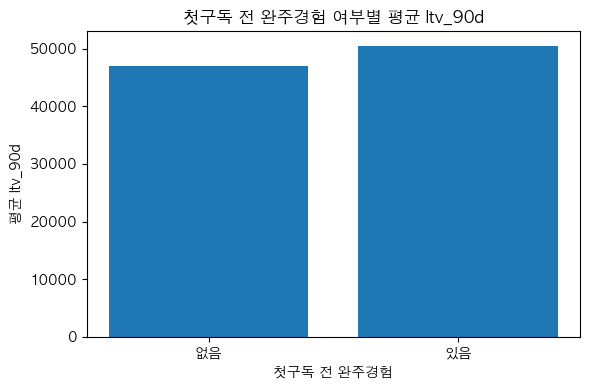

In [ ]:
plt.figure(figsize=(6, 4))
temp = b1_ltv90_summary[['첫구독전_완주경험', '평균_ltv_90d']].copy()
plt.bar(temp['첫구독전_완주경험'], temp['평균_ltv_90d'])
plt.title('첫구독 전 완주경험 여부별 평균 ltv_90d')
plt.xlabel('첫구독 전 완주경험')
plt.ylabel('평균 ltv_90d')
plt.tight_layout()
plt.show()

* 구독전 완주 경험 여부에 따른 매출(30일/90일 LTV) 차이는 유의한 것으로 나타남
* 다만 중앙값은 동일
    * 아예 결제가 없는 유저가 너무 많음

## B2. 첫 완주의 속도와 난이도는 이후 유지·매출과 연결되는가?

- 가설: 구독 이전에 완주한 유저들 내부에서, 첫 완주의 `session_days`와 난이도는 이후 유지·매출 수준과 관련이 있을 것이다.
- 대상: `analysis_base_b` 중 `pre_sub_completion_any = 1`
- 설명변수: `session_bucket`, `within_7d_first_completion`, `first_completion_difficulty`
- 결과변수: `has_any_return_90d`, `ltv_30d`, `ltv_90d`
- 분석방법: 카이제곱 검정, Kruskal-Wallis, 연속형 보조 점검


In [ ]:
b2_df = analysis_base_b[analysis_base_b['pre_sub_completion_any'] == 1].copy()

### B2-1. 첫 완주 속도 구간에 따른 90일 내 any_return

In [ ]:
# 첫 완주 속도 구간과 90일 내 any_return
b2_return_df = b2_df[b2_df['eligible_return_90d'] == 1].dropna(subset=['session_bucket']).copy()

b2_speed_return_summary = (
    b2_return_df
    .groupby('session_bucket', observed=False, as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        any_return유저수=('has_any_return_90d', 'sum')
    )
)

b2_speed_return_summary['any_return비율(%)'] = (
    b2_speed_return_summary['any_return유저수'] / b2_speed_return_summary['유저수'] * 100
).round(2)

display(b2_speed_return_summary)


,session_bucket,유저수,any_return유저수,any_return비율(%)
0,1일 이내,509,334,65.62
1,1~3일,149,93,62.42
2,3~7일,72,40,55.56
3,7~14일,41,24,58.54
4,14일 초과,35,26,74.29


In [ ]:
b2_speed_return_ct = pd.crosstab(b2_return_df['session_bucket'], b2_return_df['has_any_return_90d'])
display(b2_speed_return_ct)

chi2, p, dof, expected = chi2_contingency(b2_speed_return_ct)
print('p_value:', p)


has_any_return_90d,0,1
session_bucket,,
1일 이내,175,334
1~3일,56,93
3~7일,32,40
7~14일,17,24
14일 초과,9,26


p_value: 0.2762309634403062


* 첫 완주 속도 구간에 따른 90일내 any_return 차이는 유의하지 않음(p=0.28)

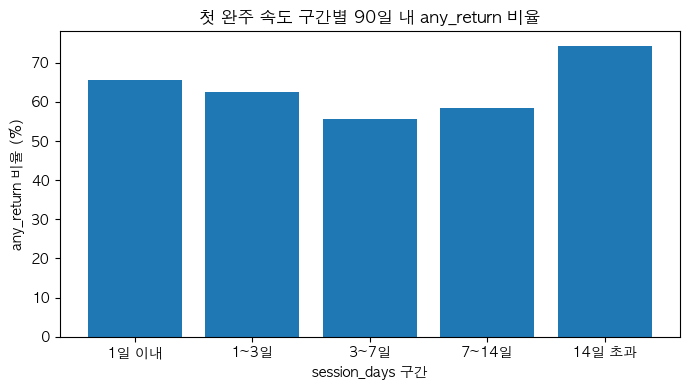

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(b2_speed_return_summary['session_bucket'].astype(str), b2_speed_return_summary['any_return비율(%)'])
plt.title('첫 완주 속도 구간별 90일 내 any_return 비율')
plt.xlabel('session_days 구간')
plt.ylabel('any_return 비율 (%)')
plt.tight_layout()
plt.show()


### B2 추가분석. 첫 완주 속도 구간은 90일 내 renew와 연결되는가?
* 비유의 -> 제거

In [ ]:

b2_speed_renew_df = b2_return_df.copy()

b2_speed_renew_summary = (
    b2_speed_renew_df
    .groupby('session_bucket', as_index=False, observed=False)
    .agg(
        유저수=('user_id', 'nunique'),
        renew유저수=('renew_90d', 'sum')
    )
)

bucket_order = ['1일 이내', '1~3일', '3~7일', '7~14일', '14일 초과']
b2_speed_renew_summary['session_bucket'] = pd.Categorical(
    b2_speed_renew_summary['session_bucket'],
    categories=bucket_order,
    ordered=True
)
b2_speed_renew_summary = b2_speed_renew_summary.sort_values('session_bucket')

b2_speed_renew_summary['renew비율(%)'] = (
    b2_speed_renew_summary['renew유저수'] / b2_speed_renew_summary['유저수'] * 100
).round(2)

display(b2_speed_renew_summary)



,session_bucket,유저수,renew유저수,renew비율(%)
0,1일 이내,509,331,65.03
1,1~3일,149,92,61.74
2,3~7일,72,40,55.56
3,7~14일,41,24,58.54
4,14일 초과,35,25,71.43


In [ ]:
b2_speed_renew_ct = pd.crosstab(
    b2_speed_renew_df['session_bucket'],
    b2_speed_renew_df['renew_90d']
)
b2_speed_renew_ct = b2_speed_renew_ct.reindex(bucket_order)
display(b2_speed_renew_ct)



renew_90d,0,1
session_bucket,,
1일 이내,178,331
1~3일,57,92
3~7일,32,40
7~14일,17,24
14일 초과,10,25


In [ ]:
chi2, p, dof, expected = chi2_contingency(b2_speed_renew_ct)
expected_df = pd.DataFrame(
    expected,
    index=b2_speed_renew_ct.index,
    columns=b2_speed_renew_ct.columns
)
display(expected_df.round(2))


renew_90d,0,1
session_bucket,,
1일 이내,185.67,323.33
1~3일,54.35,94.65
3~7일,26.26,45.74
7~14일,14.96,26.04
14일 초과,12.77,22.23


chi2: 4.058343822521851
p_value: 0.3981674531178236


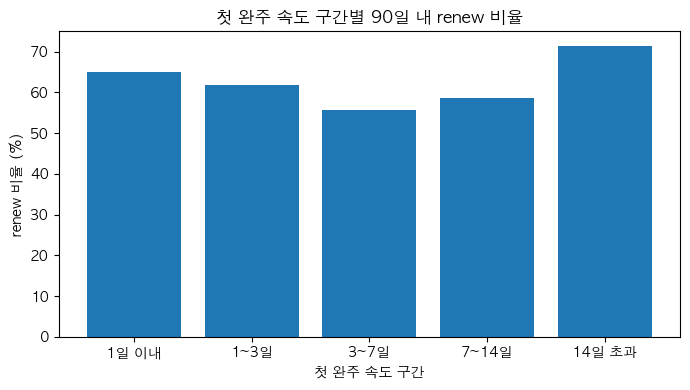

In [ ]:

print('chi2:', chi2)
print('p_value:', p)

plt.figure(figsize=(7, 4))
plt.bar(
    b2_speed_renew_summary['session_bucket'].astype(str),
    b2_speed_renew_summary['renew비율(%)']
)
plt.title('첫 완주 속도 구간별 90일 내 renew 비율')
plt.xlabel('첫 완주 속도 구간')
plt.ylabel('renew 비율 (%)')
plt.tight_layout()
plt.show()

### B2-2. 7일 내 첫 완주 여부에 따른 90일 내 any_return

In [ ]:
# 7일 내 첫 완주 여부와 90일 내 any_return
b2_within7_summary = (
    b2_return_df
    .groupby('within_7d_first_completion', as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        any_return유저수=('has_any_return_90d', 'sum')
    )
)

b2_within7_summary['구분'] = np.where(b2_within7_summary['within_7d_first_completion'] == 1, '7일 이내', '7일 초과')
b2_within7_summary['any_return비율(%)'] = (
    b2_within7_summary['any_return유저수'] / b2_within7_summary['유저수'] * 100
).round(2)

display(b2_within7_summary[['구분', '유저수', 'any_return유저수', 'any_return비율(%)']])

,구분,유저수,any_return유저수,any_return비율(%)
0,7일 초과,76,50,65.79
1,7일 이내,730,467,63.97


In [ ]:
b2_within7_ct = pd.crosstab(
    np.where(b2_return_df['within_7d_first_completion'] == 1, '7일 이내', '7일 초과'),
    b2_return_df['has_any_return_90d']
)
display(b2_within7_ct)

chi2, p, dof, expected = chi2_contingency(b2_within7_ct)
print('p_value:', p)

has_any_return_90d,0,1
row_0,,
7일 이내,263,467
7일 초과,26,50


p_value: 0.850365893527206


* 7일 내 첫 완주 여부에 따른 90일 내 any_return 역시 유의한 차이가 나타나지 않았음

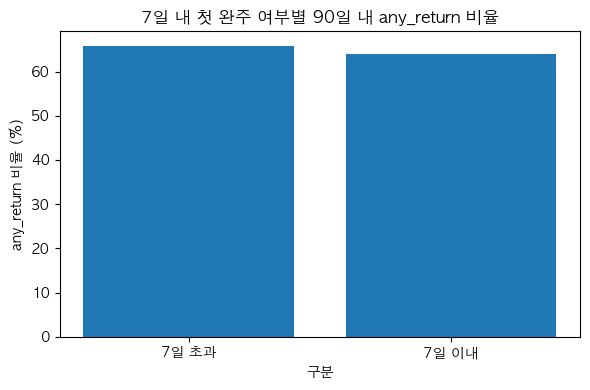

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(b2_within7_summary['구분'], b2_within7_summary['any_return비율(%)'])
plt.title('7일 내 첫 완주 여부별 90일 내 any_return 비율')
plt.xlabel('구분')
plt.ylabel('any_return 비율 (%)')
plt.tight_layout()
plt.show()

### B2 추가분석: 7일 내 첫 완주 여부에 따른 90일 내 renew
* 비유의 -> 제거

,7일내_첫완주,유저수,renew유저수,renew비율(%)
0,7일 이내,730,463,63.42
1,7일 초과,76,49,64.47


renew_90d,0,1
7일내_첫완주,,
7일 이내,267,463
7일 초과,27,49


renew_90d,0,1
7일내_첫완주,,
7일 이내,266.28,463.72
7일 초과,27.72,48.28


chi2: 0.0030923408673806346
p_value: 0.9556534379954568


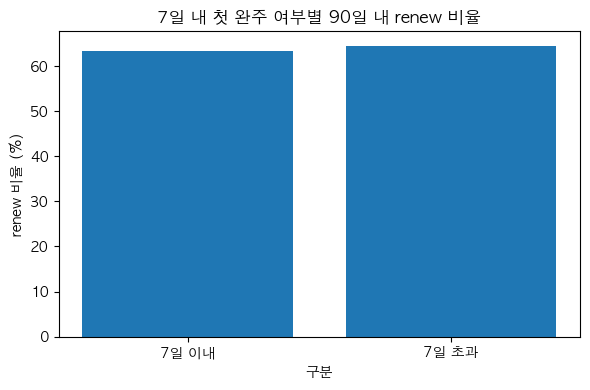

In [ ]:
# B2-2 추가. 7일 내 첫 완주 여부는 90일 내 renew와 연결되는가?

b2_within7_renew_df = b2_return_df.copy()
b2_within7_renew_df['7일내_첫완주'] = np.where(
    b2_within7_renew_df['within_7d_first_completion'] == 1,
    '7일 이내',
    '7일 초과'
)

b2_within7_renew_summary = (
    b2_within7_renew_df
    .groupby('7일내_첫완주', as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        renew유저수=('renew_90d', 'sum')
    )
)

order_7d = ['7일 이내', '7일 초과']
b2_within7_renew_summary['7일내_첫완주'] = pd.Categorical(
    b2_within7_renew_summary['7일내_첫완주'],
    categories=order_7d,
    ordered=True
)
b2_within7_renew_summary = b2_within7_renew_summary.sort_values('7일내_첫완주')

b2_within7_renew_summary['renew비율(%)'] = (
    b2_within7_renew_summary['renew유저수'] / b2_within7_renew_summary['유저수'] * 100
).round(2)

display(b2_within7_renew_summary)

b2_within7_renew_ct = pd.crosstab(
    b2_within7_renew_df['7일내_첫완주'],
    b2_within7_renew_df['renew_90d']
)
b2_within7_renew_ct = b2_within7_renew_ct.reindex(order_7d)
display(b2_within7_renew_ct)

chi2, p, dof, expected = chi2_contingency(b2_within7_renew_ct)
expected_df = pd.DataFrame(
    expected,
    index=b2_within7_renew_ct.index,
    columns=b2_within7_renew_ct.columns
)
display(expected_df.round(2))

print('chi2:', chi2)
print('p_value:', p)

if (expected < 5).any():
    fisher_or, fisher_p = fisher_exact(b2_within7_renew_ct.values)
    print('fisher_odds_ratio:', fisher_or)
    print('fisher_p_value:', fisher_p)

plt.figure(figsize=(6, 4))
plt.bar(
    b2_within7_renew_summary['7일내_첫완주'].astype(str),
    b2_within7_renew_summary['renew비율(%)']
)
plt.title('7일 내 첫 완주 여부별 90일 내 renew 비율')
plt.xlabel('구분')
plt.ylabel('renew 비율 (%)')
plt.tight_layout()
plt.show()

### B2-3. 첫 완주 속도 구간에 따른 30일 LTV

In [ ]:
# 첫 완주 속도 구간과 ltv_30d
b2_ltv30_df = b2_df[(b2_df['eligible_30d'] == 1) & b2_df['session_bucket'].notna()].copy()

b2_ltv30_summary = (
    b2_ltv30_df
    .groupby('session_bucket', observed=False, as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        평균_ltv_30d=('ltv_30d', 'mean'),
        중앙_ltv_30d=('ltv_30d', 'median')
    )
)
display(b2_ltv30_summary.round(2))


,session_bucket,유저수,평균_ltv_30d,중앙_ltv_30d
0,1일 이내,718,34952.43,15920.0
1,1~3일,221,36098.26,15920.0
2,3~7일,98,37643.18,15920.0
3,7~14일,59,35014.98,15920.0
4,14일 초과,67,8656.84,0.0


In [ ]:
groups = [g['ltv_30d'].values for _, g in b2_ltv30_df.groupby('session_bucket', observed=False)]
stat, p = kruskal(*groups)

print('kruskal stat:', stat)
print('p_value:', p)


kruskal stat: 102.46801100132807
p_value: 2.932968885076709e-21


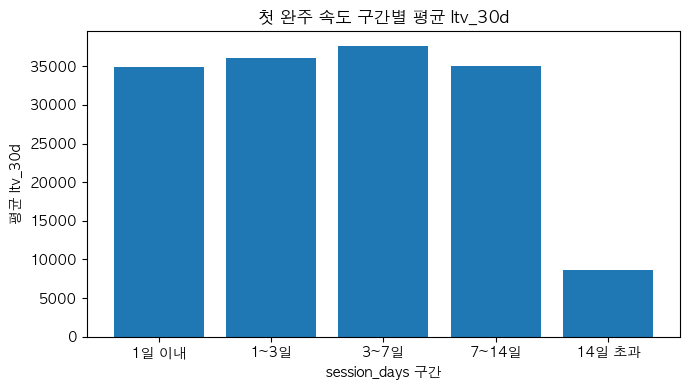

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(b2_ltv30_summary['session_bucket'].astype(str), b2_ltv30_summary['평균_ltv_30d'])
plt.title('첫 완주 속도 구간별 평균 ltv_30d')
plt.xlabel('session_days 구간')
plt.ylabel('평균 ltv_30d')
plt.tight_layout()
plt.show()


### B2-4. 첫 완주 속도 구간에 따른 90일 ltv

In [ ]:
# 첫 완주 속도 구간과 ltv_90d
b2_ltv90_df = b2_df[(b2_df['eligible_90d'] == 1) & b2_df['session_bucket'].notna()].copy()

b2_ltv90_summary = (
    b2_ltv90_df
    .groupby('session_bucket', observed=False, as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        평균_ltv_90d=('ltv_90d', 'mean'),
        중앙_ltv_90d=('ltv_90d', 'median')
    )
)
display(b2_ltv90_summary.round(2))


,session_bucket,유저수,평균_ltv_90d,중앙_ltv_90d
0,1일 이내,537,50486.56,38208.0
1,1~3일,167,52061.44,39800.0
2,3~7일,79,55717.32,46168.0
3,7~14일,46,52742.43,31840.0
4,14일 초과,52,35875.46,31044.0


In [ ]:
groups = [g['ltv_90d'].values for _, g in b2_ltv90_df.groupby('session_bucket', observed=False)]
stat, p = kruskal(*groups)

print('kruskal stat:', stat)
print('p_value:', p)


kruskal stat: 16.615571593399405
p_value: 0.0022952016730997307


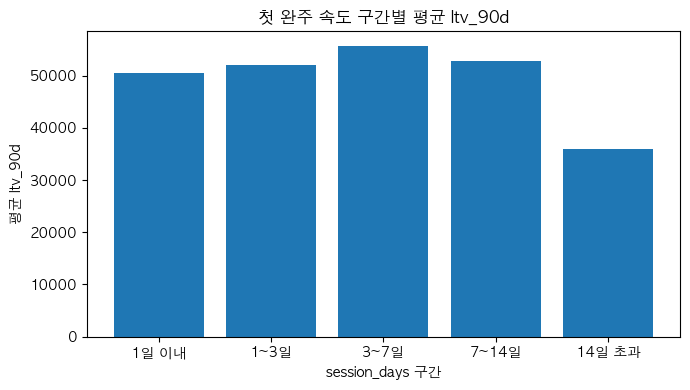

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(b2_ltv90_summary['session_bucket'].astype(str), b2_ltv90_summary['평균_ltv_90d'])
plt.title('첫 완주 속도 구간별 평균 ltv_90d')
plt.xlabel('session_days 구간')
plt.ylabel('평균 ltv_90d')
plt.tight_layout()
plt.show()


* 완주 속도 구간별 ltv_30d/90d는 모두 유의하게 나타남

### B2-4. 첫 완주 난이도에 따른 90일 내 any_return

In [ ]:
# 첫 완주 난이도와 90일 내 any_return
b2_diff_return_df = b2_return_df.dropna(subset=['first_completion_difficulty']).copy()

b2_diff_return_summary = (
    b2_diff_return_df
    .groupby('first_completion_difficulty', as_index=False)
    .agg(
        유저수=('user_id', 'nunique'),
        any_return유저수=('has_any_return_90d', 'sum')
    )
)
b2_diff_return_summary['any_return비율(%)'] = (
    b2_diff_return_summary['any_return유저수'] / b2_diff_return_summary['유저수'] * 100
).round(2)

display(b2_diff_return_summary)

,first_completion_difficulty,유저수,any_return유저수,any_return비율(%)
0,advanced,1,1,100.00
1,beginner,797,511,64.12
2,intermediate,8,5,62.50


In [ ]:
b2_diff_return_ct = pd.crosstab(
    b2_diff_return_df['first_completion_difficulty'],
    b2_diff_return_df['has_any_return_90d']
)
display(b2_diff_return_ct)

chi2, p, dof, expected = chi2_contingency(b2_diff_return_ct)
print('p_value:', p)

has_any_return_90d,0,1
first_completion_difficulty,,
advanced,0,1
beginner,286,511
intermediate,3,5


p_value: 0.7525124247398135


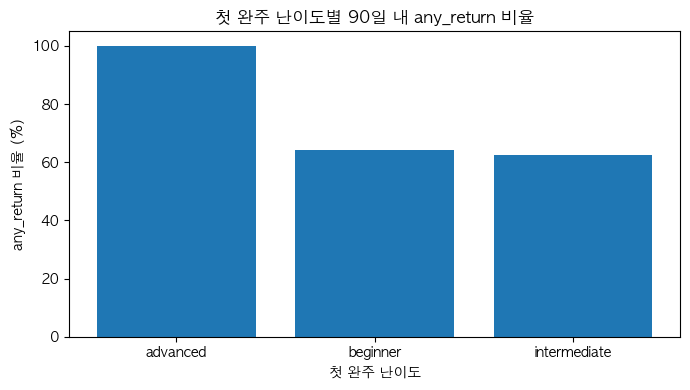

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(b2_diff_return_summary['first_completion_difficulty'].astype(str), b2_diff_return_summary['any_return비율(%)'])
plt.title('첫 완주 난이도별 90일 내 any_return 비율')
plt.xlabel('첫 완주 난이도')
plt.ylabel('any_return 비율 (%)')
plt.tight_layout()
plt.show()

### B2-5. 첫 완주 난이도에 따른 30일/90일 LTV

In [ ]:
# 첫 완주 난이도와 ltv_30d / ltv_90d
b2_diff_ltv30_df = b2_df[(b2_df['eligible_30d'] == 1) & b2_df['first_completion_difficulty'].notna()].copy()
b2_diff_ltv90_df = b2_df[(b2_df['eligible_90d'] == 1) & b2_df['first_completion_difficulty'].notna()].copy()

b2_diff_ltv30_summary = (
    b2_diff_ltv30_df
    .groupby('first_completion_difficulty', as_index=False)
    .agg(유저수=('user_id', 'nunique'), 평균_ltv_30d=('ltv_30d', 'mean'), 중앙_ltv_30d=('ltv_30d', 'median'))
)

b2_diff_ltv90_summary = (
    b2_diff_ltv90_df
    .groupby('first_completion_difficulty', as_index=False)
    .agg(유저수=('user_id', 'nunique'), 평균_ltv_90d=('ltv_90d', 'mean'), 중앙_ltv_90d=('ltv_90d', 'median'))
)

print('[난이도별 ltv_30d]')
display(b2_diff_ltv30_summary.round(2))

print('\n[난이도별 ltv_90d]')
display(b2_diff_ltv90_summary.round(2))

[난이도별 ltv_30d]


,first_completion_difficulty,유저수,평균_ltv_30d,중앙_ltv_30d
0,advanced,2,7960.00,7960.0
1,beginner,1152,33897.36,15920.0
2,intermediate,9,38088.89,15920.0



[난이도별 ltv_90d]


,first_completion_difficulty,유저수,평균_ltv_90d,중앙_ltv_90d
0,advanced,2,31840.00,31840.0
1,beginner,870,50543.69,31840.0
2,intermediate,9,51355.56,39800.0


In [ ]:
groups = [g['ltv_30d'].values for _, g in b2_diff_ltv30_df.groupby('first_completion_difficulty')]
stat, p = kruskal(*groups)
print('ltv_30d kruskal p_value:', p)

groups = [g['ltv_90d'].values for _, g in b2_diff_ltv90_df.groupby('first_completion_difficulty')]
stat, p = kruskal(*groups)
print('ltv_90d kruskal p_value:', p)

ltv_30d kruskal p_value: 0.5196766654895498
ltv_90d kruskal p_value: 0.9092216899619379


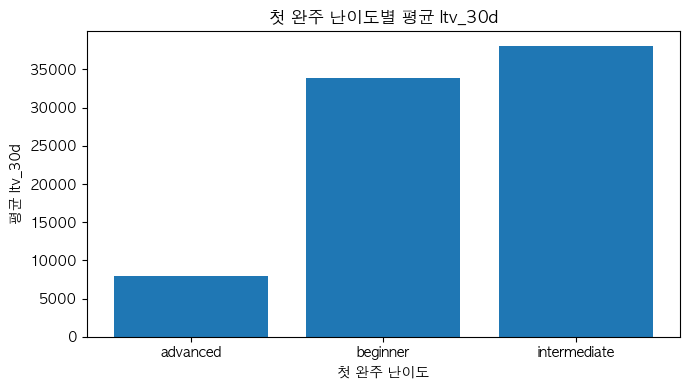

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(b2_diff_ltv30_summary['first_completion_difficulty'].astype(str), b2_diff_ltv30_summary['평균_ltv_30d'])
plt.title('첫 완주 난이도별 평균 ltv_30d')
plt.xlabel('첫 완주 난이도')
plt.ylabel('평균 ltv_30d')
plt.tight_layout()
plt.show()

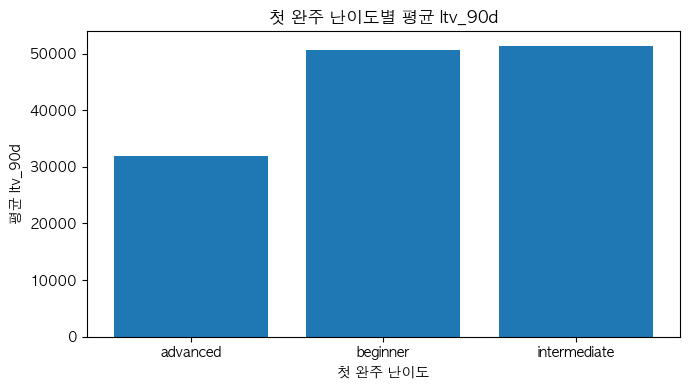

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(b2_diff_ltv90_summary['first_completion_difficulty'].astype(str), b2_diff_ltv90_summary['평균_ltv_90d'])
plt.title('첫 완주 난이도별 평균 ltv_90d')
plt.xlabel('첫 완주 난이도')
plt.ylabel('평균 ltv_90d')
plt.tight_layout()
plt.show()

In [ ]:
# 연속형 session_days와 유지 / 매출 보조 점검
temp = b2_return_df[['session_days_to_first_completion', 'has_any_return_90d']].dropna().copy()
corr, p = spearmanr(temp['session_days_to_first_completion'], temp['has_any_return_90d'])
print('session_days vs has_any_return_90d Spearman corr:', corr)
print('p_value:', p)

temp = b2_ltv90_df[['session_days_to_first_completion', 'ltv_90d']].dropna().copy()
corr, p = spearmanr(temp['session_days_to_first_completion'], temp['ltv_90d'])
print('session_days vs ltv_90d Spearman corr:', corr)
print('p_value:', p)


session_days vs has_any_return_90d Spearman corr: -0.023199579412886816
p_value: 0.5107273132649182
session_days vs ltv_90d Spearman corr: -0.056576285335022514
p_value: 0.09330077813465136


* 속도와 any_return_90d: 유의하지 않음
* 속도와 ltv_30d/90d: 유의
* 난이도와 유지/매출: 유의하지 않음
  
    > * 예상과 달리 첫 완주 속도는 유지 자체보다는 매출 규모와 더 연결되는 것으로 확인됨
    > * 난이도는 표본이 부족하여 결론내리기 어려움
  
    > * 빠른 완주는 첫 구독(유료전환) 타이밍과 초기 선택 plan에는 영향을 줄 수 있지만, 90일 내 다시 남느냐는 별개의 문제일 수 있음
    > * 유지에는 첫 성공보다 이후 콘텐츠 품질, 구독가치, 사용 습관이 더 중요할 수 있음
    > * 특히 14일 초과 그룹의 30일 LTV가 매우 낮은 것으로 확인됨 -> '느린 완주 유저는 초기 수익화가 약하다'는 해석과 일치